# Predicción del riesgo de enfermedad coronaria mediante Machine Learning

## Trabajo Fin de Máster

Este notebook contiene el desarrollo del análisis realizado sobre el conjunto de datos del Framingham Heart Study, con el objetivo de predecir el riesgo de enfermedad coronaria a 10 años mediante técnicas de aprendizaje automático.

El análisis incluye:

- Exploración y análisis de los datos.
- Tratamiento de valores ausentes.
- Preprocesamiento de las variables.
- Tratamiento del desbalance de clases mediante SMOTE.
- Entrenamiento de modelos de clasificación.
- Evaluación mediante Accuracy, Precision, Recall, F1, ROC-AUC y PR-AUC.
- Aplicación de técnicas de aprendizaje no supervisado y clustering.

In [1]:
import pandas as pd

df = pd.read_csv("../data/framingham.csv")

df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [2]:
print("Dimensiones del dataset:", df.shape)

df.info()

Dimensiones del dataset: (4240, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)


In [3]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [5]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

df_imputed = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

df_imputed.isnull().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

In [6]:
from sklearn.model_selection import train_test_split

# Variables predictoras
X = df_imputed.drop("TenYearCHD", axis=1)

# Variable objetivo
y = df_imputed["TenYearCHD"]

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)

print("\nDistribución de clases en entrenamiento:")
print(y_train.value_counts())

print("\nDistribución de clases en prueba:")
print(y_test.value_counts())

Tamaño del conjunto de entrenamiento: (3392, 15)
Tamaño del conjunto de prueba: (848, 15)

Distribución de clases en entrenamiento:
TenYearCHD
0.0    2877
1.0     515
Name: count, dtype: int64

Distribución de clases en prueba:
TenYearCHD
0.0    719
1.0    129
Name: count, dtype: int64


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos de entrenamiento escalados:", X_train_scaled.shape)
print("Datos de prueba escalados:", X_test_scaled.shape)

Datos de entrenamiento escalados: (3392, 15)
Datos de prueba escalados: (848, 15)


In [8]:
# ============================================================
# 1.1 MODELOS LINEALES
# ALGORITMO: REGRESIÓN LOGÍSTICA
# ============================================================

print("=" * 60)
print("1.1 MODELOS LINEALES")
print("ALGORITMO: REGRESIÓN LOGÍSTICA")
print("=" * 60)


# ------------------------------------------------------------
# PARTE 1: ENTRENAMIENTO DEL MODELO
# ------------------------------------------------------------

print("\nINICIO DE LA FASE DE ENTRENAMIENTO")

from sklearn.linear_model import LogisticRegression

# Crear el modelo de Regresión Logística
modelo_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Entrenar el modelo utilizando los datos de entrenamiento
modelo_lr.fit(X_train_scaled, y_train)

print("Modelo entrenado correctamente.")

1.1 MODELOS LINEALES
ALGORITMO: REGRESIÓN LOGÍSTICA

INICIO DE LA FASE DE ENTRENAMIENTO
Modelo entrenado correctamente.


In [9]:
# ------------------------------------------------------------
# PARTE 2: REALIZACIÓN DE PREDICCIONES
# ------------------------------------------------------------

print("\nINICIO DE LA FASE DE PREDICCIÓN")

# Predicción de las clases
y_pred_lr = modelo_lr.predict(X_test_scaled)

# Probabilidad de pertenecer a la clase positiva (TenYearCHD = 1)
y_prob_lr = modelo_lr.predict_proba(X_test_scaled)[:, 1]

print("Predicciones realizadas correctamente.")


INICIO DE LA FASE DE PREDICCIÓN
Predicciones realizadas correctamente.


In [10]:
# ------------------------------------------------------------
# PARTE 3: EVALUACIÓN DEL MODELO
# ------------------------------------------------------------

print("\nINICIO DE LA FASE DE EVALUACIÓN")

# Aquí calcularemos las métricas:
# Accuracy
# Precision
# Recall
# F1-score
# ROC-AUC
# PR-AUC
# Matriz de confusión


INICIO DE LA FASE DE EVALUACIÓN


In [11]:
# ------------------------------------------------------------
# PARTE 2: REALIZACIÓN DE PREDICCIONES
# ------------------------------------------------------------

print("\nINICIO DE LA FASE DE PREDICCIÓN")

# Realizar la predicción de la clase para cada paciente
y_pred_lr = modelo_lr.predict(X_test_scaled)

# Calcular la probabilidad de que cada paciente pertenezca
# a la clase positiva: TenYearCHD = 1
y_prob_lr = modelo_lr.predict_proba(X_test_scaled)[:, 1]

print("Predicciones realizadas correctamente.")


INICIO DE LA FASE DE PREDICCIÓN
Predicciones realizadas correctamente.


In [12]:
# ------------------------------------------------------------
# PARTE 3: EVALUACIÓN DEL MODELO
# ------------------------------------------------------------

print("\nINICIO DE LA FASE DE EVALUACIÓN")

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Calcular las principales métricas de clasificación
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

# Calcular métricas basadas en las probabilidades predichas
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
pr_auc_lr = average_precision_score(y_test, y_prob_lr)

# Mostrar los resultados
print("\nRESULTADOS DEL MODELO DE REGRESIÓN LOGÍSTICA")
print("-" * 50)

print(f"Accuracy:  {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall:    {recall_lr:.4f}")
print(f"F1-score:  {f1_lr:.4f}")
print(f"ROC-AUC:   {roc_auc_lr:.4f}")
print(f"PR-AUC:    {pr_auc_lr:.4f}")

print("\nEvaluación completada correctamente.")


INICIO DE LA FASE DE EVALUACIÓN

RESULTADOS DEL MODELO DE REGRESIÓN LOGÍSTICA
--------------------------------------------------
Accuracy:  0.8443
Precision: 0.4118
Recall:    0.0543
F1-score:  0.0959
ROC-AUC:   0.7028
PR-AUC:    0.3021

Evaluación completada correctamente.



INICIO DE LA REPRESENTACIÓN GRÁFICA
GENERANDO MATRIZ DE CONFUSIÓN...


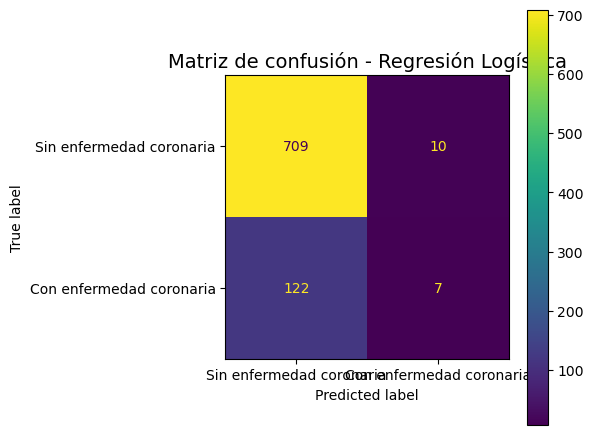

Matriz de confusión generada correctamente.


In [13]:
# ============================================================
# PARTE 4: REPRESENTACIÓN GRÁFICA DEL MODELO
# GRÁFICO 1: MATRIZ DE CONFUSIÓN
# ============================================================

print("\nINICIO DE LA REPRESENTACIÓN GRÁFICA")
print("GENERANDO MATRIZ DE CONFUSIÓN...")

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Crear la figura
fig, ax = plt.subplots(figsize=(6, 5))

# Generar la matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=["Sin enfermedad coronaria", "Con enfermedad coronaria"],
    ax=ax
)

# Añadir título
ax.set_title(
    "Matriz de confusión - Regresión Logística",
    fontsize=14
)

# Ajustar el diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()

print("Matriz de confusión generada correctamente.")


GENERANDO CURVA ROC...


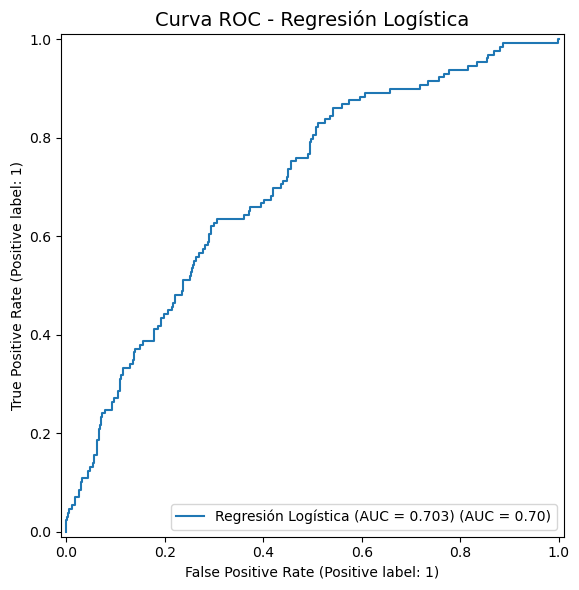

Curva ROC generada correctamente.


In [14]:
# ============================================================
# PARTE 4: REPRESENTACIÓN GRÁFICA DEL MODELO
# GRÁFICO 2: CURVA ROC
# ============================================================

print("\nGENERANDO CURVA ROC...")

import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# Crear la figura
fig, ax = plt.subplots(figsize=(7, 6))

# Generar la curva ROC utilizando las probabilidades predichas
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name=f"Regresión Logística (AUC = {roc_auc_lr:.3f})",
    ax=ax
)

# Añadir título
ax.set_title(
    "Curva ROC - Regresión Logística",
    fontsize=14
)

# Ajustar el diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()

print("Curva ROC generada correctamente.")


GENERANDO CURVA PRECISION-RECALL...


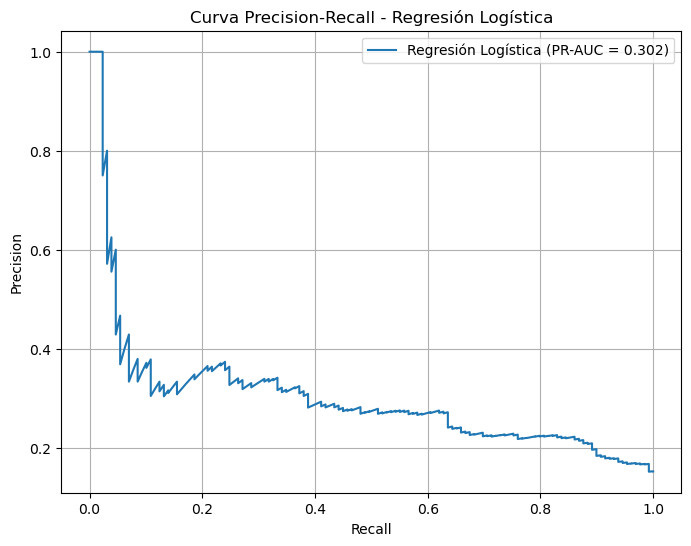


PR-AUC: 0.3021
Curva Precision-Recall generada correctamente.


In [15]:
# ============================================================
# PARTE 5: CURVA PRECISION-RECALL
# MODELO: REGRESIÓN LOGÍSTICA
# ============================================================

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

print("\nGENERANDO CURVA PRECISION-RECALL...")

# Calcular los valores de precision y recall
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_lr
)

# Calcular el área bajo la curva Precision-Recall
pr_auc_lr = average_precision_score(
    y_test,
    y_prob_lr
)

# Crear la gráfica
plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f'Regresión Logística (PR-AUC = {pr_auc_lr:.3f})'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall - Regresión Logística')

plt.legend()
plt.grid()

plt.show()

print(f"\nPR-AUC: {pr_auc_lr:.4f}")
print("Curva Precision-Recall generada correctamente.")

In [16]:
# ============================================================
# TABLA GENERAL DE RESULTADOS DE CLASIFICACIÓN
# ============================================================

print("CREANDO TABLA DE RESULTADOS...")

# Crear la tabla inicial con los resultados
# del primer algoritmo: Regresión Logística

resultados = pd.DataFrame({
    "Modelo": ["Regresión Logística"],
    "Accuracy": [accuracy_lr],
    "Precision": [precision_lr],
    "Recall": [recall_lr],
    "F1-score": [f1_lr],
    "ROC-AUC": [roc_auc_lr],
    "PR-AUC": [pr_auc_lr]
})

print("\nRESULTADOS GUARDADOS CORRECTAMENTE:")
display(resultados)

CREANDO TABLA DE RESULTADOS...

RESULTADOS GUARDADOS CORRECTAMENTE:


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística,0.84434,0.411765,0.054264,0.09589,0.702774,0.302116


In [17]:
# ============================================================
# 1.2.1 - LINEAR DISCRIMINANT ANALYSIS (LDA)
# PARTE 1: ENTRENAMIENTO DEL MODELO
# ============================================================

print("============================================================")
print("1.2.1 - LINEAR DISCRIMINANT ANALYSIS (LDA)")
print("INICIO DE LA FASE DE ENTRENAMIENTO")
print("============================================================")

# Importar el algoritmo LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Crear el modelo
modelo_lda = LinearDiscriminantAnalysis()

# Entrenar el modelo utilizando los datos de entrenamiento escalados
modelo_lda.fit(X_train_scaled, y_train)

print("\nModelo LDA entrenado correctamente.")

1.2.1 - LINEAR DISCRIMINANT ANALYSIS (LDA)
INICIO DE LA FASE DE ENTRENAMIENTO

Modelo LDA entrenado correctamente.


In [18]:
# ============================================================
# 1.2.1 - LINEAR DISCRIMINANT ANALYSIS (LDA)
# PARTE 2: REALIZACIÓN DE PREDICCIONES
# ============================================================

print("\n============================================================")
print("1.2.1 - LINEAR DISCRIMINANT ANALYSIS (LDA)")
print("INICIO DE LA FASE DE PREDICCIÓN")
print("============================================================")

# ------------------------------------------------------------
# Realizar la predicción de la clase para cada paciente
# utilizando el conjunto de prueba
# ------------------------------------------------------------

y_pred_lda = modelo_lda.predict(X_test_scaled)


# ------------------------------------------------------------
# Calcular la probabilidad de que cada paciente pertenezca
# a la clase positiva: riesgo de enfermedad coronaria a 10 años
# ------------------------------------------------------------

y_prob_lda = modelo_lda.predict_proba(X_test_scaled)[:, 1]


print("\nPredicciones realizadas correctamente.")


1.2.1 - LINEAR DISCRIMINANT ANALYSIS (LDA)
INICIO DE LA FASE DE PREDICCIÓN

Predicciones realizadas correctamente.


In [19]:
# ================================================================
# 1.2.1 - LINEAR DISCRIMINANT ANALYSIS (LDA)
# COMPROBACIÓN DE LAS PREDICCIONES REALIZADAS
# ================================================================

print("PRIMERAS 10 PREDICCIONES:")
print(y_pred_lda[:10])

print("\nPRIMERAS 10 PROBABILIDADES DE RIESGO:")
print(y_prob_lda[:10])

PRIMERAS 10 PREDICCIONES:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

PRIMERAS 10 PROBABILIDADES DE RIESGO:
[0.04351002 0.02925079 0.15110629 0.03548937 0.22060203 0.05238188
 0.03580971 0.15929482 0.02093809 0.29592122]


In [20]:
# ================================================================
# 1.2.2 - LINEAR DISCRIMINANT ANALYSIS (LDA)
# PARTE 3: EVALUACIÓN DEL MODELO
# ================================================================

print("=" * 65)
print("1.2.2 - EVALUACIÓN DEL MODELO LDA")
print("=" * 65)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# ---------------------------------------------------------------
# Cálculo de las principales métricas de clasificación
# ---------------------------------------------------------------

accuracy_lda = accuracy_score(y_test, y_pred_lda)

precision_lda = precision_score(
    y_test,
    y_pred_lda,
    zero_division=0
)

recall_lda = recall_score(
    y_test,
    y_pred_lda,
    zero_division=0
)

f1_lda = f1_score(
    y_test,
    y_pred_lda,
    zero_division=0
)

roc_auc_lda = roc_auc_score(
    y_test,
    y_prob_lda
)

pr_auc_lda = average_precision_score(
    y_test,
    y_prob_lda
)

# ---------------------------------------------------------------
# Mostrar los resultados obtenidos
# ---------------------------------------------------------------

print(f"\nAccuracy:  {accuracy_lda:.4f}")
print(f"Precision: {precision_lda:.4f}")
print(f"Recall:    {recall_lda:.4f}")
print(f"F1-score:  {f1_lda:.4f}")
print(f"ROC-AUC:   {roc_auc_lda:.4f}")
print(f"PR-AUC:    {pr_auc_lda:.4f}")

print("\nEvaluación completada correctamente.")

1.2.2 - EVALUACIÓN DEL MODELO LDA

Accuracy:  0.8384
Precision: 0.3462
Recall:    0.0698
F1-score:  0.1161
ROC-AUC:   0.7009
PR-AUC:    0.2878

Evaluación completada correctamente.


GENERANDO MATRIZ DE CONFUSIÓN...


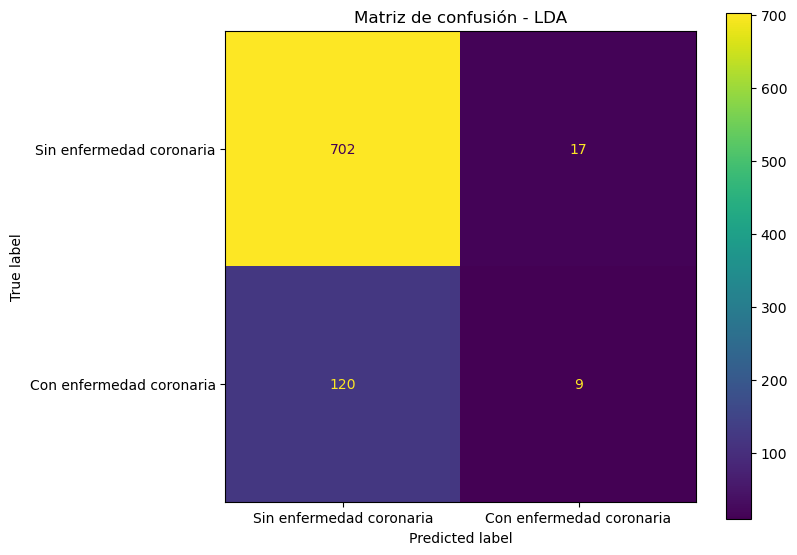


Matriz de confusión generada correctamente.


In [21]:
# ================================================================
# 1.2.3 - LINEAR DISCRIMINANT ANALYSIS (LDA)
# PARTE 4: MATRIZ DE CONFUSIÓN
# ================================================================

print("=" * 65)
print("GENERANDO MATRIZ DE CONFUSIÓN...")
print("=" * 65)

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Crear la matriz de confusión
fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lda,
    display_labels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ],
    ax=ax
)

plt.title("Matriz de confusión - LDA")
plt.tight_layout()
plt.show()

print("\nMatriz de confusión generada correctamente.")

GENERANDO CURVA ROC...


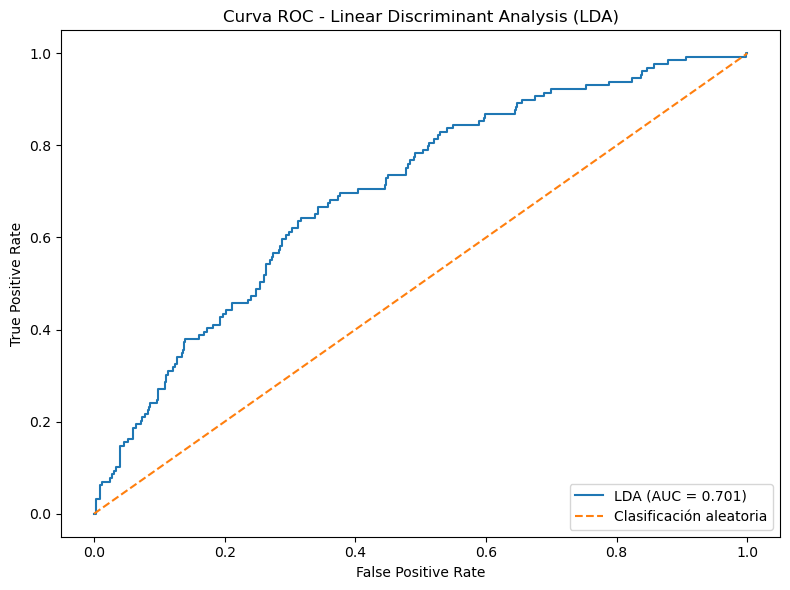


ROC-AUC: 0.7009
Curva ROC generada correctamente.


In [22]:
# ================================================================
# 1.2.4 - LINEAR DISCRIMINANT ANALYSIS (LDA)
# PARTE 5: CURVA ROC
# ================================================================

print("=" * 65)
print("GENERANDO CURVA ROC...")
print("=" * 65)

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# Calcular los valores necesarios para la curva ROC
# ---------------------------------------------------------------

fpr_lda, tpr_lda, thresholds_lda = roc_curve(
    y_test,
    y_prob_lda
)

roc_auc_lda_grafico = auc(
    fpr_lda,
    tpr_lda
)

# ---------------------------------------------------------------
# Representar la curva ROC
# ---------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lda,
    tpr_lda,
    label=f"LDA (AUC = {roc_auc_lda_grafico:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Linear Discriminant Analysis (LDA)")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

print(f"\nROC-AUC: {roc_auc_lda_grafico:.4f}")
print("Curva ROC generada correctamente.")

GENERANDO CURVA PRECISION-RECALL...


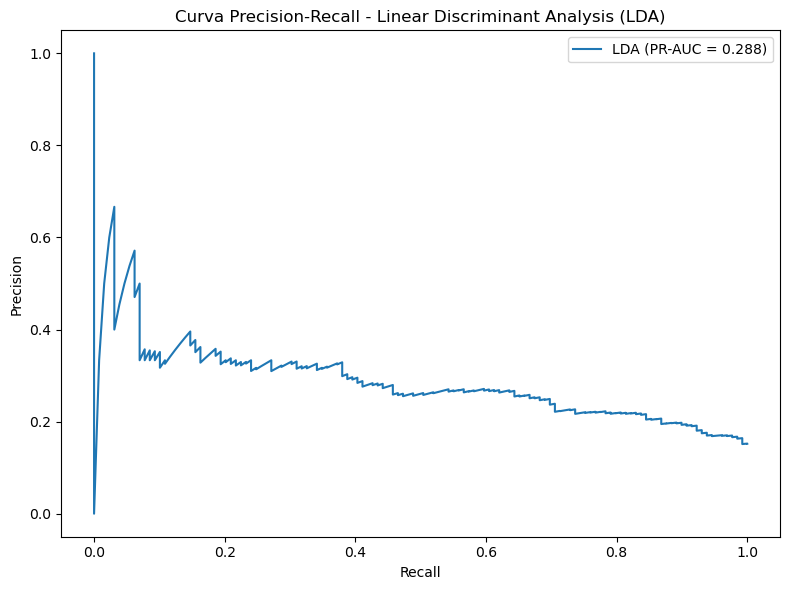


PR-AUC: 0.2878
Curva Precision-Recall generada correctamente.


In [23]:
# ================================================================
# 1.2.5 - LINEAR DISCRIMINANT ANALYSIS (LDA)
# PARTE 6: CURVA PRECISION-RECALL
# ================================================================

print("=" * 65)
print("GENERANDO CURVA PRECISION-RECALL...")
print("=" * 65)

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# Calcular los valores necesarios para la curva Precision-Recall
# ---------------------------------------------------------------

precision_curve_lda, recall_curve_lda, thresholds_pr_lda = precision_recall_curve(
    y_test,
    y_prob_lda
)

pr_auc_lda_grafico = average_precision_score(
    y_test,
    y_prob_lda
)

# ---------------------------------------------------------------
# Representar la curva Precision-Recall
# ---------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve_lda,
    precision_curve_lda,
    label=f"LDA (PR-AUC = {pr_auc_lda_grafico:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Linear Discriminant Analysis (LDA)")
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

print(f"\nPR-AUC: {pr_auc_lda_grafico:.4f}")
print("Curva Precision-Recall generada correctamente.")

In [24]:
# ================================================================
# 1.2.6 - LINEAR DISCRIMINANT ANALYSIS (LDA)
# PARTE 7: GUARDAR RESULTADOS DEL MODELO
# ================================================================

print("=" * 65)
print("GUARDANDO RESULTADOS DEL MODELO LDA...")
print("=" * 65)

# Añadir los resultados del LDA a la tabla comparativa

resultados.loc[len(resultados)] = {
    "Modelo": "Linear Discriminant Analysis (LDA)",
    "Accuracy": accuracy_lda,
    "Precision": precision_lda,
    "Recall": recall_lda,
    "F1-score": f1_lda,
    "ROC-AUC": roc_auc_lda,
    "PR-AUC": pr_auc_lda
}

print("\nRESULTADOS ACTUALIZADOS:")
display(resultados)

GUARDANDO RESULTADOS DEL MODELO LDA...

RESULTADOS ACTUALIZADOS:


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística,0.844340,0.411765,0.054264,0.095890,0.702774,0.302116
1,Linear Discriminant Analysis (LDA),0.838443,0.346154,0.069767,0.116129,0.700941,0.287816


In [25]:
# ================================================================
# 1.3 - KERNEL RIDGE REGRESSION
# ================================================================

# Este algoritmo no se utiliza en el presente análisis debido a que
# Kernel Ridge Regression está orientado principalmente a problemas
# de regresión, mientras que la variable objetivo TenYearCHD
# corresponde a un problema de clasificación binaria.
#
# Por este motivo, se pasa directamente al algoritmo 1.4:
# SUPPORT VECTOR MACHINES (SVM)
# ================================================================

In [26]:
# ================================================================
# 1.4 - SUPPORT VECTOR MACHINES (SVM)
# PARTE 1: ENTRENAMIENTO DEL MODELO
# ================================================================

print("=" * 65)
print("1.4 - SUPPORT VECTOR MACHINES (SVM)")
print("INICIO DE LA FASE DE ENTRENAMIENTO")
print("=" * 65)

# ---------------------------------------------------------------
# Importar el algoritmo SVM
# ---------------------------------------------------------------

from sklearn.svm import SVC

# ---------------------------------------------------------------
# Crear el modelo
# ---------------------------------------------------------------

modelo_svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

# ---------------------------------------------------------------
# Entrenar el modelo utilizando los datos de entrenamiento
# ---------------------------------------------------------------

modelo_svm.fit(X_train_scaled, y_train)

print("\nModelo SVM entrenado correctamente.")

1.4 - SUPPORT VECTOR MACHINES (SVM)
INICIO DE LA FASE DE ENTRENAMIENTO

Modelo SVM entrenado correctamente.


In [27]:
# ================================================================
# 1.4 - SUPPORT VECTOR MACHINES (SVM)
# PARTE 2: REALIZACIÓN DE PREDICCIONES
# ================================================================

print("=" * 65)
print("1.4 - SUPPORT VECTOR MACHINES (SVM)")
print("INICIO DE LA FASE DE PREDICCIÓN")
print("=" * 65)

# ---------------------------------------------------------------
# Predicción de la clase para los pacientes del conjunto de prueba
# ---------------------------------------------------------------

y_pred_svm = modelo_svm.predict(X_test_scaled)

# ---------------------------------------------------------------
# Calcular la probabilidad de pertenecer a la clase positiva:
# TenYearCHD = 1
# ---------------------------------------------------------------

y_prob_svm = modelo_svm.predict_proba(X_test_scaled)[:, 1]

print("\nPredicciones realizadas correctamente.")

1.4 - SUPPORT VECTOR MACHINES (SVM)
INICIO DE LA FASE DE PREDICCIÓN

Predicciones realizadas correctamente.


In [28]:
# ================================================================
# 1.4 - SUPPORT VECTOR MACHINES (SVM)
# PARTE 3: EVALUACIÓN DEL MODELO
# ================================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("=" * 65)
print("1.4.2 - EVALUACIÓN DEL MODELO SVM")
print("=" * 65)

# ---------------------------------------------------------------
# Calcular las métricas de evaluación
# ---------------------------------------------------------------

accuracy_svm = accuracy_score(y_test, y_pred_svm)

precision_svm = precision_score(
    y_test,
    y_pred_svm,
    zero_division=0
)

recall_svm = recall_score(
    y_test,
    y_pred_svm,
    zero_division=0
)

f1_svm = f1_score(
    y_test,
    y_pred_svm,
    zero_division=0
)

roc_auc_svm = roc_auc_score(
    y_test,
    y_prob_svm
)

pr_auc_svm = average_precision_score(
    y_test,
    y_prob_svm
)

# ---------------------------------------------------------------
# Mostrar resultados
# ---------------------------------------------------------------

print(f"\nAccuracy:  {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall:    {recall_svm:.4f}")
print(f"F1-score:  {f1_svm:.4f}")
print(f"ROC-AUC:   {roc_auc_svm:.4f}")
print(f"PR-AUC:    {pr_auc_svm:.4f}")

print("\nEvaluación completada correctamente.")

1.4.2 - EVALUACIÓN DEL MODELO SVM

Accuracy:  0.8502
Precision: 0.7500
Recall:    0.0233
F1-score:  0.0451
ROC-AUC:   0.5421
PR-AUC:    0.2209

Evaluación completada correctamente.


GENERANDO MATRIZ DE CONFUSIÓN...


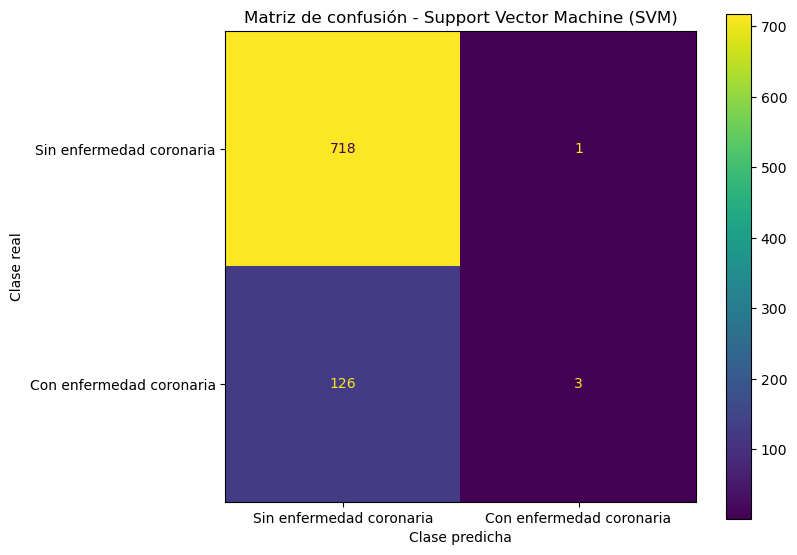


Matriz de confusión generada correctamente.


In [29]:
# ================================================================
# 1.4 - SUPPORT VECTOR MACHINES (SVM)
# GRÁFICA 1: MATRIZ DE CONFUSIÓN
# ================================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("=" * 65)
print("GENERANDO MATRIZ DE CONFUSIÓN...")
print("=" * 65)

# Crear la matriz de confusión
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Crear la visualización
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ]
)

fig, ax = plt.subplots(figsize=(8, 6))

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title("Matriz de confusión - Support Vector Machine (SVM)")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

plt.tight_layout()
plt.show()

print("\nMatriz de confusión generada correctamente.")

GENERANDO CURVA ROC...


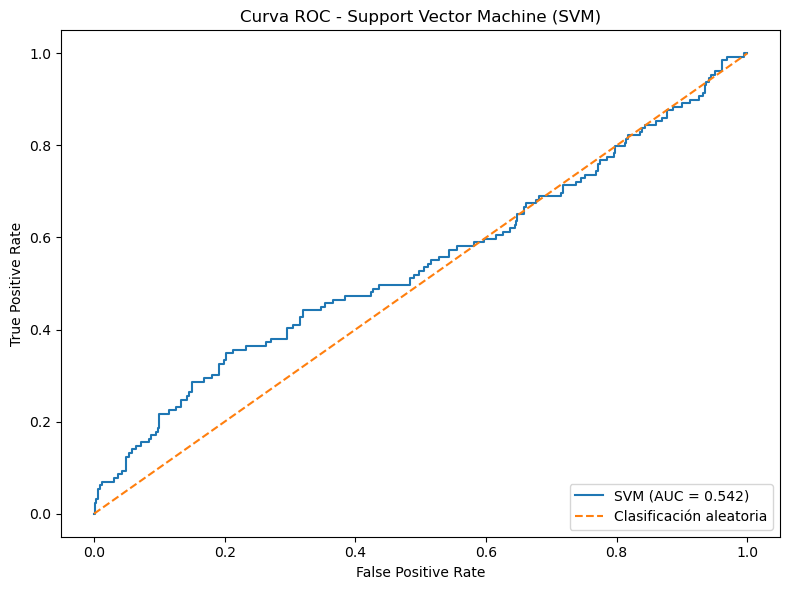


ROC-AUC: 0.5421
Curva ROC generada correctamente.


In [30]:
# ================================================================
# 1.4 - SUPPORT VECTOR MACHINES (SVM)
# GRÁFICA 2: CURVA ROC
# ================================================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

print("=" * 65)
print("GENERANDO CURVA ROC...")
print("=" * 65)

# ---------------------------------------------------------------
# Calcular los valores necesarios para la curva ROC
# ---------------------------------------------------------------

fpr_svm, tpr_svm, thresholds_svm = roc_curve(
    y_test,
    y_prob_svm
)

auc_svm = auc(fpr_svm, tpr_svm)

# ---------------------------------------------------------------
# Crear la gráfica
# ---------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_svm,
    tpr_svm,
    label=f"SVM (AUC = {auc_svm:.3f})"
)

# Línea de clasificación aleatoria
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Support Vector Machine (SVM)")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

print(f"\nROC-AUC: {auc_svm:.4f}")
print("Curva ROC generada correctamente.")

GENERANDO CURVA PRECISION-RECALL...


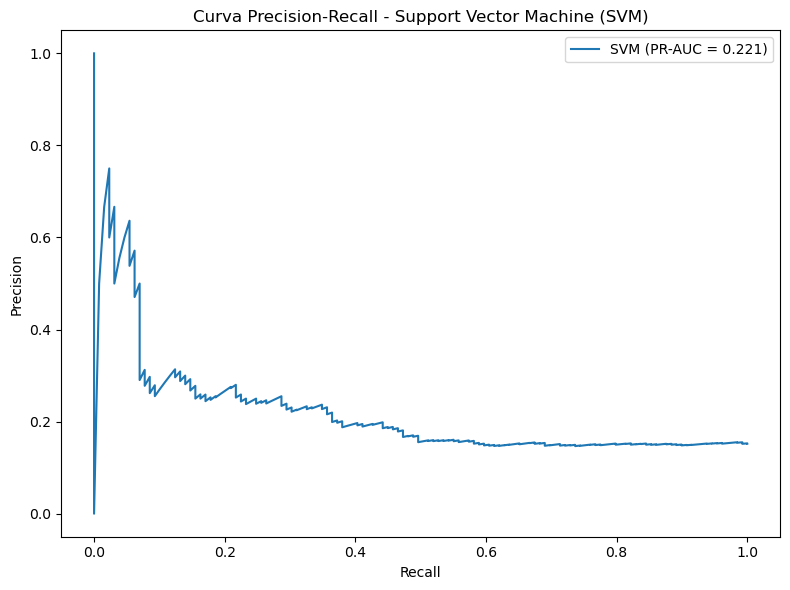


PR-AUC: 0.2209
Curva Precision-Recall generada correctamente.


In [31]:
# ================================================================
# 1.4 - SUPPORT VECTOR MACHINES (SVM)
# GRÁFICA 3: CURVA PRECISION-RECALL
# ================================================================

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

print("=" * 65)
print("GENERANDO CURVA PRECISION-RECALL...")
print("=" * 65)

# ---------------------------------------------------------------
# Calcular los valores para la curva Precision-Recall
# ---------------------------------------------------------------

precision_curve_svm, recall_curve_svm, thresholds_svm_pr = precision_recall_curve(
    y_test,
    y_prob_svm
)

pr_auc_svm_grafica = average_precision_score(
    y_test,
    y_prob_svm
)

# ---------------------------------------------------------------
# Crear la gráfica
# ---------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve_svm,
    precision_curve_svm,
    label=f"SVM (PR-AUC = {pr_auc_svm_grafica:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Support Vector Machine (SVM)")
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

print(f"\nPR-AUC: {pr_auc_svm_grafica:.4f}")
print("Curva Precision-Recall generada correctamente.")

In [32]:
# ================================================================
# TABLA GENERAL DE RESULTADOS DE LOS MODELOS
# ================================================================

import pandas as pd

print("=" * 65)
print("CREANDO TABLA GENERAL DE RESULTADOS")
print("=" * 65)

resultados_modelos = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "Linear Discriminant Analysis (LDA)",
        "Support Vector Machine (SVM)"
    ],
    
    "Accuracy": [
        accuracy_lr,
        accuracy_lda,
        accuracy_svm
    ],
    
    "Precision": [
        precision_lr,
        precision_lda,
        precision_svm
    ],
    
    "Recall": [
        recall_lr,
        recall_lda,
        recall_svm
    ],
    
    "F1-score": [
        f1_lr,
        f1_lda,
        f1_svm
    ],
    
    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_lda,
        roc_auc_svm
    ],
    
    "PR-AUC": [
        pr_auc_lr,
        pr_auc_lda,
        pr_auc_svm
    ]
})

print("\nTABLA CREADA CORRECTAMENTE:\n")

display(resultados_modelos)

CREANDO TABLA GENERAL DE RESULTADOS

TABLA CREADA CORRECTAMENTE:



,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística,0.844340,0.411765,0.054264,0.095890,0.702774,0.302116
1,Linear Discriminant Analysis (LDA),0.838443,0.346154,0.069767,0.116129,0.700941,0.287816
2,Support Vector Machine (SVM),0.850236,0.750000,0.023256,0.045113,0.542064,0.220860


In [33]:
# ================================================================
# 1.5 - STOCHASTIC GRADIENT DESCENT (SGD)
# PARTE 1: ENTRENAMIENTO DEL MODELO
# ================================================================

print("=" * 65)
print("1.5 - STOCHASTIC GRADIENT DESCENT (SGD)")
print("INICIO DE LA FASE DE ENTRENAMIENTO")
print("=" * 65)

# ------------------------------------------------
# Importar el algoritmo SGD para clasificación
# ------------------------------------------------

from sklearn.linear_model import SGDClassifier


# ------------------------------------------------
# Crear el modelo
# ------------------------------------------------

modelo_sgd = SGDClassifier(
    loss="log_loss",
    random_state=42
)


# ------------------------------------------------
# Entrenar el modelo utilizando los datos
# de entrenamiento previamente escalados
# ------------------------------------------------

modelo_sgd.fit(X_train_scaled, y_train)


print("\nModelo SGD entrenado correctamente.")

1.5 - STOCHASTIC GRADIENT DESCENT (SGD)
INICIO DE LA FASE DE ENTRENAMIENTO

Modelo SGD entrenado correctamente.


In [34]:
# ==============================================================
# 1.5 - STOCHASTIC GRADIENT DESCENT (SGD)
# PARTE 2: REALIZACIÓN DE PREDICCIONES
# ==============================================================

print("=" * 65)
print("1.5 - STOCHASTIC GRADIENT DESCENT (SGD)")
print("INICIO DE LA FASE DE PREDICCIÓN")
print("=" * 65)


# --------------------------------------------------------------
# Predicción de la clase para los pacientes del conjunto de prueba
# --------------------------------------------------------------

y_pred_sgd = modelo_sgd.predict(X_test_scaled)


# --------------------------------------------------------------
# Calcular la puntuación de decisión del modelo
# para los pacientes del conjunto de prueba
# --------------------------------------------------------------

y_score_sgd = modelo_sgd.decision_function(X_test_scaled)


print("\nPredicciones realizadas correctamente.")

1.5 - STOCHASTIC GRADIENT DESCENT (SGD)
INICIO DE LA FASE DE PREDICCIÓN

Predicciones realizadas correctamente.


In [35]:
# ==============================================================
# 1.5.2 - EVALUACIÓN DEL MODELO STOCHASTIC GRADIENT DESCENT (SGD)
# ==============================================================

print("=" * 65)
print("1.5.2 - EVALUACIÓN DEL MODELO SGD")
print("=" * 65)


# --------------------------------------------------------------
# Importar las métricas de evaluación
# --------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)


# --------------------------------------------------------------
# Calcular las métricas principales del modelo
# --------------------------------------------------------------

accuracy_sgd = accuracy_score(y_test, y_pred_sgd)

precision_sgd = precision_score(
    y_test,
    y_pred_sgd,
    zero_division=0
)

recall_sgd = recall_score(
    y_test,
    y_pred_sgd,
    zero_division=0
)

f1_sgd = f1_score(
    y_test,
    y_pred_sgd,
    zero_division=0
)


# --------------------------------------------------------------
# Calcular ROC-AUC utilizando las puntuaciones de decisión
# --------------------------------------------------------------

roc_auc_sgd = roc_auc_score(
    y_test,
    y_score_sgd
)


# --------------------------------------------------------------
# Calcular PR-AUC
# --------------------------------------------------------------

pr_auc_sgd = average_precision_score(
    y_test,
    y_score_sgd
)


# --------------------------------------------------------------
# Mostrar los resultados
# --------------------------------------------------------------

print(f"\nAccuracy:  {accuracy_sgd:.4f}")
print(f"Precision: {precision_sgd:.4f}")
print(f"Recall:    {recall_sgd:.4f}")
print(f"F1-score:  {f1_sgd:.4f}")
print(f"ROC-AUC:   {roc_auc_sgd:.4f}")
print(f"PR-AUC:    {pr_auc_sgd:.4f}")

print("\nEvaluación completada correctamente.")

1.5.2 - EVALUACIÓN DEL MODELO SGD

Accuracy:  0.8184
Precision: 0.2727
Recall:    0.1163
F1-score:  0.1630
ROC-AUC:   0.6605
PR-AUC:    0.2425

Evaluación completada correctamente.


GENERANDO MATRIZ DE CONFUSIÓN...


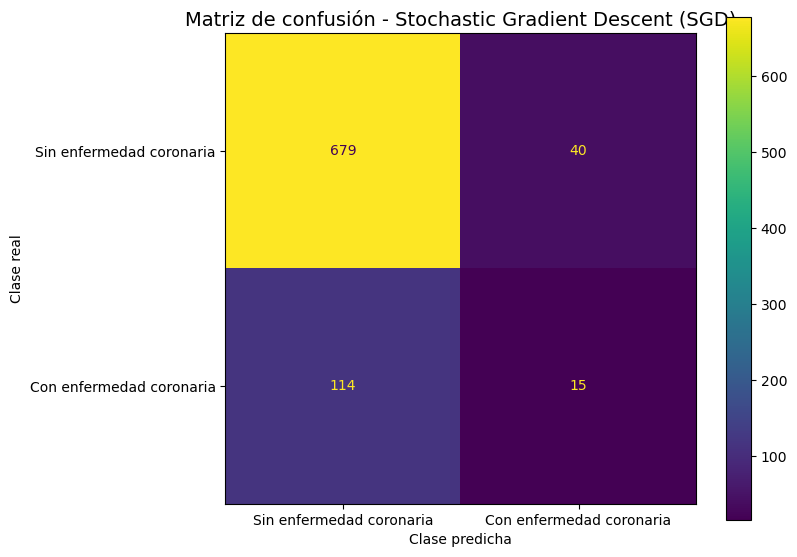


Matriz de confusión generada correctamente.


In [36]:
# ==============================================================
# 1.5.3 - MATRIZ DE CONFUSIÓN DEL MODELO SGD
# ==============================================================

print("=" * 65)
print("GENERANDO MATRIZ DE CONFUSIÓN...")
print("=" * 65)


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# --------------------------------------------------------------
# Calcular la matriz de confusión
# --------------------------------------------------------------

matriz_sgd = confusion_matrix(
    y_test,
    y_pred_sgd
)


# --------------------------------------------------------------
# Crear la representación gráfica
# --------------------------------------------------------------

display_sgd = ConfusionMatrixDisplay(
    confusion_matrix=matriz_sgd,
    display_labels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ]
)


# --------------------------------------------------------------
# Mostrar la matriz
# --------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

display_sgd.plot(
    ax=ax,
    cmap="viridis",
    values_format="d"
)

plt.title(
    "Matriz de confusión - Stochastic Gradient Descent (SGD)",
    fontsize=14
)

plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

plt.tight_layout()
plt.show()


print("\nMatriz de confusión generada correctamente.")

GENERANDO CURVA ROC...


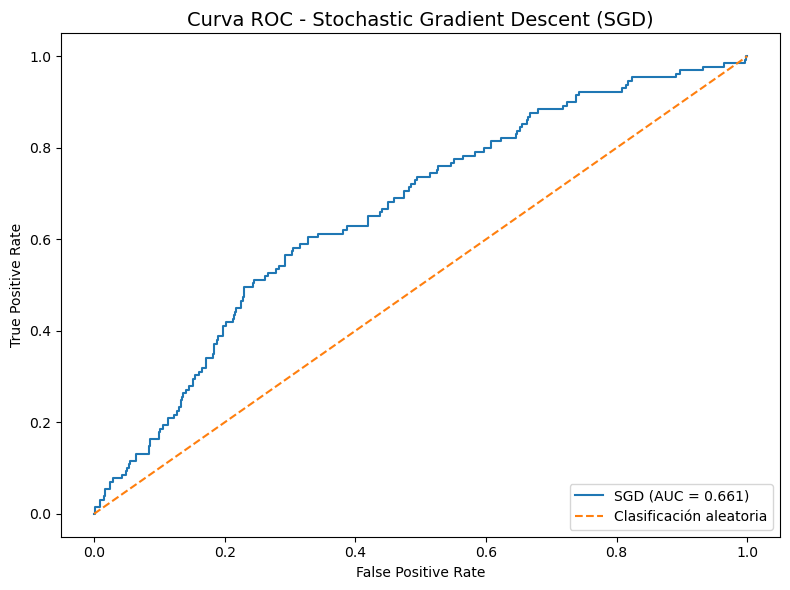


ROC-AUC: 0.6605
Curva ROC generada correctamente.


In [37]:
# ==============================================================
# 1.5.4 - CURVA ROC DEL MODELO SGD
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA ROC...")
print("=" * 65)


from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


# --------------------------------------------------------------
# Calcular los valores necesarios para la curva ROC
# --------------------------------------------------------------

fpr_sgd, tpr_sgd, thresholds_sgd = roc_curve(
    y_test,
    y_score_sgd
)

auc_sgd = auc(
    fpr_sgd,
    tpr_sgd
)


# --------------------------------------------------------------
# Crear la gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_sgd,
    tpr_sgd,
    label=f"SGD (AUC = {auc_sgd:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)


# --------------------------------------------------------------
# Configurar la gráfica
# --------------------------------------------------------------

plt.title(
    "Curva ROC - Stochastic Gradient Descent (SGD)",
    fontsize=14
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc="lower right")

plt.tight_layout()
plt.show()


print(f"\nROC-AUC: {auc_sgd:.4f}")
print("Curva ROC generada correctamente.")

GENERANDO CURVA PRECISION-RECALL...


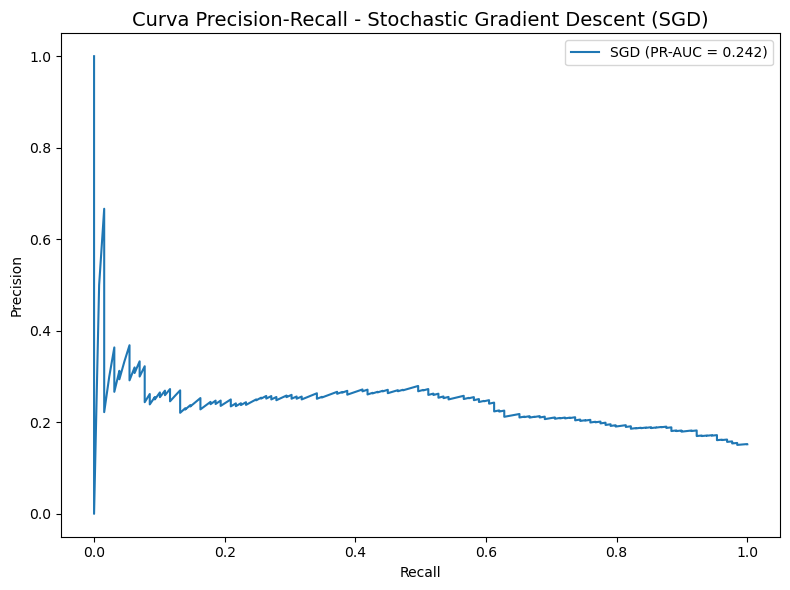


PR-AUC: 0.2425
Curva Precision-Recall generada correctamente.


In [38]:
# ==============================================================
# 1.5.5 - CURVA PRECISION-RECALL DEL MODELO SGD
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA PRECISION-RECALL...")
print("=" * 65)


from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt


# --------------------------------------------------------------
# Calcular los valores necesarios para la curva Precision-Recall
# --------------------------------------------------------------

precision_curve_sgd, recall_curve_sgd, thresholds_pr_sgd = precision_recall_curve(
    y_test,
    y_score_sgd
)


# --------------------------------------------------------------
# Calcular el área bajo la curva Precision-Recall
# --------------------------------------------------------------

pr_auc_sgd = average_precision_score(
    y_test,
    y_score_sgd
)


# --------------------------------------------------------------
# Crear la gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve_sgd,
    precision_curve_sgd,
    label=f"SGD (PR-AUC = {pr_auc_sgd:.3f})"
)


# --------------------------------------------------------------
# Configurar la gráfica
# --------------------------------------------------------------

plt.title(
    "Curva Precision-Recall - Stochastic Gradient Descent (SGD)",
    fontsize=14
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend(loc="upper right")

plt.tight_layout()
plt.show()


print(f"\nPR-AUC: {pr_auc_sgd:.4f}")
print("Curva Precision-Recall generada correctamente.")

In [39]:
# ==============================================================
# 1.5.6 - GUARDAR RESULTADOS DEL MODELO SGD
# ==============================================================

print("=" * 65)
print("1.5.6 - GUARDAR RESULTADOS DEL MODELO SGD")
print("=" * 65)


# --------------------------------------------------------------
# Crear una nueva fila con los resultados del SGD
# --------------------------------------------------------------

nuevo_resultado = pd.DataFrame({
    "Modelo": ["Stochastic Gradient Descent (SGD)"],
    "Accuracy": [accuracy_sgd],
    "Precision": [precision_sgd],
    "Recall": [recall_sgd],
    "F1-score": [f1_sgd],
    "ROC-AUC": [roc_auc_sgd],
    "PR-AUC": [pr_auc_sgd]
})


# --------------------------------------------------------------
# Añadir el resultado a la tabla comparativa
# --------------------------------------------------------------

resultados_modelos = pd.concat(
    [resultados_modelos, nuevo_resultado],
    ignore_index=True
)


# --------------------------------------------------------------
# Mostrar la tabla actualizada
# --------------------------------------------------------------

print("\nRESULTADOS ACTUALIZADOS CORRECTAMENTE")
print("=" * 65)

display(resultados_modelos)

1.5.6 - GUARDAR RESULTADOS DEL MODELO SGD

RESULTADOS ACTUALIZADOS CORRECTAMENTE


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística,0.844340,0.411765,0.054264,0.095890,0.702774,0.302116
1,Linear Discriminant Analysis (LDA),0.838443,0.346154,0.069767,0.116129,0.700941,0.287816
2,Support Vector Machine (SVM),0.850236,0.750000,0.023256,0.045113,0.542064,0.220860
3,Stochastic Gradient Descent (SGD),0.818396,0.272727,0.116279,0.163043,0.660543,0.242477


In [40]:
# ==============================================================
# 1.6 - K-NEAREST NEIGHBORS (KNN)
# PARTE 1: ENTRENAMIENTO DEL MODELO
# ==============================================================

print("=" * 65)
print("1.6 - K-NEAREST NEIGHBORS (KNN)")
print("INICIO DE LA FASE DE ENTRENAMIENTO")
print("=" * 65)


# --------------------------------------------------------------
# Importar el algoritmo K-Nearest Neighbors
# --------------------------------------------------------------

from sklearn.neighbors import KNeighborsClassifier


# --------------------------------------------------------------
# Crear el modelo KNN
# --------------------------------------------------------------

modelo_knn = KNeighborsClassifier(
    n_neighbors=5
)


# --------------------------------------------------------------
# Entrenar el modelo utilizando los datos de entrenamiento escalados
# --------------------------------------------------------------

modelo_knn.fit(
    X_train_scaled,
    y_train
)


print("\nModelo KNN entrenado correctamente.")

1.6 - K-NEAREST NEIGHBORS (KNN)
INICIO DE LA FASE DE ENTRENAMIENTO

Modelo KNN entrenado correctamente.


In [41]:
# ==============================================================
# 1.6 - K-NEAREST NEIGHBORS (KNN)
# PARTE 2: REALIZACIÓN DE PREDICCIONES
# ==============================================================

print("=" * 65)
print("1.6 - K-NEAREST NEIGHBORS (KNN)")
print("INICIO DE LA FASE DE PREDICCIÓN")
print("=" * 65)


# --------------------------------------------------------------
# Predicción de la clase para los pacientes del conjunto de prueba
# --------------------------------------------------------------

y_pred_knn = modelo_knn.predict(X_test_scaled)


# --------------------------------------------------------------
# Calcular la probabilidad de pertenecer a la clase positiva
# TenYearCHD = 1
# --------------------------------------------------------------

y_prob_knn = modelo_knn.predict_proba(X_test_scaled)[:, 1]


print("\nPredicciones realizadas correctamente.")

1.6 - K-NEAREST NEIGHBORS (KNN)
INICIO DE LA FASE DE PREDICCIÓN

Predicciones realizadas correctamente.


In [42]:
# ==============================================================
# 1.6.2 - EVALUACIÓN DEL MODELO K-NEAREST NEIGHBORS (KNN)
# ==============================================================

print("=" * 65)
print("1.6.2 - EVALUACIÓN DEL MODELO KNN")
print("=" * 65)


# --------------------------------------------------------------
# Calcular las métricas principales del modelo
# --------------------------------------------------------------

accuracy_knn = accuracy_score(
    y_test,
    y_pred_knn
)

precision_knn = precision_score(
    y_test,
    y_pred_knn,
    zero_division=0
)

recall_knn = recall_score(
    y_test,
    y_pred_knn,
    zero_division=0
)

f1_knn = f1_score(
    y_test,
    y_pred_knn,
    zero_division=0
)


# --------------------------------------------------------------
# Calcular ROC-AUC utilizando las probabilidades estimadas
# --------------------------------------------------------------

roc_auc_knn = roc_auc_score(
    y_test,
    y_prob_knn
)


# --------------------------------------------------------------
# Calcular PR-AUC
# --------------------------------------------------------------

pr_auc_knn = average_precision_score(
    y_test,
    y_prob_knn
)


# --------------------------------------------------------------
# Mostrar los resultados
# --------------------------------------------------------------

print(f"\nAccuracy:  {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall:    {recall_knn:.4f}")
print(f"F1-score:  {f1_knn:.4f}")
print(f"ROC-AUC:   {roc_auc_knn:.4f}")
print(f"PR-AUC:    {pr_auc_knn:.4f}")

print("\nEvaluación completada correctamente.")

1.6.2 - EVALUACIÓN DEL MODELO KNN

Accuracy:  0.8396
Precision: 0.3939
Recall:    0.1008
F1-score:  0.1605
ROC-AUC:   0.5693
PR-AUC:    0.2056

Evaluación completada correctamente.


GENERANDO MATRIZ DE CONFUSIÓN...


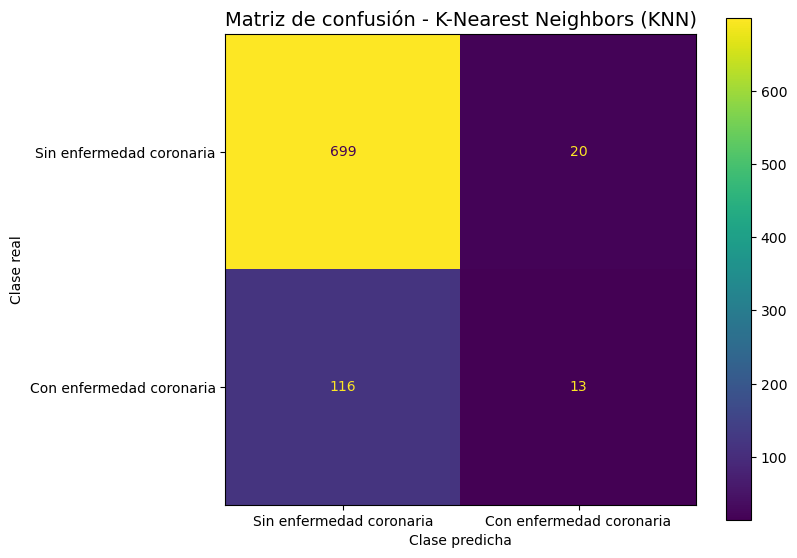


Matriz de confusión generada correctamente.


In [43]:
# ==============================================================
# 1.6.3 - MATRIZ DE CONFUSIÓN DEL MODELO KNN
# ==============================================================

print("=" * 65)
print("GENERANDO MATRIZ DE CONFUSIÓN...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular la matriz de confusión
# --------------------------------------------------------------

matriz_knn = confusion_matrix(
    y_test,
    y_pred_knn
)


# --------------------------------------------------------------
# Crear la representación gráfica
# --------------------------------------------------------------

display_knn = ConfusionMatrixDisplay(
    confusion_matrix=matriz_knn,
    display_labels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ]
)


# --------------------------------------------------------------
# Mostrar la matriz
# --------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

display_knn.plot(
    ax=ax,
    cmap="viridis",
    values_format="d"
)

plt.title(
    "Matriz de confusión - K-Nearest Neighbors (KNN)",
    fontsize=14
)

plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

plt.tight_layout()
plt.show()


print("\nMatriz de confusión generada correctamente.")

GENERANDO CURVA ROC...


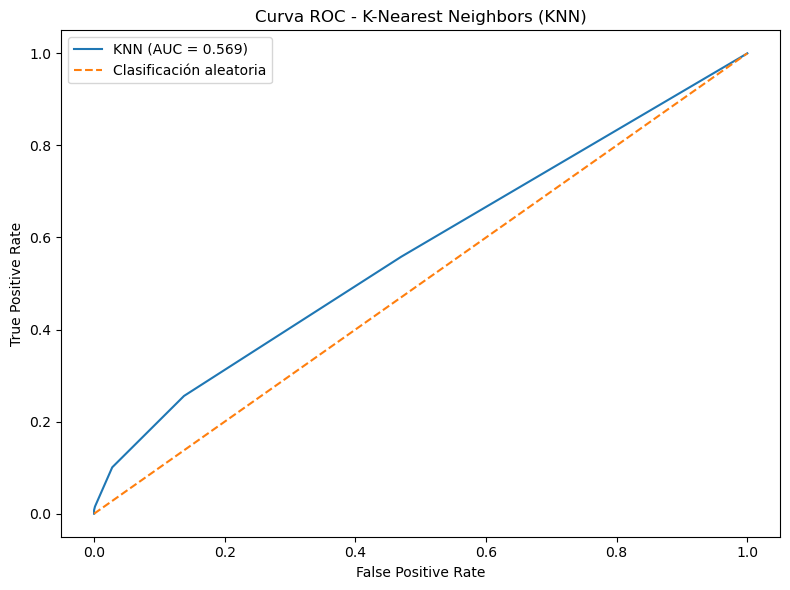


ROC-AUC: 0.5693
Curva ROC generada correctamente.


In [44]:
# ==============================================================
# 1.6.4 - CURVA ROC DEL MODELO KNN
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA ROC...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular los valores necesarios para la curva ROC
# --------------------------------------------------------------

fpr_knn, tpr_knn, _ = roc_curve(
    y_test,
    y_prob_knn
)


# --------------------------------------------------------------
# Crear la gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_knn,
    tpr_knn,
    label=f"KNN (AUC = {roc_auc_knn:.3f})"
)

# Línea de clasificación aleatoria
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)


# --------------------------------------------------------------
# Configuración de la gráfica
# --------------------------------------------------------------

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Curva ROC - K-Nearest Neighbors (KNN)"
)

plt.legend()

plt.tight_layout()
plt.show()


print(f"\nROC-AUC: {roc_auc_knn:.4f}")
print("Curva ROC generada correctamente.")

GENERANDO CURVA PRECISION-RECALL...


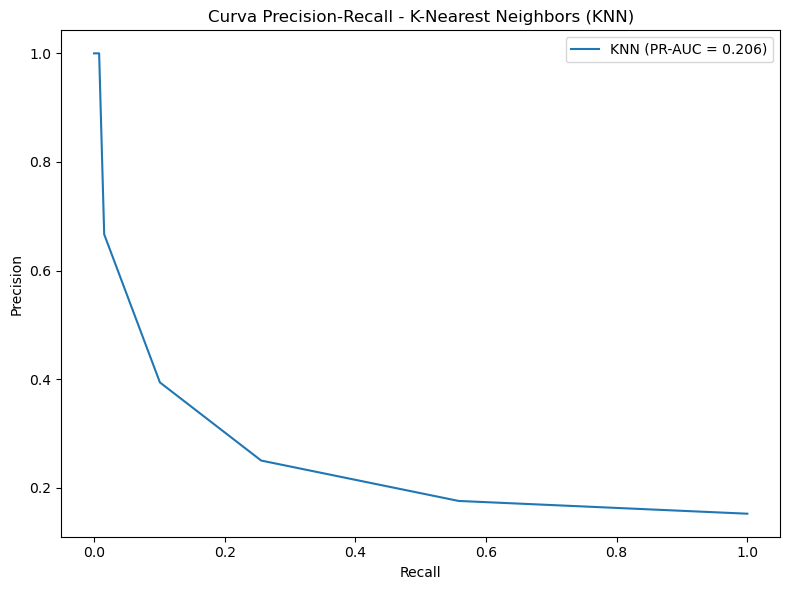


PR-AUC: 0.2056
Curva Precision-Recall generada correctamente.


In [45]:
# ==============================================================
# 1.6.5 - CURVA PRECISION-RECALL DEL MODELO KNN
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA PRECISION-RECALL...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular los valores necesarios para la curva Precision-Recall
# --------------------------------------------------------------

precision_knn_curve, recall_knn_curve, _ = precision_recall_curve(
    y_test,
    y_prob_knn
)


# --------------------------------------------------------------
# Crear la gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    recall_knn_curve,
    precision_knn_curve,
    label=f"KNN (PR-AUC = {pr_auc_knn:.3f})"
)


# --------------------------------------------------------------
# Configuración de la gráfica
# --------------------------------------------------------------

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Curva Precision-Recall - K-Nearest Neighbors (KNN)"
)

plt.legend()

plt.tight_layout()
plt.show()


print(f"\nPR-AUC: {pr_auc_knn:.4f}")
print("Curva Precision-Recall generada correctamente.")

In [46]:
# ==============================================================
# 1.6.6 - GUARDAR RESULTADOS EN LA TABLA COMPARATIVA
# ==============================================================

import pandas as pd


# --------------------------------------------------------------
# Crear una nueva fila con los resultados del KNN
# --------------------------------------------------------------

nuevo_resultado = pd.DataFrame({
    "Modelo": ["K-Nearest Neighbors (KNN)"],
    "Accuracy": [accuracy_knn],
    "Precision": [precision_knn],
    "Recall": [recall_knn],
    "F1-score": [f1_knn],
    "ROC-AUC": [roc_auc_knn],
    "PR-AUC": [pr_auc_knn]
})


# --------------------------------------------------------------
# Añadir el resultado a la tabla existente
# --------------------------------------------------------------

resultados_modelos = pd.concat(
    [resultados_modelos, nuevo_resultado],
    ignore_index=True
)


# --------------------------------------------------------------
# Mostrar la tabla actualizada
# --------------------------------------------------------------

print("=" * 65)
print("RESULTADOS ACTUALIZADOS CORRECTAMENTE")
print("=" * 65)

display(resultados_modelos)

RESULTADOS ACTUALIZADOS CORRECTAMENTE


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística,0.844340,0.411765,0.054264,0.095890,0.702774,0.302116
1,Linear Discriminant Analysis (LDA),0.838443,0.346154,0.069767,0.116129,0.700941,0.287816
2,Support Vector Machine (SVM),0.850236,0.750000,0.023256,0.045113,0.542064,0.220860
3,Stochastic Gradient Descent (SGD),0.818396,0.272727,0.116279,0.163043,0.660543,0.242477
4,K-Nearest Neighbors (KNN),0.839623,0.393939,0.100775,0.160494,0.569255,0.205580


In [47]:
# ==============================================================
# 1.9 - GAUSSIAN NAIVE BAYES
# PARTE 1: ENTRENAMIENTO DEL MODELO
# ==============================================================

print("=" * 65)
print("1.9 - GAUSSIAN NAIVE BAYES")
print("INICIO DE LA FASE DE ENTRENAMIENTO")
print("=" * 65)


# --------------------------------------------------------------
# Importar el algoritmo Gaussian Naive Bayes
# --------------------------------------------------------------

from sklearn.naive_bayes import GaussianNB


# --------------------------------------------------------------
# Crear el modelo
# --------------------------------------------------------------

modelo_gnb = GaussianNB()


# --------------------------------------------------------------
# Entrenar el modelo utilizando los datos de entrenamiento
# --------------------------------------------------------------

modelo_gnb.fit(
    X_train_scaled,
    y_train
)


print("\nModelo Gaussian Naive Bayes entrenado correctamente.")

1.9 - GAUSSIAN NAIVE BAYES
INICIO DE LA FASE DE ENTRENAMIENTO

Modelo Gaussian Naive Bayes entrenado correctamente.


In [48]:
# ==============================================================
# 1.9 - GAUSSIAN NAIVE BAYES
# PARTE 2: REALIZACIÓN DE PREDICCIONES
# ==============================================================

print("=" * 65)
print("1.9 - GAUSSIAN NAIVE BAYES")
print("INICIO DE LA FASE DE PREDICCIÓN")
print("=" * 65)


# --------------------------------------------------------------
# Predicción de la clase para los pacientes del conjunto de prueba
# --------------------------------------------------------------

y_pred_gnb = modelo_gnb.predict(X_test_scaled)


# --------------------------------------------------------------
# Calcular la probabilidad de pertenecer a la clase positiva
# TenYearCHD = 1
# --------------------------------------------------------------

y_prob_gnb = modelo_gnb.predict_proba(X_test_scaled)[:, 1]


print("\nPredicciones realizadas correctamente.")

1.9 - GAUSSIAN NAIVE BAYES
INICIO DE LA FASE DE PREDICCIÓN

Predicciones realizadas correctamente.


In [49]:
# ==============================================================
# 1.9.2 - EVALUACIÓN DEL MODELO GAUSSIAN NAIVE BAYES
# ==============================================================

print("=" * 65)
print("1.9.2 - EVALUACIÓN DEL MODELO GAUSSIAN NAIVE BAYES")
print("=" * 65)


# --------------------------------------------------------------
# Calcular las métricas principales del modelo
# --------------------------------------------------------------

accuracy_gnb = accuracy_score(
    y_test,
    y_pred_gnb
)

precision_gnb = precision_score(
    y_test,
    y_pred_gnb,
    zero_division=0
)

recall_gnb = recall_score(
    y_test,
    y_pred_gnb,
    zero_division=0
)

f1_gnb = f1_score(
    y_test,
    y_pred_gnb,
    zero_division=0
)


# --------------------------------------------------------------
# Calcular ROC-AUC utilizando las probabilidades estimadas
# --------------------------------------------------------------

roc_auc_gnb = roc_auc_score(
    y_test,
    y_prob_gnb
)


# --------------------------------------------------------------
# Calcular PR-AUC
# --------------------------------------------------------------

pr_auc_gnb = average_precision_score(
    y_test,
    y_prob_gnb
)


# --------------------------------------------------------------
# Mostrar los resultados
# --------------------------------------------------------------

print(f"\nAccuracy:  {accuracy_gnb:.4f}")
print(f"Precision: {precision_gnb:.4f}")
print(f"Recall:    {recall_gnb:.4f}")
print(f"F1-score:  {f1_gnb:.4f}")
print(f"ROC-AUC:   {roc_auc_gnb:.4f}")
print(f"PR-AUC:    {pr_auc_gnb:.4f}")

print("\nEvaluación completada correctamente.")

1.9.2 - EVALUACIÓN DEL MODELO GAUSSIAN NAIVE BAYES

Accuracy:  0.8066
Precision: 0.2535
Recall:    0.1395
F1-score:  0.1800
ROC-AUC:   0.6781
PR-AUC:    0.2527

Evaluación completada correctamente.


GENERANDO MATRIZ DE CONFUSIÓN...


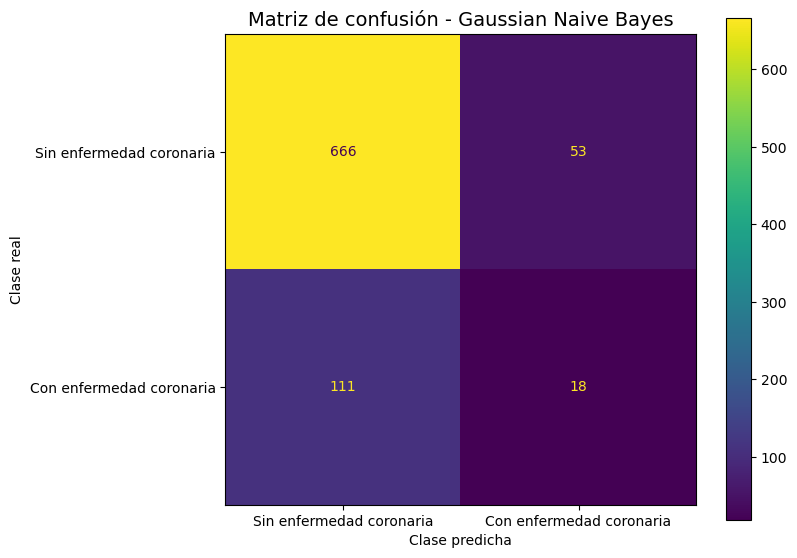


Matriz de confusión generada correctamente.


In [50]:
# ==============================================================
# 1.9.3 - MATRIZ DE CONFUSIÓN DEL MODELO GAUSSIAN NAIVE BAYES
# ==============================================================

print("=" * 65)
print("GENERANDO MATRIZ DE CONFUSIÓN...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular la matriz de confusión
# --------------------------------------------------------------

matriz_gnb = confusion_matrix(
    y_test,
    y_pred_gnb
)


# --------------------------------------------------------------
# Crear la representación gráfica
# --------------------------------------------------------------

display_gnb = ConfusionMatrixDisplay(
    confusion_matrix=matriz_gnb,
    display_labels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ]
)


# --------------------------------------------------------------
# Mostrar la matriz
# --------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

display_gnb.plot(
    ax=ax,
    cmap="viridis",
    values_format="d"
)

plt.title(
    "Matriz de confusión - Gaussian Naive Bayes",
    fontsize=14
)

plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

plt.tight_layout()
plt.show()


print("\nMatriz de confusión generada correctamente.")

GENERANDO CURVA ROC...


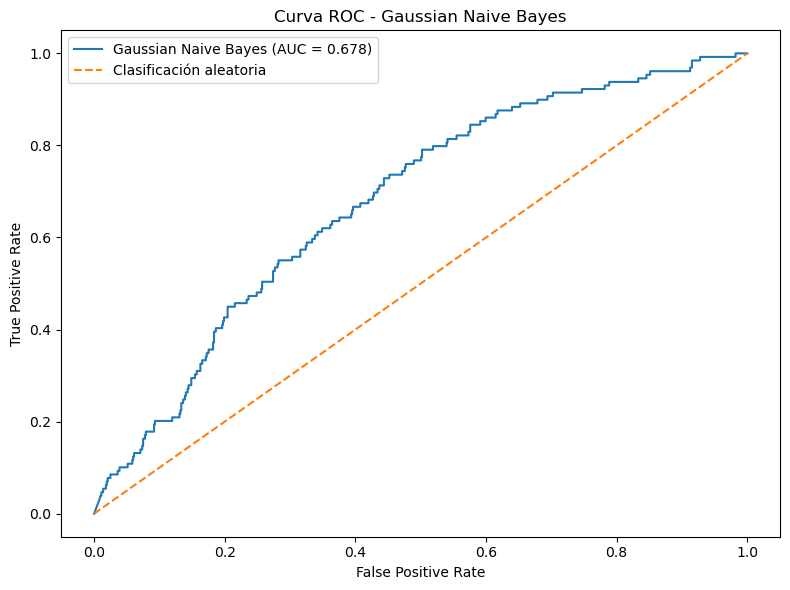


ROC-AUC: 0.6781
Curva ROC generada correctamente.


In [51]:
# ==============================================================
# 1.9.4 - CURVA ROC DEL MODELO GAUSSIAN NAIVE BAYES
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA ROC...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular los valores necesarios para la curva ROC
# --------------------------------------------------------------

fpr_gnb, tpr_gnb, _ = roc_curve(
    y_test,
    y_prob_gnb
)


# --------------------------------------------------------------
# Crear la gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_gnb,
    tpr_gnb,
    label=f"Gaussian Naive Bayes (AUC = {roc_auc_gnb:.3f})"
)

# Línea de clasificación aleatoria
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)


# --------------------------------------------------------------
# Configuración de la gráfica
# --------------------------------------------------------------

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Curva ROC - Gaussian Naive Bayes"
)

plt.legend()

plt.tight_layout()
plt.show()


print(f"\nROC-AUC: {roc_auc_gnb:.4f}")
print("Curva ROC generada correctamente.")

GENERANDO CURVA PRECISION-RECALL...


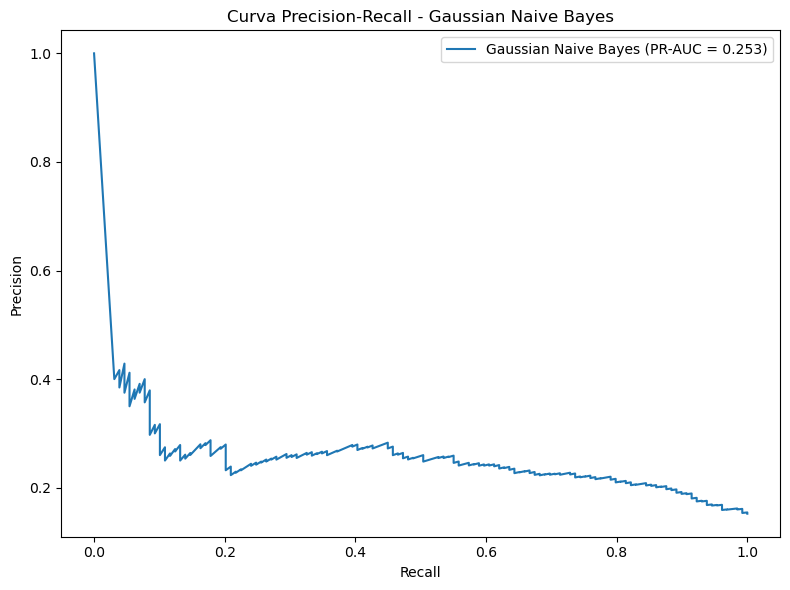


PR-AUC: 0.2527
Curva Precision-Recall generada correctamente.


In [52]:
# ==============================================================
# 1.9.5 - CURVA PRECISION-RECALL DEL MODELO GAUSSIAN NAIVE BAYES
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA PRECISION-RECALL...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular los valores necesarios para la curva Precision-Recall
# --------------------------------------------------------------

precision_gnb_curve, recall_gnb_curve, _ = precision_recall_curve(
    y_test,
    y_prob_gnb
)


# --------------------------------------------------------------
# Crear la gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    recall_gnb_curve,
    precision_gnb_curve,
    label=f"Gaussian Naive Bayes (PR-AUC = {pr_auc_gnb:.3f})"
)


# --------------------------------------------------------------
# Configuración de la gráfica
# --------------------------------------------------------------

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Curva Precision-Recall - Gaussian Naive Bayes"
)

plt.legend()

plt.tight_layout()
plt.show()


print(f"\nPR-AUC: {pr_auc_gnb:.4f}")
print("Curva Precision-Recall generada correctamente.")

In [53]:
# ==============================================================
# 1.9.6 - GUARDAR RESULTADOS EN LA TABLA COMPARATIVA
# ==============================================================


# --------------------------------------------------------------
# Crear una nueva fila con los resultados de Gaussian Naive Bayes
# --------------------------------------------------------------

nuevo_resultado = pd.DataFrame({
    "Modelo": ["Gaussian Naive Bayes"],
    "Accuracy": [accuracy_gnb],
    "Precision": [precision_gnb],
    "Recall": [recall_gnb],
    "F1-score": [f1_gnb],
    "ROC-AUC": [roc_auc_gnb],
    "PR-AUC": [pr_auc_gnb]
})


# --------------------------------------------------------------
# Añadir el resultado a la tabla existente
# --------------------------------------------------------------

resultados_modelos = pd.concat(
    [resultados_modelos, nuevo_resultado],
    ignore_index=True
)


# --------------------------------------------------------------
# Mostrar la tabla actualizada
# --------------------------------------------------------------

print("=" * 65)
print("RESULTADOS ACTUALIZADOS CORRECTAMENTE")
print("=" * 65)

display(resultados_modelos)

RESULTADOS ACTUALIZADOS CORRECTAMENTE


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística,0.844340,0.411765,0.054264,0.095890,0.702774,0.302116
1,Linear Discriminant Analysis (LDA),0.838443,0.346154,0.069767,0.116129,0.700941,0.287816
2,Support Vector Machine (SVM),0.850236,0.750000,0.023256,0.045113,0.542064,0.220860
3,Stochastic Gradient Descent (SGD),0.818396,0.272727,0.116279,0.163043,0.660543,0.242477
4,K-Nearest Neighbors (KNN),0.839623,0.393939,0.100775,0.160494,0.569255,0.205580
5,Gaussian Naive Bayes,0.806604,0.253521,0.139535,0.180000,0.678068,0.252698


In [54]:
# ==============================================================
# 1.10 - DECISION TREE
# PARTE 1: ENTRENAMIENTO DEL MODELO
# ==============================================================

print("=" * 65)
print("1.10 - DECISION TREE")
print("INICIO DE LA FASE DE ENTRENAMIENTO")
print("=" * 65)


# --------------------------------------------------------------
# Importar el algoritmo Decision Tree
# --------------------------------------------------------------

from sklearn.tree import DecisionTreeClassifier


# --------------------------------------------------------------
# Crear el modelo
# --------------------------------------------------------------

modelo_dt = DecisionTreeClassifier(
    random_state=42
)


# --------------------------------------------------------------
# Entrenar el modelo utilizando los datos de entrenamiento
# --------------------------------------------------------------

modelo_dt.fit(
    X_train_scaled,
    y_train
)


print("\nModelo Decision Tree entrenado correctamente.")

1.10 - DECISION TREE
INICIO DE LA FASE DE ENTRENAMIENTO

Modelo Decision Tree entrenado correctamente.


In [55]:
# ==============================================================
# 1.10 - DECISION TREE
# PARTE 2: REALIZACIÓN DE PREDICCIONES
# ==============================================================

print("=" * 65)
print("1.10 - DECISION TREE")
print("INICIO DE LA FASE DE PREDICCIÓN")
print("=" * 65)


# --------------------------------------------------------------
# Predicción de la clase para los pacientes del conjunto de prueba
# --------------------------------------------------------------

y_pred_dt = modelo_dt.predict(X_test_scaled)


# --------------------------------------------------------------
# Calcular la probabilidad de pertenecer a la clase positiva
# TenYearCHD = 1
# --------------------------------------------------------------

y_prob_dt = modelo_dt.predict_proba(X_test_scaled)[:, 1]


print("\nPredicciones realizadas correctamente.")

1.10 - DECISION TREE
INICIO DE LA FASE DE PREDICCIÓN

Predicciones realizadas correctamente.


In [56]:
# ==============================================================
# 1.10.2 - EVALUACIÓN DEL MODELO DECISION TREE
# ==============================================================

print("=" * 65)
print("1.10.2 - EVALUACIÓN DEL MODELO DECISION TREE")
print("=" * 65)


# --------------------------------------------------------------
# Calcular las métricas principales del modelo
# --------------------------------------------------------------

accuracy_dt = accuracy_score(
    y_test,
    y_pred_dt
)

precision_dt = precision_score(
    y_test,
    y_pred_dt,
    zero_division=0
)

recall_dt = recall_score(
    y_test,
    y_pred_dt,
    zero_division=0
)

f1_dt = f1_score(
    y_test,
    y_pred_dt,
    zero_division=0
)


# --------------------------------------------------------------
# Calcular ROC-AUC utilizando las probabilidades estimadas
# --------------------------------------------------------------

roc_auc_dt = roc_auc_score(
    y_test,
    y_prob_dt
)


# --------------------------------------------------------------
# Calcular PR-AUC
# --------------------------------------------------------------

pr_auc_dt = average_precision_score(
    y_test,
    y_prob_dt
)


# --------------------------------------------------------------
# Mostrar los resultados
# --------------------------------------------------------------

print(f"\nAccuracy:  {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall:    {recall_dt:.4f}")
print(f"F1-score:  {f1_dt:.4f}")
print(f"ROC-AUC:   {roc_auc_dt:.4f}")
print(f"PR-AUC:    {pr_auc_dt:.4f}")

print("\nEvaluación completada correctamente.")

1.10.2 - EVALUACIÓN DEL MODELO DECISION TREE

Accuracy:  0.7500
Precision: 0.1783
Recall:    0.1783
F1-score:  0.1783
ROC-AUC:   0.5154
PR-AUC:    0.1568

Evaluación completada correctamente.


GENERANDO MATRIZ DE CONFUSIÓN...


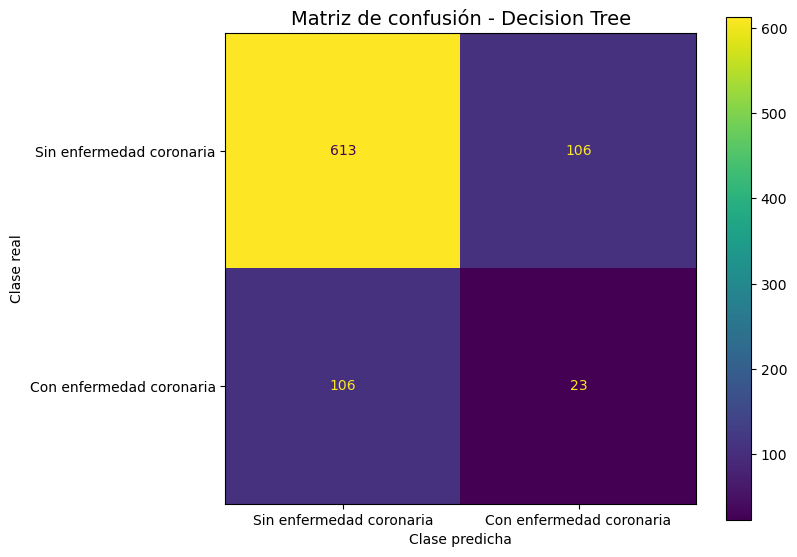


Matriz de confusión generada correctamente.


In [57]:
# ==============================================================
# 1.10.3 - MATRIZ DE CONFUSIÓN DEL MODELO DECISION TREE
# ==============================================================

print("=" * 65)
print("GENERANDO MATRIZ DE CONFUSIÓN...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular la matriz de confusión
# --------------------------------------------------------------

matriz_dt = confusion_matrix(
    y_test,
    y_pred_dt
)


# --------------------------------------------------------------
# Crear la representación gráfica
# --------------------------------------------------------------

display_dt = ConfusionMatrixDisplay(
    confusion_matrix=matriz_dt,
    display_labels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ]
)


# --------------------------------------------------------------
# Mostrar la matriz
# --------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

display_dt.plot(
    ax=ax,
    cmap="viridis",
    values_format="d"
)

plt.title(
    "Matriz de confusión - Decision Tree",
    fontsize=14
)

plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

plt.tight_layout()
plt.show()


print("\nMatriz de confusión generada correctamente.")

GENERANDO CURVA ROC...


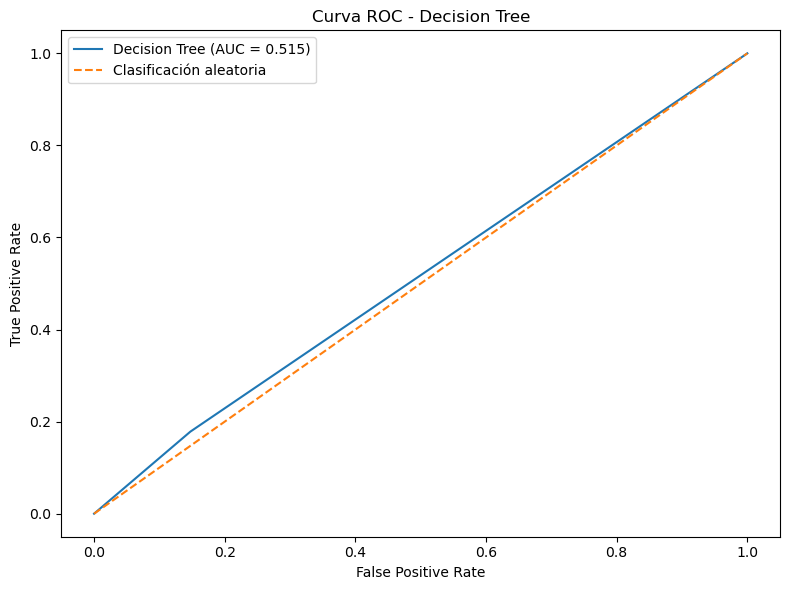


ROC-AUC: 0.5154
Curva ROC generada correctamente.


In [58]:
# ==============================================================
# 1.10.4 - CURVA ROC DEL MODELO DECISION TREE
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA ROC...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular los valores necesarios para la curva ROC
# --------------------------------------------------------------

fpr_dt, tpr_dt, _ = roc_curve(
    y_test,
    y_prob_dt
)


# --------------------------------------------------------------
# Crear la gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {roc_auc_dt:.3f})"
)


# Línea de clasificación aleatoria
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)


# --------------------------------------------------------------
# Configuración de la gráfica
# --------------------------------------------------------------

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Curva ROC - Decision Tree")

plt.legend()

plt.tight_layout()
plt.show()


print(f"\nROC-AUC: {roc_auc_dt:.4f}")
print("Curva ROC generada correctamente.")

GENERANDO CURVA PRECISION-RECALL...


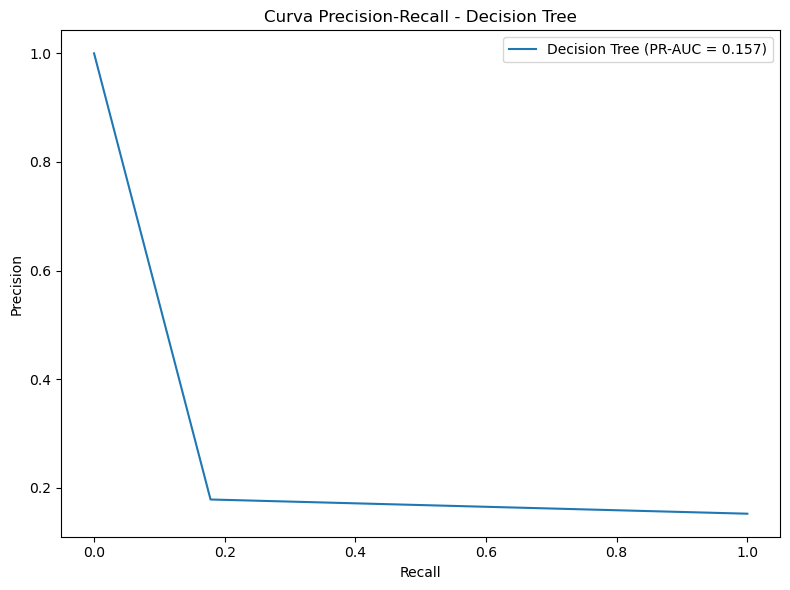


PR-AUC: 0.1568
Curva Precision-Recall generada correctamente.


In [59]:
# ==============================================================
# 1.10.5 - CURVA PRECISION-RECALL DEL MODELO DECISION TREE
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA PRECISION-RECALL...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular los valores necesarios para la curva Precision-Recall
# --------------------------------------------------------------

precision_dt_curve, recall_dt_curve, _ = precision_recall_curve(
    y_test,
    y_prob_dt
)


# --------------------------------------------------------------
# Crear la gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    recall_dt_curve,
    precision_dt_curve,
    label=f"Decision Tree (PR-AUC = {pr_auc_dt:.3f})"
)


# --------------------------------------------------------------
# Configuración de la gráfica
# --------------------------------------------------------------

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Curva Precision-Recall - Decision Tree"
)

plt.legend()

plt.tight_layout()
plt.show()


print(f"\nPR-AUC: {pr_auc_dt:.4f}")
print("Curva Precision-Recall generada correctamente.")

In [60]:
# ==============================================================
# 1.10.6 - GUARDAR RESULTADOS EN LA TABLA COMPARATIVA
# ==============================================================


# --------------------------------------------------------------
# Crear una nueva fila con los resultados del Decision Tree
# --------------------------------------------------------------

nuevo_resultado = pd.DataFrame({
    "Modelo": ["Decision Tree"],
    "Accuracy": [accuracy_dt],
    "Precision": [precision_dt],
    "Recall": [recall_dt],
    "F1-score": [f1_dt],
    "ROC-AUC": [roc_auc_dt],
    "PR-AUC": [pr_auc_dt]
})


# --------------------------------------------------------------
# Añadir el resultado a la tabla existente
# --------------------------------------------------------------

resultados_modelos = pd.concat(
    [resultados_modelos, nuevo_resultado],
    ignore_index=True
)


# --------------------------------------------------------------
# Mostrar la tabla actualizada
# --------------------------------------------------------------

print("=" * 65)
print("RESULTADOS ACTUALIZADOS CORRECTAMENTE")
print("=" * 65)

display(resultados_modelos)

RESULTADOS ACTUALIZADOS CORRECTAMENTE


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística,0.844340,0.411765,0.054264,0.095890,0.702774,0.302116
1,Linear Discriminant Analysis (LDA),0.838443,0.346154,0.069767,0.116129,0.700941,0.287816
2,Support Vector Machine (SVM),0.850236,0.750000,0.023256,0.045113,0.542064,0.220860
3,Stochastic Gradient Descent (SGD),0.818396,0.272727,0.116279,0.163043,0.660543,0.242477
4,K-Nearest Neighbors (KNN),0.839623,0.393939,0.100775,0.160494,0.569255,0.205580
5,Gaussian Naive Bayes,0.806604,0.253521,0.139535,0.180000,0.678068,0.252698
6,Decision Tree,0.750000,0.178295,0.178295,0.178295,0.515434,0.156789


GENERANDO VISUALIZACIÓN DEL DECISION TREE...


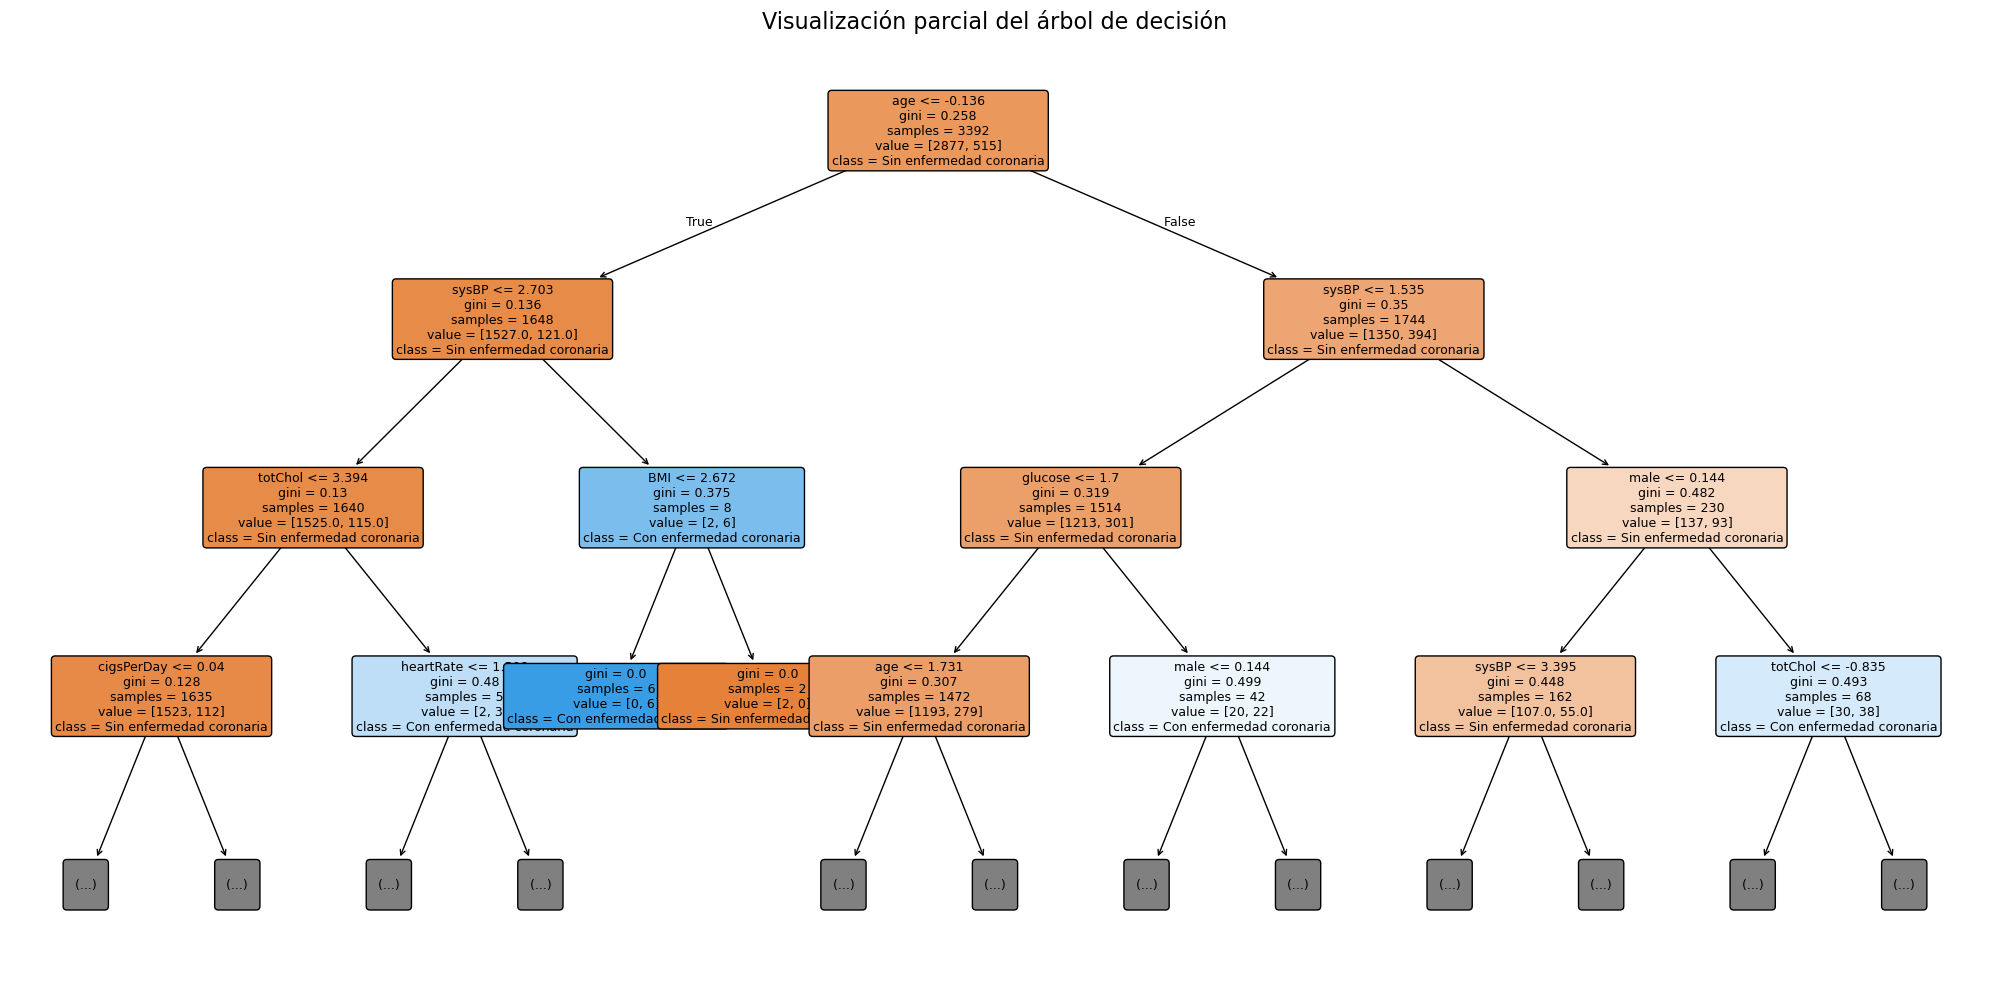


Árbol de decisión visualizado correctamente.


In [61]:
# ==============================================================
# 1.10.7 - VISUALIZACIÓN DEL MODELO DECISION TREE
# ==============================================================

print("=" * 65)
print("GENERANDO VISUALIZACIÓN DEL DECISION TREE...")
print("=" * 65)


# --------------------------------------------------------------
# Importar la función necesaria para visualizar el árbol
# --------------------------------------------------------------

from sklearn.tree import plot_tree


# --------------------------------------------------------------
# Crear la figura
# --------------------------------------------------------------

plt.figure(figsize=(20, 10))


# --------------------------------------------------------------
# Visualizar el árbol
#
# max_depth=3 muestra únicamente los primeros niveles para que
# la figura sea comprensible y pueda utilizarse en el TFM.
# --------------------------------------------------------------

plot_tree(
    modelo_dt,
    max_depth=3,
    feature_names=X_train.columns,
    class_names=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ],
    filled=True,
    rounded=True,
    fontsize=9
)


# --------------------------------------------------------------
# Añadir título
# --------------------------------------------------------------

plt.title(
    "Visualización parcial del árbol de decisión",
    fontsize=16
)

plt.tight_layout()
plt.show()


print("\nÁrbol de decisión visualizado correctamente.")

In [62]:
# ==============================================================
# 1.11 - RANDOM FOREST
# PARTE 1: ENTRENAMIENTO DEL MODELO
# ==============================================================

print("=" * 65)
print("1.11 - RANDOM FOREST")
print("INICIO DE LA FASE DE ENTRENAMIENTO")
print("=" * 65)


# --------------------------------------------------------------
# Importar el algoritmo Random Forest
# --------------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier


# --------------------------------------------------------------
# Crear el modelo
# --------------------------------------------------------------

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


# --------------------------------------------------------------
# Entrenar el modelo utilizando los datos de entrenamiento
# --------------------------------------------------------------

modelo_rf.fit(
    X_train_scaled,
    y_train
)


print("\nModelo Random Forest entrenado correctamente.")

1.11 - RANDOM FOREST
INICIO DE LA FASE DE ENTRENAMIENTO

Modelo Random Forest entrenado correctamente.


In [63]:
# ==============================================================
# 1.11 - RANDOM FOREST
# PARTE 2: REALIZACIÓN DE PREDICCIONES
# ==============================================================

print("=" * 65)
print("1.11 - RANDOM FOREST")
print("INICIO DE LA FASE DE PREDICCIÓN")
print("=" * 65)


# --------------------------------------------------------------
# Predicción de la clase para los pacientes del conjunto de prueba
# --------------------------------------------------------------

y_pred_rf = modelo_rf.predict(X_test_scaled)


# --------------------------------------------------------------
# Calcular la probabilidad de pertenecer a la clase positiva
# TenYearCHD = 1
# --------------------------------------------------------------

y_prob_rf = modelo_rf.predict_proba(X_test_scaled)[:, 1]


print("\nPredicciones realizadas correctamente.")

1.11 - RANDOM FOREST
INICIO DE LA FASE DE PREDICCIÓN

Predicciones realizadas correctamente.


In [64]:
# ==============================================================
# 1.11.2 - EVALUACIÓN DEL MODELO RANDOM FOREST
# ==============================================================

print("=" * 65)
print("1.11.2 - EVALUACIÓN DEL MODELO RANDOM FOREST")
print("=" * 65)


# --------------------------------------------------------------
# Calcular las métricas principales del modelo
# --------------------------------------------------------------

accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    zero_division=0
)


# --------------------------------------------------------------
# Calcular ROC-AUC utilizando las probabilidades estimadas
# --------------------------------------------------------------

roc_auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)


# --------------------------------------------------------------
# Calcular PR-AUC
# --------------------------------------------------------------

pr_auc_rf = average_precision_score(
    y_test,
    y_prob_rf
)


# --------------------------------------------------------------
# Mostrar los resultados
# --------------------------------------------------------------

print(f"\nAccuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-score:  {f1_rf:.4f}")
print(f"ROC-AUC:   {roc_auc_rf:.4f}")
print(f"PR-AUC:    {pr_auc_rf:.4f}")

print("\nEvaluación completada correctamente.")

1.11.2 - EVALUACIÓN DEL MODELO RANDOM FOREST

Accuracy:  0.8443
Precision: 0.4211
Recall:    0.0620
F1-score:  0.1081
ROC-AUC:   0.6328
PR-AUC:    0.2460

Evaluación completada correctamente.


GENERANDO MATRIZ DE CONFUSIÓN...


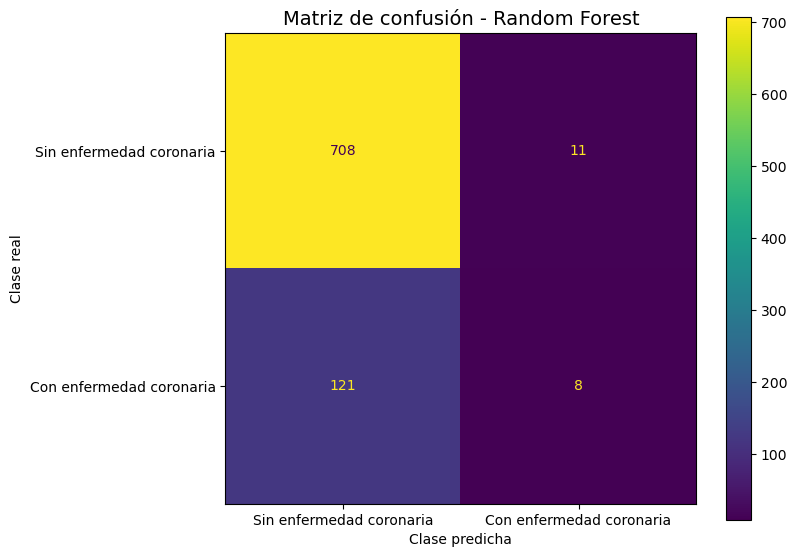


Matriz de confusión generada correctamente.


In [65]:
# ==============================================================
# 1.11.3 - MATRIZ DE CONFUSIÓN DEL MODELO RANDOM FOREST
# ==============================================================

print("=" * 65)
print("GENERANDO MATRIZ DE CONFUSIÓN...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular la matriz de confusión
# --------------------------------------------------------------

matriz_rf = confusion_matrix(
    y_test,
    y_pred_rf
)


# --------------------------------------------------------------
# Crear la representación gráfica
# --------------------------------------------------------------

display_rf = ConfusionMatrixDisplay(
    confusion_matrix=matriz_rf,
    display_labels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ]
)


# --------------------------------------------------------------
# Mostrar la matriz
# --------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

display_rf.plot(
    ax=ax,
    cmap="viridis",
    values_format="d"
)

plt.title(
    "Matriz de confusión - Random Forest",
    fontsize=14
)

plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

plt.tight_layout()
plt.show()


print("\nMatriz de confusión generada correctamente.")

GENERANDO CURVA ROC...


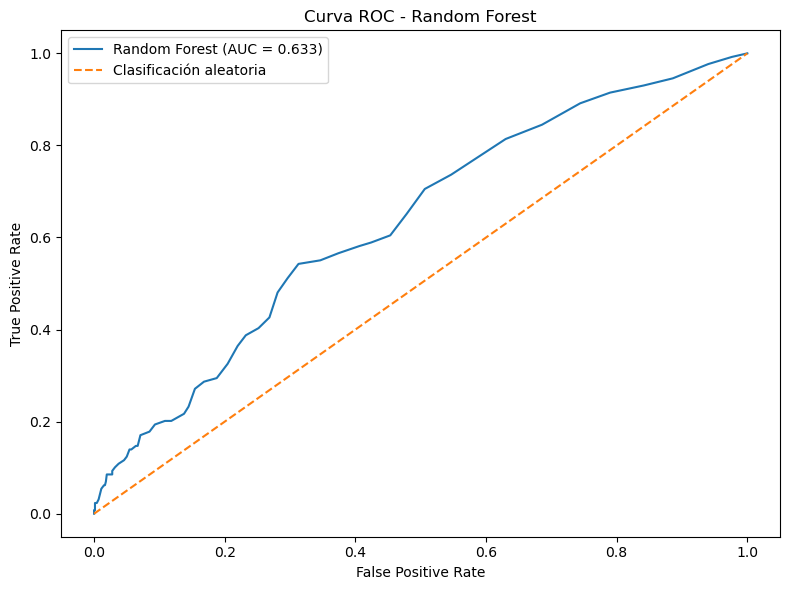


ROC-AUC: 0.6328
Curva ROC generada correctamente.


In [66]:
# ==============================================================
# 1.11.4 - CURVA ROC DEL MODELO RANDOM FOREST
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA ROC...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular los valores necesarios para la curva ROC
# --------------------------------------------------------------

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)


# --------------------------------------------------------------
# Crear la gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_rf:.3f})"
)


# Línea de clasificación aleatoria
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)


# --------------------------------------------------------------
# Configuración de la gráfica
# --------------------------------------------------------------

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Curva ROC - Random Forest"
)

plt.legend()

plt.tight_layout()
plt.show()


print(f"\nROC-AUC: {roc_auc_rf:.4f}")
print("Curva ROC generada correctamente.")

GENERANDO CURVA PRECISION-RECALL...


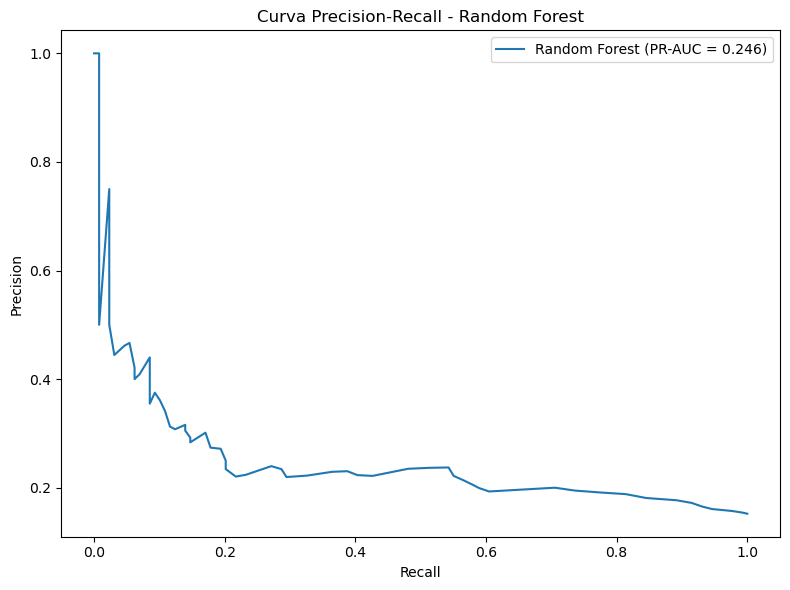


PR-AUC: 0.2460
Curva Precision-Recall generada correctamente.


In [67]:
# ==============================================================
# 1.11.5 - CURVA PRECISION-RECALL DEL MODELO RANDOM FOREST
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA PRECISION-RECALL...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular los valores necesarios para la curva Precision-Recall
# --------------------------------------------------------------

precision_curve_rf, recall_curve_rf, _ = precision_recall_curve(
    y_test,
    y_prob_rf
)


# --------------------------------------------------------------
# Crear la gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve_rf,
    precision_curve_rf,
    label=f"Random Forest (PR-AUC = {pr_auc_rf:.3f})"
)


# --------------------------------------------------------------
# Configuración de la gráfica
# --------------------------------------------------------------

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Curva Precision-Recall - Random Forest"
)

plt.legend()

plt.tight_layout()
plt.show()


print(f"\nPR-AUC: {pr_auc_rf:.4f}")
print("Curva Precision-Recall generada correctamente.")

In [68]:
# ==============================================================
# 1.11.6 - RANDOM FOREST
# GUARDAR RESULTADOS EN LA TABLA COMPARATIVA
# ==============================================================

import pandas as pd


# --------------------------------------------------------------
# Crear una nueva fila con los resultados de Random Forest
# --------------------------------------------------------------

nuevo_resultado = pd.DataFrame({
    "Modelo": ["Random Forest"],
    "Accuracy": [accuracy_rf],
    "Precision": [precision_rf],
    "Recall": [recall_rf],
    "F1-score": [f1_rf],
    "ROC-AUC": [roc_auc_rf],
    "PR-AUC": [pr_auc_rf]
})


# --------------------------------------------------------------
# Añadir el resultado a la tabla existente
# --------------------------------------------------------------

resultados_modelos = pd.concat(
    [resultados_modelos, nuevo_resultado],
    ignore_index=True
)


# --------------------------------------------------------------
# Mostrar la tabla actualizada
# --------------------------------------------------------------

print("=" * 65)
print("RESULTADOS ACTUALIZADOS CORRECTAMENTE")
print("=" * 65)

display(resultados_modelos)

RESULTADOS ACTUALIZADOS CORRECTAMENTE


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística,0.844340,0.411765,0.054264,0.095890,0.702774,0.302116
1,Linear Discriminant Analysis (LDA),0.838443,0.346154,0.069767,0.116129,0.700941,0.287816
2,Support Vector Machine (SVM),0.850236,0.750000,0.023256,0.045113,0.542064,0.220860
3,Stochastic Gradient Descent (SGD),0.818396,0.272727,0.116279,0.163043,0.660543,0.242477
4,K-Nearest Neighbors (KNN),0.839623,0.393939,0.100775,0.160494,0.569255,0.205580
5,Gaussian Naive Bayes,0.806604,0.253521,0.139535,0.180000,0.678068,0.252698
6,Decision Tree,0.750000,0.178295,0.178295,0.178295,0.515434,0.156789
7,Random Forest,0.844340,0.421053,0.062016,0.108108,0.632753,0.245967


In [69]:
# ==============================================================
# 1.12 - GRADIENT BOOSTING
# PARTE 1: ENTRENAMIENTO DEL MODELO
# ==============================================================

print("=" * 65)
print("1.12 - GRADIENT BOOSTING")
print("INICIO DE LA FASE DE ENTRENAMIENTO")
print("=" * 65)


# --------------------------------------------------------------
# Importar el algoritmo Gradient Boosting
# --------------------------------------------------------------

from sklearn.ensemble import GradientBoostingClassifier


# --------------------------------------------------------------
# Crear el modelo
# --------------------------------------------------------------

modelo_gb = GradientBoostingClassifier(
    random_state=42
)


# --------------------------------------------------------------
# Entrenar el modelo utilizando los datos de entrenamiento
# --------------------------------------------------------------

modelo_gb.fit(
    X_train_scaled,
    y_train
)


print("\nModelo Gradient Boosting entrenado correctamente.")

1.12 - GRADIENT BOOSTING
INICIO DE LA FASE DE ENTRENAMIENTO

Modelo Gradient Boosting entrenado correctamente.


In [70]:
# ==============================================================
# 1.12 - GRADIENT BOOSTING
# PARTE 2: REALIZACIÓN DE PREDICCIONES
# ==============================================================

print("=" * 65)
print("1.12 - GRADIENT BOOSTING")
print("INICIO DE LA FASE DE PREDICCIÓN")
print("=" * 65)


# --------------------------------------------------------------
# Predicción de la clase para los pacientes del conjunto de prueba
# --------------------------------------------------------------

y_pred_gb = modelo_gb.predict(
    X_test_scaled
)


# --------------------------------------------------------------
# Calcular la probabilidad de pertenecer a la clase positiva
# TenYearCHD = 1
# --------------------------------------------------------------

y_prob_gb = modelo_gb.predict_proba(
    X_test_scaled
)[:, 1]


print("\nPredicciones realizadas correctamente.")

1.12 - GRADIENT BOOSTING
INICIO DE LA FASE DE PREDICCIÓN

Predicciones realizadas correctamente.


In [71]:
# ==============================================================
# 1.12.2 - EVALUACIÓN DEL MODELO GRADIENT BOOSTING
# ==============================================================

print("=" * 65)
print("1.12.2 - EVALUACIÓN DEL MODELO GRADIENT BOOSTING")
print("=" * 65)


# --------------------------------------------------------------
# Calcular las métricas principales del modelo
# --------------------------------------------------------------

accuracy_gb = accuracy_score(
    y_test,
    y_pred_gb
)

precision_gb = precision_score(
    y_test,
    y_pred_gb,
    zero_division=0
)

recall_gb = recall_score(
    y_test,
    y_pred_gb,
    zero_division=0
)

f1_gb = f1_score(
    y_test,
    y_pred_gb,
    zero_division=0
)


# --------------------------------------------------------------
# Calcular ROC-AUC utilizando las probabilidades estimadas
# --------------------------------------------------------------

roc_auc_gb = roc_auc_score(
    y_test,
    y_prob_gb
)


# --------------------------------------------------------------
# Calcular PR-AUC
# --------------------------------------------------------------

pr_auc_gb = average_precision_score(
    y_test,
    y_prob_gb
)


# --------------------------------------------------------------
# Mostrar los resultados
# --------------------------------------------------------------

print(f"\nAccuracy:  {accuracy_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall:    {recall_gb:.4f}")
print(f"F1-score:  {f1_gb:.4f}")
print(f"ROC-AUC:   {roc_auc_gb:.4f}")
print(f"PR-AUC:    {pr_auc_gb:.4f}")

print("\nEvaluación completada correctamente.")

1.12.2 - EVALUACIÓN DEL MODELO GRADIENT BOOSTING

Accuracy:  0.8396
Precision: 0.3704
Recall:    0.0775
F1-score:  0.1282
ROC-AUC:   0.6631
PR-AUC:    0.2589

Evaluación completada correctamente.


GENERANDO MATRIZ DE CONFUSIÓN...


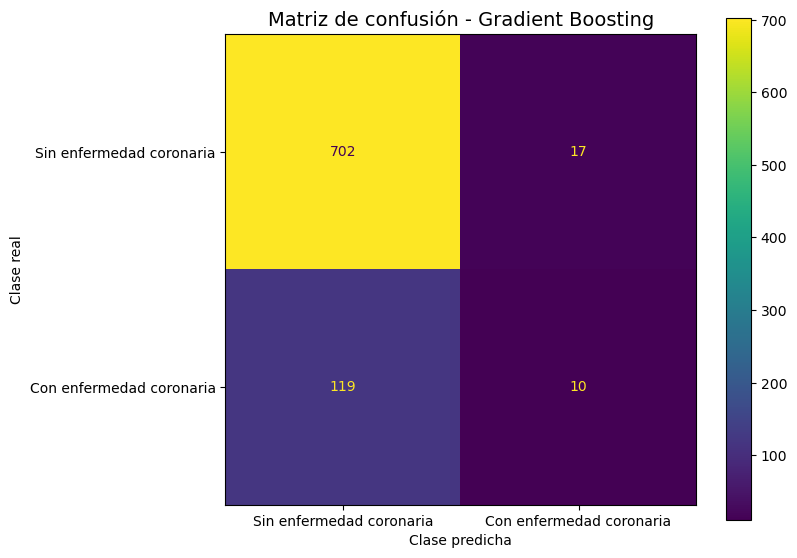


Matriz de confusión generada correctamente.


In [72]:
# ==============================================================
# 1.12.3 - MATRIZ DE CONFUSIÓN DEL MODELO GRADIENT BOOSTING
# ==============================================================

print("=" * 65)
print("GENERANDO MATRIZ DE CONFUSIÓN...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular la matriz de confusión
# --------------------------------------------------------------

matriz_gb = confusion_matrix(
    y_test,
    y_pred_gb
)


# --------------------------------------------------------------
# Crear la representación gráfica
# --------------------------------------------------------------

display_gb = ConfusionMatrixDisplay(
    confusion_matrix=matriz_gb,
    display_labels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ]
)


# --------------------------------------------------------------
# Mostrar la matriz
# --------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

display_gb.plot(
    ax=ax,
    cmap="viridis",
    values_format="d"
)

plt.title(
    "Matriz de confusión - Gradient Boosting",
    fontsize=14
)

plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

plt.tight_layout()
plt.show()


print("\nMatriz de confusión generada correctamente.")

GENERANDO CURVA ROC...


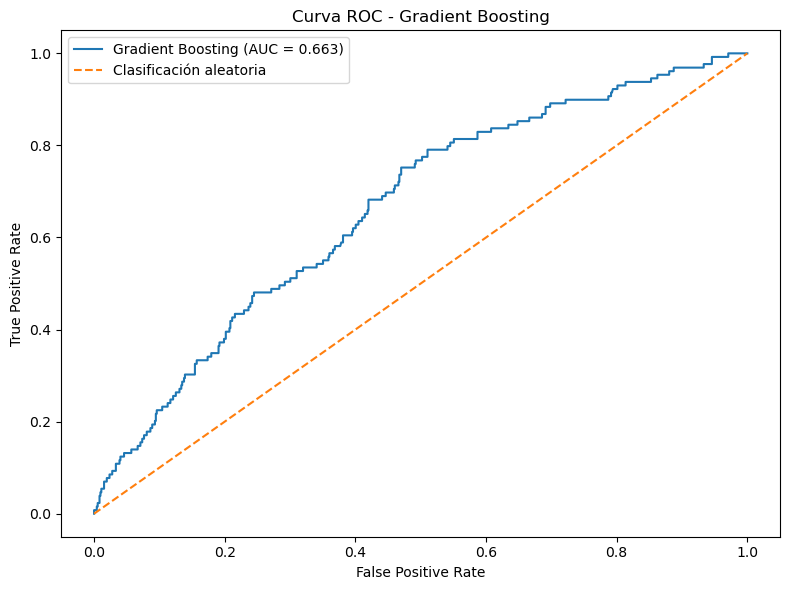


ROC-AUC: 0.6631
Curva ROC generada correctamente.


In [73]:
# ==============================================================
# 1.12.4 - CURVA ROC DEL MODELO GRADIENT BOOSTING
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA ROC...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular los valores necesarios para la curva ROC
# --------------------------------------------------------------

fpr_gb, tpr_gb, _ = roc_curve(
    y_test,
    y_prob_gb
)


# --------------------------------------------------------------
# Crear la gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_gb,
    tpr_gb,
    label=f"Gradient Boosting (AUC = {roc_auc_gb:.3f})"
)


# Línea de clasificación aleatoria
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)


# --------------------------------------------------------------
# Configuración de la gráfica
# --------------------------------------------------------------

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Curva ROC - Gradient Boosting")

plt.legend()

plt.tight_layout()
plt.show()


print(f"\nROC-AUC: {roc_auc_gb:.4f}")
print("Curva ROC generada correctamente.")

GENERANDO CURVA PRECISION-RECALL...


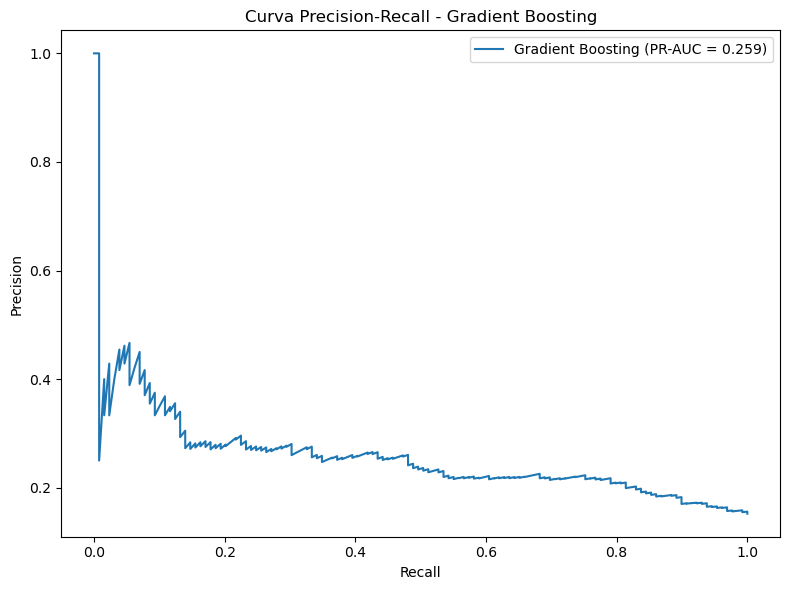


PR-AUC: 0.2589
Curva Precision-Recall generada correctamente.


In [74]:
# ==============================================================
# 1.12.5 - CURVA PRECISION-RECALL DEL MODELO GRADIENT BOOSTING
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA PRECISION-RECALL...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular los valores necesarios
# --------------------------------------------------------------

precision_gb_curve, recall_gb_curve, _ = precision_recall_curve(
    y_test,
    y_prob_gb
)


# --------------------------------------------------------------
# Crear la gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    recall_gb_curve,
    precision_gb_curve,
    label=f"Gradient Boosting (PR-AUC = {pr_auc_gb:.3f})"
)


# --------------------------------------------------------------
# Configuración de la gráfica
# --------------------------------------------------------------

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Curva Precision-Recall - Gradient Boosting")

plt.legend()

plt.tight_layout()
plt.show()


print(f"\nPR-AUC: {pr_auc_gb:.4f}")
print("Curva Precision-Recall generada correctamente.")

In [75]:
# ==============================================================
# 1.12.6 - GUARDAR RESULTADOS EN LA TABLA COMPARATIVA
# ==============================================================

import pandas as pd


# Crear una nueva fila con los resultados de Gradient Boosting
nuevo_resultado = pd.DataFrame({
    "Modelo": ["Gradient Boosting"],
    "Accuracy": [accuracy_gb],
    "Precision": [precision_gb],
    "Recall": [recall_gb],
    "F1-score": [f1_gb],
    "ROC-AUC": [roc_auc_gb],
    "PR-AUC": [pr_auc_gb]
})


# Añadir el resultado a la tabla existente
resultados_modelos = pd.concat(
    [resultados_modelos, nuevo_resultado],
    ignore_index=True
)


# Mostrar la tabla actualizada
print("=" * 65)
print("RESULTADOS ACTUALIZADOS CORRECTAMENTE")
print("=" * 65)

display(resultados_modelos)

RESULTADOS ACTUALIZADOS CORRECTAMENTE


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística,0.844340,0.411765,0.054264,0.095890,0.702774,0.302116
1,Linear Discriminant Analysis (LDA),0.838443,0.346154,0.069767,0.116129,0.700941,0.287816
2,Support Vector Machine (SVM),0.850236,0.750000,0.023256,0.045113,0.542064,0.220860
3,Stochastic Gradient Descent (SGD),0.818396,0.272727,0.116279,0.163043,0.660543,0.242477
4,K-Nearest Neighbors (KNN),0.839623,0.393939,0.100775,0.160494,0.569255,0.205580
5,Gaussian Naive Bayes,0.806604,0.253521,0.139535,0.180000,0.678068,0.252698
6,Decision Tree,0.750000,0.178295,0.178295,0.178295,0.515434,0.156789
7,Random Forest,0.844340,0.421053,0.062016,0.108108,0.632753,0.245967
8,Gradient Boosting,0.839623,0.370370,0.077519,0.128205,0.663130,0.258935


In [76]:
# ==============================================================
# 1.13 - ADABOOST
# INICIO DE LA FASE DE ENTRENAMIENTO
# ==============================================================

print("=" * 65)
print("1.13 - ADABOOST")
print("INICIO DE LA FASE DE ENTRENAMIENTO")
print("=" * 65)


# --------------------------------------------------------------
# Importar el modelo
# --------------------------------------------------------------

from sklearn.ensemble import AdaBoostClassifier


# --------------------------------------------------------------
# Crear el modelo
# --------------------------------------------------------------

modelo_ada = AdaBoostClassifier(
    random_state=42
)


# --------------------------------------------------------------
# Entrenar el modelo utilizando los datos de entrenamiento
# --------------------------------------------------------------

modelo_ada.fit(
    X_train_scaled,
    y_train
)


print("\nModelo AdaBoost entrenado correctamente.")

1.13 - ADABOOST
INICIO DE LA FASE DE ENTRENAMIENTO

Modelo AdaBoost entrenado correctamente.


In [77]:
# ==============================================================
# 1.13 - ADABOOST
# INICIO DE LA FASE DE PREDICCIÓN
# ==============================================================

print("=" * 65)
print("1.13 - ADABOOST")
print("INICIO DE LA FASE DE PREDICCIÓN")
print("=" * 65)


# --------------------------------------------------------------
# Realizar las predicciones sobre los datos de prueba
# --------------------------------------------------------------

y_pred_ada = modelo_ada.predict(
    X_test_scaled
)


# --------------------------------------------------------------
# Obtener las probabilidades de pertenecer a la clase positiva
# --------------------------------------------------------------

y_prob_ada = modelo_ada.predict_proba(
    X_test_scaled
)[:, 1]


print("\nPredicciones realizadas correctamente.")

1.13 - ADABOOST
INICIO DE LA FASE DE PREDICCIÓN

Predicciones realizadas correctamente.


In [78]:
# ==============================================================
# 1.13.2 - EVALUACIÓN DEL MODELO ADABOOST
# ==============================================================

print("=" * 65)
print("1.13.2 - EVALUACIÓN DEL MODELO ADABOOST")
print("=" * 65)


# --------------------------------------------------------------
# Importar las métricas necesarias
# --------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)


# --------------------------------------------------------------
# Calcular las métricas
# --------------------------------------------------------------

accuracy_ada = accuracy_score(
    y_test,
    y_pred_ada
)

precision_ada = precision_score(
    y_test,
    y_pred_ada,
    zero_division=0
)

recall_ada = recall_score(
    y_test,
    y_pred_ada,
    zero_division=0
)

f1_ada = f1_score(
    y_test,
    y_pred_ada,
    zero_division=0
)

roc_auc_ada = roc_auc_score(
    y_test,
    y_prob_ada
)

pr_auc_ada = average_precision_score(
    y_test,
    y_prob_ada
)


# --------------------------------------------------------------
# Mostrar los resultados
# --------------------------------------------------------------

print(f"\nAccuracy:  {accuracy_ada:.4f}")
print(f"Precision: {precision_ada:.4f}")
print(f"Recall:    {recall_ada:.4f}")
print(f"F1-score:  {f1_ada:.4f}")
print(f"ROC-AUC:   {roc_auc_ada:.4f}")
print(f"PR-AUC:    {pr_auc_ada:.4f}")

print("\nEvaluación completada correctamente.")

1.13.2 - EVALUACIÓN DEL MODELO ADABOOST

Accuracy:  0.8502
Precision: 0.6250
Recall:    0.0388
F1-score:  0.0730
ROC-AUC:   0.6820
PR-AUC:    0.2970

Evaluación completada correctamente.


GENERANDO MATRIZ DE CONFUSIÓN...


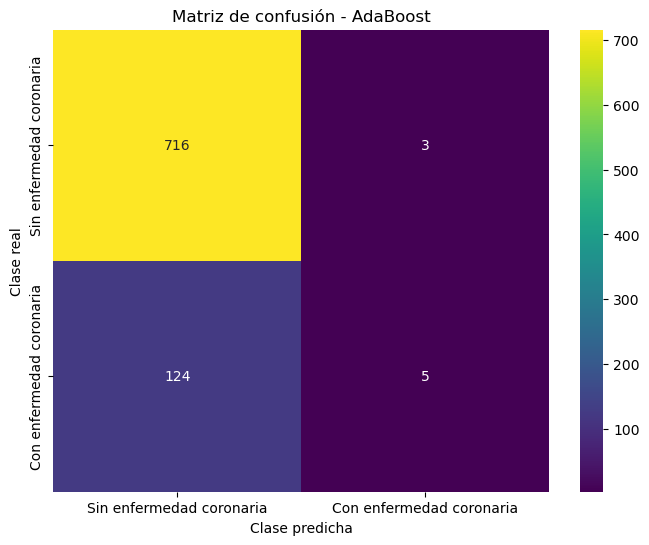


Matriz de confusión generada correctamente.


In [79]:
# ==============================================================
# GENERANDO MATRIZ DE CONFUSIÓN
# ==============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


print("=" * 65)
print("GENERANDO MATRIZ DE CONFUSIÓN...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular matriz de confusión
# --------------------------------------------------------------

matriz_confusion_ada = confusion_matrix(
    y_test,
    y_pred_ada
)


# --------------------------------------------------------------
# Visualizar matriz de confusión
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_confusion_ada,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ],
    yticklabels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ]
)

plt.title("Matriz de confusión - AdaBoost")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

plt.show()


print("\nMatriz de confusión generada correctamente.")

GENERANDO CURVA ROC...


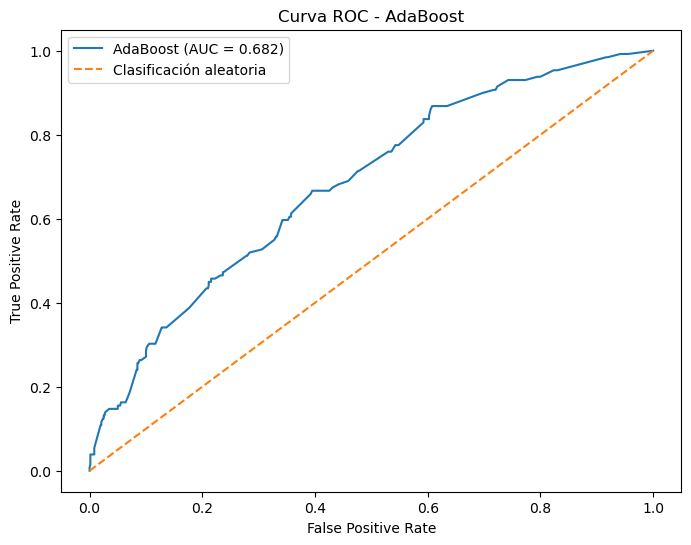


ROC-AUC: 0.6820
Curva ROC generada correctamente.


In [80]:
# ==============================================================
# GENERANDO CURVA ROC
# ==============================================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


print("=" * 65)
print("GENERANDO CURVA ROC...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular los valores necesarios para la curva ROC
# --------------------------------------------------------------

fpr_ada, tpr_ada, _ = roc_curve(
    y_test,
    y_prob_ada
)


# --------------------------------------------------------------
# Crear la gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_ada,
    tpr_ada,
    label=f"AdaBoost (AUC = {roc_auc_ada:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - AdaBoost")
plt.legend()

plt.show()


print(f"\nROC-AUC: {roc_auc_ada:.4f}")
print("Curva ROC generada correctamente.")

GENERANDO CURVA PRECISION-RECALL...


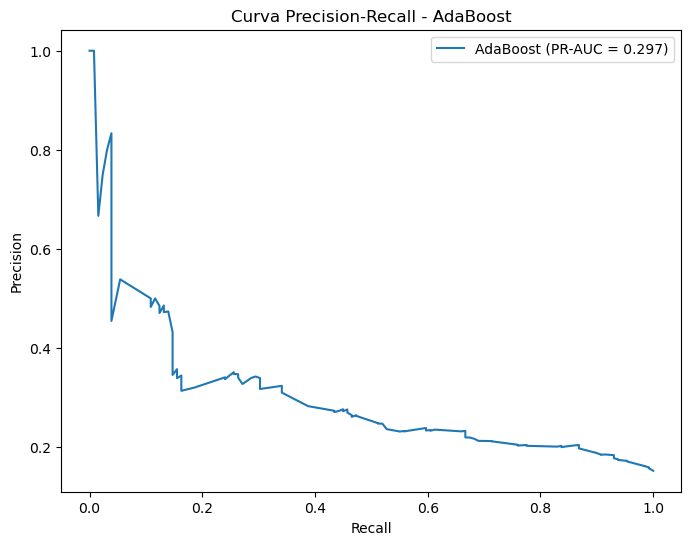


PR-AUC: 0.2970
Curva Precision-Recall generada correctamente.


In [81]:
# ==============================================================
# GENERANDO CURVA PRECISION-RECALL
# ==============================================================

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt


print("=" * 65)
print("GENERANDO CURVA PRECISION-RECALL...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular los valores necesarios
# --------------------------------------------------------------

precision_ada_curve, recall_ada_curve, _ = precision_recall_curve(
    y_test,
    y_prob_ada
)


# --------------------------------------------------------------
# Crear la gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    recall_ada_curve,
    precision_ada_curve,
    label=f"AdaBoost (PR-AUC = {pr_auc_ada:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - AdaBoost")
plt.legend()

plt.show()


print(f"\nPR-AUC: {pr_auc_ada:.4f}")
print("Curva Precision-Recall generada correctamente.")

In [82]:
# ==============================================================
# TABLA COMPARATIVA DE RESULTADOS
# ==============================================================

import pandas as pd

resultados = pd.DataFrame([
    
    ["Regresión Logística",
     accuracy_lr,
     precision_lr,
     recall_lr,
     f1_lr,
     roc_auc_lr,
     pr_auc_lr],
    
    ["Linear Discriminant Analysis (LDA)",
     accuracy_lda,
     precision_lda,
     recall_lda,
     f1_lda,
     roc_auc_lda,
     pr_auc_lda],
    
    ["Support Vector Machine (SVM)",
     accuracy_svm,
     precision_svm,
     recall_svm,
     f1_svm,
     roc_auc_svm,
     pr_auc_svm],
    
    ["Stochastic Gradient Descent (SGD)",
     accuracy_sgd,
     precision_sgd,
     recall_sgd,
     f1_sgd,
     roc_auc_sgd,
     pr_auc_sgd],
    
    ["K-Nearest Neighbors (KNN)",
     accuracy_knn,
     precision_knn,
     recall_knn,
     f1_knn,
     roc_auc_knn,
     pr_auc_knn],
    
    ["Gaussian Naive Bayes",
     accuracy_gnb,
     precision_gnb,
     recall_gnb,
     f1_gnb,
     roc_auc_gnb,
     pr_auc_gnb],
    
    ["Decision Tree",
     accuracy_dt,
     precision_dt,
     recall_dt,
     f1_dt,
     roc_auc_dt,
     pr_auc_dt],
    
    ["Random Forest",
     accuracy_rf,
     precision_rf,
     recall_rf,
     f1_rf,
     roc_auc_rf,
     pr_auc_rf],
    
    ["Gradient Boosting",
     accuracy_gb,
     precision_gb,
     recall_gb,
     f1_gb,
     roc_auc_gb,
     pr_auc_gb],
    
    ["AdaBoost",
     accuracy_ada,
     precision_ada,
     recall_ada,
     f1_ada,
     roc_auc_ada,
     pr_auc_ada]

], columns=[
    "Modelo",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC",
    "PR-AUC"
])

print("=" * 65)
print("RESULTADOS ACTUALIZADOS CORRECTAMENTE")
print("=" * 65)

resultados

RESULTADOS ACTUALIZADOS CORRECTAMENTE


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística,0.844340,0.411765,0.054264,0.095890,0.702774,0.302116
1,Linear Discriminant Analysis (LDA),0.838443,0.346154,0.069767,0.116129,0.700941,0.287816
2,Support Vector Machine (SVM),0.850236,0.750000,0.023256,0.045113,0.542064,0.220860
3,Stochastic Gradient Descent (SGD),0.818396,0.272727,0.116279,0.163043,0.660543,0.242477
4,K-Nearest Neighbors (KNN),0.839623,0.393939,0.100775,0.160494,0.569255,0.205580
5,Gaussian Naive Bayes,0.806604,0.253521,0.139535,0.180000,0.678068,0.252698
6,Decision Tree,0.750000,0.178295,0.178295,0.178295,0.515434,0.156789
7,Random Forest,0.844340,0.421053,0.062016,0.108108,0.632753,0.245967
8,Gradient Boosting,0.839623,0.370370,0.077519,0.128205,0.663130,0.258935
9,AdaBoost,0.850236,0.625000,0.038760,0.072993,0.681982,0.297005


In [83]:
# ==============================================================
# 1.14 - EXTRA TREES
# INICIO DE LA FASE DE ENTRENAMIENTO
# ==============================================================

print("=" * 65)
print("1.14 - EXTRA TREES")
print("INICIO DE LA FASE DE ENTRENAMIENTO")
print("=" * 65)


# --------------------------------------------------------------
# Importar el modelo
# --------------------------------------------------------------

from sklearn.ensemble import ExtraTreesClassifier


# --------------------------------------------------------------
# Crear el modelo
# --------------------------------------------------------------

modelo_et = ExtraTreesClassifier(
    random_state=42
)


# --------------------------------------------------------------
# Entrenar el modelo utilizando los datos de entrenamiento
# --------------------------------------------------------------

modelo_et.fit(
    X_train_scaled,
    y_train
)


print("\nModelo Extra Trees entrenado correctamente.")

1.14 - EXTRA TREES
INICIO DE LA FASE DE ENTRENAMIENTO

Modelo Extra Trees entrenado correctamente.


In [84]:
# ==============================================================
# 1.14 - EXTRA TREES
# INICIO DE LA FASE DE PREDICCIÓN
# ==============================================================

print("=" * 65)
print("1.14 - EXTRA TREES")
print("INICIO DE LA FASE DE PREDICCIÓN")
print("=" * 65)


# --------------------------------------------------------------
# Realizar las predicciones sobre los datos de prueba
# --------------------------------------------------------------

y_pred_et = modelo_et.predict(
    X_test_scaled
)


# --------------------------------------------------------------
# Obtener las probabilidades de pertenecer a la clase positiva
# --------------------------------------------------------------

y_prob_et = modelo_et.predict_proba(
    X_test_scaled
)[:, 1]


print("\nPredicciones realizadas correctamente.")

1.14 - EXTRA TREES
INICIO DE LA FASE DE PREDICCIÓN

Predicciones realizadas correctamente.


In [85]:
# ==============================================================
# 1.14.2 - EVALUACIÓN DEL MODELO EXTRA TREES
# ==============================================================

print("=" * 65)
print("1.14.2 - EVALUACIÓN DEL MODELO EXTRA TREES")
print("=" * 65)


# --------------------------------------------------------------
# Calcular las métricas
# --------------------------------------------------------------

accuracy_et = accuracy_score(
    y_test,
    y_pred_et
)

precision_et = precision_score(
    y_test,
    y_pred_et,
    zero_division=0
)

recall_et = recall_score(
    y_test,
    y_pred_et,
    zero_division=0
)

f1_et = f1_score(
    y_test,
    y_pred_et,
    zero_division=0
)

roc_auc_et = roc_auc_score(
    y_test,
    y_prob_et
)

pr_auc_et = average_precision_score(
    y_test,
    y_prob_et
)


# --------------------------------------------------------------
# Mostrar los resultados
# --------------------------------------------------------------

print(f"\nAccuracy:  {accuracy_et:.4f}")
print(f"Precision: {precision_et:.4f}")
print(f"Recall:    {recall_et:.4f}")
print(f"F1-score:  {f1_et:.4f}")
print(f"ROC-AUC:   {roc_auc_et:.4f}")
print(f"PR-AUC:    {pr_auc_et:.4f}")

print("\nEvaluación completada correctamente.")

1.14.2 - EVALUACIÓN DEL MODELO EXTRA TREES

Accuracy:  0.8455
Precision: 0.4444
Recall:    0.0620
F1-score:  0.1088
ROC-AUC:   0.6297
PR-AUC:    0.2335

Evaluación completada correctamente.


GENERANDO MATRIZ DE CONFUSIÓN...


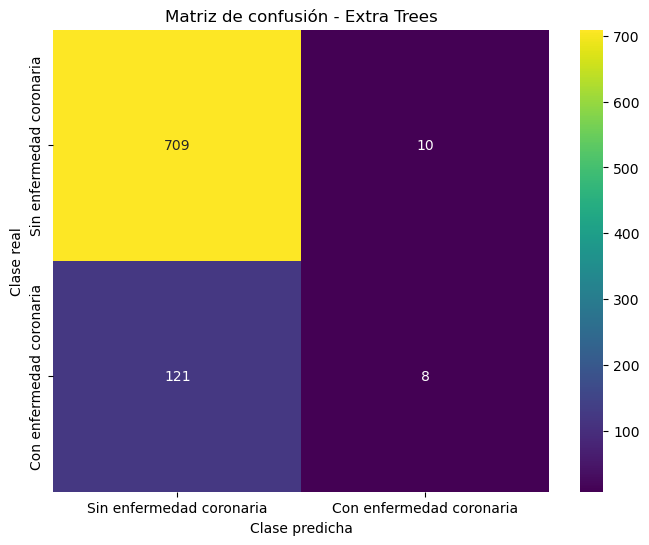


Matriz de confusión generada correctamente.


In [86]:
# ==============================================================
# GENERANDO MATRIZ DE CONFUSIÓN
# ==============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


print("=" * 65)
print("GENERANDO MATRIZ DE CONFUSIÓN...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular matriz de confusión
# --------------------------------------------------------------

matriz_confusion_et = confusion_matrix(
    y_test,
    y_pred_et
)


# --------------------------------------------------------------
# Visualizar matriz de confusión
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_confusion_et,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ],
    yticklabels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ]
)

plt.title("Matriz de confusión - Extra Trees")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

plt.show()


print("\nMatriz de confusión generada correctamente.")

GENERANDO CURVA ROC...


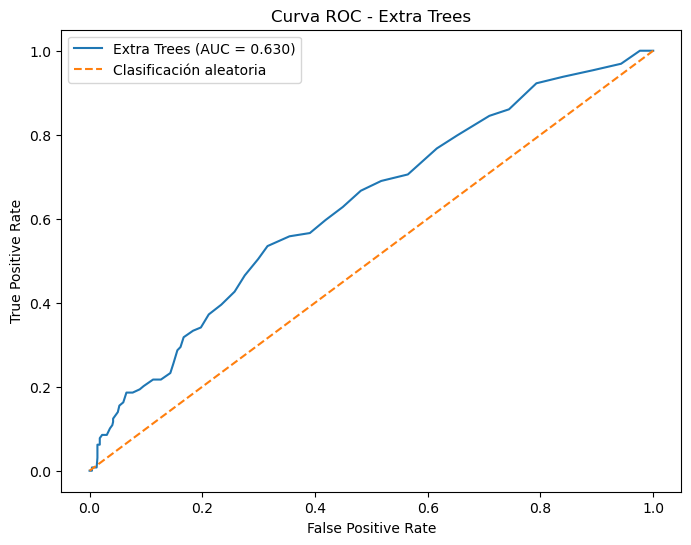


ROC-AUC: 0.6297
Curva ROC generada correctamente.


In [87]:
# ==============================================================
# GENERANDO CURVA ROC
# ==============================================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


print("=" * 65)
print("GENERANDO CURVA ROC...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular los valores necesarios para la curva ROC
# --------------------------------------------------------------

fpr_et, tpr_et, _ = roc_curve(
    y_test,
    y_prob_et
)


# --------------------------------------------------------------
# Crear la gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_et,
    tpr_et,
    label=f"Extra Trees (AUC = {roc_auc_et:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Extra Trees")
plt.legend()

plt.show()


print(f"\nROC-AUC: {roc_auc_et:.4f}")
print("Curva ROC generada correctamente.")

GENERANDO CURVA PRECISION-RECALL...


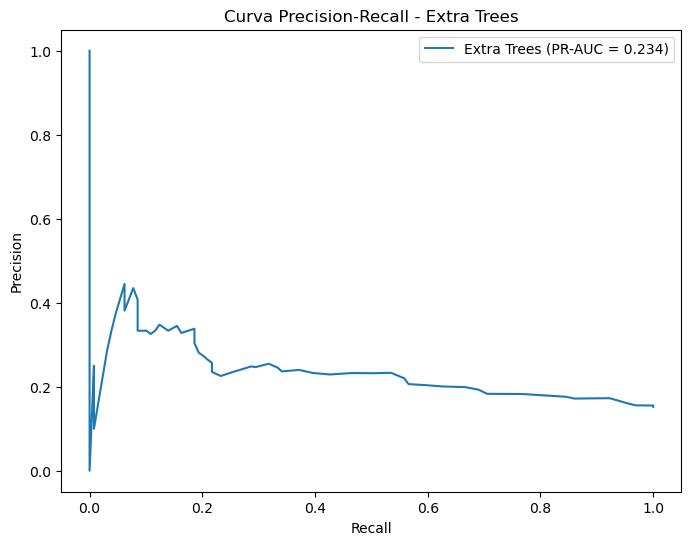


PR-AUC: 0.2335
Curva Precision-Recall generada correctamente.


In [88]:
# ==============================================================
# GENERANDO CURVA PRECISION-RECALL
# ==============================================================

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt


print("=" * 65)
print("GENERANDO CURVA PRECISION-RECALL...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular los valores necesarios
# --------------------------------------------------------------

precision_et_curve, recall_et_curve, _ = precision_recall_curve(
    y_test,
    y_prob_et
)


# --------------------------------------------------------------
# Crear la gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    recall_et_curve,
    precision_et_curve,
    label=f"Extra Trees (PR-AUC = {pr_auc_et:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Extra Trees")
plt.legend()

plt.show()


print(f"\nPR-AUC: {pr_auc_et:.4f}")
print("Curva Precision-Recall generada correctamente.")

In [89]:
# Añadir Extra Trees a la tabla de resultados

resultados.loc[len(resultados)] = [
    "Extra Trees",
    accuracy_et,
    precision_et,
    recall_et,
    f1_et,
    roc_auc_et,
    pr_auc_et
]

resultados

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística,0.844340,0.411765,0.054264,0.095890,0.702774,0.302116
1,Linear Discriminant Analysis (LDA),0.838443,0.346154,0.069767,0.116129,0.700941,0.287816
2,Support Vector Machine (SVM),0.850236,0.750000,0.023256,0.045113,0.542064,0.220860
3,Stochastic Gradient Descent (SGD),0.818396,0.272727,0.116279,0.163043,0.660543,0.242477
4,K-Nearest Neighbors (KNN),0.839623,0.393939,0.100775,0.160494,0.569255,0.205580
5,Gaussian Naive Bayes,0.806604,0.253521,0.139535,0.180000,0.678068,0.252698
6,Decision Tree,0.750000,0.178295,0.178295,0.178295,0.515434,0.156789
7,Random Forest,0.844340,0.421053,0.062016,0.108108,0.632753,0.245967
8,Gradient Boosting,0.839623,0.370370,0.077519,0.128205,0.663130,0.258935
9,AdaBoost,0.850236,0.625000,0.038760,0.072993,0.681982,0.297005


In [90]:
# ==============================================================
# 1.15 - BAGGING CLASSIFIER
# INICIO DE LA FASE DE ENTRENAMIENTO
# ==============================================================

print("=" * 65)
print("1.15 - BAGGING CLASSIFIER")
print("INICIO DE LA FASE DE ENTRENAMIENTO")
print("=" * 65)


# --------------------------------------------------------------
# Importar el modelo
# --------------------------------------------------------------

from sklearn.ensemble import BaggingClassifier


# --------------------------------------------------------------
# Crear el modelo
# --------------------------------------------------------------

modelo_bag = BaggingClassifier(
    random_state=42
)


# --------------------------------------------------------------
# Entrenar el modelo utilizando los datos de entrenamiento
# --------------------------------------------------------------

modelo_bag.fit(
    X_train_scaled,
    y_train
)


print("\nModelo Bagging Classifier entrenado correctamente.")

1.15 - BAGGING CLASSIFIER
INICIO DE LA FASE DE ENTRENAMIENTO

Modelo Bagging Classifier entrenado correctamente.


In [91]:
# ==============================================================
# 1.15 - BAGGING CLASSIFIER
# INICIO DE LA FASE DE PREDICCIÓN
# ==============================================================

print("=" * 65)
print("1.15 - BAGGING CLASSIFIER")
print("INICIO DE LA FASE DE PREDICCIÓN")
print("=" * 65)


# --------------------------------------------------------------
# Realizar las predicciones sobre los datos de prueba
# --------------------------------------------------------------

y_pred_bag = modelo_bag.predict(
    X_test_scaled
)


# --------------------------------------------------------------
# Obtener las probabilidades de pertenecer a la clase positiva
# --------------------------------------------------------------

y_prob_bag = modelo_bag.predict_proba(
    X_test_scaled
)[:, 1]


print("\nPredicciones realizadas correctamente.")

1.15 - BAGGING CLASSIFIER
INICIO DE LA FASE DE PREDICCIÓN

Predicciones realizadas correctamente.


In [92]:
# ==============================================================
# 1.15.2 - EVALUACIÓN DEL MODELO BAGGING CLASSIFIER
# ==============================================================

print("=" * 65)
print("1.15.2 - EVALUACIÓN DEL MODELO BAGGING CLASSIFIER")
print("=" * 65)


# --------------------------------------------------------------
# Calcular las métricas
# --------------------------------------------------------------

accuracy_bag = accuracy_score(
    y_test,
    y_pred_bag
)

precision_bag = precision_score(
    y_test,
    y_pred_bag,
    zero_division=0
)

recall_bag = recall_score(
    y_test,
    y_pred_bag,
    zero_division=0
)

f1_bag = f1_score(
    y_test,
    y_pred_bag,
    zero_division=0
)

roc_auc_bag = roc_auc_score(
    y_test,
    y_prob_bag
)

pr_auc_bag = average_precision_score(
    y_test,
    y_prob_bag
)


# --------------------------------------------------------------
# Mostrar los resultados
# --------------------------------------------------------------

print(f"\nAccuracy:  {accuracy_bag:.4f}")
print(f"Precision: {precision_bag:.4f}")
print(f"Recall:    {recall_bag:.4f}")
print(f"F1-score:  {f1_bag:.4f}")
print(f"ROC-AUC:   {roc_auc_bag:.4f}")
print(f"PR-AUC:    {pr_auc_bag:.4f}")

print("\nEvaluación completada correctamente.")

1.15.2 - EVALUACIÓN DEL MODELO BAGGING CLASSIFIER

Accuracy:  0.8337
Precision: 0.3125
Recall:    0.0775
F1-score:  0.1242
ROC-AUC:   0.5857
PR-AUC:    0.2098

Evaluación completada correctamente.


GENERANDO MATRIZ DE CONFUSIÓN...


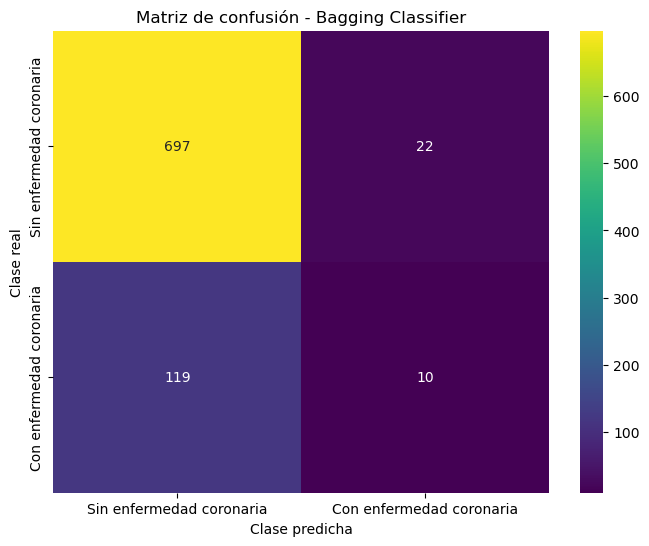


Matriz de confusión generada correctamente.


In [93]:
# ==============================================================
# GENERANDO MATRIZ DE CONFUSIÓN
# ==============================================================

print("=" * 65)
print("GENERANDO MATRIZ DE CONFUSIÓN...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular matriz de confusión
# --------------------------------------------------------------

matriz_confusion_bag = confusion_matrix(
    y_test,
    y_pred_bag
)


# --------------------------------------------------------------
# Visualizar matriz de confusión
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_confusion_bag,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ],
    yticklabels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ]
)

plt.title("Matriz de confusión - Bagging Classifier")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

plt.show()


print("\nMatriz de confusión generada correctamente.")

GENERANDO CURVA ROC...


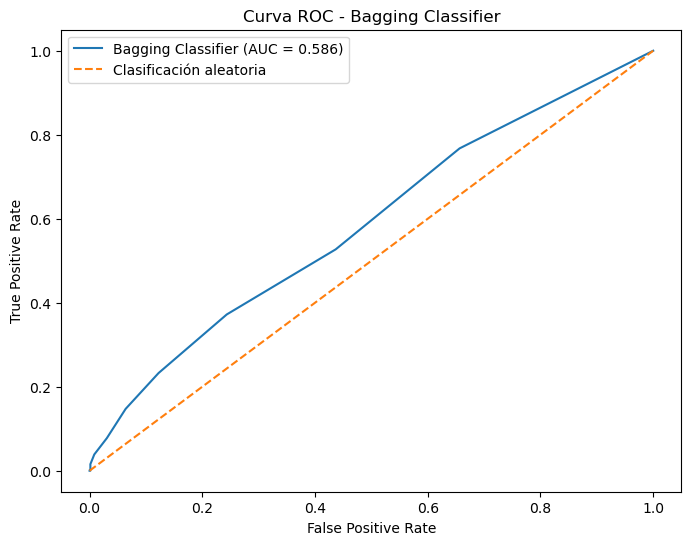


ROC-AUC: 0.5857
Curva ROC generada correctamente.


In [94]:
# ==============================================================
# GENERANDO CURVA ROC
# ==============================================================

from sklearn.metrics import roc_curve, auc

print("=" * 65)
print("GENERANDO CURVA ROC...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular los valores para la curva ROC
# --------------------------------------------------------------

fpr_bag, tpr_bag, _ = roc_curve(
    y_test,
    y_prob_bag
)


# --------------------------------------------------------------
# Crear la gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_bag,
    tpr_bag,
    label=f"Bagging Classifier (AUC = {roc_auc_bag:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Bagging Classifier")
plt.legend()

plt.show()


print(f"\nROC-AUC: {roc_auc_bag:.4f}")
print("Curva ROC generada correctamente.")

GENERANDO CURVA PRECISION-RECALL...


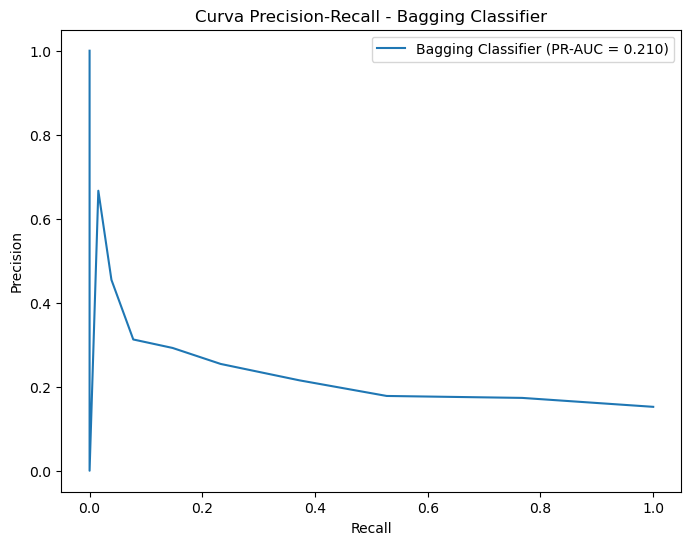


PR-AUC: 0.2098
Curva Precision-Recall generada correctamente.


In [95]:
# ==============================================================
# GENERANDO CURVA PRECISION-RECALL
# ==============================================================

from sklearn.metrics import precision_recall_curve

print("=" * 65)
print("GENERANDO CURVA PRECISION-RECALL...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular los valores necesarios
# --------------------------------------------------------------

precision_bag_curve, recall_bag_curve, _ = precision_recall_curve(
    y_test,
    y_prob_bag
)


# --------------------------------------------------------------
# Crear la gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    recall_bag_curve,
    precision_bag_curve,
    label=f"Bagging Classifier (PR-AUC = {pr_auc_bag:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Bagging Classifier")
plt.legend()

plt.show()


print(f"\nPR-AUC: {pr_auc_bag:.4f}")
print("Curva Precision-Recall generada correctamente.")

In [96]:
# ==============================================================
# AÑADIR BAGGING CLASSIFIER A LA TABLA DE RESULTADOS
# ==============================================================

resultados.loc[len(resultados)] = [
    "Bagging Classifier",
    accuracy_bag,
    precision_bag,
    recall_bag,
    f1_bag,
    roc_auc_bag,
    pr_auc_bag
]

resultados

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística,0.844340,0.411765,0.054264,0.095890,0.702774,0.302116
1,Linear Discriminant Analysis (LDA),0.838443,0.346154,0.069767,0.116129,0.700941,0.287816
2,Support Vector Machine (SVM),0.850236,0.750000,0.023256,0.045113,0.542064,0.220860
3,Stochastic Gradient Descent (SGD),0.818396,0.272727,0.116279,0.163043,0.660543,0.242477
4,K-Nearest Neighbors (KNN),0.839623,0.393939,0.100775,0.160494,0.569255,0.205580
5,Gaussian Naive Bayes,0.806604,0.253521,0.139535,0.180000,0.678068,0.252698
6,Decision Tree,0.750000,0.178295,0.178295,0.178295,0.515434,0.156789
7,Random Forest,0.844340,0.421053,0.062016,0.108108,0.632753,0.245967
8,Gradient Boosting,0.839623,0.370370,0.077519,0.128205,0.663130,0.258935
9,AdaBoost,0.850236,0.625000,0.038760,0.072993,0.681982,0.297005


In [97]:
# ==============================================================
# 1.16 - VOTING CLASSIFIER
# INICIO DE LA FASE DE ENTRENAMIENTO
# ==============================================================

print("=" * 65)
print("1.16 - VOTING CLASSIFIER")
print("INICIO DE LA FASE DE ENTRENAMIENTO")
print("=" * 65)


# --------------------------------------------------------------
# Importar el modelo
# --------------------------------------------------------------

from sklearn.ensemble import VotingClassifier


# --------------------------------------------------------------
# Crear el modelo
# --------------------------------------------------------------

modelo_voting = VotingClassifier(
    estimators=[
        ("lr", modelo_lr),
        ("rf", modelo_rf),
        ("gb", modelo_gb)
    ],
    voting="soft"
)


# --------------------------------------------------------------
# Entrenar el modelo
# --------------------------------------------------------------

modelo_voting.fit(
    X_train_scaled,
    y_train
)


print("\nModelo Voting Classifier entrenado correctamente.")

1.16 - VOTING CLASSIFIER
INICIO DE LA FASE DE ENTRENAMIENTO

Modelo Voting Classifier entrenado correctamente.


In [98]:
# ==============================================================
# 1.16 - VOTING CLASSIFIER
# INICIO DE LA FASE DE PREDICCIÓN
# ==============================================================

print("=" * 65)
print("1.16 - VOTING CLASSIFIER")
print("INICIO DE LA FASE DE PREDICCIÓN")
print("=" * 65)


# --------------------------------------------------------------
# Realizar las predicciones sobre los datos de prueba
# --------------------------------------------------------------

y_pred_voting = modelo_voting.predict(
    X_test_scaled
)


# --------------------------------------------------------------
# Obtener las probabilidades de pertenecer a la clase positiva
# --------------------------------------------------------------

y_prob_voting = modelo_voting.predict_proba(
    X_test_scaled
)[:, 1]


print("\nPredicciones realizadas correctamente.")

1.16 - VOTING CLASSIFIER
INICIO DE LA FASE DE PREDICCIÓN

Predicciones realizadas correctamente.


In [99]:
# ==============================================================
# 1.16.2 - EVALUACIÓN DEL MODELO VOTING CLASSIFIER
# ==============================================================

print("=" * 65)
print("1.16.2 - EVALUACIÓN DEL MODELO VOTING CLASSIFIER")
print("=" * 65)


# --------------------------------------------------------------
# Calcular las métricas
# --------------------------------------------------------------

accuracy_voting = accuracy_score(
    y_test,
    y_pred_voting
)

precision_voting = precision_score(
    y_test,
    y_pred_voting,
    zero_division=0
)

recall_voting = recall_score(
    y_test,
    y_pred_voting,
    zero_division=0
)

f1_voting = f1_score(
    y_test,
    y_pred_voting,
    zero_division=0
)

roc_auc_voting = roc_auc_score(
    y_test,
    y_prob_voting
)

pr_auc_voting = average_precision_score(
    y_test,
    y_prob_voting
)


# --------------------------------------------------------------
# Mostrar los resultados
# --------------------------------------------------------------

print(f"\nAccuracy:  {accuracy_voting:.4f}")
print(f"Precision: {precision_voting:.4f}")
print(f"Recall:    {recall_voting:.4f}")
print(f"F1-score:  {f1_voting:.4f}")
print(f"ROC-AUC:   {roc_auc_voting:.4f}")
print(f"PR-AUC:    {pr_auc_voting:.4f}")

print("\nEvaluación completada correctamente.")

1.16.2 - EVALUACIÓN DEL MODELO VOTING CLASSIFIER

Accuracy:  0.8479
Precision: 0.5000
Recall:    0.0698
F1-score:  0.1224
ROC-AUC:   0.6732
PR-AUC:    0.2786

Evaluación completada correctamente.


GENERANDO MATRIZ DE CONFUSIÓN...


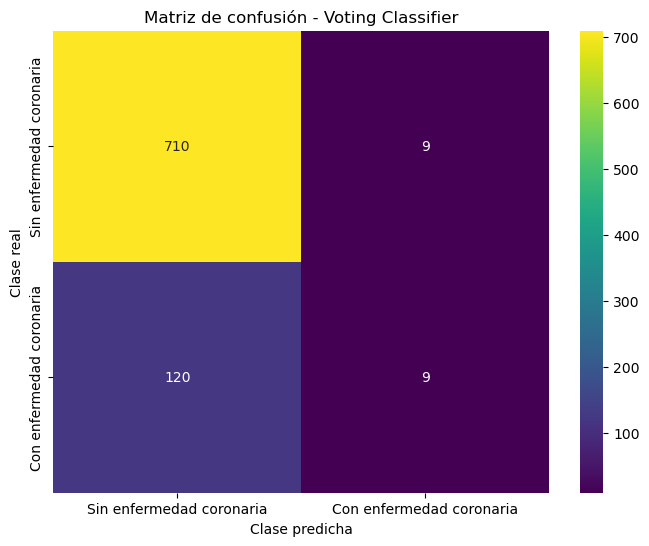


Matriz de confusión generada correctamente.


In [100]:
# ==============================================================
# GENERANDO MATRIZ DE CONFUSIÓN
# ==============================================================

print("=" * 65)
print("GENERANDO MATRIZ DE CONFUSIÓN...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular matriz de confusión
# --------------------------------------------------------------

matriz_confusion_voting = confusion_matrix(
    y_test,
    y_pred_voting
)


# --------------------------------------------------------------
# Visualizar matriz de confusión
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_confusion_voting,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ],
    yticklabels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ]
)

plt.title("Matriz de confusión - Voting Classifier")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

plt.show()


print("\nMatriz de confusión generada correctamente.")

GENERANDO CURVA ROC...


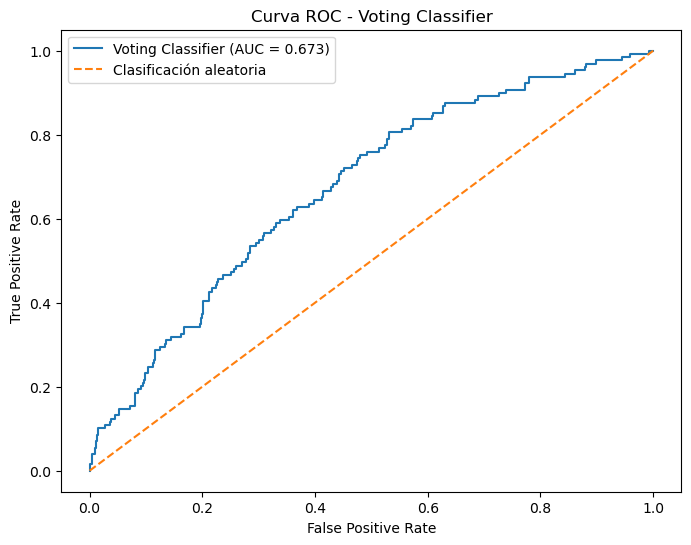


ROC-AUC: 0.6732
Curva ROC generada correctamente.


In [101]:
# ==============================================================
# GENERANDO CURVA ROC
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA ROC...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular los valores para la curva ROC
# --------------------------------------------------------------

fpr_voting, tpr_voting, _ = roc_curve(
    y_test,
    y_prob_voting
)


# --------------------------------------------------------------
# Crear la gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_voting,
    tpr_voting,
    label=f"Voting Classifier (AUC = {roc_auc_voting:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Voting Classifier")
plt.legend()

plt.show()


print(f"\nROC-AUC: {roc_auc_voting:.4f}")
print("Curva ROC generada correctamente.")

GENERANDO CURVA PRECISION-RECALL...


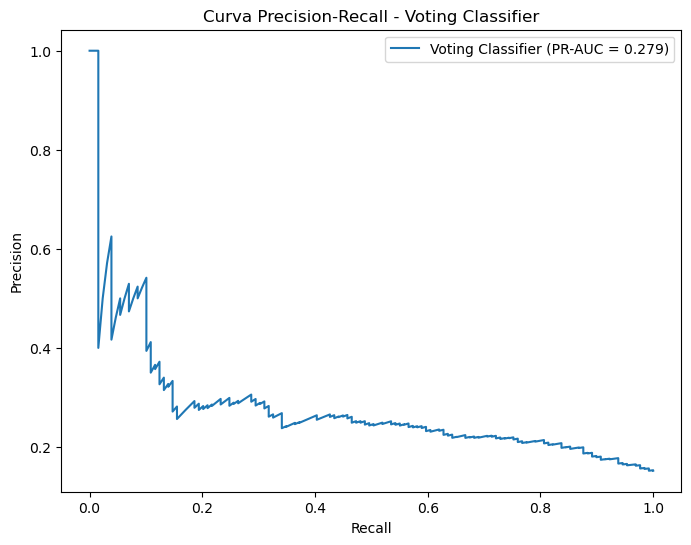


PR-AUC: 0.2786
Curva Precision-Recall generada correctamente.


In [102]:
# ==============================================================
# GENERANDO CURVA PRECISION-RECALL
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA PRECISION-RECALL...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular los valores necesarios
# --------------------------------------------------------------

precision_voting_curve, recall_voting_curve, _ = precision_recall_curve(
    y_test,
    y_prob_voting
)


# --------------------------------------------------------------
# Crear la gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    recall_voting_curve,
    precision_voting_curve,
    label=f"Voting Classifier (PR-AUC = {pr_auc_voting:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Voting Classifier")
plt.legend()

plt.show()


print(f"\nPR-AUC: {pr_auc_voting:.4f}")
print("Curva Precision-Recall generada correctamente.")

In [103]:
# ==============================================================
# AÑADIR VOTING CLASSIFIER A LA TABLA DE RESULTADOS
# ==============================================================

resultados.loc[len(resultados)] = [
    "Voting Classifier",
    accuracy_voting,
    precision_voting,
    recall_voting,
    f1_voting,
    roc_auc_voting,
    pr_auc_voting
]

resultados

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística,0.844340,0.411765,0.054264,0.095890,0.702774,0.302116
1,Linear Discriminant Analysis (LDA),0.838443,0.346154,0.069767,0.116129,0.700941,0.287816
2,Support Vector Machine (SVM),0.850236,0.750000,0.023256,0.045113,0.542064,0.220860
3,Stochastic Gradient Descent (SGD),0.818396,0.272727,0.116279,0.163043,0.660543,0.242477
4,K-Nearest Neighbors (KNN),0.839623,0.393939,0.100775,0.160494,0.569255,0.205580
5,Gaussian Naive Bayes,0.806604,0.253521,0.139535,0.180000,0.678068,0.252698
6,Decision Tree,0.750000,0.178295,0.178295,0.178295,0.515434,0.156789
7,Random Forest,0.844340,0.421053,0.062016,0.108108,0.632753,0.245967
8,Gradient Boosting,0.839623,0.370370,0.077519,0.128205,0.663130,0.258935
9,AdaBoost,0.850236,0.625000,0.038760,0.072993,0.681982,0.297005


In [104]:
# ==============================================================
# 1.17 - STACKING CLASSIFIER
# INICIO DE LA FASE DE ENTRENAMIENTO
# ==============================================================

print("=" * 65)
print("1.17 - STACKING CLASSIFIER")
print("INICIO DE LA FASE DE ENTRENAMIENTO")
print("=" * 65)


# --------------------------------------------------------------
# Importar el modelo
# --------------------------------------------------------------

from sklearn.ensemble import StackingClassifier


# --------------------------------------------------------------
# Crear el modelo
# --------------------------------------------------------------

modelo_stacking = StackingClassifier(
    estimators=[
        ("lr", modelo_lr),
        ("rf", modelo_rf),
        ("gb", modelo_gb)
    ],
    final_estimator=LogisticRegression(
        random_state=42
    )
)


# --------------------------------------------------------------
# Entrenar el modelo
# --------------------------------------------------------------

modelo_stacking.fit(
    X_train_scaled,
    y_train
)


print("\nModelo Stacking Classifier entrenado correctamente.")

1.17 - STACKING CLASSIFIER
INICIO DE LA FASE DE ENTRENAMIENTO

Modelo Stacking Classifier entrenado correctamente.


In [105]:
# ==============================================================
# 1.17 - STACKING CLASSIFIER
# INICIO DE LA FASE DE PREDICCIÓN
# ==============================================================

print("=" * 65)
print("1.17 - STACKING CLASSIFIER")
print("INICIO DE LA FASE DE PREDICCIÓN")
print("=" * 65)


# --------------------------------------------------------------
# Realizar las predicciones sobre los datos de prueba
# --------------------------------------------------------------

y_pred_stacking = modelo_stacking.predict(
    X_test_scaled
)


# --------------------------------------------------------------
# Obtener las probabilidades de pertenecer a la clase positiva
# --------------------------------------------------------------

y_prob_stacking = modelo_stacking.predict_proba(
    X_test_scaled
)[:, 1]


print("\nPredicciones realizadas correctamente.")

1.17 - STACKING CLASSIFIER
INICIO DE LA FASE DE PREDICCIÓN

Predicciones realizadas correctamente.


In [106]:
# ==============================================================
# 1.17.2 - EVALUACIÓN DEL MODELO STACKING CLASSIFIER
# ==============================================================

print("=" * 65)
print("1.17.2 - EVALUACIÓN DEL MODELO STACKING CLASSIFIER")
print("=" * 65)


# --------------------------------------------------------------
# Calcular las métricas
# --------------------------------------------------------------

accuracy_stacking = accuracy_score(
    y_test,
    y_pred_stacking
)

precision_stacking = precision_score(
    y_test,
    y_pred_stacking,
    zero_division=0
)

recall_stacking = recall_score(
    y_test,
    y_pred_stacking,
    zero_division=0
)

f1_stacking = f1_score(
    y_test,
    y_pred_stacking,
    zero_division=0
)

roc_auc_stacking = roc_auc_score(
    y_test,
    y_prob_stacking
)

pr_auc_stacking = average_precision_score(
    y_test,
    y_prob_stacking
)


# --------------------------------------------------------------
# Mostrar los resultados
# --------------------------------------------------------------

print(f"\nAccuracy:  {accuracy_stacking:.4f}")
print(f"Precision: {precision_stacking:.4f}")
print(f"Recall:    {recall_stacking:.4f}")
print(f"F1-score:  {f1_stacking:.4f}")
print(f"ROC-AUC:   {roc_auc_stacking:.4f}")
print(f"PR-AUC:    {pr_auc_stacking:.4f}")

print("\nEvaluación completada correctamente.")

1.17.2 - EVALUACIÓN DEL MODELO STACKING CLASSIFIER

Accuracy:  0.8467
Precision: 0.4762
Recall:    0.0775
F1-score:  0.1333
ROC-AUC:   0.6824
PR-AUC:    0.2901

Evaluación completada correctamente.


GENERANDO MATRIZ DE CONFUSIÓN...


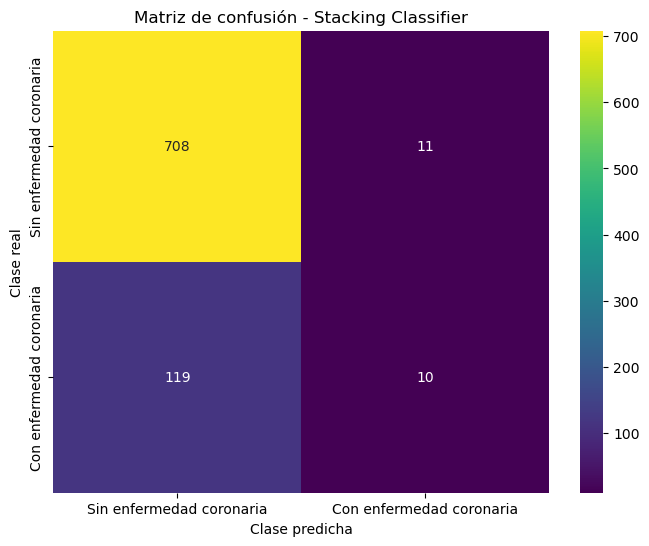


Matriz de confusión generada correctamente.


In [107]:
# ==============================================================
# GENERANDO MATRIZ DE CONFUSIÓN
# ==============================================================

print("=" * 65)
print("GENERANDO MATRIZ DE CONFUSIÓN...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular matriz de confusión
# --------------------------------------------------------------

matriz_confusion_stacking = confusion_matrix(
    y_test,
    y_pred_stacking
)


# --------------------------------------------------------------
# Visualizar matriz de confusión
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_confusion_stacking,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ],
    yticklabels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ]
)

plt.title("Matriz de confusión - Stacking Classifier")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

plt.show()


print("\nMatriz de confusión generada correctamente.")

GENERANDO CURVA ROC...


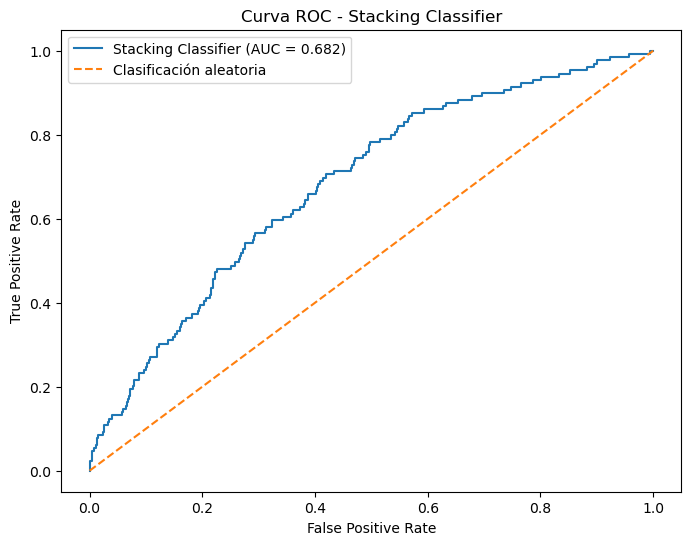


ROC-AUC: 0.6824
Curva ROC generada correctamente.


In [108]:
# ==============================================================
# GENERANDO CURVA ROC
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA ROC...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular los valores para la curva ROC
# --------------------------------------------------------------

fpr_stacking, tpr_stacking, _ = roc_curve(
    y_test,
    y_prob_stacking
)


# --------------------------------------------------------------
# Crear la gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_stacking,
    tpr_stacking,
    label=f"Stacking Classifier (AUC = {roc_auc_stacking:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Stacking Classifier")
plt.legend()

plt.show()


print(f"\nROC-AUC: {roc_auc_stacking:.4f}")
print("Curva ROC generada correctamente.")

GENERANDO CURVA PRECISION-RECALL...


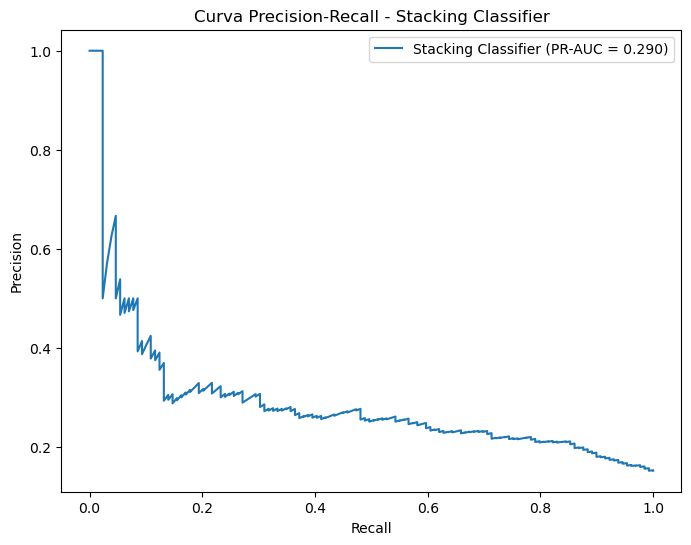


PR-AUC: 0.2901
Curva Precision-Recall generada correctamente.


In [109]:
# ==============================================================
# GENERANDO CURVA PRECISION-RECALL
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA PRECISION-RECALL...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular los valores necesarios
# --------------------------------------------------------------

precision_stacking_curve, recall_stacking_curve, _ = precision_recall_curve(
    y_test,
    y_prob_stacking
)


# --------------------------------------------------------------
# Crear la gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    recall_stacking_curve,
    precision_stacking_curve,
    label=f"Stacking Classifier (PR-AUC = {pr_auc_stacking:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Stacking Classifier")
plt.legend()

plt.show()


print(f"\nPR-AUC: {pr_auc_stacking:.4f}")
print("Curva Precision-Recall generada correctamente.")

In [110]:
# ==============================================================
# AÑADIR STACKING CLASSIFIER A LA TABLA DE RESULTADOS
# ==============================================================

resultados.loc[len(resultados)] = [
    "Stacking Classifier",
    accuracy_stacking,
    precision_stacking,
    recall_stacking,
    f1_stacking,
    roc_auc_stacking,
    pr_auc_stacking
]

resultados

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística,0.844340,0.411765,0.054264,0.095890,0.702774,0.302116
1,Linear Discriminant Analysis (LDA),0.838443,0.346154,0.069767,0.116129,0.700941,0.287816
2,Support Vector Machine (SVM),0.850236,0.750000,0.023256,0.045113,0.542064,0.220860
3,Stochastic Gradient Descent (SGD),0.818396,0.272727,0.116279,0.163043,0.660543,0.242477
4,K-Nearest Neighbors (KNN),0.839623,0.393939,0.100775,0.160494,0.569255,0.205580
5,Gaussian Naive Bayes,0.806604,0.253521,0.139535,0.180000,0.678068,0.252698
6,Decision Tree,0.750000,0.178295,0.178295,0.178295,0.515434,0.156789
7,Random Forest,0.844340,0.421053,0.062016,0.108108,0.632753,0.245967
8,Gradient Boosting,0.839623,0.370370,0.077519,0.128205,0.663130,0.258935
9,AdaBoost,0.850236,0.625000,0.038760,0.072993,0.681982,0.297005


In [111]:
# ==============================================================
# 1.18 - HISTOGRAM GRADIENT BOOSTING
# INICIO DE LA FASE DE ENTRENAMIENTO
# ==============================================================

print("=" * 65)
print("1.18 - HISTOGRAM GRADIENT BOOSTING")
print("INICIO DE LA FASE DE ENTRENAMIENTO")
print("=" * 65)


from sklearn.ensemble import HistGradientBoostingClassifier


# Crear el modelo
modelo_hist_gb = HistGradientBoostingClassifier(
    random_state=42
)


# Entrenar el modelo
modelo_hist_gb.fit(
    X_train_scaled,
    y_train
)


print("\nModelo Histogram Gradient Boosting entrenado correctamente.")

1.18 - HISTOGRAM GRADIENT BOOSTING
INICIO DE LA FASE DE ENTRENAMIENTO


C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^


Modelo Histogram Gradient Boosting entrenado correctamente.


In [112]:
# ==============================================================
# 1.18.1 - HISTOGRAM GRADIENT BOOSTING
# INICIO DE LA FASE DE PREDICCIÓN
# ==============================================================

print("=" * 65)
print("1.18.1 - HISTOGRAM GRADIENT BOOSTING")
print("INICIO DE LA FASE DE PREDICCIÓN")
print("=" * 65)


# --------------------------------------------------------------
# Realizar predicciones
# --------------------------------------------------------------

y_pred_hist_gb = modelo_hist_gb.predict(X_test_scaled)

y_prob_hist_gb = modelo_hist_gb.predict_proba(X_test_scaled)[:, 1]


print("\nPredicciones realizadas correctamente.")

1.18.1 - HISTOGRAM GRADIENT BOOSTING
INICIO DE LA FASE DE PREDICCIÓN

Predicciones realizadas correctamente.


In [113]:
# ==============================================================
# 1.18.2 - EVALUACIÓN DEL MODELO HISTOGRAM GRADIENT BOOSTING
# ==============================================================

print("=" * 65)
print("1.18.2 - EVALUACIÓN DEL MODELO HISTOGRAM GRADIENT BOOSTING")
print("=" * 65)


# --------------------------------------------------------------
# Calcular métricas
# --------------------------------------------------------------

accuracy_hist_gb = accuracy_score(
    y_test,
    y_pred_hist_gb
)

precision_hist_gb = precision_score(
    y_test,
    y_pred_hist_gb
)

recall_hist_gb = recall_score(
    y_test,
    y_pred_hist_gb
)

f1_hist_gb = f1_score(
    y_test,
    y_pred_hist_gb
)

roc_auc_hist_gb = roc_auc_score(
    y_test,
    y_prob_hist_gb
)

pr_auc_hist_gb = average_precision_score(
    y_test,
    y_prob_hist_gb
)


# --------------------------------------------------------------
# Mostrar resultados
# --------------------------------------------------------------

print(f"\nAccuracy:  {accuracy_hist_gb:.4f}")
print(f"Precision: {precision_hist_gb:.4f}")
print(f"Recall:    {recall_hist_gb:.4f}")
print(f"F1-score:  {f1_hist_gb:.4f}")
print(f"ROC-AUC:   {roc_auc_hist_gb:.4f}")
print(f"PR-AUC:    {pr_auc_hist_gb:.4f}")

print("\nEvaluación completada correctamente.")

1.18.2 - EVALUACIÓN DEL MODELO HISTOGRAM GRADIENT BOOSTING

Accuracy:  0.8267
Precision: 0.2750
Recall:    0.0853
F1-score:  0.1302
ROC-AUC:   0.6075
PR-AUC:    0.2189

Evaluación completada correctamente.


GENERANDO MATRIZ DE CONFUSIÓN...


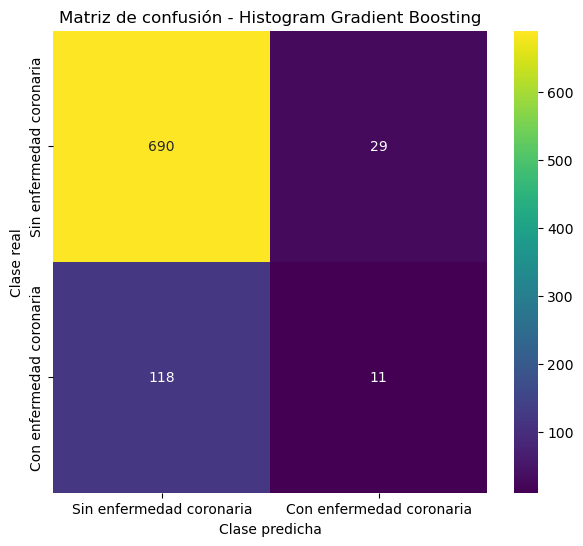


Matriz de confusión generada correctamente.


In [114]:
# ==============================================================
# 1.18.3 - MATRIZ DE CONFUSIÓN
# HISTOGRAM GRADIENT BOOSTING
# ==============================================================

print("=" * 65)
print("GENERANDO MATRIZ DE CONFUSIÓN...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular matriz de confusión
# --------------------------------------------------------------

matriz_hist_gb = confusion_matrix(
    y_test,
    y_pred_hist_gb
)


# --------------------------------------------------------------
# Crear la gráfica
# --------------------------------------------------------------

plt.figure(figsize=(7, 6))

sns.heatmap(
    matriz_hist_gb,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ],
    yticklabels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ]
)

plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.title("Matriz de confusión - Histogram Gradient Boosting")

plt.show()


print("\nMatriz de confusión generada correctamente.")

GENERANDO CURVA ROC...


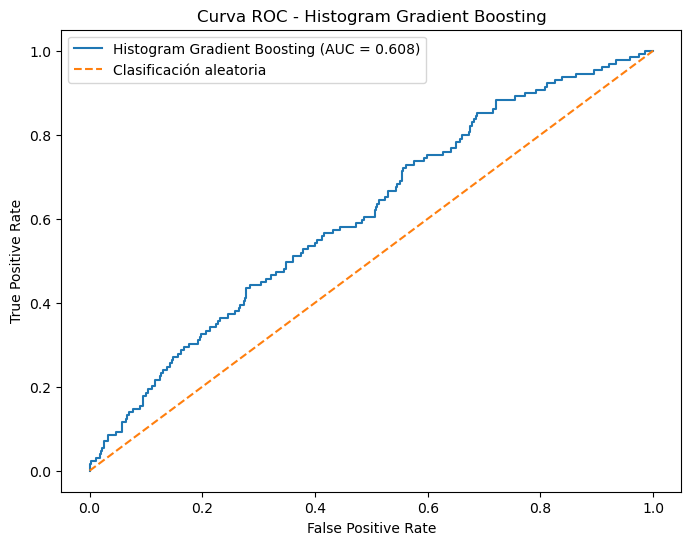


ROC-AUC: 0.6075
Curva ROC generada correctamente.


In [115]:
# ==============================================================
# 1.18.4 - CURVA ROC
# HISTOGRAM GRADIENT BOOSTING
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA ROC...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular curva ROC
# --------------------------------------------------------------

fpr_hist_gb, tpr_hist_gb, _ = roc_curve(
    y_test,
    y_prob_hist_gb
)


# --------------------------------------------------------------
# Crear la gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_hist_gb,
    tpr_hist_gb,
    label=f"Histogram Gradient Boosting (AUC = {roc_auc_hist_gb:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Histogram Gradient Boosting")

plt.legend()

plt.show()


print(f"\nROC-AUC: {roc_auc_hist_gb:.4f}")
print("Curva ROC generada correctamente.")

GENERANDO CURVA PRECISION-RECALL...


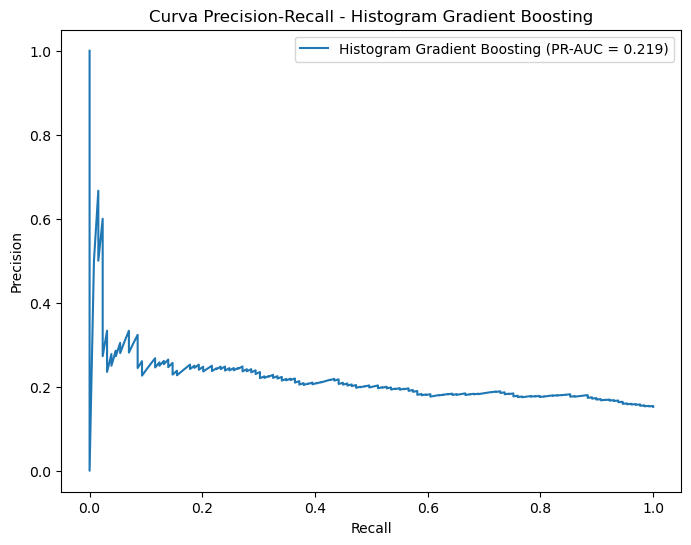


PR-AUC: 0.2189
Curva Precision-Recall generada correctamente.


In [116]:
# ==============================================================
# 1.18.5 - CURVA PRECISION-RECALL
# HISTOGRAM GRADIENT BOOSTING
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA PRECISION-RECALL...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular curva Precision-Recall
# --------------------------------------------------------------

precision_hist_gb_curve, recall_hist_gb_curve, _ = precision_recall_curve(
    y_test,
    y_prob_hist_gb
)


# --------------------------------------------------------------
# Crear la gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    recall_hist_gb_curve,
    precision_hist_gb_curve,
    label=f"Histogram Gradient Boosting (PR-AUC = {pr_auc_hist_gb:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Histogram Gradient Boosting")

plt.legend()

plt.show()


print(f"\nPR-AUC: {pr_auc_hist_gb:.4f}")
print("Curva Precision-Recall generada correctamente.")

In [117]:
# ==============================================================
# AÑADIR HISTOGRAM GRADIENT BOOSTING A LA TABLA DE RESULTADOS
# ==============================================================

resultados.loc[len(resultados)] = [
    "Histogram Gradient Boosting",
    accuracy_hist_gb,
    precision_hist_gb,
    recall_hist_gb,
    f1_hist_gb,
    roc_auc_hist_gb,
    pr_auc_hist_gb
]

resultados

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística,0.844340,0.411765,0.054264,0.095890,0.702774,0.302116
1,Linear Discriminant Analysis (LDA),0.838443,0.346154,0.069767,0.116129,0.700941,0.287816
2,Support Vector Machine (SVM),0.850236,0.750000,0.023256,0.045113,0.542064,0.220860
3,Stochastic Gradient Descent (SGD),0.818396,0.272727,0.116279,0.163043,0.660543,0.242477
4,K-Nearest Neighbors (KNN),0.839623,0.393939,0.100775,0.160494,0.569255,0.205580
5,Gaussian Naive Bayes,0.806604,0.253521,0.139535,0.180000,0.678068,0.252698
6,Decision Tree,0.750000,0.178295,0.178295,0.178295,0.515434,0.156789
7,Random Forest,0.844340,0.421053,0.062016,0.108108,0.632753,0.245967
8,Gradient Boosting,0.839623,0.370370,0.077519,0.128205,0.663130,0.258935
9,AdaBoost,0.850236,0.625000,0.038760,0.072993,0.681982,0.297005


In [118]:
# ==============================================================
# 1.19 - MLP CLASSIFIER
# INICIO DE LA FASE DE ENTRENAMIENTO
# ==============================================================

print("=" * 65)
print("1.19 - MLP CLASSIFIER")
print("INICIO DE LA FASE DE ENTRENAMIENTO")
print("=" * 65)


# --------------------------------------------------------------
# Importar el modelo
# --------------------------------------------------------------

from sklearn.neural_network import MLPClassifier


# --------------------------------------------------------------
# Crear el modelo
# --------------------------------------------------------------

modelo_mlp = MLPClassifier(
    random_state=42,
    max_iter=1000
)


# --------------------------------------------------------------
# Entrenar el modelo
# --------------------------------------------------------------

modelo_mlp.fit(
    X_train_scaled,
    y_train
)


print("\nModelo MLP Classifier entrenado correctamente.")

1.19 - MLP CLASSIFIER
INICIO DE LA FASE DE ENTRENAMIENTO

Modelo MLP Classifier entrenado correctamente.


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [119]:
# ==============================================================
# 1.19.1 - MLP CLASSIFIER
# INICIO DE LA FASE DE PREDICCIÓN
# ==============================================================

print("=" * 65)
print("1.19.1 - MLP CLASSIFIER")
print("INICIO DE LA FASE DE PREDICCIÓN")
print("=" * 65)


# --------------------------------------------------------------
# Realizar predicciones
# --------------------------------------------------------------

y_pred_mlp = modelo_mlp.predict(X_test_scaled)

y_prob_mlp = modelo_mlp.predict_proba(X_test_scaled)[:, 1]


print("\nPredicciones realizadas correctamente.")

1.19.1 - MLP CLASSIFIER
INICIO DE LA FASE DE PREDICCIÓN

Predicciones realizadas correctamente.


In [120]:
# ==============================================================
# 1.19.2 - EVALUACIÓN DEL MODELO MLP CLASSIFIER
# ==============================================================

print("=" * 65)
print("1.19.2 - EVALUACIÓN DEL MODELO MLP CLASSIFIER")
print("=" * 65)


# --------------------------------------------------------------
# Calcular métricas
# --------------------------------------------------------------

accuracy_mlp = accuracy_score(
    y_test,
    y_pred_mlp
)

precision_mlp = precision_score(
    y_test,
    y_pred_mlp
)

recall_mlp = recall_score(
    y_test,
    y_pred_mlp
)

f1_mlp = f1_score(
    y_test,
    y_pred_mlp
)

roc_auc_mlp = roc_auc_score(
    y_test,
    y_prob_mlp
)

pr_auc_mlp = average_precision_score(
    y_test,
    y_prob_mlp
)


# --------------------------------------------------------------
# Mostrar resultados
# --------------------------------------------------------------

print(f"\nAccuracy:  {accuracy_mlp:.4f}")
print(f"Precision: {precision_mlp:.4f}")
print(f"Recall:    {recall_mlp:.4f}")
print(f"F1-score:  {f1_mlp:.4f}")
print(f"ROC-AUC:   {roc_auc_mlp:.4f}")
print(f"PR-AUC:    {pr_auc_mlp:.4f}")

print("\nEvaluación completada correctamente.")

1.19.2 - EVALUACIÓN DEL MODELO MLP CLASSIFIER

Accuracy:  0.7960
Precision: 0.2609
Recall:    0.1860
F1-score:  0.2172
ROC-AUC:   0.5946
PR-AUC:    0.2262

Evaluación completada correctamente.


GENERANDO MATRIZ DE CONFUSIÓN...


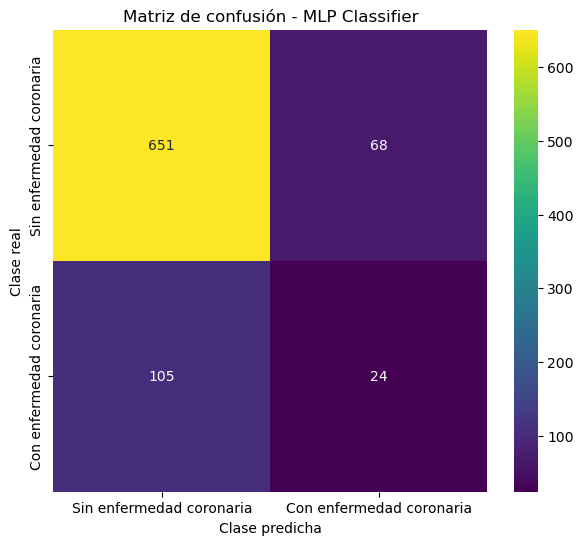


Matriz de confusión generada correctamente.


In [121]:
# ==============================================================
# 1.19.3 - MATRIZ DE CONFUSIÓN
# MLP CLASSIFIER
# ==============================================================

print("=" * 65)
print("GENERANDO MATRIZ DE CONFUSIÓN...")
print("=" * 65)


matriz_mlp = confusion_matrix(
    y_test,
    y_pred_mlp
)


plt.figure(figsize=(7, 6))

sns.heatmap(
    matriz_mlp,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ],
    yticklabels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ]
)

plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.title("Matriz de confusión - MLP Classifier")

plt.show()


print("\nMatriz de confusión generada correctamente.")

GENERANDO CURVA ROC...


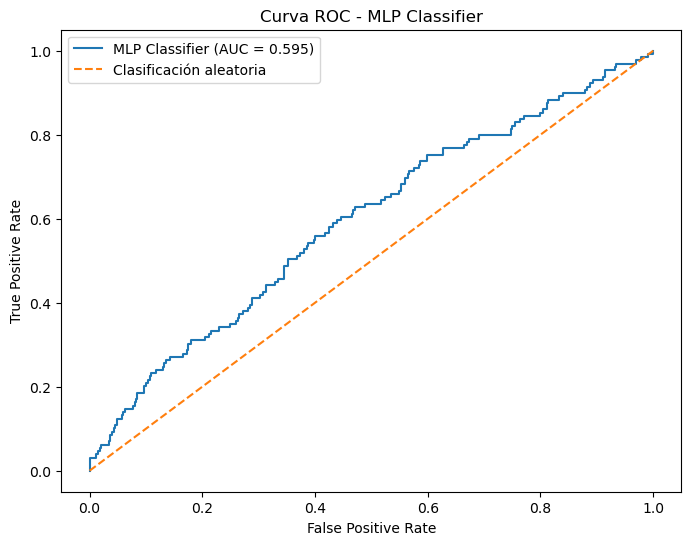


ROC-AUC: 0.5946
Curva ROC generada correctamente.


In [122]:
# ==============================================================
# 1.19.4 - CURVA ROC
# MLP CLASSIFIER
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA ROC...")
print("=" * 65)


# Calcular curva ROC
fpr_mlp, tpr_mlp, _ = roc_curve(
    y_test,
    y_prob_mlp
)


# Crear gráfica
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_mlp,
    tpr_mlp,
    label=f"MLP Classifier (AUC = {roc_auc_mlp:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - MLP Classifier")

plt.legend()

plt.show()


print(f"\nROC-AUC: {roc_auc_mlp:.4f}")
print("Curva ROC generada correctamente.")

GENERANDO CURVA PRECISION-RECALL...


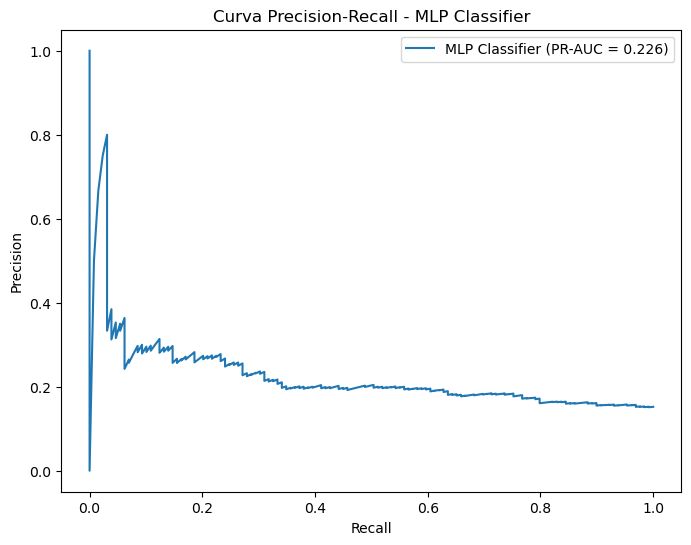


PR-AUC: 0.2262
Curva Precision-Recall generada correctamente.


In [123]:
# ==============================================================
# 1.19.5 - CURVA PRECISION-RECALL
# MLP CLASSIFIER
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA PRECISION-RECALL...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular curva Precision-Recall
# --------------------------------------------------------------

precision_mlp_curve, recall_mlp_curve, _ = precision_recall_curve(
    y_test,
    y_prob_mlp
)


# --------------------------------------------------------------
# Crear la gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    recall_mlp_curve,
    precision_mlp_curve,
    label=f"MLP Classifier (PR-AUC = {pr_auc_mlp:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - MLP Classifier")

plt.legend()

plt.show()


print(f"\nPR-AUC: {pr_auc_mlp:.4f}")
print("Curva Precision-Recall generada correctamente.")

In [124]:
# Añadir resultados del MLP Classifier

resultados.loc[len(resultados)] = [
    "MLP Classifier",
    accuracy_mlp,
    precision_mlp,
    recall_mlp,
    f1_mlp,
    roc_auc_mlp,
    pr_auc_mlp
]

resultados

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística,0.844340,0.411765,0.054264,0.095890,0.702774,0.302116
1,Linear Discriminant Analysis (LDA),0.838443,0.346154,0.069767,0.116129,0.700941,0.287816
2,Support Vector Machine (SVM),0.850236,0.750000,0.023256,0.045113,0.542064,0.220860
3,Stochastic Gradient Descent (SGD),0.818396,0.272727,0.116279,0.163043,0.660543,0.242477
4,K-Nearest Neighbors (KNN),0.839623,0.393939,0.100775,0.160494,0.569255,0.205580
5,Gaussian Naive Bayes,0.806604,0.253521,0.139535,0.180000,0.678068,0.252698
6,Decision Tree,0.750000,0.178295,0.178295,0.178295,0.515434,0.156789
7,Random Forest,0.844340,0.421053,0.062016,0.108108,0.632753,0.245967
8,Gradient Boosting,0.839623,0.370370,0.077519,0.128205,0.663130,0.258935
9,AdaBoost,0.850236,0.625000,0.038760,0.072993,0.681982,0.297005


In [125]:
# ==============================================================
# 1.20 - QUADRATIC DISCRIMINANT ANALYSIS (QDA)
# INICIO DE LA FASE DE ENTRENAMIENTO
# ==============================================================

print("=" * 65)
print("1.20 - QUADRATIC DISCRIMINANT ANALYSIS (QDA)")
print("INICIO DE LA FASE DE ENTRENAMIENTO")
print("=" * 65)


# --------------------------------------------------------------
# Importar el modelo
# --------------------------------------------------------------

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis


# --------------------------------------------------------------
# Crear el modelo
# --------------------------------------------------------------

modelo_qda = QuadraticDiscriminantAnalysis()


# --------------------------------------------------------------
# Entrenar el modelo
# --------------------------------------------------------------

modelo_qda.fit(
    X_train_scaled,
    y_train
)


print("\nModelo Quadratic Discriminant Analysis entrenado correctamente.")

1.20 - QUADRATIC DISCRIMINANT ANALYSIS (QDA)
INICIO DE LA FASE DE ENTRENAMIENTO

Modelo Quadratic Discriminant Analysis entrenado correctamente.


In [126]:
# ==============================================================
# 1.20.1 - QUADRATIC DISCRIMINANT ANALYSIS (QDA)
# INICIO DE LA FASE DE PREDICCIÓN
# ==============================================================

print("=" * 65)
print("1.20.1 - QUADRATIC DISCRIMINANT ANALYSIS (QDA)")
print("INICIO DE LA FASE DE PREDICCIÓN")
print("=" * 65)


# --------------------------------------------------------------
# Realizar predicciones
# --------------------------------------------------------------

y_pred_qda = modelo_qda.predict(X_test_scaled)

y_prob_qda = modelo_qda.predict_proba(X_test_scaled)[:, 1]


print("\nPredicciones realizadas correctamente.")

1.20.1 - QUADRATIC DISCRIMINANT ANALYSIS (QDA)
INICIO DE LA FASE DE PREDICCIÓN

Predicciones realizadas correctamente.


In [127]:
# ==============================================================
# 1.20.2 - EVALUACIÓN DEL MODELO QDA
# ==============================================================

print("=" * 65)
print("1.20.2 - EVALUACIÓN DEL MODELO QDA")
print("=" * 65)


# --------------------------------------------------------------
# Calcular métricas
# --------------------------------------------------------------

accuracy_qda = accuracy_score(
    y_test,
    y_pred_qda
)

precision_qda = precision_score(
    y_test,
    y_pred_qda
)

recall_qda = recall_score(
    y_test,
    y_pred_qda
)

f1_qda = f1_score(
    y_test,
    y_pred_qda
)

roc_auc_qda = roc_auc_score(
    y_test,
    y_prob_qda
)

pr_auc_qda = average_precision_score(
    y_test,
    y_prob_qda
)


# --------------------------------------------------------------
# Mostrar resultados
# --------------------------------------------------------------

print(f"\nAccuracy:  {accuracy_qda:.4f}")
print(f"Precision: {precision_qda:.4f}")
print(f"Recall:    {recall_qda:.4f}")
print(f"F1-score:  {f1_qda:.4f}")
print(f"ROC-AUC:   {roc_auc_qda:.4f}")
print(f"PR-AUC:    {pr_auc_qda:.4f}")

print("\nEvaluación completada correctamente.")

1.20.2 - EVALUACIÓN DEL MODELO QDA

Accuracy:  0.8172
Precision: 0.2969
Recall:    0.1473
F1-score:  0.1969
ROC-AUC:   0.6767
PR-AUC:    0.2500

Evaluación completada correctamente.


GENERANDO MATRIZ DE CONFUSIÓN...


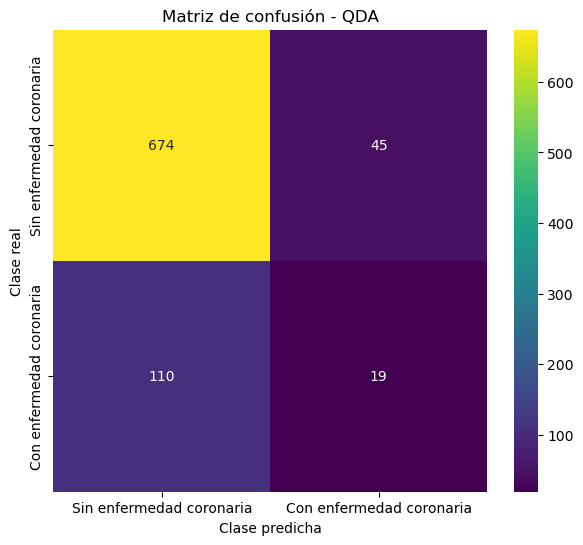


Matriz de confusión generada correctamente.


In [128]:
# ==============================================================
# 1.20.3 - MATRIZ DE CONFUSIÓN
# QUADRATIC DISCRIMINANT ANALYSIS (QDA)
# ==============================================================

print("=" * 65)
print("GENERANDO MATRIZ DE CONFUSIÓN...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular matriz de confusión
# --------------------------------------------------------------

matriz_qda = confusion_matrix(
    y_test,
    y_pred_qda
)


# --------------------------------------------------------------
# Crear gráfica
# --------------------------------------------------------------

plt.figure(figsize=(7, 6))

sns.heatmap(
    matriz_qda,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ],
    yticklabels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ]
)

plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.title("Matriz de confusión - QDA")

plt.show()


print("\nMatriz de confusión generada correctamente.")

GENERANDO CURVA ROC...


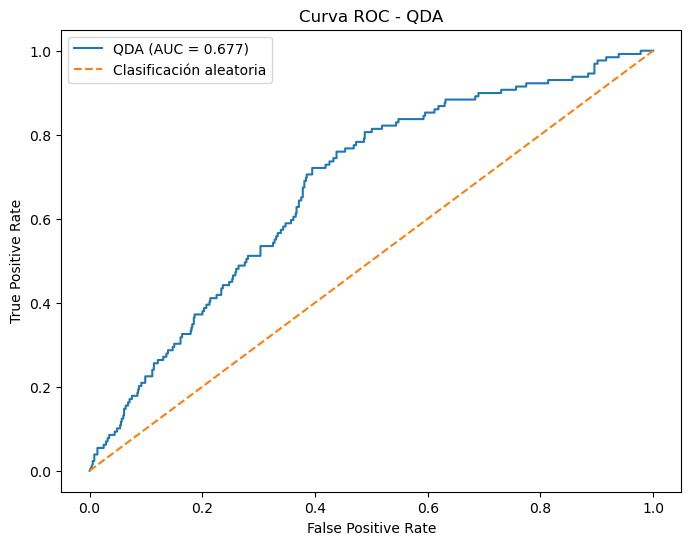


ROC-AUC: 0.6767
Curva ROC generada correctamente.


In [129]:
# ==============================================================
# 1.20.4 - CURVA ROC
# QUADRATIC DISCRIMINANT ANALYSIS (QDA)
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA ROC...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular curva ROC
# --------------------------------------------------------------

fpr_qda, tpr_qda, _ = roc_curve(
    y_test,
    y_prob_qda
)


# --------------------------------------------------------------
# Crear gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_qda,
    tpr_qda,
    label=f"QDA (AUC = {roc_auc_qda:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - QDA")

plt.legend()

plt.show()


print(f"\nROC-AUC: {roc_auc_qda:.4f}")
print("Curva ROC generada correctamente.")

GENERANDO CURVA PRECISION-RECALL...


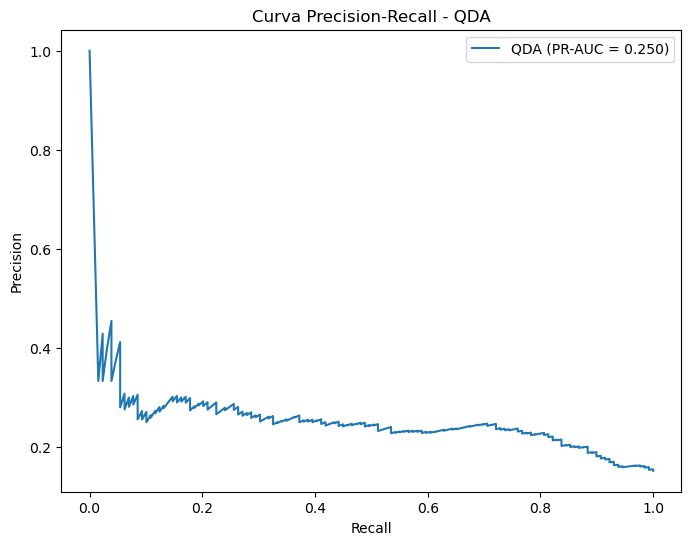


PR-AUC: 0.2500
Curva Precision-Recall generada correctamente.


In [130]:
# ==============================================================
# 1.20.5 - CURVA PRECISION-RECALL
# QUADRATIC DISCRIMINANT ANALYSIS (QDA)
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA PRECISION-RECALL...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular curva Precision-Recall
# --------------------------------------------------------------

precision_qda_curve, recall_qda_curve, _ = precision_recall_curve(
    y_test,
    y_prob_qda
)


# --------------------------------------------------------------
# Crear la gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    recall_qda_curve,
    precision_qda_curve,
    label=f"QDA (PR-AUC = {pr_auc_qda:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - QDA")

plt.legend()

plt.show()


print(f"\nPR-AUC: {pr_auc_qda:.4f}")
print("Curva Precision-Recall generada correctamente.")

In [131]:
# Añadir resultados del QDA

resultados.loc[len(resultados)] = [
    "Quadratic Discriminant Analysis (QDA)",
    accuracy_qda,
    precision_qda,
    recall_qda,
    f1_qda,
    roc_auc_qda,
    pr_auc_qda
]

resultados

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística,0.844340,0.411765,0.054264,0.095890,0.702774,0.302116
1,Linear Discriminant Analysis (LDA),0.838443,0.346154,0.069767,0.116129,0.700941,0.287816
2,Support Vector Machine (SVM),0.850236,0.750000,0.023256,0.045113,0.542064,0.220860
3,Stochastic Gradient Descent (SGD),0.818396,0.272727,0.116279,0.163043,0.660543,0.242477
4,K-Nearest Neighbors (KNN),0.839623,0.393939,0.100775,0.160494,0.569255,0.205580
5,Gaussian Naive Bayes,0.806604,0.253521,0.139535,0.180000,0.678068,0.252698
6,Decision Tree,0.750000,0.178295,0.178295,0.178295,0.515434,0.156789
7,Random Forest,0.844340,0.421053,0.062016,0.108108,0.632753,0.245967
8,Gradient Boosting,0.839623,0.370370,0.077519,0.128205,0.663130,0.258935
9,AdaBoost,0.850236,0.625000,0.038760,0.072993,0.681982,0.297005


In [132]:
# ==============================================================
# 1.21 - PASSIVE AGGRESSIVE CLASSIFIER
# INICIO DE LA FASE DE ENTRENAMIENTO
# ==============================================================

print("=" * 65)
print("1.21 - PASSIVE AGGRESSIVE CLASSIFIER")
print("INICIO DE LA FASE DE ENTRENAMIENTO")
print("=" * 65)


# --------------------------------------------------------------
# Importar el modelo
# --------------------------------------------------------------

from sklearn.linear_model import PassiveAggressiveClassifier


# --------------------------------------------------------------
# Crear el modelo
# --------------------------------------------------------------

modelo_pa = PassiveAggressiveClassifier(
    random_state=42,
    max_iter=1000
)


# --------------------------------------------------------------
# Entrenar el modelo
# --------------------------------------------------------------

modelo_pa.fit(
    X_train_scaled,
    y_train
)


print("\nModelo Passive Aggressive Classifier entrenado correctamente.")

1.21 - PASSIVE AGGRESSIVE CLASSIFIER
INICIO DE LA FASE DE ENTRENAMIENTO

Modelo Passive Aggressive Classifier entrenado correctamente.


In [133]:
# ==============================================================
# 1.21.1 - PASSIVE AGGRESSIVE CLASSIFIER
# INICIO DE LA FASE DE PREDICCIÓN
# ==============================================================

print("=" * 65)
print("1.21.1 - PASSIVE AGGRESSIVE CLASSIFIER")
print("INICIO DE LA FASE DE PREDICCIÓN")
print("=" * 65)


# --------------------------------------------------------------
# Realizar predicciones
# --------------------------------------------------------------

y_pred_pa = modelo_pa.predict(
    X_test_scaled
)


# --------------------------------------------------------------
# Obtener puntuaciones para ROC-AUC y PR-AUC
# --------------------------------------------------------------

y_score_pa = modelo_pa.decision_function(
    X_test_scaled
)


print("\nPredicciones realizadas correctamente.")

1.21.1 - PASSIVE AGGRESSIVE CLASSIFIER
INICIO DE LA FASE DE PREDICCIÓN

Predicciones realizadas correctamente.


In [134]:
# ==============================================================
# 1.21.2 - EVALUACIÓN DEL MODELO PASSIVE AGGRESSIVE CLASSIFIER
# ==============================================================

print("=" * 65)
print("1.21.2 - EVALUACIÓN DEL MODELO PASSIVE AGGRESSIVE CLASSIFIER")
print("=" * 65)


# --------------------------------------------------------------
# Calcular métricas
# --------------------------------------------------------------

accuracy_pa = accuracy_score(
    y_test,
    y_pred_pa
)

precision_pa = precision_score(
    y_test,
    y_pred_pa
)

recall_pa = recall_score(
    y_test,
    y_pred_pa
)

f1_pa = f1_score(
    y_test,
    y_pred_pa
)

roc_auc_pa = roc_auc_score(
    y_test,
    y_score_pa
)

pr_auc_pa = average_precision_score(
    y_test,
    y_score_pa
)


# --------------------------------------------------------------
# Mostrar resultados
# --------------------------------------------------------------

print(f"\nAccuracy:  {accuracy_pa:.4f}")
print(f"Precision: {precision_pa:.4f}")
print(f"Recall:    {recall_pa:.4f}")
print(f"F1-score:  {f1_pa:.4f}")
print(f"ROC-AUC:   {roc_auc_pa:.4f}")
print(f"PR-AUC:    {pr_auc_pa:.4f}")

print("\nEvaluación completada correctamente.")

1.21.2 - EVALUACIÓN DEL MODELO PASSIVE AGGRESSIVE CLASSIFIER

Accuracy:  0.7936
Precision: 0.2500
Recall:    0.1783
F1-score:  0.2081
ROC-AUC:   0.5761
PR-AUC:    0.2033

Evaluación completada correctamente.


GENERANDO MATRIZ DE CONFUSIÓN...


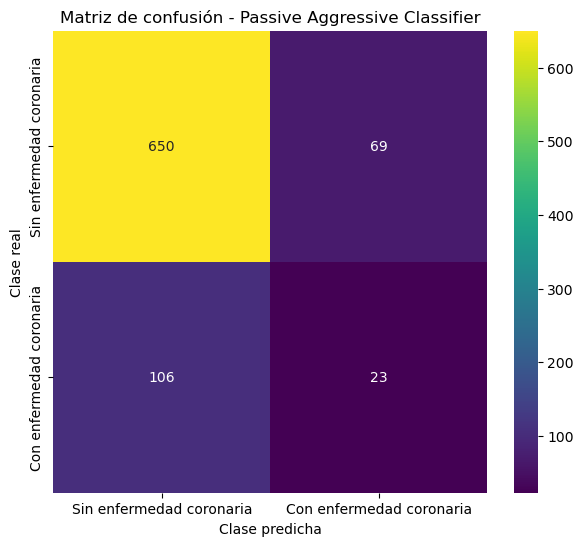


Matriz de confusión generada correctamente.


In [135]:
# ==============================================================
# 1.21.3 - MATRIZ DE CONFUSIÓN
# PASSIVE AGGRESSIVE CLASSIFIER
# ==============================================================

print("=" * 65)
print("GENERANDO MATRIZ DE CONFUSIÓN...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular matriz de confusión
# --------------------------------------------------------------

matriz_pa = confusion_matrix(
    y_test,
    y_pred_pa
)


# --------------------------------------------------------------
# Crear gráfica
# --------------------------------------------------------------

plt.figure(figsize=(7, 6))

sns.heatmap(
    matriz_pa,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ],
    yticklabels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ]
)

plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.title("Matriz de confusión - Passive Aggressive Classifier")

plt.show()


print("\nMatriz de confusión generada correctamente.")

GENERANDO CURVA ROC...


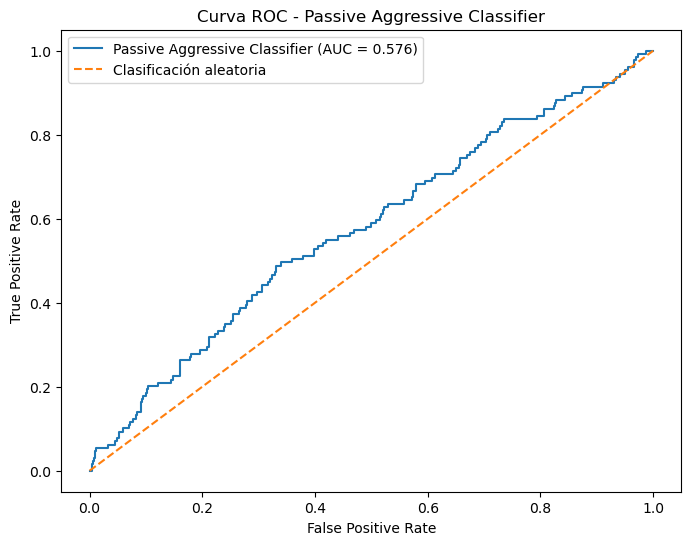


ROC-AUC: 0.5761
Curva ROC generada correctamente.


In [136]:
# ==============================================================
# 1.21.4 - CURVA ROC
# PASSIVE AGGRESSIVE CLASSIFIER
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA ROC...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular curva ROC
# --------------------------------------------------------------

fpr_pa, tpr_pa, _ = roc_curve(
    y_test,
    y_score_pa
)


# --------------------------------------------------------------
# Crear gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_pa,
    tpr_pa,
    label=f"Passive Aggressive Classifier (AUC = {roc_auc_pa:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Passive Aggressive Classifier")

plt.legend()

plt.show()


print(f"\nROC-AUC: {roc_auc_pa:.4f}")
print("Curva ROC generada correctamente.")

GENERANDO CURVA PRECISION-RECALL...


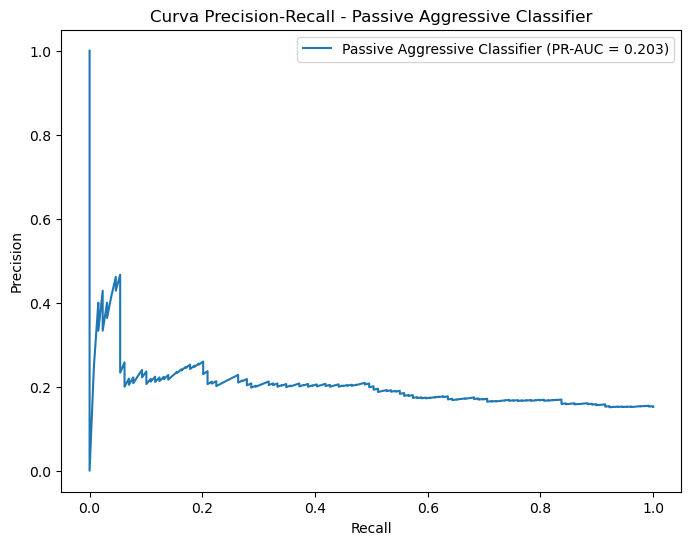


PR-AUC: 0.2033
Curva Precision-Recall generada correctamente.


In [137]:
# ==============================================================
# 1.21.5 - CURVA PRECISION-RECALL
# PASSIVE AGGRESSIVE CLASSIFIER
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA PRECISION-RECALL...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular curva Precision-Recall
# --------------------------------------------------------------

precision_curve_pa, recall_curve_pa, _ = precision_recall_curve(
    y_test,
    y_score_pa
)


# --------------------------------------------------------------
# Crear gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve_pa,
    precision_curve_pa,
    label=f"Passive Aggressive Classifier (PR-AUC = {pr_auc_pa:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Passive Aggressive Classifier")

plt.legend()

plt.show()


print(f"\nPR-AUC: {pr_auc_pa:.4f}")
print("Curva Precision-Recall generada correctamente.")

In [138]:
# ==============================================================
# AÑADIR PASSIVE AGGRESSIVE CLASSIFIER A LA TABLA DE RESULTADOS
# ==============================================================

nuevo_resultado = pd.DataFrame([{
    "Modelo": "Passive Aggressive Classifier",
    "Accuracy": accuracy_pa,
    "Precision": precision_pa,
    "Recall": recall_pa,
    "F1-score": f1_pa,
    "ROC-AUC": roc_auc_pa,
    "PR-AUC": pr_auc_pa
}])

resultados = pd.concat(
    [resultados, nuevo_resultado],
    ignore_index=True
)

resultados

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística,0.844340,0.411765,0.054264,0.095890,0.702774,0.302116
1,Linear Discriminant Analysis (LDA),0.838443,0.346154,0.069767,0.116129,0.700941,0.287816
2,Support Vector Machine (SVM),0.850236,0.750000,0.023256,0.045113,0.542064,0.220860
3,Stochastic Gradient Descent (SGD),0.818396,0.272727,0.116279,0.163043,0.660543,0.242477
4,K-Nearest Neighbors (KNN),0.839623,0.393939,0.100775,0.160494,0.569255,0.205580
5,Gaussian Naive Bayes,0.806604,0.253521,0.139535,0.180000,0.678068,0.252698
6,Decision Tree,0.750000,0.178295,0.178295,0.178295,0.515434,0.156789
7,Random Forest,0.844340,0.421053,0.062016,0.108108,0.632753,0.245967
8,Gradient Boosting,0.839623,0.370370,0.077519,0.128205,0.663130,0.258935
9,AdaBoost,0.850236,0.625000,0.038760,0.072993,0.681982,0.297005


In [139]:
# ==============================================================
# 1.22 - RIDGE CLASSIFIER
# INICIO DE LA FASE DE ENTRENAMIENTO
# ==============================================================

print("=" * 65)
print("1.22 - RIDGE CLASSIFIER")
print("INICIO DE LA FASE DE ENTRENAMIENTO")
print("=" * 65)


# --------------------------------------------------------------
# Importar el modelo
# --------------------------------------------------------------

from sklearn.linear_model import RidgeClassifier


# --------------------------------------------------------------
# Crear el modelo
# --------------------------------------------------------------

modelo_ridge = RidgeClassifier(
    random_state=42
)


# --------------------------------------------------------------
# Entrenar el modelo
# --------------------------------------------------------------

modelo_ridge.fit(
    X_train_scaled,
    y_train
)


print("\nModelo Ridge Classifier entrenado correctamente.")

1.22 - RIDGE CLASSIFIER
INICIO DE LA FASE DE ENTRENAMIENTO

Modelo Ridge Classifier entrenado correctamente.


In [140]:
# ==============================================================
# 1.22.1 - RIDGE CLASSIFIER
# INICIO DE LA FASE DE PREDICCIÓN
# ==============================================================

print("=" * 65)
print("1.22.1 - RIDGE CLASSIFIER")
print("INICIO DE LA FASE DE PREDICCIÓN")
print("=" * 65)


# --------------------------------------------------------------
# Realizar predicciones
# --------------------------------------------------------------

y_pred_ridge = modelo_ridge.predict(
    X_test_scaled
)


# --------------------------------------------------------------
# Obtener puntuaciones de decisión
# --------------------------------------------------------------

y_score_ridge = modelo_ridge.decision_function(
    X_test_scaled
)


print("\nPredicciones realizadas correctamente.")

1.22.1 - RIDGE CLASSIFIER
INICIO DE LA FASE DE PREDICCIÓN

Predicciones realizadas correctamente.


In [141]:
# ==============================================================
# 1.22.2 - EVALUACIÓN DEL MODELO RIDGE CLASSIFIER
# ==============================================================

print("=" * 65)
print("1.22.2 - EVALUACIÓN DEL MODELO RIDGE CLASSIFIER")
print("=" * 65)


# --------------------------------------------------------------
# Calcular métricas
# --------------------------------------------------------------

accuracy_ridge = accuracy_score(
    y_test,
    y_pred_ridge
)

precision_ridge = precision_score(
    y_test,
    y_pred_ridge,
    zero_division=0
)

recall_ridge = recall_score(
    y_test,
    y_pred_ridge,
    zero_division=0
)

f1_ridge = f1_score(
    y_test,
    y_pred_ridge,
    zero_division=0
)

roc_auc_ridge = roc_auc_score(
    y_test,
    y_score_ridge
)

pr_auc_ridge = average_precision_score(
    y_test,
    y_score_ridge
)


# --------------------------------------------------------------
# Mostrar resultados
# --------------------------------------------------------------

print(f"\nAccuracy:  {accuracy_ridge:.4f}")
print(f"Precision: {precision_ridge:.4f}")
print(f"Recall:    {recall_ridge:.4f}")
print(f"F1-score:  {f1_ridge:.4f}")
print(f"ROC-AUC:   {roc_auc_ridge:.4f}")
print(f"PR-AUC:    {pr_auc_ridge:.4f}")

print("\nEvaluación completada correctamente.")

1.22.2 - EVALUACIÓN DEL MODELO RIDGE CLASSIFIER

Accuracy:  0.8491
Precision: 0.5714
Recall:    0.0310
F1-score:  0.0588
ROC-AUC:   0.7010
PR-AUC:    0.2878

Evaluación completada correctamente.


GENERANDO MATRIZ DE CONFUSIÓN...


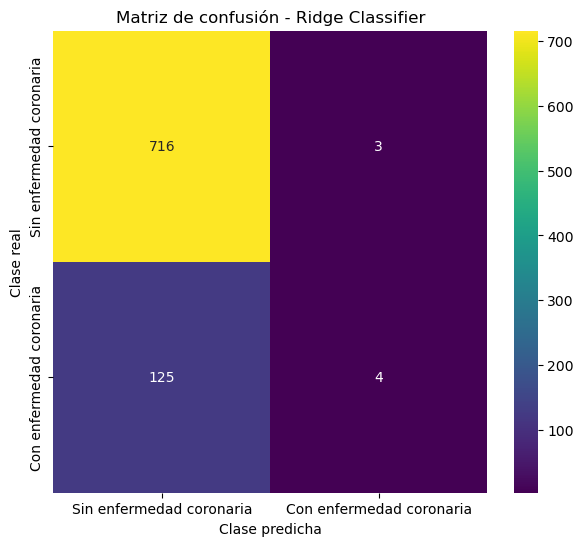


Matriz de confusión generada correctamente.


In [142]:
# ==============================================================
# 1.22.3 - MATRIZ DE CONFUSIÓN
# RIDGE CLASSIFIER
# ==============================================================

print("=" * 65)
print("GENERANDO MATRIZ DE CONFUSIÓN...")
print("=" * 65)


matriz_ridge = confusion_matrix(
    y_test,
    y_pred_ridge
)


plt.figure(figsize=(7, 6))

sns.heatmap(
    matriz_ridge,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ],
    yticklabels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ]
)

plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.title("Matriz de confusión - Ridge Classifier")

plt.show()


print("\nMatriz de confusión generada correctamente.")

GENERANDO CURVA ROC...


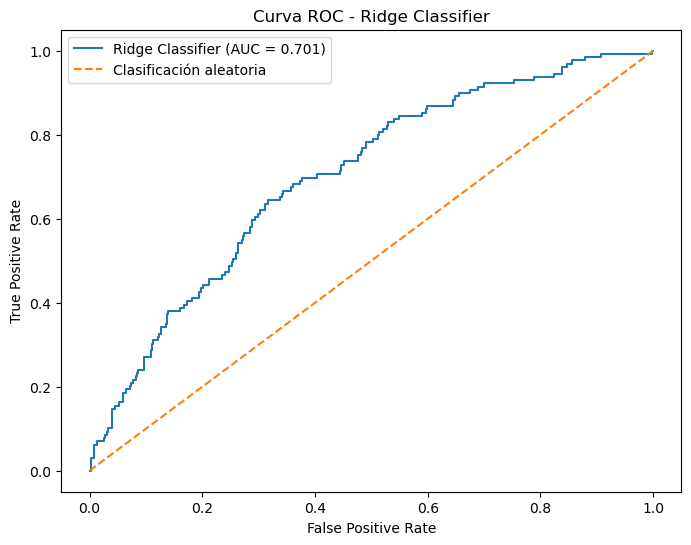


ROC-AUC: 0.7010
Curva ROC generada correctamente.


In [143]:
# ==============================================================
# 1.22.4 - CURVA ROC
# RIDGE CLASSIFIER
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA ROC...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular curva ROC
# --------------------------------------------------------------

fpr_ridge, tpr_ridge, _ = roc_curve(
    y_test,
    y_score_ridge
)


# --------------------------------------------------------------
# Crear gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_ridge,
    tpr_ridge,
    label=f"Ridge Classifier (AUC = {roc_auc_ridge:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Ridge Classifier")

plt.legend()
plt.show()


print(f"\nROC-AUC: {roc_auc_ridge:.4f}")
print("Curva ROC generada correctamente.")

GENERANDO CURVA PRECISION-RECALL...


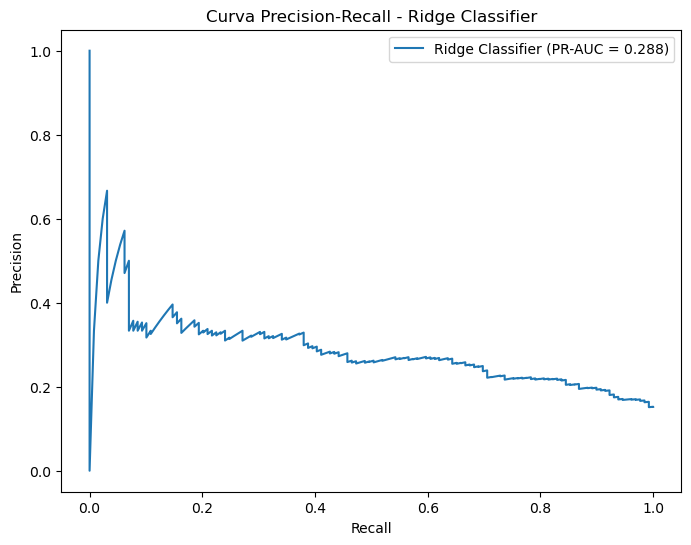


PR-AUC: 0.2878
Curva Precision-Recall generada correctamente.


In [144]:
# ==============================================================
# 1.22.5 - CURVA PRECISION-RECALL
# RIDGE CLASSIFIER
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA PRECISION-RECALL...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular curva Precision-Recall
# --------------------------------------------------------------

precision_curve_ridge, recall_curve_ridge, _ = precision_recall_curve(
    y_test,
    y_score_ridge
)


# --------------------------------------------------------------
# Crear gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve_ridge,
    precision_curve_ridge,
    label=f"Ridge Classifier (PR-AUC = {pr_auc_ridge:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Ridge Classifier")

plt.legend()
plt.show()


print(f"\nPR-AUC: {pr_auc_ridge:.4f}")
print("Curva Precision-Recall generada correctamente.")

In [145]:
# ==============================================================
# AÑADIR RIDGE CLASSIFIER A LA TABLA DE RESULTADOS
# ==============================================================

resultados.loc[len(resultados)] = [
    "Ridge Classifier",
    accuracy_ridge,
    precision_ridge,
    recall_ridge,
    f1_ridge,
    roc_auc_ridge,
    pr_auc_ridge
]

resultados

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística,0.844340,0.411765,0.054264,0.095890,0.702774,0.302116
1,Linear Discriminant Analysis (LDA),0.838443,0.346154,0.069767,0.116129,0.700941,0.287816
2,Support Vector Machine (SVM),0.850236,0.750000,0.023256,0.045113,0.542064,0.220860
3,Stochastic Gradient Descent (SGD),0.818396,0.272727,0.116279,0.163043,0.660543,0.242477
4,K-Nearest Neighbors (KNN),0.839623,0.393939,0.100775,0.160494,0.569255,0.205580
5,Gaussian Naive Bayes,0.806604,0.253521,0.139535,0.180000,0.678068,0.252698
6,Decision Tree,0.750000,0.178295,0.178295,0.178295,0.515434,0.156789
7,Random Forest,0.844340,0.421053,0.062016,0.108108,0.632753,0.245967
8,Gradient Boosting,0.839623,0.370370,0.077519,0.128205,0.663130,0.258935
9,AdaBoost,0.850236,0.625000,0.038760,0.072993,0.681982,0.297005


In [146]:
# ==============================================================
# 1.23 - LINEAR SVC
# INICIO DE LA FASE DE ENTRENAMIENTO
# ==============================================================

print("=" * 65)
print("1.23 - LINEAR SVC")
print("INICIO DE LA FASE DE ENTRENAMIENTO")
print("=" * 65)


# --------------------------------------------------------------
# Importar el modelo
# --------------------------------------------------------------

from sklearn.svm import LinearSVC


# --------------------------------------------------------------
# Crear el modelo
# --------------------------------------------------------------

modelo_linear_svc = LinearSVC(
    random_state=42,
    max_iter=10000
)


# --------------------------------------------------------------
# Entrenar el modelo
# --------------------------------------------------------------

modelo_linear_svc.fit(
    X_train_scaled,
    y_train
)


print("\nModelo LinearSVC entrenado correctamente.")

1.23 - LINEAR SVC
INICIO DE LA FASE DE ENTRENAMIENTO

Modelo LinearSVC entrenado correctamente.


In [147]:
# ==============================================================
# 1.23.1 - LINEAR SVC
# INICIO DE LA FASE DE PREDICCIÓN
# ==============================================================

print("=" * 65)
print("1.23.1 - LINEAR SVC")
print("INICIO DE LA FASE DE PREDICCIÓN")
print("=" * 65)


# --------------------------------------------------------------
# Realizar predicciones
# --------------------------------------------------------------

y_pred_linear_svc = modelo_linear_svc.predict(
    X_test_scaled
)


# --------------------------------------------------------------
# Obtener puntuaciones de decisión
# --------------------------------------------------------------

y_score_linear_svc = modelo_linear_svc.decision_function(
    X_test_scaled
)


print("\nPredicciones realizadas correctamente.")

1.23.1 - LINEAR SVC
INICIO DE LA FASE DE PREDICCIÓN

Predicciones realizadas correctamente.


In [148]:
# ==============================================================
# 1.23.2 - EVALUACIÓN DEL MODELO LINEAR SVC
# ==============================================================

print("=" * 65)
print("1.23.2 - EVALUACIÓN DEL MODELO LINEAR SVC")
print("=" * 65)


# --------------------------------------------------------------
# Calcular métricas
# --------------------------------------------------------------

accuracy_linear_svc = accuracy_score(
    y_test,
    y_pred_linear_svc
)

precision_linear_svc = precision_score(
    y_test,
    y_pred_linear_svc,
    zero_division=0
)

recall_linear_svc = recall_score(
    y_test,
    y_pred_linear_svc,
    zero_division=0
)

f1_linear_svc = f1_score(
    y_test,
    y_pred_linear_svc,
    zero_division=0
)

roc_auc_linear_svc = roc_auc_score(
    y_test,
    y_score_linear_svc
)

pr_auc_linear_svc = average_precision_score(
    y_test,
    y_score_linear_svc
)


# --------------------------------------------------------------
# Mostrar resultados
# --------------------------------------------------------------

print(f"\nAccuracy:  {accuracy_linear_svc:.4f}")
print(f"Precision: {precision_linear_svc:.4f}")
print(f"Recall:    {recall_linear_svc:.4f}")
print(f"F1-score:  {f1_linear_svc:.4f}")
print(f"ROC-AUC:   {roc_auc_linear_svc:.4f}")
print(f"PR-AUC:    {pr_auc_linear_svc:.4f}")

print("\nEvaluación completada correctamente.")

1.23.2 - EVALUACIÓN DEL MODELO LINEAR SVC

Accuracy:  0.8479
Precision: 0.5000
Recall:    0.0310
F1-score:  0.0584
ROC-AUC:   0.7010
PR-AUC:    0.2879

Evaluación completada correctamente.


GENERANDO MATRIZ DE CONFUSIÓN...


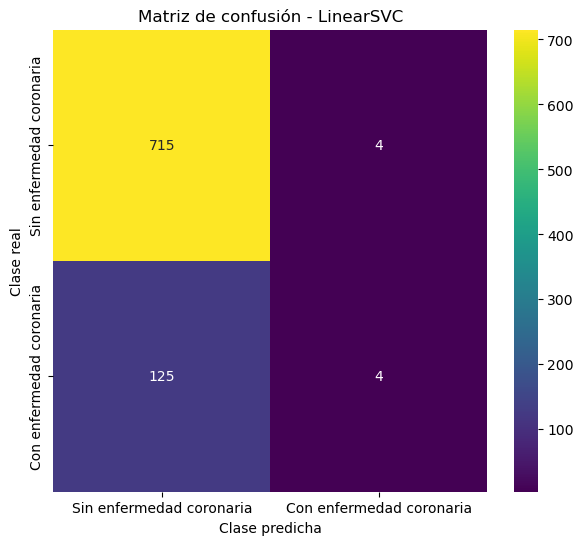


Matriz de confusión generada correctamente.


In [149]:
# ==============================================================
# 1.23.3 - MATRIZ DE CONFUSIÓN
# LINEAR SVC
# ==============================================================

print("=" * 65)
print("GENERANDO MATRIZ DE CONFUSIÓN...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular matriz de confusión
# --------------------------------------------------------------

matriz_linear_svc = confusion_matrix(
    y_test,
    y_pred_linear_svc
)


# --------------------------------------------------------------
# Crear gráfica
# --------------------------------------------------------------

plt.figure(figsize=(7, 6))

sns.heatmap(
    matriz_linear_svc,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ],
    yticklabels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ]
)

plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.title("Matriz de confusión - LinearSVC")

plt.show()


print("\nMatriz de confusión generada correctamente.")

GENERANDO CURVA ROC...


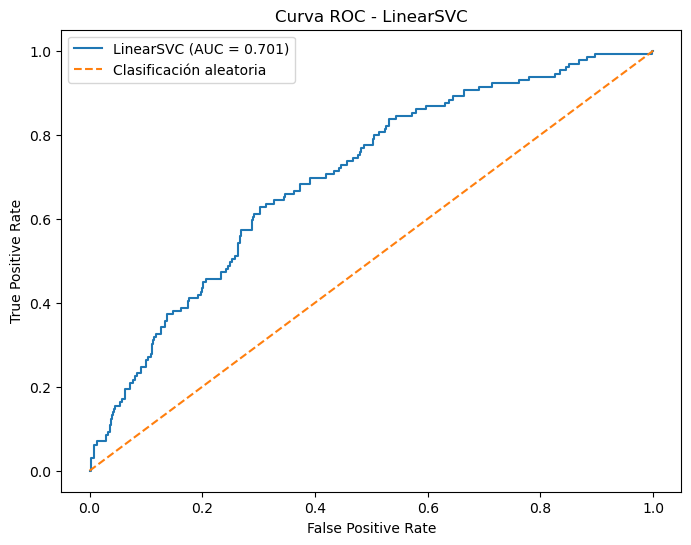


ROC-AUC: 0.7010
Curva ROC generada correctamente.


In [150]:
# ==============================================================
# 1.23.4 - CURVA ROC
# LINEAR SVC
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA ROC...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular curva ROC
# --------------------------------------------------------------

fpr_linear_svc, tpr_linear_svc, _ = roc_curve(
    y_test,
    y_score_linear_svc
)


# --------------------------------------------------------------
# Crear gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_linear_svc,
    tpr_linear_svc,
    label=f"LinearSVC (AUC = {roc_auc_linear_svc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - LinearSVC")

plt.legend()
plt.show()


print(f"\nROC-AUC: {roc_auc_linear_svc:.4f}")
print("Curva ROC generada correctamente.")

GENERANDO CURVA PRECISION-RECALL...


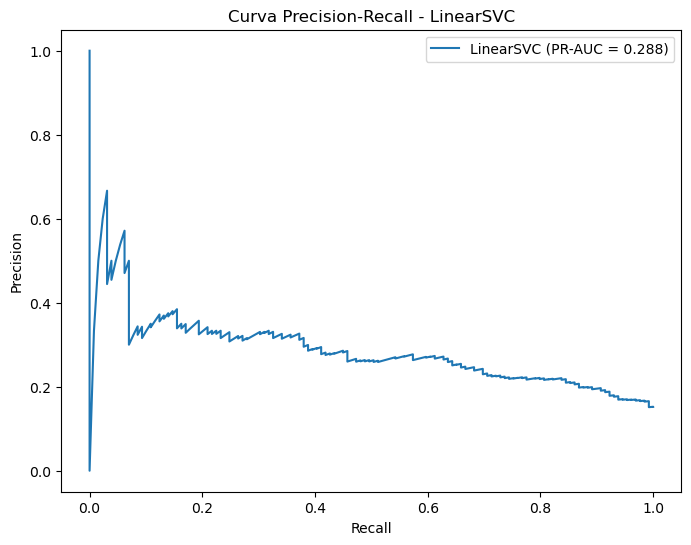


PR-AUC: 0.2879
Curva Precision-Recall generada correctamente.


In [151]:
# ==============================================================
# 1.23.5 - CURVA PRECISION-RECALL
# LINEAR SVC
# ==============================================================

print("=" * 65)
print("GENERANDO CURVA PRECISION-RECALL...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular curva Precision-Recall
# --------------------------------------------------------------

precision_curve_linear_svc, recall_curve_linear_svc, _ = precision_recall_curve(
    y_test,
    y_score_linear_svc
)


# --------------------------------------------------------------
# Crear gráfica
# --------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve_linear_svc,
    precision_curve_linear_svc,
    label=f"LinearSVC (PR-AUC = {pr_auc_linear_svc:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - LinearSVC")

plt.legend()
plt.show()


print(f"\nPR-AUC: {pr_auc_linear_svc:.4f}")
print("Curva Precision-Recall generada correctamente.")

In [152]:
# ==============================================================
# AÑADIR LINEAR SVC A LA TABLA DE RESULTADOS
# ==============================================================

resultados.loc[len(resultados)] = [
    "LinearSVC",
    accuracy_linear_svc,
    precision_linear_svc,
    recall_linear_svc,
    f1_linear_svc,
    roc_auc_linear_svc,
    pr_auc_linear_svc
]

resultados

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística,0.844340,0.411765,0.054264,0.095890,0.702774,0.302116
1,Linear Discriminant Analysis (LDA),0.838443,0.346154,0.069767,0.116129,0.700941,0.287816
2,Support Vector Machine (SVM),0.850236,0.750000,0.023256,0.045113,0.542064,0.220860
3,Stochastic Gradient Descent (SGD),0.818396,0.272727,0.116279,0.163043,0.660543,0.242477
4,K-Nearest Neighbors (KNN),0.839623,0.393939,0.100775,0.160494,0.569255,0.205580
5,Gaussian Naive Bayes,0.806604,0.253521,0.139535,0.180000,0.678068,0.252698
6,Decision Tree,0.750000,0.178295,0.178295,0.178295,0.515434,0.156789
7,Random Forest,0.844340,0.421053,0.062016,0.108108,0.632753,0.245967
8,Gradient Boosting,0.839623,0.370370,0.077519,0.128205,0.663130,0.258935
9,AdaBoost,0.850236,0.625000,0.038760,0.072993,0.681982,0.297005


In [153]:
# ==============================================================
# 1.24 - NEAREST CENTROID
# INICIO DE LA FASE DE ENTRENAMIENTO
# ==============================================================

print("=" * 65)
print("1.24 - NEAREST CENTROID")
print("INICIO DE LA FASE DE ENTRENAMIENTO")
print("=" * 65)


# --------------------------------------------------------------
# Importar el modelo
# --------------------------------------------------------------

from sklearn.neighbors import NearestCentroid


# --------------------------------------------------------------
# Crear el modelo
# --------------------------------------------------------------

modelo_nc = NearestCentroid()


# --------------------------------------------------------------
# Entrenar el modelo
# --------------------------------------------------------------

modelo_nc.fit(
    X_train_scaled,
    y_train
)


print("\nModelo Nearest Centroid entrenado correctamente.")

1.24 - NEAREST CENTROID
INICIO DE LA FASE DE ENTRENAMIENTO

Modelo Nearest Centroid entrenado correctamente.


In [154]:
# ==============================================================
# 1.24.1 - NEAREST CENTROID
# INICIO DE LA FASE DE PREDICCIÓN
# ==============================================================

print("=" * 65)
print("1.24.1 - NEAREST CENTROID")
print("INICIO DE LA FASE DE PREDICCIÓN")
print("=" * 65)


# --------------------------------------------------------------
# Realizar predicciones
# --------------------------------------------------------------

y_pred_nc = modelo_nc.predict(
    X_test_scaled
)


print("\nPredicciones realizadas correctamente.")

1.24.1 - NEAREST CENTROID
INICIO DE LA FASE DE PREDICCIÓN

Predicciones realizadas correctamente.


In [155]:
# ==============================================================
# 1.24.2 - EVALUACIÓN DEL MODELO NEAREST CENTROID
# ==============================================================

print("=" * 65)
print("1.24.2 - EVALUACIÓN DEL MODELO NEAREST CENTROID")
print("=" * 65)


# --------------------------------------------------------------
# Calcular métricas de clasificación
# --------------------------------------------------------------

accuracy_nc = accuracy_score(
    y_test,
    y_pred_nc
)

precision_nc = precision_score(
    y_test,
    y_pred_nc,
    zero_division=0
)

recall_nc = recall_score(
    y_test,
    y_pred_nc,
    zero_division=0
)

f1_nc = f1_score(
    y_test,
    y_pred_nc,
    zero_division=0
)


# --------------------------------------------------------------
# Mostrar resultados
# --------------------------------------------------------------

print(f"\nAccuracy:  {accuracy_nc:.4f}")
print(f"Precision: {precision_nc:.4f}")
print(f"Recall:    {recall_nc:.4f}")
print(f"F1-score:  {f1_nc:.4f}")

print("\nEvaluación completada correctamente.")

1.24.2 - EVALUACIÓN DEL MODELO NEAREST CENTROID

Accuracy:  0.6792
Precision: 0.2419
Recall:    0.5194
F1-score:  0.3300

Evaluación completada correctamente.


GENERANDO MATRIZ DE CONFUSIÓN...


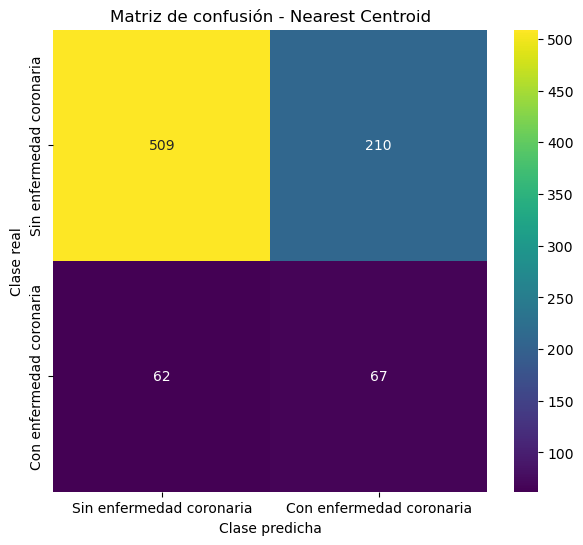


Matriz de confusión generada correctamente.


In [156]:
# ==============================================================
# 1.24.3 - MATRIZ DE CONFUSIÓN
# NEAREST CENTROID
# ==============================================================

print("=" * 65)
print("GENERANDO MATRIZ DE CONFUSIÓN...")
print("=" * 65)


# --------------------------------------------------------------
# Calcular matriz de confusión
# --------------------------------------------------------------

matriz_nc = confusion_matrix(
    y_test,
    y_pred_nc
)


# --------------------------------------------------------------
# Crear gráfica
# --------------------------------------------------------------

plt.figure(figsize=(7, 6))

sns.heatmap(
    matriz_nc,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ],
    yticklabels=[
        "Sin enfermedad coronaria",
        "Con enfermedad coronaria"
    ]
)

plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.title("Matriz de confusión - Nearest Centroid")

plt.show()


print("\nMatriz de confusión generada correctamente.")

In [157]:
# ==============================================================
# AÑADIR NEAREST CENTROID A LA TABLA DE RESULTADOS
# ==============================================================

import numpy as np

resultados.loc[len(resultados)] = [
    "Nearest Centroid",
    accuracy_nc,
    precision_nc,
    recall_nc,
    f1_nc,
    np.nan,
    np.nan
]

resultados

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística,0.844340,0.411765,0.054264,0.095890,0.702774,0.302116
1,Linear Discriminant Analysis (LDA),0.838443,0.346154,0.069767,0.116129,0.700941,0.287816
2,Support Vector Machine (SVM),0.850236,0.750000,0.023256,0.045113,0.542064,0.220860
3,Stochastic Gradient Descent (SGD),0.818396,0.272727,0.116279,0.163043,0.660543,0.242477
4,K-Nearest Neighbors (KNN),0.839623,0.393939,0.100775,0.160494,0.569255,0.205580
5,Gaussian Naive Bayes,0.806604,0.253521,0.139535,0.180000,0.678068,0.252698
6,Decision Tree,0.750000,0.178295,0.178295,0.178295,0.515434,0.156789
7,Random Forest,0.844340,0.421053,0.062016,0.108108,0.632753,0.245967
8,Gradient Boosting,0.839623,0.370370,0.077519,0.128205,0.663130,0.258935
9,AdaBoost,0.850236,0.625000,0.038760,0.072993,0.681982,0.297005


In [158]:
# ==============================================================
# 2.1 - K-MEANS CLUSTERING
# PARTE 1: PREPARACIÓN DE LOS DATOS
# ==============================================================

print("=" * 65)
print("2.1 - K-MEANS CLUSTERING")
print("PREPARACIÓN DE LOS DATOS PARA CLUSTERING")
print("=" * 65)


# --------------------------------------------------------------
# Para clustering utilizamos las variables clínicas escaladas
# sin utilizar TenYearCHD como variable de entrada
# --------------------------------------------------------------

X_clustering = X_train_scaled


print("\nDatos preparados correctamente para clustering.")
print("Número de pacientes:", X_clustering.shape[0])
print("Número de variables:", X_clustering.shape[1])

2.1 - K-MEANS CLUSTERING
PREPARACIÓN DE LOS DATOS PARA CLUSTERING

Datos preparados correctamente para clustering.
Número de pacientes: 3392
Número de variables: 15


In [159]:
# ==============================================================
# 2.1.1 - K-MEANS
# SELECCIÓN DEL NÚMERO ÓPTIMO DE CLUSTERS
# ==============================================================

print("=" * 65)
print("2.1.1 - SELECCIÓN DEL NÚMERO ÓPTIMO DE CLUSTERS")
print("=" * 65)


# --------------------------------------------------------------
# Importar herramientas necesarias
# --------------------------------------------------------------

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------------------------------
# Probar diferentes valores de k
# --------------------------------------------------------------

valores_k = range(2, 11)

inercias = []
silhouettes = []


for k in valores_k:

    modelo_kmeans_temporal = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    etiquetas_temporales = modelo_kmeans_temporal.fit_predict(
        X_clustering
    )

    # Inercia del modelo
    inercias.append(
        modelo_kmeans_temporal.inertia_
    )

    # Silhouette Score
    silhouettes.append(
        silhouette_score(
            X_clustering,
            etiquetas_temporales
        )
    )


# --------------------------------------------------------------
# Crear tabla con los resultados
# --------------------------------------------------------------

evaluacion_k = pd.DataFrame({
    "Número de clusters (k)": list(valores_k),
    "Inercia": inercias,
    "Silhouette Score": silhouettes
})


print("\nRESULTADOS PARA CADA VALOR DE k:\n")

display(evaluacion_k)

2.1.1 - SELECCIÓN DEL NÚMERO ÓPTIMO DE CLUSTERS

RESULTADOS PARA CADA VALOR DE k:



,Número de clusters (k),Inercia,Silhouette Score
0,2,43199.341924,0.213467
1,3,38849.630833,0.215572
2,4,34933.046559,0.144060
3,5,31649.549404,0.154868
4,6,30298.778998,0.145046
5,7,27191.423991,0.156382
6,8,25819.433504,0.160167
7,9,24723.501637,0.147697
8,10,23839.672171,0.149338


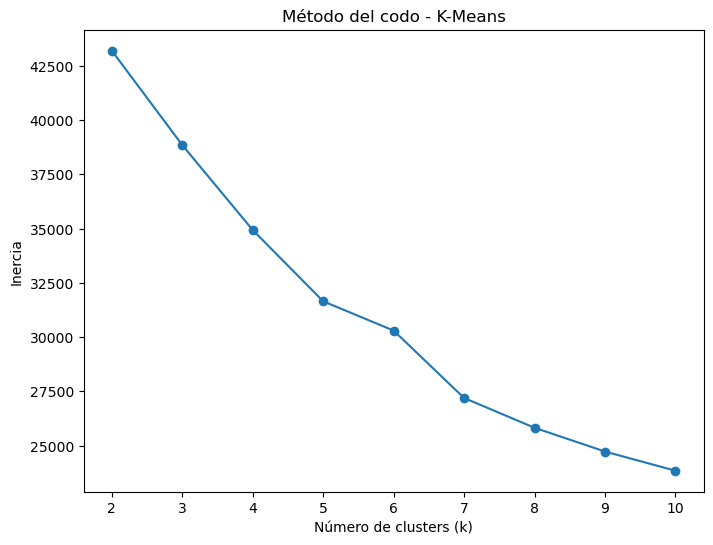

In [160]:
# ==============================================================
# 2.1.2 - MÉTODO DEL CODO
# ==============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    list(valores_k),
    inercias,
    marker="o"
)

plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del codo - K-Means")

plt.xticks(list(valores_k))

plt.show()

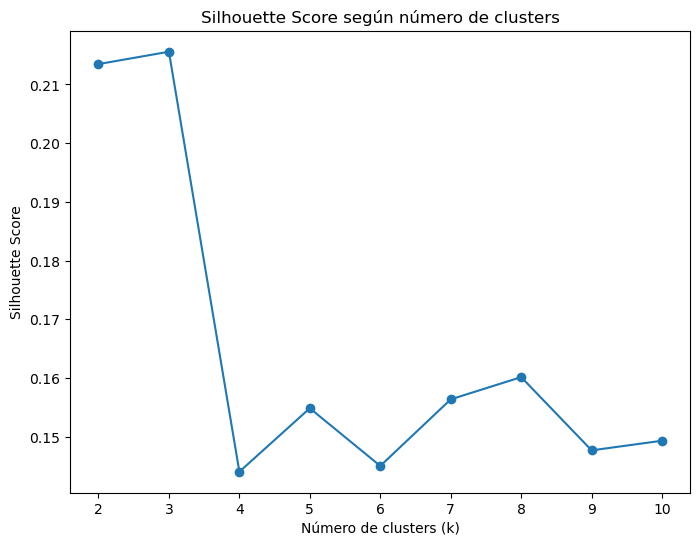

In [161]:
# ==============================================================
# 2.1.3 - SILHOUETTE SCORE
# ==============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    list(valores_k),
    silhouettes,
    marker="o"
)

plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score según número de clusters")

plt.xticks(list(valores_k))

plt.show()

In [162]:
# ==============================================================
# 2.1.4 - K-MEANS DEFINITIVO
# ENTRENAMIENTO CON k = 3
# ==============================================================

print("=" * 65)
print("2.1.4 - K-MEANS DEFINITIVO")
print("NÚMERO DE CLUSTERS SELECCIONADO: k = 3")
print("=" * 65)


from sklearn.cluster import KMeans


# --------------------------------------------------------------
# Crear el modelo definitivo
# --------------------------------------------------------------

modelo_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)


# --------------------------------------------------------------
# Entrenar el modelo y obtener el cluster de cada paciente
# --------------------------------------------------------------

clusters_kmeans = modelo_kmeans.fit_predict(
    X_clustering
)


print("\nModelo K-Means entrenado correctamente.")
print("Número de clusters encontrados:", len(set(clusters_kmeans)))

2.1.4 - K-MEANS DEFINITIVO
NÚMERO DE CLUSTERS SELECCIONADO: k = 3

Modelo K-Means entrenado correctamente.
Número de clusters encontrados: 3


In [163]:
# ==============================================================
# 2.1.5 - EVALUACIÓN DEL MODELO K-MEANS
# ==============================================================

print("=" * 65)
print("2.1.5 - EVALUACIÓN DEL MODELO K-MEANS")
print("=" * 65)


# --------------------------------------------------------------
# Importar métricas de clustering
# --------------------------------------------------------------

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)


# --------------------------------------------------------------
# Calcular métricas
# --------------------------------------------------------------

silhouette_kmeans = silhouette_score(
    X_clustering,
    clusters_kmeans
)

davies_kmeans = davies_bouldin_score(
    X_clustering,
    clusters_kmeans
)

calinski_kmeans = calinski_harabasz_score(
    X_clustering,
    clusters_kmeans
)


# --------------------------------------------------------------
# Mostrar resultados
# --------------------------------------------------------------

print(f"\nSilhouette Score:       {silhouette_kmeans:.4f}")
print(f"Davies-Bouldin Index:   {davies_kmeans:.4f}")
print(f"Calinski-Harabasz Score:{calinski_kmeans:.4f}")

print("\nEvaluación completada correctamente.")

2.1.5 - EVALUACIÓN DEL MODELO K-MEANS

Silhouette Score:       0.2156
Davies-Bouldin Index:   1.7458
Calinski-Harabasz Score:524.7282

Evaluación completada correctamente.


In [164]:
# ==============================================================
# 2.1.6 - DISTRIBUCIÓN DE PACIENTES POR CLUSTER
# ==============================================================

print("=" * 65)
print("2.1.6 - DISTRIBUCIÓN DE PACIENTES POR CLUSTER")
print("=" * 65)

import pandas as pd

distribucion_clusters = pd.Series(
    clusters_kmeans
).value_counts().sort_index()

for cluster, cantidad in distribucion_clusters.items():

    porcentaje = (
        cantidad / len(clusters_kmeans)
    ) * 100

    print(
        f"Cluster {cluster}: "
        f"{cantidad} pacientes "
        f"({porcentaje:.2f}%)"
    )

print("\nDistribución de clusters calculada correctamente.")

2.1.6 - DISTRIBUCIÓN DE PACIENTES POR CLUSTER
Cluster 0: 1049 pacientes (30.93%)
Cluster 1: 2255 pacientes (66.48%)
Cluster 2: 88 pacientes (2.59%)

Distribución de clusters calculada correctamente.


In [165]:
# ==============================================================
# 2.1.7 - PREVALENCIA DE TenYearCHD POR CLUSTER
# ==============================================================

print("=" * 65)
print("2.1.7 - PREVALENCIA DE ENFERMEDAD CORONARIA POR CLUSTER")
print("=" * 65)


# --------------------------------------------------------------
# Crear DataFrame con cluster y variable objetivo
# --------------------------------------------------------------

analisis_clusters = pd.DataFrame({
    "Cluster": clusters_kmeans,
    "TenYearCHD": y_train.reset_index(drop=True)
})


# --------------------------------------------------------------
# Calcular número de pacientes, casos positivos
# y porcentaje de TenYearCHD = 1 en cada cluster
# --------------------------------------------------------------

resumen_chd_clusters = analisis_clusters.groupby("Cluster").agg(
    Pacientes=("TenYearCHD", "size"),
    Casos_CHD=("TenYearCHD", "sum"),
    Prevalencia_CHD=("TenYearCHD", "mean")
)


# Convertir prevalencia a porcentaje
resumen_chd_clusters["Prevalencia_CHD_%"] = (
    resumen_chd_clusters["Prevalencia_CHD"] * 100
)


# Mostrar solo columnas útiles
resumen_chd_clusters = resumen_chd_clusters[
    [
        "Pacientes",
        "Casos_CHD",
        "Prevalencia_CHD_%"
    ]
]


print("\nRIESGO CORONARIO POR CLUSTER:\n")

display(resumen_chd_clusters)

2.1.7 - PREVALENCIA DE ENFERMEDAD CORONARIA POR CLUSTER

RIESGO CORONARIO POR CLUSTER:



,Pacientes,Casos_CHD,Prevalencia_CHD_%
Cluster,,,
0,1049,252.0,24.022879
1,2255,231.0,10.243902
2,88,32.0,36.363636


In [166]:
# ==============================================================
# 2.1.8 - PERFIL CLÍNICO MEDIO DE CADA CLUSTER
# ==============================================================

print("=" * 65)
print("2.1.8 - PERFIL CLÍNICO MEDIO DE CADA CLUSTER")
print("=" * 65)


# --------------------------------------------------------------
# Recuperar las variables originales del conjunto de entrenamiento
# --------------------------------------------------------------

X_train_original = X_train.reset_index(drop=True).copy()


# --------------------------------------------------------------
# Añadir la etiqueta del cluster asignado por K-Means
# --------------------------------------------------------------

X_train_original["Cluster"] = clusters_kmeans


# --------------------------------------------------------------
# Calcular la media de cada variable para cada cluster
# --------------------------------------------------------------

perfil_clusters = X_train_original.groupby("Cluster").mean()


print("\nPERFIL CLÍNICO MEDIO POR CLUSTER:\n")

display(perfil_clusters)

2.1.8 - PERFIL CLÍNICO MEDIO DE CADA CLUSTER

PERFIL CLÍNICO MEDIO POR CLUSTER:



,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
Cluster,,,,,,,,,,,,,,,
0,0.406101,53.897998,1.846330,0.392755,7.191039,0.086559,0.016206,0.935176,0.0,248.484080,155.264538,94.144900,27.717521,78.622879,81.379028
1,0.436807,47.493570,2.051707,0.542350,9.954235,0.000177,0.001774,0.011530,0.0,230.777472,121.245455,77.505100,24.866442,74.492683,78.810200
2,0.488636,54.806818,1.795455,0.386364,6.829545,0.068182,0.011364,0.522727,1.0,248.327273,147.215909,86.488636,27.939886,79.227273,166.611364


2.1.9 - COMPARACIÓN CLÍNICA DE LOS CLUSTERS


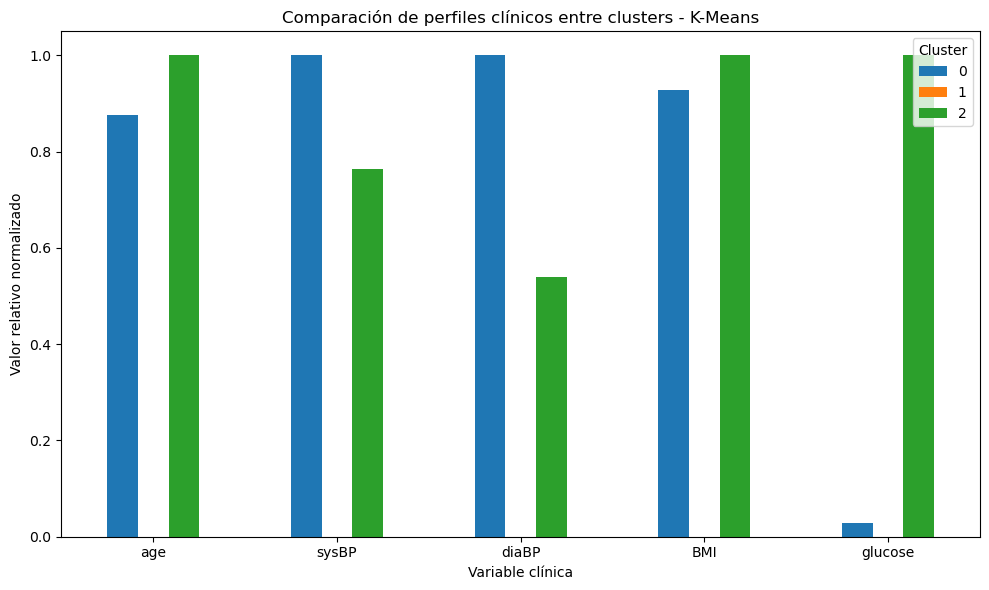


Gráfica comparativa generada correctamente.


In [167]:
# ==============================================================
# 2.1.9 - COMPARACIÓN CLÍNICA DE LOS CLUSTERS
# ==============================================================

print("=" * 65)
print("2.1.9 - COMPARACIÓN CLÍNICA DE LOS CLUSTERS")
print("=" * 65)


# --------------------------------------------------------------
# Seleccionar variables clínicas clave
# --------------------------------------------------------------

variables_clave = [
    "age",
    "sysBP",
    "diaBP",
    "BMI",
    "glucose"
]


# --------------------------------------------------------------
# Obtener medias por cluster
# --------------------------------------------------------------

perfil_clave = perfil_clusters[
    variables_clave
].copy()


# --------------------------------------------------------------
# Normalizar únicamente para facilitar la comparación gráfica
# --------------------------------------------------------------

perfil_normalizado = (
    perfil_clave - perfil_clave.min()
) / (
    perfil_clave.max() - perfil_clave.min()
)


# --------------------------------------------------------------
# Crear gráfica
# --------------------------------------------------------------

perfil_normalizado.T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Comparación de perfiles clínicos entre clusters - K-Means"
)

plt.xlabel("Variable clínica")
plt.ylabel("Valor relativo normalizado")

plt.xticks(rotation=0)

plt.legend(
    title="Cluster"
)

plt.tight_layout()
plt.show()


print("\nGráfica comparativa generada correctamente.")

In [168]:
# ==============================================================
# TABLA 2 - RESULTADOS DE CLUSTERING
# AÑADIR K-MEANS
# ==============================================================

import pandas as pd

resultados_clustering = pd.DataFrame([
    {
        "Algoritmo": "K-Means",
        "N_clusters": 3,
        "Silhouette": silhouette_kmeans,
        "Davies-Bouldin": davies_kmeans,
        "Calinski-Harabasz": calinski_kmeans
    }
])

print("=" * 65)
print("TABLA 2 - RESULTADOS DE CLUSTERING")
print("=" * 65)

display(resultados_clustering)

TABLA 2 - RESULTADOS DE CLUSTERING


,Algoritmo,N_clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,3,0.215572,1.74575,524.728157


In [169]:
# ==============================================================
# 2.2 - AGGLOMERATIVE CLUSTERING
# INICIO DE LA FASE DE ENTRENAMIENTO
# ==============================================================

print("=" * 65)
print("2.2 - AGGLOMERATIVE CLUSTERING")
print("INICIO DE LA FASE DE ENTRENAMIENTO")
print("=" * 65)


# --------------------------------------------------------------
# Importar el modelo
# --------------------------------------------------------------

from sklearn.cluster import AgglomerativeClustering


# --------------------------------------------------------------
# Crear el modelo
# --------------------------------------------------------------

modelo_agg = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)


# --------------------------------------------------------------
# Entrenar y obtener cluster de cada paciente
# --------------------------------------------------------------

clusters_agg = modelo_agg.fit_predict(
    X_clustering
)


print("\nModelo Agglomerative Clustering ejecutado correctamente.")
print("Número de clusters encontrados:", len(set(clusters_agg)))

2.2 - AGGLOMERATIVE CLUSTERING
INICIO DE LA FASE DE ENTRENAMIENTO

Modelo Agglomerative Clustering ejecutado correctamente.
Número de clusters encontrados: 3


In [170]:
# ==============================================================
# 2.2.1 - EVALUACIÓN DEL MODELO AGGLOMERATIVE CLUSTERING
# ==============================================================

print("=" * 65)
print("2.2.1 - EVALUACIÓN DEL MODELO AGGLOMERATIVE CLUSTERING")
print("=" * 65)


# --------------------------------------------------------------
# Calcular métricas de clustering
# --------------------------------------------------------------

silhouette_agg = silhouette_score(
    X_clustering,
    clusters_agg
)

davies_agg = davies_bouldin_score(
    X_clustering,
    clusters_agg
)

calinski_agg = calinski_harabasz_score(
    X_clustering,
    clusters_agg
)


# --------------------------------------------------------------
# Mostrar resultados
# --------------------------------------------------------------

print(f"\nSilhouette Score:        {silhouette_agg:.4f}")
print(f"Davies-Bouldin Index:    {davies_agg:.4f}")
print(f"Calinski-Harabasz Score: {calinski_agg:.4f}")

print("\nEvaluación completada correctamente.")

2.2.1 - EVALUACIÓN DEL MODELO AGGLOMERATIVE CLUSTERING

Silhouette Score:        0.2191
Davies-Bouldin Index:    1.7672
Calinski-Harabasz Score: 509.6620

Evaluación completada correctamente.


In [171]:
# ==============================================================
# 2.2.2 - DISTRIBUCIÓN DE PACIENTES POR CLUSTER
# AGGLOMERATIVE CLUSTERING
# ==============================================================

print("=" * 65)
print("2.2.2 - DISTRIBUCIÓN DE PACIENTES POR CLUSTER")
print("=" * 65)

import pandas as pd

distribucion_agg = pd.Series(
    clusters_agg
).value_counts().sort_index()

for cluster, cantidad in distribucion_agg.items():

    porcentaje = (
        cantidad / len(clusters_agg)
    ) * 100

    print(
        f"Cluster {cluster}: "
        f"{cantidad} pacientes "
        f"({porcentaje:.2f}%)"
    )

print("\nDistribución de clusters calculada correctamente.")

2.2.2 - DISTRIBUCIÓN DE PACIENTES POR CLUSTER
Cluster 0: 2284 pacientes (67.33%)
Cluster 1: 1021 pacientes (30.10%)
Cluster 2: 87 pacientes (2.56%)

Distribución de clusters calculada correctamente.


In [172]:
# ==============================================================
# 2.2.3 - PREVALENCIA DE TenYearCHD POR CLUSTER
# AGGLOMERATIVE CLUSTERING
# ==============================================================

print("=" * 65)
print("2.2.3 - PREVALENCIA DE ENFERMEDAD CORONARIA POR CLUSTER")
print("=" * 65)


# --------------------------------------------------------------
# Crear DataFrame con cluster y variable objetivo
# --------------------------------------------------------------

analisis_agg = pd.DataFrame({
    "Cluster": clusters_agg,
    "TenYearCHD": y_train.reset_index(drop=True)
})


# --------------------------------------------------------------
# Calcular pacientes, casos CHD y prevalencia
# --------------------------------------------------------------

resumen_chd_agg = analisis_agg.groupby("Cluster").agg(
    Pacientes=("TenYearCHD", "size"),
    Casos_CHD=("TenYearCHD", "sum"),
    Prevalencia_CHD=("TenYearCHD", "mean")
)


# Convertir prevalencia a porcentaje
resumen_chd_agg["Prevalencia_CHD_%"] = (
    resumen_chd_agg["Prevalencia_CHD"] * 100
)


# Mostrar columnas finales
resumen_chd_agg = resumen_chd_agg[
    [
        "Pacientes",
        "Casos_CHD",
        "Prevalencia_CHD_%"
    ]
]


print("\nRIESGO CORONARIO POR CLUSTER:\n")

display(resumen_chd_agg)

2.2.3 - PREVALENCIA DE ENFERMEDAD CORONARIA POR CLUSTER

RIESGO CORONARIO POR CLUSTER:



,Pacientes,Casos_CHD,Prevalencia_CHD_%
Cluster,,,
0,2284,239.0,10.464098
1,1021,245.0,23.996082
2,87,31.0,35.632184


In [173]:
# ==============================================================
# 2.2.4 - PERFIL CLÍNICO MEDIO DE CADA CLUSTER
# AGGLOMERATIVE CLUSTERING
# ==============================================================

print("=" * 65)
print("2.2.4 - PERFIL CLÍNICO MEDIO DE CADA CLUSTER")
print("=" * 65)


# --------------------------------------------------------------
# Recuperar variables originales del conjunto de entrenamiento
# --------------------------------------------------------------

X_train_agg = X_train.reset_index(drop=True).copy()


# --------------------------------------------------------------
# Añadir cluster asignado
# --------------------------------------------------------------

X_train_agg["Cluster"] = clusters_agg


# --------------------------------------------------------------
# Calcular medias clínicas por cluster
# --------------------------------------------------------------

perfil_clusters_agg = X_train_agg.groupby(
    "Cluster"
).mean()


print("\nPERFIL CLÍNICO MEDIO POR CLUSTER:\n")

display(perfil_clusters_agg) 

2.2.4 - PERFIL CLÍNICO MEDIO DE CADA CLUSTER

PERFIL CLÍNICO MEDIO POR CLUSTER:



,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
Cluster,,,,,,,,,,,,,,,
0,0.429510,47.795534,2.045709,0.526708,9.542820,0.000175,0.000000,0.002627,0.000000,231.871629,121.930166,77.855736,24.930704,74.703152,78.938354
1,0.421156,53.408423,1.853085,0.423115,8.025857,0.088932,0.021548,0.981391,0.000979,246.557493,154.700784,93.833007,27.660233,78.282468,81.286386
2,0.494253,54.770115,1.804598,0.390805,6.908046,0.068966,0.000000,0.517241,1.000000,248.112644,147.103448,86.402299,27.878046,79.080460,166.170115


In [174]:
# ==============================================================
# AÑADIR AGGLOMERATIVE CLUSTERING A LA TABLA 2
# ==============================================================

nuevo_resultado = pd.DataFrame([{
    "Algoritmo": "Agglomerative Clustering",
    "N_clusters": 3,
    "Silhouette": silhouette_agg,
    "Davies-Bouldin": davies_agg,
    "Calinski-Harabasz": calinski_agg
}])

resultados_clustering = pd.concat(
    [resultados_clustering, nuevo_resultado],
    ignore_index=True
)

display(resultados_clustering)

,Algoritmo,N_clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,3,0.215572,1.745750,524.728157
1,Agglomerative Clustering,3,0.219087,1.767206,509.662036


In [175]:
# ==============================================================
# 2.3 - DBSCAN
# BÚSQUEDA INICIAL DE PARÁMETROS
# ==============================================================

print("=" * 65)
print("2.3 - DBSCAN")
print("BÚSQUEDA INICIAL DE PARÁMETROS")
print("=" * 65)

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np


# --------------------------------------------------------------
# Valores de eps que vamos a probar
# --------------------------------------------------------------

valores_eps = [
    0.5,
    0.75,
    1.0,
    1.25,
    1.5,
    1.75,
    2.0
]


resultados_dbscan_prueba = []


# --------------------------------------------------------------
# Probar diferentes valores de eps
# --------------------------------------------------------------

for eps in valores_eps:

    modelo_temp = DBSCAN(
        eps=eps,
        min_samples=5
    )

    etiquetas_temp = modelo_temp.fit_predict(
        X_clustering
    )

    # Número de clusters sin contar ruido (-1)
    clusters_validos = set(etiquetas_temp)

    n_clusters = len(
        clusters_validos - {-1}
    )

    # Número de pacientes clasificados como ruido
    n_ruido = np.sum(
        etiquetas_temp == -1
    )

    # Silhouette solo se puede calcular si hay
    # al menos 2 clusters válidos
    if n_clusters >= 2:

        mascara = etiquetas_temp != -1

        silhouette = silhouette_score(
            X_clustering[mascara],
            etiquetas_temp[mascara]
        )

    else:
        silhouette = np.nan


    resultados_dbscan_prueba.append({
        "eps": eps,
        "N_clusters": n_clusters,
        "Pacientes_ruido": n_ruido,
        "Porcentaje_ruido": (
            n_ruido / len(X_clustering)
        ) * 100,
        "Silhouette": silhouette
    })


# --------------------------------------------------------------
# Mostrar tabla
# --------------------------------------------------------------

tabla_dbscan_prueba = pd.DataFrame(
    resultados_dbscan_prueba
)

display(tabla_dbscan_prueba)

2.3 - DBSCAN
BÚSQUEDA INICIAL DE PARÁMETROS


,eps,N_clusters,Pacientes_ruido,Porcentaje_ruido,Silhouette
0,0.50,0,3392,100.000000,NaN
1,0.75,2,3381,99.675708,0.407755
2,1.00,24,3091,91.126179,0.120160
3,1.25,26,2149,63.354953,0.004945
4,1.50,14,1232,36.320755,0.113922
5,1.75,12,658,19.398585,0.143195
6,2.00,10,400,11.792453,0.158483


In [176]:
# ==============================================================
# 2.3.1 - DBSCAN DEFINITIVO
# ==============================================================

print("=" * 65)
print("2.3.1 - DBSCAN DEFINITIVO")
print("=" * 65)

from sklearn.cluster import DBSCAN

modelo_dbscan = DBSCAN(
    eps=2.0,
    min_samples=5
)

clusters_dbscan = modelo_dbscan.fit_predict(
    X_clustering
)

print("\nDBSCAN ejecutado correctamente.")

n_clusters_dbscan = len(set(clusters_dbscan) - {-1})
n_ruido_dbscan = (clusters_dbscan == -1).sum()

print("Número de clusters:", n_clusters_dbscan)
print("Pacientes considerados ruido:", n_ruido_dbscan)

2.3.1 - DBSCAN DEFINITIVO

DBSCAN ejecutado correctamente.
Número de clusters: 10
Pacientes considerados ruido: 400


In [177]:
# ==============================================================
# 2.3.2 - EVALUACIÓN DEL MODELO DBSCAN
# ==============================================================

print("=" * 65)
print("2.3.2 - EVALUACIÓN DEL MODELO DBSCAN")
print("=" * 65)


# --------------------------------------------------------------
# Crear máscara para excluir pacientes considerados ruido
# --------------------------------------------------------------

mascara_dbscan = clusters_dbscan != -1


# --------------------------------------------------------------
# Datos y clusters válidos
# --------------------------------------------------------------

X_dbscan_validos = X_clustering[
    mascara_dbscan
]

clusters_dbscan_validos = clusters_dbscan[
    mascara_dbscan
]


# --------------------------------------------------------------
# Calcular métricas
# --------------------------------------------------------------

silhouette_dbscan = silhouette_score(
    X_dbscan_validos,
    clusters_dbscan_validos
)

davies_dbscan = davies_bouldin_score(
    X_dbscan_validos,
    clusters_dbscan_validos
)

calinski_dbscan = calinski_harabasz_score(
    X_dbscan_validos,
    clusters_dbscan_validos
)


# --------------------------------------------------------------
# Porcentaje de ruido
# --------------------------------------------------------------

porcentaje_ruido_dbscan = (
    n_ruido_dbscan / len(X_clustering)
) * 100


# --------------------------------------------------------------
# Mostrar resultados
# --------------------------------------------------------------

print(f"\nNúmero de clusters:       {n_clusters_dbscan}")
print(f"Pacientes considerados ruido: {n_ruido_dbscan}")
print(f"Porcentaje de ruido:      {porcentaje_ruido_dbscan:.2f}%")

print(f"\nSilhouette Score:         {silhouette_dbscan:.4f}")
print(f"Davies-Bouldin Index:     {davies_dbscan:.4f}")
print(f"Calinski-Harabasz Score:  {calinski_dbscan:.4f}")

print("\nEvaluación completada correctamente.")

2.3.2 - EVALUACIÓN DEL MODELO DBSCAN

Número de clusters:       10
Pacientes considerados ruido: 400
Porcentaje de ruido:      11.79%

Silhouette Score:         0.1585
Davies-Bouldin Index:     1.8499
Calinski-Harabasz Score:  280.8910

Evaluación completada correctamente.


In [178]:
# ==============================================================
# 2.3.3 - DISTRIBUCIÓN DE PACIENTES POR CLUSTER
# DBSCAN
# ==============================================================

print("=" * 65)
print("2.3.3 - DISTRIBUCIÓN DE PACIENTES POR CLUSTER - DBSCAN")
print("=" * 65)


# --------------------------------------------------------------
# Contar pacientes por etiqueta
# -1 representa los pacientes considerados ruido
# --------------------------------------------------------------

distribucion_dbscan = pd.Series(
    clusters_dbscan
).value_counts().sort_index()


# --------------------------------------------------------------
# Mostrar distribución
# --------------------------------------------------------------

for cluster, cantidad in distribucion_dbscan.items():

    porcentaje = (
        cantidad / len(clusters_dbscan)
    ) * 100

    if cluster == -1:
        nombre = "Ruido"
    else:
        nombre = f"Cluster {cluster}"

    print(
        f"{nombre}: "
        f"{cantidad} pacientes "
        f"({porcentaje:.2f}%)"
    )


print("\nDistribución calculada correctamente.")

2.3.3 - DISTRIBUCIÓN DE PACIENTES POR CLUSTER - DBSCAN
Ruido: 400 pacientes (11.79%)
Cluster 0: 572 pacientes (16.86%)
Cluster 1: 706 pacientes (20.81%)
Cluster 2: 353 pacientes (10.41%)
Cluster 3: 318 pacientes (9.38%)
Cluster 4: 597 pacientes (17.60%)
Cluster 5: 96 pacientes (2.83%)
Cluster 6: 193 pacientes (5.69%)
Cluster 7: 141 pacientes (4.16%)
Cluster 8: 13 pacientes (0.38%)
Cluster 9: 3 pacientes (0.09%)

Distribución calculada correctamente.


In [179]:
# ==============================================================
# AÑADIR DBSCAN A LA TABLA 2 DE CLUSTERING
# ==============================================================

nuevo_resultado = pd.DataFrame([{
    "Algoritmo": "DBSCAN",
    "N_clusters": n_clusters_dbscan,
    "Silhouette": silhouette_dbscan,
    "Davies-Bouldin": davies_dbscan,
    "Calinski-Harabasz": calinski_dbscan
}])

resultados_clustering = pd.concat(
    [resultados_clustering, nuevo_resultado],
    ignore_index=True
)

display(resultados_clustering)

,Algoritmo,N_clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,3,0.215572,1.745750,524.728157
1,Agglomerative Clustering,3,0.219087,1.767206,509.662036
2,DBSCAN,10,0.158483,1.849919,280.891014


In [180]:
# ==============================================================
# 2.4 - GAUSSIAN MIXTURE MODEL (GMM)
# INICIO DE LA FASE DE ENTRENAMIENTO
# ==============================================================

print("=" * 65)
print("2.4 - GAUSSIAN MIXTURE MODEL (GMM)")
print("INICIO DE LA FASE DE ENTRENAMIENTO")
print("=" * 65)


# --------------------------------------------------------------
# Importar el modelo
# --------------------------------------------------------------

from sklearn.mixture import GaussianMixture


# --------------------------------------------------------------
# Crear el modelo
# --------------------------------------------------------------

modelo_gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42
)


# --------------------------------------------------------------
# Entrenar el modelo
# --------------------------------------------------------------

modelo_gmm.fit(
    X_clustering
)


# --------------------------------------------------------------
# Obtener el cluster asignado a cada paciente
# --------------------------------------------------------------

clusters_gmm = modelo_gmm.predict(
    X_clustering
)


print("\nModelo Gaussian Mixture entrenado correctamente.")
print("Número de clusters encontrados:", len(set(clusters_gmm)))

2.4 - GAUSSIAN MIXTURE MODEL (GMM)
INICIO DE LA FASE DE ENTRENAMIENTO

Modelo Gaussian Mixture entrenado correctamente.
Número de clusters encontrados: 3


In [181]:
# ==============================================================
# 2.4.1 - EVALUACIÓN DEL MODELO GAUSSIAN MIXTURE MODEL
# ==============================================================

print("=" * 65)
print("2.4.1 - EVALUACIÓN DEL MODELO GAUSSIAN MIXTURE MODEL")
print("=" * 65)


# --------------------------------------------------------------
# Calcular métricas de clustering
# --------------------------------------------------------------

silhouette_gmm = silhouette_score(
    X_clustering,
    clusters_gmm
)

davies_gmm = davies_bouldin_score(
    X_clustering,
    clusters_gmm
)

calinski_gmm = calinski_harabasz_score(
    X_clustering,
    clusters_gmm
)


# --------------------------------------------------------------
# Mostrar resultados
# --------------------------------------------------------------

print(f"\nSilhouette Score:        {silhouette_gmm:.4f}")
print(f"Davies-Bouldin Index:    {davies_gmm:.4f}")
print(f"Calinski-Harabasz Score: {calinski_gmm:.4f}")

print("\nEvaluación completada correctamente.")

2.4.1 - EVALUACIÓN DEL MODELO GAUSSIAN MIXTURE MODEL

Silhouette Score:        0.1473
Davies-Bouldin Index:    2.1576
Calinski-Harabasz Score: 424.8981

Evaluación completada correctamente.


In [182]:
# ==============================================================
# 2.4.2 - DISTRIBUCIÓN DE PACIENTES POR CLUSTER
# GAUSSIAN MIXTURE MODEL
# ==============================================================

print("=" * 65)
print("2.4.2 - DISTRIBUCIÓN DE PACIENTES POR CLUSTER - GMM")
print("=" * 65)


# --------------------------------------------------------------
# Contar pacientes por cluster
# --------------------------------------------------------------

distribucion_gmm = pd.Series(
    clusters_gmm
).value_counts().sort_index()


# --------------------------------------------------------------
# Mostrar distribución
# --------------------------------------------------------------

for cluster, cantidad in distribucion_gmm.items():

    porcentaje = (
        cantidad / len(clusters_gmm)
    ) * 100

    print(
        f"Cluster {cluster}: "
        f"{cantidad} pacientes "
        f"({porcentaje:.2f}%)"
    )


print("\nDistribución calculada correctamente.")

2.4.2 - DISTRIBUCIÓN DE PACIENTES POR CLUSTER - GMM
Cluster 0: 1598 pacientes (47.11%)
Cluster 1: 199 pacientes (5.87%)
Cluster 2: 1595 pacientes (47.02%)

Distribución calculada correctamente.


In [183]:
# ==============================================================
# 2.4.3 - PREVALENCIA DE TenYearCHD POR CLUSTER
# GAUSSIAN MIXTURE MODEL
# ==============================================================

print("=" * 65)
print("2.4.3 - PREVALENCIA DE ENFERMEDAD CORONARIA POR CLUSTER")
print("=" * 65)


# --------------------------------------------------------------
# Crear DataFrame con cluster y variable objetivo
# --------------------------------------------------------------

analisis_gmm = pd.DataFrame({
    "Cluster": clusters_gmm,
    "TenYearCHD": y_train.reset_index(drop=True)
})


# --------------------------------------------------------------
# Calcular pacientes, casos CHD y prevalencia
# --------------------------------------------------------------

resumen_chd_gmm = analisis_gmm.groupby("Cluster").agg(
    Pacientes=("TenYearCHD", "size"),
    Casos_CHD=("TenYearCHD", "sum"),
    Prevalencia_CHD=("TenYearCHD", "mean")
)


# --------------------------------------------------------------
# Convertir a porcentaje
# --------------------------------------------------------------

resumen_chd_gmm["Prevalencia_CHD_%"] = (
    resumen_chd_gmm["Prevalencia_CHD"] * 100
)


# --------------------------------------------------------------
# Mostrar columnas finales
# --------------------------------------------------------------

resumen_chd_gmm = resumen_chd_gmm[
    [
        "Pacientes",
        "Casos_CHD",
        "Prevalencia_CHD_%"
    ]
]


print("\nRIESGO CORONARIO POR CLUSTER:\n")

display(resumen_chd_gmm)

2.4.3 - PREVALENCIA DE ENFERMEDAD CORONARIA POR CLUSTER

RIESGO CORONARIO POR CLUSTER:



,Pacientes,Casos_CHD,Prevalencia_CHD_%
Cluster,,,
0,1598,236.0,14.768461
1,199,74.0,37.185930
2,1595,205.0,12.852665


In [184]:
# ==============================================================
# 2.4.4 - PERFIL CLÍNICO MEDIO DE CADA CLUSTER
# GAUSSIAN MIXTURE MODEL
# ==============================================================

print("=" * 65)
print("2.4.4 - PERFIL CLÍNICO MEDIO DE CADA CLUSTER - GMM")
print("=" * 65)


# --------------------------------------------------------------
# Recuperar variables originales
# --------------------------------------------------------------

X_train_gmm = X_train.reset_index(drop=True).copy()


# --------------------------------------------------------------
# Añadir cluster asignado por GMM
# --------------------------------------------------------------

X_train_gmm["Cluster"] = clusters_gmm


# --------------------------------------------------------------
# Calcular medias clínicas
# --------------------------------------------------------------

perfil_clusters_gmm = X_train_gmm.groupby(
    "Cluster"
).mean()


print("\nPERFIL CLÍNICO MEDIO POR CLUSTER:\n")

display(perfil_clusters_gmm)

2.4.4 - PERFIL CLÍNICO MEDIO DE CADA CLUSTER - GMM

PERFIL CLÍNICO MEDIO POR CLUSTER:



,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
Cluster,,,,,,,,,,,,,,,
0,0.535670,47.525031,2.003630,1.000000,18.393116,0.000000,0.000000,0.241552,0.000000,233.995745,128.688360,81.302566,25.090339,76.534668,79.042929
1,0.396985,55.025126,1.853266,0.356784,6.025126,0.488442,0.110553,0.748744,0.442211,249.122613,154.150754,91.080402,27.609156,77.894472,118.417085
2,0.325392,51.137931,1.975423,0.000000,0.000000,0.000000,0.000000,0.324765,0.000000,237.877868,133.489655,83.446082,26.344597,75.000000,80.169154


In [185]:
# ==============================================================
# AÑADIR GAUSSIAN MIXTURE MODEL A LA TABLA 2
# ==============================================================

nuevo_resultado = pd.DataFrame([{
    "Algoritmo": "Gaussian Mixture Model (GMM)",
    "N_clusters": 3,
    "Silhouette": silhouette_gmm,
    "Davies-Bouldin": davies_gmm,
    "Calinski-Harabasz": calinski_gmm
}])

resultados_clustering = pd.concat(
    [resultados_clustering, nuevo_resultado],
    ignore_index=True
)

display(resultados_clustering)

,Algoritmo,N_clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,3,0.215572,1.745750,524.728157
1,Agglomerative Clustering,3,0.219087,1.767206,509.662036
2,DBSCAN,10,0.158483,1.849919,280.891014
3,Gaussian Mixture Model (GMM),3,0.147292,2.157610,424.898084


In [186]:
# ==============================================================
# 2.5 - BIRCH CLUSTERING
# INICIO DE LA FASE DE ENTRENAMIENTO
# ==============================================================

print("=" * 65)
print("2.5 - BIRCH CLUSTERING")
print("INICIO DE LA FASE DE ENTRENAMIENTO")
print("=" * 65)


# --------------------------------------------------------------
# Importar el modelo
# --------------------------------------------------------------

from sklearn.cluster import Birch


# --------------------------------------------------------------
# Crear el modelo
# --------------------------------------------------------------

modelo_birch = Birch(
    n_clusters=3
)


# --------------------------------------------------------------
# Entrenar y obtener cluster de cada paciente
# --------------------------------------------------------------

clusters_birch = modelo_birch.fit_predict(
    X_clustering
)


print("\nModelo BIRCH ejecutado correctamente.")
print("Número de clusters encontrados:", len(set(clusters_birch)))

2.5 - BIRCH CLUSTERING
INICIO DE LA FASE DE ENTRENAMIENTO

Modelo BIRCH ejecutado correctamente.
Número de clusters encontrados: 3


In [187]:
# ==============================================================
# 2.5.1 - EVALUACIÓN DEL MODELO BIRCH
# ==============================================================

print("=" * 65)
print("2.5.1 - EVALUACIÓN DEL MODELO BIRCH")
print("=" * 65)


# --------------------------------------------------------------
# Calcular métricas de clustering
# --------------------------------------------------------------

silhouette_birch = silhouette_score(
    X_clustering,
    clusters_birch
)

davies_birch = davies_bouldin_score(
    X_clustering,
    clusters_birch
)

calinski_birch = calinski_harabasz_score(
    X_clustering,
    clusters_birch
)


# --------------------------------------------------------------
# Mostrar resultados
# --------------------------------------------------------------

print(f"\nSilhouette Score:        {silhouette_birch:.4f}")
print(f"Davies-Bouldin Index:    {davies_birch:.4f}")
print(f"Calinski-Harabasz Score: {calinski_birch:.4f}")

print("\nEvaluación completada correctamente.")

2.5.1 - EVALUACIÓN DEL MODELO BIRCH

Silhouette Score:        0.2166
Davies-Bouldin Index:    1.7759
Calinski-Harabasz Score: 507.4594

Evaluación completada correctamente.


In [188]:
# ==============================================================
# 2.5.2 - DISTRIBUCIÓN DE PACIENTES POR CLUSTER
# BIRCH
# ==============================================================

print("=" * 65)
print("2.5.2 - DISTRIBUCIÓN DE PACIENTES POR CLUSTER - BIRCH")
print("=" * 65)


distribucion_birch = pd.Series(
    clusters_birch
).value_counts().sort_index()


for cluster, cantidad in distribucion_birch.items():

    porcentaje = (
        cantidad / len(clusters_birch)
    ) * 100

    print(
        f"Cluster {cluster}: "
        f"{cantidad} pacientes "
        f"({porcentaje:.2f}%)"
    )


print("\nDistribución calculada correctamente.")

2.5.2 - DISTRIBUCIÓN DE PACIENTES POR CLUSTER - BIRCH
Cluster 0: 1035 pacientes (30.51%)
Cluster 1: 2270 pacientes (66.92%)
Cluster 2: 87 pacientes (2.56%)

Distribución calculada correctamente.


In [189]:
# ==============================================================
# 2.5.3 - PREVALENCIA DE TenYearCHD POR CLUSTER
# BIRCH
# ==============================================================

print("=" * 65)
print("2.5.3 - PREVALENCIA DE ENFERMEDAD CORONARIA POR CLUSTER")
print("=" * 65)


# --------------------------------------------------------------
# Crear DataFrame con cluster y variable objetivo
# --------------------------------------------------------------

analisis_birch = pd.DataFrame({
    "Cluster": clusters_birch,
    "TenYearCHD": y_train.reset_index(drop=True)
})


# --------------------------------------------------------------
# Calcular pacientes, casos CHD y prevalencia
# --------------------------------------------------------------

resumen_chd_birch = analisis_birch.groupby("Cluster").agg(
    Pacientes=("TenYearCHD", "size"),
    Casos_CHD=("TenYearCHD", "sum"),
    Prevalencia_CHD=("TenYearCHD", "mean")
)


# --------------------------------------------------------------
# Convertir prevalencia a porcentaje
# --------------------------------------------------------------

resumen_chd_birch["Prevalencia_CHD_%"] = (
    resumen_chd_birch["Prevalencia_CHD"] * 100
)


# --------------------------------------------------------------
# Mostrar columnas finales
# --------------------------------------------------------------

resumen_chd_birch = resumen_chd_birch[
    [
        "Pacientes",
        "Casos_CHD",
        "Prevalencia_CHD_%"
    ]
]


print("\nRIESGO CORONARIO POR CLUSTER:\n")

display(resumen_chd_birch)

2.5.3 - PREVALENCIA DE ENFERMEDAD CORONARIA POR CLUSTER

RIESGO CORONARIO POR CLUSTER:



,Pacientes,Casos_CHD,Prevalencia_CHD_%
Cluster,,,
0,1035,249.0,24.057971
1,2270,235.0,10.352423
2,87,31.0,35.632184


In [190]:
# ==============================================================
# 2.5.4 - PERFIL CLÍNICO MEDIO DE CADA CLUSTER
# BIRCH
# ==============================================================

print("=" * 65)
print("2.5.4 - PERFIL CLÍNICO MEDIO DE CADA CLUSTER - BIRCH")
print("=" * 65)


# --------------------------------------------------------------
# Recuperar variables originales
# --------------------------------------------------------------

X_train_birch = X_train.reset_index(drop=True).copy()


# --------------------------------------------------------------
# Añadir cluster asignado por BIRCH
# --------------------------------------------------------------

X_train_birch["Cluster"] = clusters_birch


# --------------------------------------------------------------
# Calcular medias clínicas
# --------------------------------------------------------------

perfil_clusters_birch = X_train_birch.groupby(
    "Cluster"
).mean()


print("\nPERFIL CLÍNICO MEDIO POR CLUSTER:\n")

display(perfil_clusters_birch)

2.5.4 - PERFIL CLÍNICO MEDIO DE CADA CLUSTER - BIRCH

PERFIL CLÍNICO MEDIO POR CLUSTER:



,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
Cluster,,,,,,,,,,,,,,,
0,0.415459,53.353623,1.862802,0.426087,7.885411,0.087729,0.021256,0.968116,0.000966,246.438841,154.541546,93.724155,27.723457,78.150145,81.336232
1,0.432159,47.785903,2.042467,0.525991,9.616211,0.000176,0.000000,0.002643,0.000000,231.835154,121.800661,77.806828,24.885043,74.741410,78.901145
2,0.494253,54.770115,1.804598,0.390805,6.908046,0.068966,0.000000,0.517241,1.000000,248.112644,147.103448,86.402299,27.878046,79.080460,166.170115


In [191]:
# ==============================================================
# AÑADIR BIRCH A LA TABLA 2 DE CLUSTERING
# ==============================================================

nuevo_resultado = pd.DataFrame([{
    "Algoritmo": "BIRCH",
    "N_clusters": 3,
    "Silhouette": silhouette_birch,
    "Davies-Bouldin": davies_birch,
    "Calinski-Harabasz": calinski_birch
}])

resultados_clustering = pd.concat(
    [resultados_clustering, nuevo_resultado],
    ignore_index=True
)

display(resultados_clustering)

,Algoritmo,N_clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,3,0.215572,1.745750,524.728157
1,Agglomerative Clustering,3,0.219087,1.767206,509.662036
2,DBSCAN,10,0.158483,1.849919,280.891014
3,Gaussian Mixture Model (GMM),3,0.147292,2.157610,424.898084
4,BIRCH,3,0.216609,1.775909,507.459356


In [192]:
# ==============================================================
# 2.6 - SPECTRAL CLUSTERING
# INICIO DE LA FASE DE ENTRENAMIENTO
# ==============================================================

print("=" * 65)
print("2.6 - SPECTRAL CLUSTERING")
print("INICIO DE LA FASE DE ENTRENAMIENTO")
print("=" * 65)


# --------------------------------------------------------------
# Importar el modelo
# --------------------------------------------------------------

from sklearn.cluster import SpectralClustering


# --------------------------------------------------------------
# Crear el modelo
# --------------------------------------------------------------

modelo_spectral = SpectralClustering(
    n_clusters=3,
    affinity="nearest_neighbors",
    assign_labels="kmeans",
    random_state=42
)


# --------------------------------------------------------------
# Entrenar y obtener cluster de cada paciente
# --------------------------------------------------------------

clusters_spectral = modelo_spectral.fit_predict(
    X_clustering
)


print("\nModelo Spectral Clustering ejecutado correctamente.")
print("Número de clusters encontrados:", len(set(clusters_spectral)))

2.6 - SPECTRAL CLUSTERING
INICIO DE LA FASE DE ENTRENAMIENTO


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(



Modelo Spectral Clustering ejecutado correctamente.
Número de clusters encontrados: 3


In [193]:
# ==============================================================
# 2.6.1 - EVALUACIÓN DEL MODELO SPECTRAL CLUSTERING
# ==============================================================

print("=" * 65)
print("2.6.1 - EVALUACIÓN DEL MODELO SPECTRAL CLUSTERING")
print("=" * 65)


# --------------------------------------------------------------
# Calcular métricas de clustering
# --------------------------------------------------------------

silhouette_spectral = silhouette_score(
    X_clustering,
    clusters_spectral
)

davies_spectral = davies_bouldin_score(
    X_clustering,
    clusters_spectral
)

calinski_spectral = calinski_harabasz_score(
    X_clustering,
    clusters_spectral
)


# --------------------------------------------------------------
# Mostrar resultados
# --------------------------------------------------------------

print(f"\nSilhouette Score:        {silhouette_spectral:.4f}")
print(f"Davies-Bouldin Index:    {davies_spectral:.4f}")
print(f"Calinski-Harabasz Score: {calinski_spectral:.4f}")

print("\nEvaluación completada correctamente.")

2.6.1 - EVALUACIÓN DEL MODELO SPECTRAL CLUSTERING

Silhouette Score:        0.4609
Davies-Bouldin Index:    1.4864
Calinski-Harabasz Score: 315.9143

Evaluación completada correctamente.


In [194]:
# ==============================================================
# 2.6.2 - DISTRIBUCIÓN DE PACIENTES POR CLUSTER
# SPECTRAL CLUSTERING
# ==============================================================

print("=" * 65)
print("2.6.2 - DISTRIBUCIÓN DE PACIENTES POR CLUSTER - SPECTRAL")
print("=" * 65)


distribucion_spectral = pd.Series(
    clusters_spectral
).value_counts().sort_index()


for cluster, cantidad in distribucion_spectral.items():

    porcentaje = (
        cantidad / len(clusters_spectral)
    ) * 100

    print(
        f"Cluster {cluster}: "
        f"{cantidad} pacientes "
        f"({porcentaje:.2f}%)"
    )


print("\nDistribución calculada correctamente.")

2.6.2 - DISTRIBUCIÓN DE PACIENTES POR CLUSTER - SPECTRAL
Cluster 0: 3198 pacientes (94.28%)
Cluster 1: 172 pacientes (5.07%)
Cluster 2: 22 pacientes (0.65%)

Distribución calculada correctamente.


In [195]:
# ==============================================================
# 2.6.3 - PREVALENCIA DE TenYearCHD POR CLUSTER
# SPECTRAL CLUSTERING
# ==============================================================

print("=" * 65)
print("2.6.3 - PREVALENCIA DE ENFERMEDAD CORONARIA POR CLUSTER")
print("=" * 65)


# --------------------------------------------------------------
# Crear DataFrame con clusters y variable objetivo
# --------------------------------------------------------------

analisis_spectral = pd.DataFrame({
    "Cluster": clusters_spectral,
    "TenYearCHD": y_train.reset_index(drop=True)
})


# --------------------------------------------------------------
# Calcular pacientes, casos CHD y prevalencia
# --------------------------------------------------------------

resumen_chd_spectral = analisis_spectral.groupby("Cluster").agg(
    Pacientes=("TenYearCHD", "size"),
    Casos_CHD=("TenYearCHD", "sum"),
    Prevalencia_CHD=("TenYearCHD", "mean")
)


# --------------------------------------------------------------
# Convertir prevalencia a porcentaje
# --------------------------------------------------------------

resumen_chd_spectral["Prevalencia_CHD_%"] = (
    resumen_chd_spectral["Prevalencia_CHD"] * 100
)


# --------------------------------------------------------------
# Mostrar tabla final
# --------------------------------------------------------------

resumen_chd_spectral = resumen_chd_spectral[
    [
        "Pacientes",
        "Casos_CHD",
        "Prevalencia_CHD_%"
    ]
]

print("\nRIESGO CORONARIO POR CLUSTER:\n")

display(resumen_chd_spectral)

2.6.3 - PREVALENCIA DE ENFERMEDAD CORONARIA POR CLUSTER

RIESGO CORONARIO POR CLUSTER:



,Pacientes,Casos_CHD,Prevalencia_CHD_%
Cluster,,,
0,3198,444.0,13.883677
1,172,60.0,34.883721
2,22,11.0,50.000000


In [196]:
# ==============================================================
# 2.6.4 - PERFIL CLÍNICO MEDIO DE CADA CLUSTER
# SPECTRAL CLUSTERING
# ==============================================================

print("=" * 65)
print("2.6.4 - PERFIL CLÍNICO MEDIO DE CADA CLUSTER - SPECTRAL")
print("=" * 65)


# --------------------------------------------------------------
# Recuperar variables originales del conjunto de entrenamiento
# --------------------------------------------------------------

X_train_spectral = X_train.reset_index(drop=True).copy()


# --------------------------------------------------------------
# Añadir cluster asignado por Spectral Clustering
# --------------------------------------------------------------

X_train_spectral["Cluster"] = clusters_spectral


# --------------------------------------------------------------
# Calcular medias clínicas por cluster
# --------------------------------------------------------------

perfil_clusters_spectral = X_train_spectral.groupby(
    "Cluster"
).mean()


print("\nPERFIL CLÍNICO MEDIO POR CLUSTER:\n")

display(perfil_clusters_spectral)

2.6.4 - PERFIL CLÍNICO MEDIO DE CADA CLUSTER - SPECTRAL

PERFIL CLÍNICO MEDIO POR CLUSTER:



,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
Cluster,,,,,,,,,,,,,,,
0,0.429956,49.332708,1.989556,0.500313,9.199875,0.000375,0.0,0.283615,0.000000,235.996998,131.113196,82.383208,25.717509,75.776548,79.613946
1,0.401163,54.982558,1.882558,0.360465,6.226744,0.529070,0.0,0.755814,0.505814,250.781395,155.031977,91.287791,27.793465,78.377907,123.204651
2,0.454545,56.227273,1.590909,0.318182,4.500000,0.227273,1.0,0.727273,0.045455,230.136364,148.659091,90.000000,26.506636,73.363636,88.581818


In [197]:
# ==============================================================
# AÑADIR SPECTRAL CLUSTERING A LA TABLA 2
# ==============================================================

nuevo_resultado = pd.DataFrame([{
    "Algoritmo": "Spectral Clustering",
    "N_clusters": 3,
    "Silhouette": silhouette_spectral,
    "Davies-Bouldin": davies_spectral,
    "Calinski-Harabasz": calinski_spectral
}])

resultados_clustering = pd.concat(
    [resultados_clustering, nuevo_resultado],
    ignore_index=True
)

display(resultados_clustering)

,Algoritmo,N_clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,3,0.215572,1.745750,524.728157
1,Agglomerative Clustering,3,0.219087,1.767206,509.662036
2,DBSCAN,10,0.158483,1.849919,280.891014
3,Gaussian Mixture Model (GMM),3,0.147292,2.157610,424.898084
4,BIRCH,3,0.216609,1.775909,507.459356
5,Spectral Clustering,3,0.460917,1.486404,315.914304


In [198]:
# ==============================================================
# 2.7 - OPTICS CLUSTERING
# INICIO DE LA FASE DE ENTRENAMIENTO
# ==============================================================

print("=" * 65)
print("2.7 - OPTICS CLUSTERING")
print("INICIO DE LA FASE DE ENTRENAMIENTO")
print("=" * 65)


# --------------------------------------------------------------
# Importar el modelo
# --------------------------------------------------------------

from sklearn.cluster import OPTICS


# --------------------------------------------------------------
# Crear el modelo
# --------------------------------------------------------------

modelo_optics = OPTICS(
    min_samples=5,
    xi=0.05,
    min_cluster_size=0.02
)


# --------------------------------------------------------------
# Entrenar y obtener etiquetas
# --------------------------------------------------------------

clusters_optics = modelo_optics.fit_predict(
    X_clustering
)


# --------------------------------------------------------------
# Número de clusters sin contar ruido (-1)
# --------------------------------------------------------------

n_clusters_optics = len(
    set(clusters_optics) - {-1}
)


n_ruido_optics = (
    clusters_optics == -1
).sum()


print("\nModelo OPTICS ejecutado correctamente.")
print("Número de clusters encontrados:", n_clusters_optics)
print("Pacientes considerados ruido:", n_ruido_optics)

2.7 - OPTICS CLUSTERING
INICIO DE LA FASE DE ENTRENAMIENTO

Modelo OPTICS ejecutado correctamente.
Número de clusters encontrados: 3
Pacientes considerados ruido: 31


In [199]:
# ==============================================================
# 2.7.1 - EVALUACIÓN DEL MODELO OPTICS
# ==============================================================

print("=" * 65)
print("2.7.1 - EVALUACIÓN DEL MODELO OPTICS")
print("=" * 65)


# --------------------------------------------------------------
# Excluir pacientes considerados ruido
# --------------------------------------------------------------

mascara_optics = clusters_optics != -1

X_optics_validos = X_clustering[
    mascara_optics
]

clusters_optics_validos = clusters_optics[
    mascara_optics
]


# --------------------------------------------------------------
# Calcular métricas
# --------------------------------------------------------------

silhouette_optics = silhouette_score(
    X_optics_validos,
    clusters_optics_validos
)

davies_optics = davies_bouldin_score(
    X_optics_validos,
    clusters_optics_validos
)

calinski_optics = calinski_harabasz_score(
    X_optics_validos,
    clusters_optics_validos
)


# --------------------------------------------------------------
# Calcular porcentaje de ruido
# --------------------------------------------------------------

porcentaje_ruido_optics = (
    n_ruido_optics / len(X_clustering)
) * 100


# --------------------------------------------------------------
# Mostrar resultados
# --------------------------------------------------------------

print(f"\nNúmero de clusters:       {n_clusters_optics}")
print(f"Pacientes considerados ruido: {n_ruido_optics}")
print(f"Porcentaje de ruido:      {porcentaje_ruido_optics:.2f}%")

print(f"\nSilhouette Score:         {silhouette_optics:.4f}")
print(f"Davies-Bouldin Index:     {davies_optics:.4f}")
print(f"Calinski-Harabasz Score:  {calinski_optics:.4f}")

print("\nEvaluación completada correctamente.")

2.7.1 - EVALUACIÓN DEL MODELO OPTICS

Número de clusters:       3
Pacientes considerados ruido: 31
Porcentaje de ruido:      0.91%

Silhouette Score:         0.4313
Davies-Bouldin Index:     1.0483
Calinski-Harabasz Score:  343.7132

Evaluación completada correctamente.


In [200]:
# ==============================================================
# 2.7.2 - DISTRIBUCIÓN DE PACIENTES POR CLUSTER
# OPTICS
# ==============================================================

print("=" * 65)
print("2.7.2 - DISTRIBUCIÓN DE PACIENTES POR CLUSTER - OPTICS")
print("=" * 65)


distribucion_optics = pd.Series(
    clusters_optics
).value_counts().sort_index()


for cluster, cantidad in distribucion_optics.items():

    porcentaje = (
        cantidad / len(clusters_optics)
    ) * 100

    if cluster == -1:
        nombre = "Ruido"
    else:
        nombre = f"Cluster {cluster}"

    print(
        f"{nombre}: "
        f"{cantidad} pacientes "
        f"({porcentaje:.2f}%)"
    )


print("\nDistribución calculada correctamente.")

2.7.2 - DISTRIBUCIÓN DE PACIENTES POR CLUSTER - OPTICS
Ruido: 31 pacientes (0.91%)
Cluster 0: 3196 pacientes (94.22%)
Cluster 1: 84 pacientes (2.48%)
Cluster 2: 81 pacientes (2.39%)

Distribución calculada correctamente.


In [201]:
# ==============================================================
# 2.7.3 - PREVALENCIA DE TenYearCHD POR CLUSTER
# OPTICS
# ==============================================================

print("=" * 65)
print("2.7.3 - PREVALENCIA DE ENFERMEDAD CORONARIA POR CLUSTER")
print("=" * 65)


# --------------------------------------------------------------
# Crear DataFrame con cluster y variable objetivo
# --------------------------------------------------------------

analisis_optics = pd.DataFrame({
    "Cluster": clusters_optics,
    "TenYearCHD": y_train.reset_index(drop=True)
})


# --------------------------------------------------------------
# Calcular pacientes, casos CHD y prevalencia
# --------------------------------------------------------------

resumen_chd_optics = analisis_optics.groupby("Cluster").agg(
    Pacientes=("TenYearCHD", "size"),
    Casos_CHD=("TenYearCHD", "sum"),
    Prevalencia_CHD=("TenYearCHD", "mean")
)


# --------------------------------------------------------------
# Convertir prevalencia a porcentaje
# --------------------------------------------------------------

resumen_chd_optics["Prevalencia_CHD_%"] = (
    resumen_chd_optics["Prevalencia_CHD"] * 100
)


# --------------------------------------------------------------
# Mostrar tabla final
# --------------------------------------------------------------

resumen_chd_optics = resumen_chd_optics[
    [
        "Pacientes",
        "Casos_CHD",
        "Prevalencia_CHD_%"
    ]
]


print("\nRIESGO CORONARIO POR CLUSTER:\n")

display(resumen_chd_optics)

2.7.3 - PREVALENCIA DE ENFERMEDAD CORONARIA POR CLUSTER

RIESGO CORONARIO POR CLUSTER:



,Pacientes,Casos_CHD,Prevalencia_CHD_%
Cluster,,,
-1,31,19.0,61.290323
0,3196,442.0,13.829787
1,84,28.0,33.333333
2,81,26.0,32.098765


In [202]:
# ==============================================================
# 2.7.4 - PERFIL CLÍNICO MEDIO DE CADA CLUSTER
# OPTICS
# ==============================================================

print("=" * 65)
print("2.7.4 - PERFIL CLÍNICO MEDIO DE CADA CLUSTER - OPTICS")
print("=" * 65)


# --------------------------------------------------------------
# Recuperar variables originales
# --------------------------------------------------------------

X_train_optics = X_train.reset_index(drop=True).copy()


# --------------------------------------------------------------
# Añadir cluster asignado por OPTICS
# --------------------------------------------------------------

X_train_optics["Cluster"] = clusters_optics


# --------------------------------------------------------------
# Calcular medias clínicas
# --------------------------------------------------------------

perfil_clusters_optics = X_train_optics.groupby(
    "Cluster"
).mean()


print("\nPERFIL CLÍNICO MEDIO POR CLUSTER:\n")

display(perfil_clusters_optics)

2.7.4 - PERFIL CLÍNICO MEDIO DE CADA CLUSTER - OPTICS

PERFIL CLÍNICO MEDIO POR CLUSTER:



,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
Cluster,,,,,,,,,,,,,,,
-1,0.354839,56.806452,1.645161,0.290323,4.193548,0.354839,0.709677,0.806452,0.225806,255.064516,162.370968,93.774194,28.438903,76.161290,118.477419
0,0.430225,49.326345,1.990175,0.500626,9.205632,0.000375,0.000000,0.283166,0.000000,236.000438,131.043492,82.351846,25.703684,75.767021,79.614956
1,0.297619,55.226190,1.973810,0.321429,5.464286,1.000000,0.000000,1.000000,0.000000,253.816667,163.511905,96.779762,27.799000,77.511905,79.183333
2,0.530864,54.481481,1.777778,0.407407,7.172840,0.012346,0.000000,0.481481,1.000000,239.886420,143.858025,85.308642,27.685432,79.074074,160.145679


In [203]:
# ==============================================================
# AÑADIR OPTICS A LA TABLA 2 DE CLUSTERING
# ==============================================================

nuevo_resultado = pd.DataFrame([{
    "Algoritmo": "OPTICS",
    "N_clusters": n_clusters_optics,
    "Silhouette": silhouette_optics,
    "Davies-Bouldin": davies_optics,
    "Calinski-Harabasz": calinski_optics
}])

resultados_clustering = pd.concat(
    [resultados_clustering, nuevo_resultado],
    ignore_index=True
)

display(resultados_clustering)

,Algoritmo,N_clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,3,0.215572,1.745750,524.728157
1,Agglomerative Clustering,3,0.219087,1.767206,509.662036
2,DBSCAN,10,0.158483,1.849919,280.891014
3,Gaussian Mixture Model (GMM),3,0.147292,2.157610,424.898084
4,BIRCH,3,0.216609,1.775909,507.459356
5,Spectral Clustering,3,0.460917,1.486404,315.914304
6,OPTICS,3,0.431311,1.048292,343.713212


In [204]:
# ==============================================================
# 3.1 - PRINCIPAL COMPONENT ANALYSIS (PCA)
# ANÁLISIS DE VARIANZA EXPLICADA
# ==============================================================

print("=" * 65)
print("3.1 - PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("ANÁLISIS DE VARIANZA EXPLICADA")
print("=" * 65)


# --------------------------------------------------------------
# Importar PCA
# --------------------------------------------------------------

from sklearn.decomposition import PCA


# --------------------------------------------------------------
# Crear PCA conservando todos los componentes
# --------------------------------------------------------------

pca = PCA()


# --------------------------------------------------------------
# Ajustar PCA sobre los datos escalados
# --------------------------------------------------------------

X_pca = pca.fit_transform(
    X_train_scaled
)


print("\nPCA aplicado correctamente.")
print("Número total de componentes:", pca.n_components_)

3.1 - PRINCIPAL COMPONENT ANALYSIS (PCA)
ANÁLISIS DE VARIANZA EXPLICADA

PCA aplicado correctamente.
Número total de componentes: 15


In [205]:
# ==============================================================
# 3.1.1 - VARIANZA EXPLICADA POR COMPONENTE
# ==============================================================

print("=" * 65)
print("3.1.1 - VARIANZA EXPLICADA POR COMPONENTE")
print("=" * 65)


# --------------------------------------------------------------
# Obtener varianza explicada y acumulada
# --------------------------------------------------------------

varianza_explicada = pca.explained_variance_ratio_

varianza_acumulada = varianza_explicada.cumsum()


# --------------------------------------------------------------
# Crear tabla
# --------------------------------------------------------------

tabla_pca = pd.DataFrame({
    "Componente": [
        f"PC{i+1}" for i in range(len(varianza_explicada))
    ],
    "Varianza_explicada": varianza_explicada,
    "Varianza_acumulada": varianza_acumulada
})


display(tabla_pca)

3.1.1 - VARIANZA EXPLICADA POR COMPONENTE


,Componente,Varianza_explicada,Varianza_acumulada
0,PC1,0.213305,0.213305
1,PC2,0.125702,0.339007
2,PC3,0.103254,0.442261
3,PC4,0.076075,0.518336
4,PC5,0.071054,0.589389
5,PC6,0.069467,0.658857
6,PC7,0.067110,0.725967
7,PC8,0.057468,0.783435
8,PC9,0.053139,0.836574
9,PC10,0.046412,0.882987


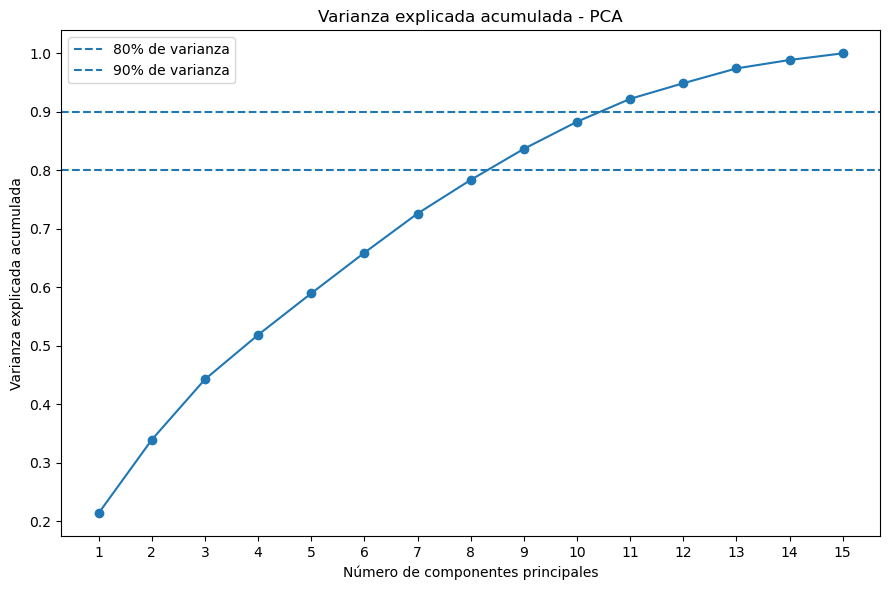

In [206]:
# ==============================================================
# 3.1.2 - GRÁFICA DE VARIANZA ACUMULADA
# ==============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    range(1, len(varianza_acumulada) + 1),
    varianza_acumulada,
    marker="o"
)

plt.axhline(
    y=0.80,
    linestyle="--",
    label="80% de varianza"
)

plt.axhline(
    y=0.90,
    linestyle="--",
    label="90% de varianza"
)

plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza explicada acumulada - PCA")

plt.xticks(
    range(1, len(varianza_acumulada) + 1)
)

plt.legend()
plt.tight_layout()
plt.show()

In [207]:
# ==============================================================
# 3.1.3 - PCA DEFINITIVO
# CONSERVANDO 9 COMPONENTES PRINCIPALES
# ==============================================================

print("=" * 65)
print("3.1.3 - PCA DEFINITIVO")
print("NÚMERO DE COMPONENTES SELECCIONADO: 9")
print("=" * 65)


from sklearn.decomposition import PCA


# --------------------------------------------------------------
# Crear PCA con 9 componentes
# --------------------------------------------------------------

pca_9 = PCA(
    n_components=9
)


# --------------------------------------------------------------
# Ajustar PCA sobre entrenamiento
# --------------------------------------------------------------

X_train_pca = pca_9.fit_transform(
    X_train_scaled
)


# --------------------------------------------------------------
# Transformar también el conjunto de prueba
# --------------------------------------------------------------

X_test_pca = pca_9.transform(
    X_test_scaled
)


# --------------------------------------------------------------
# Mostrar información
# --------------------------------------------------------------

print("\nPCA definitivo aplicado correctamente.")

print(
    "Varianza total conservada:",
    f"{pca_9.explained_variance_ratio_.sum() * 100:.2f}%"
)

print(
    "Variables originales:",
    X_train_scaled.shape[1]
)

print(
    "Componentes finales:",
    X_train_pca.shape[1]
)

3.1.3 - PCA DEFINITIVO
NÚMERO DE COMPONENTES SELECCIONADO: 9

PCA definitivo aplicado correctamente.
Varianza total conservada: 83.66%
Variables originales: 15
Componentes finales: 9


In [208]:
# ==============================================================
# 3.1.4 - CARGAS DE VARIABLES EN PC1 Y PC2
# ==============================================================

print("=" * 65)
print("3.1.4 - CARGAS DE VARIABLES EN PC1 Y PC2")
print("=" * 65)


# --------------------------------------------------------------
# Crear tabla con las cargas de las variables
# --------------------------------------------------------------

cargas_pca = pd.DataFrame(
    pca_9.components_.T,
    index=X_train.columns,
    columns=[
        f"PC{i+1}" for i in range(pca_9.n_components_)
    ]
)


# --------------------------------------------------------------
# Mostrar PC1 y PC2
# --------------------------------------------------------------

cargas_pc1_pc2 = cargas_pca[
    ["PC1", "PC2"]
].copy()


# Añadir magnitud absoluta para facilitar interpretación
cargas_pc1_pc2["Importancia_PC1"] = (
    cargas_pc1_pc2["PC1"].abs()
)

cargas_pc1_pc2["Importancia_PC2"] = (
    cargas_pc1_pc2["PC2"].abs()
)


print("\nCARGAS DE LAS VARIABLES EN PC1 Y PC2:\n")

display(
    cargas_pc1_pc2.sort_values(
        by="Importancia_PC1",
        ascending=False
    )
)

3.1.4 - CARGAS DE VARIABLES EN PC1 Y PC2

CARGAS DE LAS VARIABLES EN PC1 Y PC2:



,PC1,PC2,Importancia_PC1,Importancia_PC2
sysBP,0.484241,0.151953,0.484241,0.151953
diaBP,0.436207,0.198667,0.436207,0.198667
prevalentHyp,0.433454,0.154802,0.433454,0.154802
age,0.298141,-0.107555,0.298141,0.107555
BMI,0.281596,0.056491,0.281596,0.056491
BPMeds,0.201452,0.030614,0.201452,0.030614
currentSmoker,-0.197502,0.591078,0.197502,0.591078
totChol,0.187864,0.010193,0.187864,0.010193
cigsPerDay,-0.169696,0.631423,0.169696,0.631423
glucose,0.154163,0.007151,0.154163,0.007151


3.1.5 - VISUALIZACIÓN PC1 VS PC2 SEGÚN TenYearCHD


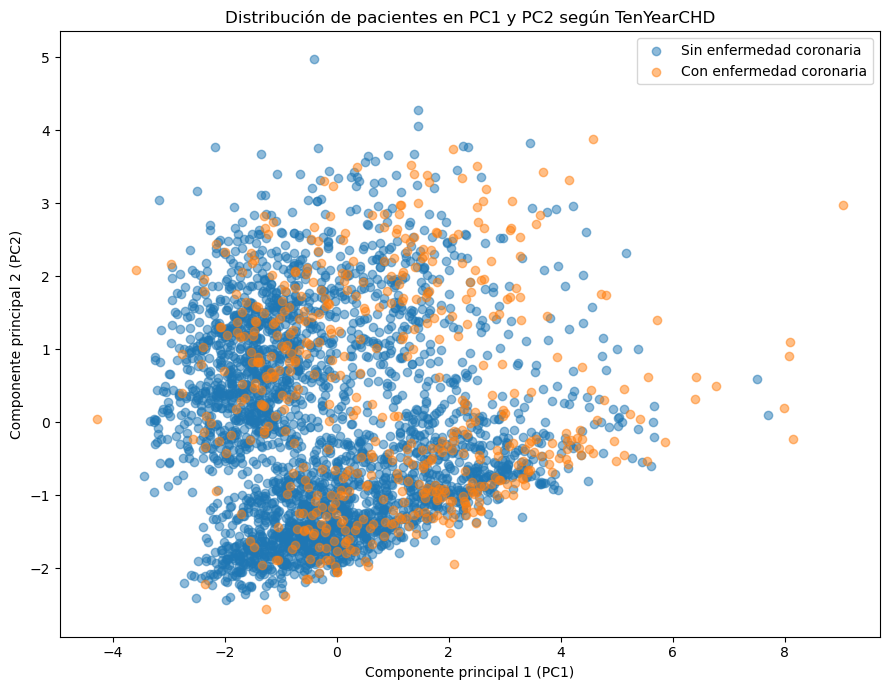


Visualización PCA generada correctamente.


In [209]:
# ==============================================================
# 3.1.5 - VISUALIZACIÓN PC1 VS PC2 SEGÚN TenYearCHD
# ==============================================================

print("=" * 65)
print("3.1.5 - VISUALIZACIÓN PC1 VS PC2 SEGÚN TenYearCHD")
print("=" * 65)


# --------------------------------------------------------------
# Crear DataFrame con los dos primeros componentes
# --------------------------------------------------------------

df_pca_visual = pd.DataFrame({
    "PC1": X_train_pca[:, 0],
    "PC2": X_train_pca[:, 1],
    "TenYearCHD": y_train.reset_index(drop=True)
})


# --------------------------------------------------------------
# Crear gráfica
# --------------------------------------------------------------

plt.figure(figsize=(9, 7))

for clase in [0, 1]:

    datos_clase = df_pca_visual[
        df_pca_visual["TenYearCHD"] == clase
    ]

    plt.scatter(
        datos_clase["PC1"],
        datos_clase["PC2"],
        alpha=0.5,
        label=(
            "Sin enfermedad coronaria"
            if clase == 0
            else "Con enfermedad coronaria"
        )
    )


plt.xlabel("Componente principal 1 (PC1)")
plt.ylabel("Componente principal 2 (PC2)")

plt.title(
    "Distribución de pacientes en PC1 y PC2 según TenYearCHD"
)

plt.legend()

plt.tight_layout()
plt.show()


print("\nVisualización PCA generada correctamente.")

In [210]:
# ==============================================================
# TABLA 3 - REDUCCIÓN DE DIMENSIONALIDAD / FEATURE SELECTION
# ==============================================================

import pandas as pd


# --------------------------------------------------------------
# Crear tabla inicial con PCA
# --------------------------------------------------------------

resultados_reduccion = pd.DataFrame([
    {
        "Metodo": "PCA",
        "N_variables_componentes": 9,
        "Criterio": "Varianza explicada acumulada",
        "Resultado_principal": "83.66% de varianza conservada"
    }
])


print("=" * 65)
print("TABLA 3 - REDUCCIÓN DE DIMENSIONALIDAD")
print("=" * 65)

display(resultados_reduccion)

TABLA 3 - REDUCCIÓN DE DIMENSIONALIDAD


,Metodo,N_variables_componentes,Criterio,Resultado_principal
0,PCA,9,Varianza explicada acumulada,83.66% de varianza conservada


In [211]:
# ==============================================================
# 3.2 - SELECTKBEST
# SELECCIÓN DE LAS 10 VARIABLES MÁS RELEVANTES
# ==============================================================

print("=" * 65)
print("3.2 - SELECTKBEST")
print("SELECCIÓN DE VARIABLES")
print("=" * 65)


# --------------------------------------------------------------
# Importar herramientas necesarias
# --------------------------------------------------------------

from sklearn.feature_selection import SelectKBest, f_classif


# --------------------------------------------------------------
# Crear selector
# --------------------------------------------------------------

selector_kbest = SelectKBest(
    score_func=f_classif,
    k=10
)


# --------------------------------------------------------------
# Ajustar sobre datos de entrenamiento
# --------------------------------------------------------------

X_train_kbest = selector_kbest.fit_transform(
    X_train_scaled,
    y_train
)


# --------------------------------------------------------------
# Transformar conjunto de prueba
# --------------------------------------------------------------

X_test_kbest = selector_kbest.transform(
    X_test_scaled
)


# --------------------------------------------------------------
# Obtener nombres de variables seleccionadas
# --------------------------------------------------------------

variables_kbest = X_train.columns[
    selector_kbest.get_support()
]


print("\nVariables seleccionadas por SelectKBest:\n")

for variable in variables_kbest:
    print("-", variable)


print("\nNúmero de variables originales:", X_train.shape[1])
print("Número de variables seleccionadas:", len(variables_kbest))

print("\nSelectKBest completado correctamente.")

3.2 - SELECTKBEST
SELECCIÓN DE VARIABLES

Variables seleccionadas por SelectKBest:

- age
- BPMeds
- prevalentStroke
- prevalentHyp
- diabetes
- totChol
- sysBP
- diaBP
- BMI
- glucose

Número de variables originales: 15
Número de variables seleccionadas: 10

SelectKBest completado correctamente.


In [212]:
# ==============================================================
# AÑADIR SELECTKBEST A LA TABLA 3
# ==============================================================

nuevo_resultado = pd.DataFrame([{
    "Metodo": "SelectKBest",
    "N_variables_componentes": 10,
    "Criterio": "ANOVA F-test (f_classif)",
    "Resultado_principal": "10 variables seleccionadas"
}])

resultados_reduccion = pd.concat(
    [resultados_reduccion, nuevo_resultado],
    ignore_index=True
)

display(resultados_reduccion)

,Metodo,N_variables_componentes,Criterio,Resultado_principal
0,PCA,9,Varianza explicada acumulada,83.66% de varianza conservada
1,SelectKBest,10,ANOVA F-test (f_classif),10 variables seleccionadas


In [213]:
# ==============================================================
# 3.2.1 - RANKING DE VARIABLES SELECTKBEST
# ==============================================================

print("=" * 65)
print("3.2.1 - RANKING DE VARIABLES SELECTKBEST")
print("=" * 65)


ranking_kbest = pd.DataFrame({
    "Variable": X_train.columns,
    "F_score": selector_kbest.scores_,
    "p_valor": selector_kbest.pvalues_
})


ranking_kbest = ranking_kbest.sort_values(
    by="F_score",
    ascending=False
)


display(ranking_kbest)

3.2.1 - RANKING DE VARIABLES SELECTKBEST


,Variable,F_score,p_valor
1,age,204.396448,4.568197e-45
10,sysBP,184.334367,6.323285e-41
7,prevalentHyp,112.942827,5.666360e-26
11,diaBP,86.953129,1.947019e-20
14,glucose,55.911387,9.600562e-14
5,BPMeds,37.141205,1.222105e-09
8,diabetes,31.749903,1.896749e-08
9,totChol,29.399417,6.301650e-08
6,prevalentStroke,20.961497,4.854439e-06
12,BMI,19.905750,8.399926e-06


In [214]:
# ==============================================================
# 3.2.2 - EVALUACIÓN DE SELECTKBEST
# REGRESIÓN LOGÍSTICA: 15 VARIABLES VS 10 VARIABLES
# ==============================================================

print("=" * 65)
print("3.2.2 - EVALUACIÓN DE SELECTKBEST")
print("=" * 65)


from sklearn.linear_model import LogisticRegression


# --------------------------------------------------------------
# Modelo con las 10 variables seleccionadas
# --------------------------------------------------------------

modelo_lr_kbest = LogisticRegression(
    random_state=42,
    max_iter=1000
)


modelo_lr_kbest.fit(
    X_train_kbest,
    y_train
)


# --------------------------------------------------------------
# Predicciones y probabilidades
# --------------------------------------------------------------

y_pred_lr_kbest = modelo_lr_kbest.predict(
    X_test_kbest
)

y_prob_lr_kbest = modelo_lr_kbest.predict_proba(
    X_test_kbest
)[:, 1]


# --------------------------------------------------------------
# Calcular métricas
# --------------------------------------------------------------

accuracy_lr_kbest = accuracy_score(
    y_test,
    y_pred_lr_kbest
)

precision_lr_kbest = precision_score(
    y_test,
    y_pred_lr_kbest,
    zero_division=0
)

recall_lr_kbest = recall_score(
    y_test,
    y_pred_lr_kbest,
    zero_division=0
)

f1_lr_kbest = f1_score(
    y_test,
    y_pred_lr_kbest,
    zero_division=0
)

roc_auc_lr_kbest = roc_auc_score(
    y_test,
    y_prob_lr_kbest
)

pr_auc_lr_kbest = average_precision_score(
    y_test,
    y_prob_lr_kbest
)


# --------------------------------------------------------------
# Tabla comparativa
# --------------------------------------------------------------

comparacion_kbest = pd.DataFrame([
    {
        "Modelo": "Regresión Logística - 15 variables",
        "Accuracy": accuracy_lr,
        "Precision": precision_lr,
        "Recall": recall_lr,
        "F1-score": f1_lr,
        "ROC-AUC": roc_auc_lr,
        "PR-AUC": pr_auc_lr
    },
    {
        "Modelo": "Regresión Logística - SelectKBest (10)",
        "Accuracy": accuracy_lr_kbest,
        "Precision": precision_lr_kbest,
        "Recall": recall_lr_kbest,
        "F1-score": f1_lr_kbest,
        "ROC-AUC": roc_auc_lr_kbest,
        "PR-AUC": pr_auc_lr_kbest
    }
])


display(comparacion_kbest)

3.2.2 - EVALUACIÓN DE SELECTKBEST


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística - 15 variables,0.84434,0.411765,0.054264,0.095890,0.702774,0.302116
1,Regresión Logística - SelectKBest (10),0.84316,0.300000,0.023256,0.043165,0.664553,0.257126


In [215]:
# ==============================================================
# AÑADIR SELECTKBEST A LA TABLA 3
# ==============================================================

nuevo_resultado = pd.DataFrame([{
    "Metodo": "SelectKBest",
    "N_variables_componentes": 10,
    "Criterio": "ANOVA F-test (f_classif)",
    "Resultado_principal": (
        f"ROC-AUC LR: {roc_auc_lr_kbest:.4f} "
        f"(vs {roc_auc_lr:.4f} original)"
    )
}])

resultados_reduccion = pd.concat(
    [resultados_reduccion, nuevo_resultado],
    ignore_index=True
)

display(resultados_reduccion)

,Metodo,N_variables_componentes,Criterio,Resultado_principal
0,PCA,9,Varianza explicada acumulada,83.66% de varianza conservada
1,SelectKBest,10,ANOVA F-test (f_classif),10 variables seleccionadas
2,SelectKBest,10,ANOVA F-test (f_classif),ROC-AUC LR: 0.6646 (vs 0.7028 original)


In [216]:
# ==============================================================
# RECONSTRUIR TABLA 3 SIN DUPLICADOS
# ==============================================================

resultados_reduccion = pd.DataFrame([
    {
        "Metodo": "PCA",
        "N_variables_componentes": 9,
        "Criterio": "Varianza explicada acumulada",
        "Resultado_principal": "83.66% de varianza conservada"
    },
    {
        "Metodo": "SelectKBest",
        "N_variables_componentes": 10,
        "Criterio": "ANOVA F-test (f_classif)",
        "Resultado_principal": (
            f"ROC-AUC LR: {roc_auc_lr_kbest:.4f} "
            f"(vs {roc_auc_lr:.4f} original)"
        )
    }
])

display(resultados_reduccion)

,Metodo,N_variables_componentes,Criterio,Resultado_principal
0,PCA,9,Varianza explicada acumulada,83.66% de varianza conservada
1,SelectKBest,10,ANOVA F-test (f_classif),ROC-AUC LR: 0.6646 (vs 0.7028 original)


In [217]:
# ==============================================================
# 3.3 - RECURSIVE FEATURE ELIMINATION (RFE)
# ==============================================================

print("=" * 65)
print("3.3 - RECURSIVE FEATURE ELIMINATION (RFE)")
print("=" * 65)


# --------------------------------------------------------------
# Importar herramientas necesarias
# --------------------------------------------------------------

from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression


# --------------------------------------------------------------
# Crear estimador base
# --------------------------------------------------------------

modelo_rfe_base = LogisticRegression(
    random_state=42,
    max_iter=1000
)


# --------------------------------------------------------------
# Crear selector RFE
# --------------------------------------------------------------

selector_rfe = RFE(
    estimator=modelo_rfe_base,
    n_features_to_select=10
)


# --------------------------------------------------------------
# Ajustar selector
# --------------------------------------------------------------

selector_rfe.fit(
    X_train_scaled,
    y_train
)


# --------------------------------------------------------------
# Transformar entrenamiento y prueba
# --------------------------------------------------------------

X_train_rfe = selector_rfe.transform(
    X_train_scaled
)

X_test_rfe = selector_rfe.transform(
    X_test_scaled
)


# --------------------------------------------------------------
# Obtener variables seleccionadas
# --------------------------------------------------------------

variables_rfe = X_train.columns[
    selector_rfe.get_support()
]


print("\nVariables seleccionadas por RFE:\n")

for variable in variables_rfe:
    print("-", variable)


print("\nNúmero de variables originales:", X_train.shape[1])
print("Número de variables seleccionadas:", len(variables_rfe))

print("\nRFE completado correctamente.")

3.3 - RECURSIVE FEATURE ELIMINATION (RFE)

Variables seleccionadas por RFE:

- male
- age
- cigsPerDay
- BPMeds
- prevalentStroke
- prevalentHyp
- totChol
- sysBP
- heartRate
- glucose

Número de variables originales: 15
Número de variables seleccionadas: 10

RFE completado correctamente.


In [218]:
# ==============================================================
# 3.3.1 - EVALUACIÓN DE RFE
# REGRESIÓN LOGÍSTICA: 15 VARIABLES VS 10 VARIABLES RFE
# ==============================================================

print("=" * 65)
print("3.3.1 - EVALUACIÓN DE RFE")
print("=" * 65)


# --------------------------------------------------------------
# Crear modelo
# --------------------------------------------------------------

modelo_lr_rfe = LogisticRegression(
    random_state=42,
    max_iter=1000
)


# --------------------------------------------------------------
# Entrenar con variables seleccionadas por RFE
# --------------------------------------------------------------

modelo_lr_rfe.fit(
    X_train_rfe,
    y_train
)


# --------------------------------------------------------------
# Predicciones
# --------------------------------------------------------------

y_pred_lr_rfe = modelo_lr_rfe.predict(
    X_test_rfe
)

y_prob_lr_rfe = modelo_lr_rfe.predict_proba(
    X_test_rfe
)[:, 1]


# --------------------------------------------------------------
# Calcular métricas
# --------------------------------------------------------------

accuracy_lr_rfe = accuracy_score(
    y_test,
    y_pred_lr_rfe
)

precision_lr_rfe = precision_score(
    y_test,
    y_pred_lr_rfe,
    zero_division=0
)

recall_lr_rfe = recall_score(
    y_test,
    y_pred_lr_rfe,
    zero_division=0
)

f1_lr_rfe = f1_score(
    y_test,
    y_pred_lr_rfe,
    zero_division=0
)

roc_auc_lr_rfe = roc_auc_score(
    y_test,
    y_prob_lr_rfe
)

pr_auc_lr_rfe = average_precision_score(
    y_test,
    y_prob_lr_rfe
)


# --------------------------------------------------------------
# Tabla comparativa
# --------------------------------------------------------------

comparacion_rfe = pd.DataFrame([
    {
        "Modelo": "Regresión Logística - 15 variables",
        "Accuracy": accuracy_lr,
        "Precision": precision_lr,
        "Recall": recall_lr,
        "F1-score": f1_lr,
        "ROC-AUC": roc_auc_lr,
        "PR-AUC": pr_auc_lr
    },
    {
        "Modelo": "Regresión Logística - RFE (10)",
        "Accuracy": accuracy_lr_rfe,
        "Precision": precision_lr_rfe,
        "Recall": recall_lr_rfe,
        "F1-score": f1_lr_rfe,
        "ROC-AUC": roc_auc_lr_rfe,
        "PR-AUC": pr_auc_lr_rfe
    }
])

display(comparacion_rfe)

3.3.1 - EVALUACIÓN DE RFE


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística - 15 variables,0.84434,0.411765,0.054264,0.09589,0.702774,0.302116
1,Regresión Logística - RFE (10),0.84434,0.411765,0.054264,0.09589,0.703065,0.299574


In [219]:
# ==============================================================
# AÑADIR RFE A LA TABLA 3
# ==============================================================

nuevo_resultado = pd.DataFrame([{
    "Metodo": "RFE",
    "N_variables_componentes": 10,
    "Criterio": "Eliminación recursiva con Regresión Logística",
    "Resultado_principal": (
        f"ROC-AUC LR: {roc_auc_lr_rfe:.4f} "
        f"(vs {roc_auc_lr:.4f} original)"
    )
}])

resultados_reduccion = pd.concat(
    [resultados_reduccion, nuevo_resultado],
    ignore_index=True
)

display(resultados_reduccion)

,Metodo,N_variables_componentes,Criterio,Resultado_principal
0,PCA,9,Varianza explicada acumulada,83.66% de varianza conservada
1,SelectKBest,10,ANOVA F-test (f_classif),ROC-AUC LR: 0.6646 (vs 0.7028 original)
2,RFE,10,Eliminación recursiva con Regresión Logística,ROC-AUC LR: 0.7031 (vs 0.7028 original)


In [220]:
# ==============================================================
# 3.4 - SELECCIÓN DE VARIABLES CON REGULARIZACIÓN L1
# SELECTFROMMODEL
# ==============================================================

print("=" * 65)
print("3.4 - SELECCIÓN DE VARIABLES CON REGULARIZACIÓN L1")
print("=" * 65)


from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression


# --------------------------------------------------------------
# Modelo base con penalización L1
# --------------------------------------------------------------

modelo_l1 = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    random_state=42,
    max_iter=1000
)


# --------------------------------------------------------------
# Crear selector
# --------------------------------------------------------------

selector_l1 = SelectFromModel(
    estimator=modelo_l1,
    threshold="median"
)


# --------------------------------------------------------------
# Ajustar selector
# --------------------------------------------------------------

selector_l1.fit(
    X_train_scaled,
    y_train
)


# --------------------------------------------------------------
# Transformar entrenamiento y prueba
# --------------------------------------------------------------

X_train_l1 = selector_l1.transform(
    X_train_scaled
)

X_test_l1 = selector_l1.transform(
    X_test_scaled
)


# --------------------------------------------------------------
# Obtener variables seleccionadas
# --------------------------------------------------------------

variables_l1 = X_train.columns[
    selector_l1.get_support()
]


print("\nVariables seleccionadas por L1:\n")

for variable in variables_l1:
    print("-", variable)


print("\nNúmero de variables originales:", X_train.shape[1])
print("Número de variables seleccionadas:", len(variables_l1))

print("\nSelección L1 completada correctamente.")

3.4 - SELECCIÓN DE VARIABLES CON REGULARIZACIÓN L1

Variables seleccionadas por L1:

- male
- age
- cigsPerDay
- BPMeds
- prevalentStroke
- totChol
- sysBP
- glucose

Número de variables originales: 15
Número de variables seleccionadas: 8

Selección L1 completada correctamente.


In [221]:
# ==============================================================
# 3.4.1 - EVALUACIÓN DE SELECCIÓN L1
# REGRESIÓN LOGÍSTICA: 15 VARIABLES VS 8 VARIABLES L1
# ==============================================================

print("=" * 65)
print("3.4.1 - EVALUACIÓN DE SELECCIÓN L1")
print("=" * 65)


# --------------------------------------------------------------
# Crear modelo de Regresión Logística
# --------------------------------------------------------------

modelo_lr_l1 = LogisticRegression(
    random_state=42,
    max_iter=1000
)


# --------------------------------------------------------------
# Entrenar con las variables seleccionadas por L1
# --------------------------------------------------------------

modelo_lr_l1.fit(
    X_train_l1,
    y_train
)


# --------------------------------------------------------------
# Predicciones y probabilidades
# --------------------------------------------------------------

y_pred_lr_l1 = modelo_lr_l1.predict(
    X_test_l1
)

y_prob_lr_l1 = modelo_lr_l1.predict_proba(
    X_test_l1
)[:, 1]


# --------------------------------------------------------------
# Calcular métricas
# --------------------------------------------------------------

accuracy_lr_l1 = accuracy_score(
    y_test,
    y_pred_lr_l1
)

precision_lr_l1 = precision_score(
    y_test,
    y_pred_lr_l1,
    zero_division=0
)

recall_lr_l1 = recall_score(
    y_test,
    y_pred_lr_l1,
    zero_division=0
)

f1_lr_l1 = f1_score(
    y_test,
    y_pred_lr_l1,
    zero_division=0
)

roc_auc_lr_l1 = roc_auc_score(
    y_test,
    y_prob_lr_l1
)

pr_auc_lr_l1 = average_precision_score(
    y_test,
    y_prob_lr_l1
)


# --------------------------------------------------------------
# Tabla comparativa
# --------------------------------------------------------------

comparacion_l1 = pd.DataFrame([
    {
        "Modelo": "Regresión Logística - 15 variables",
        "Accuracy": accuracy_lr,
        "Precision": precision_lr,
        "Recall": recall_lr,
        "F1-score": f1_lr,
        "ROC-AUC": roc_auc_lr,
        "PR-AUC": pr_auc_lr
    },
    {
        "Modelo": "Regresión Logística - L1 (8)",
        "Accuracy": accuracy_lr_l1,
        "Precision": precision_lr_l1,
        "Recall": recall_lr_l1,
        "F1-score": f1_lr_l1,
        "ROC-AUC": roc_auc_lr_l1,
        "PR-AUC": pr_auc_lr_l1
    }
])


display(comparacion_l1)

3.4.1 - EVALUACIÓN DE SELECCIÓN L1


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística - 15 variables,0.84434,0.411765,0.054264,0.095890,0.702774,0.302116
1,Regresión Logística - L1 (8),0.84316,0.388889,0.054264,0.095238,0.701588,0.295933


In [222]:
# ==============================================================
# AÑADIR SELECCIÓN L1 A LA TABLA 3
# ==============================================================

nuevo_resultado = pd.DataFrame([{
    "Metodo": "Selección L1",
    "N_variables_componentes": 8,
    "Criterio": "Regularización L1 + SelectFromModel",
    "Resultado_principal": (
        f"ROC-AUC LR: {roc_auc_lr_l1:.4f} "
        f"(vs {roc_auc_lr:.4f} original)"
    )
}])

resultados_reduccion = pd.concat(
    [resultados_reduccion, nuevo_resultado],
    ignore_index=True
)

display(resultados_reduccion)

,Metodo,N_variables_componentes,Criterio,Resultado_principal
0,PCA,9,Varianza explicada acumulada,83.66% de varianza conservada
1,SelectKBest,10,ANOVA F-test (f_classif),ROC-AUC LR: 0.6646 (vs 0.7028 original)
2,RFE,10,Eliminación recursiva con Regresión Logística,ROC-AUC LR: 0.7031 (vs 0.7028 original)
3,Selección L1,8,Regularización L1 + SelectFromModel,ROC-AUC LR: 0.7016 (vs 0.7028 original)


In [223]:
# ==============================================================
# 4.1 - MODEL SELECTION
# VALIDACIÓN CRUZADA DE LOS MODELOS SELECCIONADOS
# ==============================================================

print("=" * 65)
print("4.1 - VALIDACIÓN CRUZADA DE LOS MODELOS SELECCIONADOS")
print("=" * 65)


# --------------------------------------------------------------
# Importar herramientas necesarias
# --------------------------------------------------------------

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.base import clone

import pandas as pd
import numpy as np


# --------------------------------------------------------------
# Crear validación cruzada estratificada
# --------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# --------------------------------------------------------------
# Modelos seleccionados
# --------------------------------------------------------------

modelos_seleccionados = {
    "Regresión Logística": modelo_lr,
    "LDA": modelo_lda,
    "AdaBoost": modelo_ada,
    "Stacking Classifier": modelo_stacking,
    "QDA": modelo_qda
}


# --------------------------------------------------------------
# Métricas que vamos a evaluar
# --------------------------------------------------------------

metricas_cv = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}


# --------------------------------------------------------------
# Evaluar cada modelo
# --------------------------------------------------------------

resultados_cv = []


for nombre, modelo in modelos_seleccionados.items():

    print(f"\nEvaluando: {nombre}")

    resultado = cross_validate(
        clone(modelo),
        X_train_scaled,
        y_train,
        cv=cv,
        scoring=metricas_cv,
        n_jobs=-1
    )

    resultados_cv.append({
        "Modelo": nombre,

        "CV_Accuracy":
            resultado["test_accuracy"].mean(),

        "CV_Precision":
            resultado["test_precision"].mean(),

        "CV_Recall":
            resultado["test_recall"].mean(),

        "CV_F1":
            resultado["test_f1"].mean(),

        "CV_ROC_AUC":
            resultado["test_roc_auc"].mean(),

        "CV_PR_AUC":
            resultado["test_pr_auc"].mean()
    })


# --------------------------------------------------------------
# Crear Tabla 4 inicial
# --------------------------------------------------------------

tabla_model_selection = pd.DataFrame(
    resultados_cv
)


print("\n" + "=" * 65)
print("TABLA 4 - MODEL SELECTION")
print("=" * 65)

display(tabla_model_selection)

4.1 - VALIDACIÓN CRUZADA DE LOS MODELOS SELECCIONADOS

Evaluando: Regresión Logística

Evaluando: LDA

Evaluando: AdaBoost

Evaluando: Stacking Classifier

Evaluando: QDA

TABLA 4 - MODEL SELECTION


,Modelo,CV_Accuracy,CV_Precision,CV_Recall,CV_F1,CV_ROC_AUC,CV_PR_AUC
0,Regresión Logística,0.854659,0.684087,0.089320,0.154933,0.731366,0.361133
1,LDA,0.849061,0.538450,0.122330,0.195674,0.728141,0.354588
2,AdaBoost,0.849648,0.609524,0.050485,0.091262,0.705259,0.313363
3,Stacking Classifier,0.851123,0.593700,0.091262,0.155846,0.728129,0.356837
4,QDA,0.831669,0.395559,0.196117,0.261378,0.718930,0.326725


In [224]:
# ==============================================================
# 4.2 - OPTIMIZACIÓN DE REGRESIÓN LOGÍSTICA
# GRIDSEARCHCV
# ==============================================================

print("=" * 65)
print("4.2 - OPTIMIZACIÓN DE REGRESIÓN LOGÍSTICA")
print("GRIDSEARCHCV")
print("=" * 65)


# --------------------------------------------------------------
# Importar herramientas necesarias
# --------------------------------------------------------------

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression


# --------------------------------------------------------------
# Crear modelo base
# --------------------------------------------------------------

modelo_lr_grid = LogisticRegression(
    random_state=42,
    max_iter=2000
)


# --------------------------------------------------------------
# Definir espacio de hiperparámetros
# --------------------------------------------------------------

param_grid_lr = [
    {
        "penalty": ["l1"],
        "solver": ["liblinear", "saga"],
        "C": [0.01, 0.1, 1, 10, 100],
        "class_weight": [None, "balanced"]
    },
    {
        "penalty": ["l2"],
        "solver": ["liblinear", "lbfgs", "saga"],
        "C": [0.01, 0.1, 1, 10, 100],
        "class_weight": [None, "balanced"]
    }
]


# --------------------------------------------------------------
# Crear GridSearchCV
# Usamos ROC-AUC como criterio principal de optimización
# --------------------------------------------------------------

grid_lr = GridSearchCV(
    estimator=modelo_lr_grid,
    param_grid=param_grid_lr,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True
)


# --------------------------------------------------------------
# Ejecutar búsqueda
# --------------------------------------------------------------

grid_lr.fit(
    X_train_scaled,
    y_train
)


# --------------------------------------------------------------
# Mostrar resultados
# --------------------------------------------------------------

print("\nMejores hiperparámetros:")
print(grid_lr.best_params_)

print(
    "\nMejor ROC-AUC medio en validación cruzada:",
    f"{grid_lr.best_score_:.4f}"
)

print("\nGridSearchCV completado correctamente.")

4.2 - OPTIMIZACIÓN DE REGRESIÓN LOGÍSTICA
GRIDSEARCHCV

Mejores hiperparámetros:
{'C': 0.1, 'class_weight': None, 'penalty': 'l1', 'solver': 'saga'}

Mejor ROC-AUC medio en validación cruzada: 0.7326

GridSearchCV completado correctamente.


In [225]:
# ==============================================================
# 4.2.1 - EVALUACIÓN DE REGRESIÓN LOGÍSTICA OPTIMIZADA
# ==============================================================

print("=" * 65)
print("4.2.1 - EVALUACIÓN DE REGRESIÓN LOGÍSTICA OPTIMIZADA")
print("=" * 65)


# --------------------------------------------------------------
# Obtener mejor modelo
# --------------------------------------------------------------

modelo_lr_opt = grid_lr.best_estimator_


# --------------------------------------------------------------
# Predicciones sobre test
# --------------------------------------------------------------

y_pred_lr_opt = modelo_lr_opt.predict(
    X_test_scaled
)

y_prob_lr_opt = modelo_lr_opt.predict_proba(
    X_test_scaled
)[:, 1]


# --------------------------------------------------------------
# Calcular métricas
# --------------------------------------------------------------

accuracy_lr_opt = accuracy_score(
    y_test,
    y_pred_lr_opt
)

precision_lr_opt = precision_score(
    y_test,
    y_pred_lr_opt,
    zero_division=0
)

recall_lr_opt = recall_score(
    y_test,
    y_pred_lr_opt,
    zero_division=0
)

f1_lr_opt = f1_score(
    y_test,
    y_pred_lr_opt,
    zero_division=0
)

roc_auc_lr_opt = roc_auc_score(
    y_test,
    y_prob_lr_opt
)

pr_auc_lr_opt = average_precision_score(
    y_test,
    y_prob_lr_opt
)


# --------------------------------------------------------------
# Comparación base vs optimizado
# --------------------------------------------------------------

comparacion_lr_opt = pd.DataFrame([
    {
        "Modelo": "Regresión Logística Base",
        "Accuracy": accuracy_lr,
        "Precision": precision_lr,
        "Recall": recall_lr,
        "F1-score": f1_lr,
        "ROC-AUC": roc_auc_lr,
        "PR-AUC": pr_auc_lr
    },
    {
        "Modelo": "Regresión Logística Optimizada",
        "Accuracy": accuracy_lr_opt,
        "Precision": precision_lr_opt,
        "Recall": recall_lr_opt,
        "F1-score": f1_lr_opt,
        "ROC-AUC": roc_auc_lr_opt,
        "PR-AUC": pr_auc_lr_opt
    }
])

display(comparacion_lr_opt)

4.2.1 - EVALUACIÓN DE REGRESIÓN LOGÍSTICA OPTIMIZADA


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística Base,0.844340,0.411765,0.054264,0.095890,0.702774,0.302116
1,Regresión Logística Optimizada,0.846698,0.466667,0.054264,0.097222,0.703248,0.299891


In [226]:
# ==============================================================
# AÑADIR REGRESIÓN LOGÍSTICA OPTIMIZADA A TABLA 4
# ==============================================================

tabla_optimizacion = pd.DataFrame([
    {
        "Modelo": "Regresión Logística",
        "ROC_AUC_Base": roc_auc_lr,
        "ROC_AUC_Optimizado": roc_auc_lr_opt,
        "Recall_Base": recall_lr,
        "Recall_Optimizado": recall_lr_opt,
        "F1_Base": f1_lr,
        "F1_Optimizado": f1_lr_opt,
        "PR_AUC_Base": pr_auc_lr,
        "PR_AUC_Optimizado": pr_auc_lr_opt
    }
])

display(tabla_optimizacion)

,Modelo,ROC_AUC_Base,ROC_AUC_Optimizado,Recall_Base,Recall_Optimizado,F1_Base,F1_Optimizado,PR_AUC_Base,PR_AUC_Optimizado
0,Regresión Logística,0.702774,0.703248,0.054264,0.054264,0.09589,0.097222,0.302116,0.299891


In [227]:
# ==============================================================
# 4.3 - OPTIMIZACIÓN DE LDA
# GRIDSEARCHCV
# ==============================================================

print("=" * 65)
print("4.3 - OPTIMIZACIÓN DE LDA")
print("GRIDSEARCHCV")
print("=" * 65)


from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV


# --------------------------------------------------------------
# Modelo base
# --------------------------------------------------------------

modelo_lda_grid = LinearDiscriminantAnalysis()


# --------------------------------------------------------------
# Espacio de hiperparámetros
# --------------------------------------------------------------

param_grid_lda = [
    {
        "solver": ["svd"]
    },
    {
        "solver": ["lsqr", "eigen"],
        "shrinkage": [None, "auto", 0.1, 0.3, 0.5, 0.7, 0.9]
    }
]


# --------------------------------------------------------------
# GridSearchCV
# --------------------------------------------------------------

grid_lda = GridSearchCV(
    estimator=modelo_lda_grid,
    param_grid=param_grid_lda,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True
)


# --------------------------------------------------------------
# Ejecutar búsqueda
# --------------------------------------------------------------

grid_lda.fit(
    X_train_scaled,
    y_train
)


# --------------------------------------------------------------
# Mostrar resultados
# --------------------------------------------------------------

print("\nMejores hiperparámetros:")
print(grid_lda.best_params_)

print(
    "\nMejor ROC-AUC medio en validación cruzada:",
    f"{grid_lda.best_score_:.4f}"
)

print("\nGridSearchCV completado correctamente.")

4.3 - OPTIMIZACIÓN DE LDA
GRIDSEARCHCV

Mejores hiperparámetros:
{'shrinkage': 0.1, 'solver': 'lsqr'}

Mejor ROC-AUC medio en validación cruzada: 0.7296

GridSearchCV completado correctamente.


In [228]:
# ==============================================================
# 4.3.1 - EVALUACIÓN DE LDA OPTIMIZADO
# ==============================================================

print("=" * 65)
print("4.3.1 - EVALUACIÓN DE LDA OPTIMIZADO")
print("=" * 65)


# --------------------------------------------------------------
# Obtener mejor modelo
# --------------------------------------------------------------

modelo_lda_opt = grid_lda.best_estimator_


# --------------------------------------------------------------
# Predicciones y probabilidades
# --------------------------------------------------------------

y_pred_lda_opt = modelo_lda_opt.predict(
    X_test_scaled
)

y_prob_lda_opt = modelo_lda_opt.predict_proba(
    X_test_scaled
)[:, 1]


# --------------------------------------------------------------
# Calcular métricas
# --------------------------------------------------------------

accuracy_lda_opt = accuracy_score(
    y_test,
    y_pred_lda_opt
)

precision_lda_opt = precision_score(
    y_test,
    y_pred_lda_opt,
    zero_division=0
)

recall_lda_opt = recall_score(
    y_test,
    y_pred_lda_opt,
    zero_division=0
)

f1_lda_opt = f1_score(
    y_test,
    y_pred_lda_opt,
    zero_division=0
)

roc_auc_lda_opt = roc_auc_score(
    y_test,
    y_prob_lda_opt
)

pr_auc_lda_opt = average_precision_score(
    y_test,
    y_prob_lda_opt
)


# --------------------------------------------------------------
# Comparación base vs optimizado
# --------------------------------------------------------------

comparacion_lda_opt = pd.DataFrame([
    {
        "Modelo": "LDA Base",
        "Accuracy": accuracy_lda,
        "Precision": precision_lda,
        "Recall": recall_lda,
        "F1-score": f1_lda,
        "ROC-AUC": roc_auc_lda,
        "PR-AUC": pr_auc_lda
    },
    {
        "Modelo": "LDA Optimizado",
        "Accuracy": accuracy_lda_opt,
        "Precision": precision_lda_opt,
        "Recall": recall_lda_opt,
        "F1-score": f1_lda_opt,
        "ROC-AUC": roc_auc_lda_opt,
        "PR-AUC": pr_auc_lda_opt
    }
])

display(comparacion_lda_opt)

4.3.1 - EVALUACIÓN DE LDA OPTIMIZADO


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,LDA Base,0.838443,0.346154,0.069767,0.116129,0.700941,0.287816
1,LDA Optimizado,0.837264,0.363636,0.093023,0.148148,0.700715,0.285429


In [229]:
# ==============================================================
# AÑADIR LDA OPTIMIZADO A TABLA 4
# ==============================================================

nuevo_resultado = pd.DataFrame([{
    "Modelo": "LDA",
    "ROC_AUC_Base": roc_auc_lda,
    "ROC_AUC_Optimizado": roc_auc_lda_opt,
    "Recall_Base": recall_lda,
    "Recall_Optimizado": recall_lda_opt,
    "F1_Base": f1_lda,
    "F1_Optimizado": f1_lda_opt,
    "PR_AUC_Base": pr_auc_lda,
    "PR_AUC_Optimizado": pr_auc_lda_opt
}])

tabla_optimizacion = pd.concat(
    [tabla_optimizacion, nuevo_resultado],
    ignore_index=True
)

display(tabla_optimizacion)

,Modelo,ROC_AUC_Base,ROC_AUC_Optimizado,Recall_Base,Recall_Optimizado,F1_Base,F1_Optimizado,PR_AUC_Base,PR_AUC_Optimizado
0,Regresión Logística,0.702774,0.703248,0.054264,0.054264,0.095890,0.097222,0.302116,0.299891
1,LDA,0.700941,0.700715,0.069767,0.093023,0.116129,0.148148,0.287816,0.285429


In [230]:
# ==============================================================
# 4.4 - OPTIMIZACIÓN DE QDA
# GRIDSEARCHCV
# ==============================================================

print("=" * 65)
print("4.4 - OPTIMIZACIÓN DE QDA")
print("GRIDSEARCHCV")
print("=" * 65)


from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV


# --------------------------------------------------------------
# Modelo base
# --------------------------------------------------------------

modelo_qda_grid = QuadraticDiscriminantAnalysis()


# --------------------------------------------------------------
# Espacio de hiperparámetros
# --------------------------------------------------------------

param_grid_qda = {
    "reg_param": [
        0.0,
        0.01,
        0.05,
        0.1,
        0.2,
        0.3,
        0.5,
        0.7,
        0.9
    ]
}


# --------------------------------------------------------------
# GridSearchCV
# --------------------------------------------------------------

grid_qda = GridSearchCV(
    estimator=modelo_qda_grid,
    param_grid=param_grid_qda,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True
)


# --------------------------------------------------------------
# Ejecutar búsqueda
# --------------------------------------------------------------

grid_qda.fit(
    X_train_scaled,
    y_train
)


# --------------------------------------------------------------
# Mostrar resultados
# --------------------------------------------------------------

print("\nMejores hiperparámetros:")
print(grid_qda.best_params_)

print(
    "\nMejor ROC-AUC medio en validación cruzada:",
    f"{grid_qda.best_score_:.4f}"
)

print("\nGridSearchCV completado correctamente.")

4.4 - OPTIMIZACIÓN DE QDA
GRIDSEARCHCV

Mejores hiperparámetros:
{'reg_param': 0.5}

Mejor ROC-AUC medio en validación cruzada: 0.7291

GridSearchCV completado correctamente.


In [231]:
# ==============================================================
# 4.4.1 - EVALUACIÓN DE QDA OPTIMIZADO
# ==============================================================

print("=" * 65)
print("4.4.1 - EVALUACIÓN DE QDA OPTIMIZADO")
print("=" * 65)


# --------------------------------------------------------------
# Obtener mejor modelo
# --------------------------------------------------------------

modelo_qda_opt = grid_qda.best_estimator_


# --------------------------------------------------------------
# Predicciones y probabilidades
# --------------------------------------------------------------

y_pred_qda_opt = modelo_qda_opt.predict(
    X_test_scaled
)

y_prob_qda_opt = modelo_qda_opt.predict_proba(
    X_test_scaled
)[:, 1]


# --------------------------------------------------------------
# Calcular métricas
# --------------------------------------------------------------

accuracy_qda_opt = accuracy_score(
    y_test,
    y_pred_qda_opt
)

precision_qda_opt = precision_score(
    y_test,
    y_pred_qda_opt,
    zero_division=0
)

recall_qda_opt = recall_score(
    y_test,
    y_pred_qda_opt,
    zero_division=0
)

f1_qda_opt = f1_score(
    y_test,
    y_pred_qda_opt,
    zero_division=0
)

roc_auc_qda_opt = roc_auc_score(
    y_test,
    y_prob_qda_opt
)

pr_auc_qda_opt = average_precision_score(
    y_test,
    y_prob_qda_opt
)


# --------------------------------------------------------------
# Comparación base vs optimizado
# --------------------------------------------------------------

comparacion_qda_opt = pd.DataFrame([
    {
        "Modelo": "QDA Base",
        "Accuracy": accuracy_qda,
        "Precision": precision_qda,
        "Recall": recall_qda,
        "F1-score": f1_qda,
        "ROC-AUC": roc_auc_qda,
        "PR-AUC": pr_auc_qda
    },
    {
        "Modelo": "QDA Optimizado",
        "Accuracy": accuracy_qda_opt,
        "Precision": precision_qda_opt,
        "Recall": recall_qda_opt,
        "F1-score": f1_qda_opt,
        "ROC-AUC": roc_auc_qda_opt,
        "PR-AUC": pr_auc_qda_opt
    }
])

display(comparacion_qda_opt)

4.4.1 - EVALUACIÓN DE QDA OPTIMIZADO


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,QDA Base,0.817217,0.296875,0.147287,0.196891,0.67665,0.249973
1,QDA Optimizado,0.819575,0.293103,0.131783,0.181818,0.68713,0.253027


In [232]:
# ==============================================================
# AÑADIR QDA OPTIMIZADO A TABLA 4
# ==============================================================

nuevo_resultado = pd.DataFrame([{
    "Modelo": "QDA",
    "ROC_AUC_Base": roc_auc_qda,
    "ROC_AUC_Optimizado": roc_auc_qda_opt,
    "Recall_Base": recall_qda,
    "Recall_Optimizado": recall_qda_opt,
    "F1_Base": f1_qda,
    "F1_Optimizado": f1_qda_opt,
    "PR_AUC_Base": pr_auc_qda,
    "PR_AUC_Optimizado": pr_auc_qda_opt
}])

tabla_optimizacion = pd.concat(
    [tabla_optimizacion, nuevo_resultado],
    ignore_index=True
)

display(tabla_optimizacion)

,Modelo,ROC_AUC_Base,ROC_AUC_Optimizado,Recall_Base,Recall_Optimizado,F1_Base,F1_Optimizado,PR_AUC_Base,PR_AUC_Optimizado
0,Regresión Logística,0.702774,0.703248,0.054264,0.054264,0.095890,0.097222,0.302116,0.299891
1,LDA,0.700941,0.700715,0.069767,0.093023,0.116129,0.148148,0.287816,0.285429
2,QDA,0.676650,0.687130,0.147287,0.131783,0.196891,0.181818,0.249973,0.253027


In [233]:
# ==============================================================
# 4.5 - OPTIMIZACIÓN DE STACKING CLASSIFIER
# GRIDSEARCHCV
# ==============================================================

print("=" * 65)
print("4.5 - OPTIMIZACIÓN DE STACKING CLASSIFIER")
print("GRIDSEARCHCV")
print("=" * 65)


# --------------------------------------------------------------
# Importar herramientas
# --------------------------------------------------------------

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV


# --------------------------------------------------------------
# Crear modelo base de stacking
# --------------------------------------------------------------

modelo_stacking_grid = StackingClassifier(
    estimators=[
        ("lr", modelo_lr),
        ("rf", modelo_rf),
        ("gb", modelo_gb)
    ],
    final_estimator=LogisticRegression(
        random_state=42,
        max_iter=1000
    )
)


# --------------------------------------------------------------
# Espacio de hiperparámetros
# --------------------------------------------------------------

param_grid_stacking = {
    "passthrough": [False, True],
    "final_estimator__C": [0.1, 1, 10],
    "final_estimator__class_weight": [None, "balanced"]
}


# --------------------------------------------------------------
# GridSearchCV
# --------------------------------------------------------------

grid_stacking = GridSearchCV(
    estimator=modelo_stacking_grid,
    param_grid=param_grid_stacking,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True
)


# --------------------------------------------------------------
# Ejecutar búsqueda
# --------------------------------------------------------------

grid_stacking.fit(
    X_train_scaled,
    y_train
)


# --------------------------------------------------------------
# Mostrar resultados
# --------------------------------------------------------------

print("\nMejores hiperparámetros:")
print(grid_stacking.best_params_)

print(
    "\nMejor ROC-AUC medio en validación cruzada:",
    f"{grid_stacking.best_score_:.4f}"
)

print("\nGridSearchCV completado correctamente.")

4.5 - OPTIMIZACIÓN DE STACKING CLASSIFIER
GRIDSEARCHCV

Mejores hiperparámetros:
{'final_estimator__C': 0.1, 'final_estimator__class_weight': None, 'passthrough': True}

Mejor ROC-AUC medio en validación cruzada: 0.7316

GridSearchCV completado correctamente.


In [234]:
# ==============================================================
# 4.5.1 - EVALUACIÓN DE STACKING OPTIMIZADO
# ==============================================================

print("=" * 65)
print("4.5.1 - EVALUACIÓN DE STACKING OPTIMIZADO")
print("=" * 65)


# --------------------------------------------------------------
# Obtener mejor modelo
# --------------------------------------------------------------

modelo_stacking_opt = grid_stacking.best_estimator_


# --------------------------------------------------------------
# Predicciones y probabilidades
# --------------------------------------------------------------

y_pred_stacking_opt = modelo_stacking_opt.predict(
    X_test_scaled
)

y_prob_stacking_opt = modelo_stacking_opt.predict_proba(
    X_test_scaled
)[:, 1]


# --------------------------------------------------------------
# Calcular métricas
# --------------------------------------------------------------

accuracy_stacking_opt = accuracy_score(
    y_test,
    y_pred_stacking_opt
)

precision_stacking_opt = precision_score(
    y_test,
    y_pred_stacking_opt,
    zero_division=0
)

recall_stacking_opt = recall_score(
    y_test,
    y_pred_stacking_opt,
    zero_division=0
)

f1_stacking_opt = f1_score(
    y_test,
    y_pred_stacking_opt,
    zero_division=0
)

roc_auc_stacking_opt = roc_auc_score(
    y_test,
    y_prob_stacking_opt
)

pr_auc_stacking_opt = average_precision_score(
    y_test,
    y_prob_stacking_opt
)


# --------------------------------------------------------------
# Comparación base vs optimizado
# --------------------------------------------------------------

comparacion_stacking_opt = pd.DataFrame([
    {
        "Modelo": "Stacking Base",
        "Accuracy": accuracy_stacking,
        "Precision": precision_stacking,
        "Recall": recall_stacking,
        "F1-score": f1_stacking,
        "ROC-AUC": roc_auc_stacking,
        "PR-AUC": pr_auc_stacking
    },
    {
        "Modelo": "Stacking Optimizado",
        "Accuracy": accuracy_stacking_opt,
        "Precision": precision_stacking_opt,
        "Recall": recall_stacking_opt,
        "F1-score": f1_stacking_opt,
        "ROC-AUC": roc_auc_stacking_opt,
        "PR-AUC": pr_auc_stacking_opt
    }
])

display(comparacion_stacking_opt)

4.5.1 - EVALUACIÓN DE STACKING OPTIMIZADO


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Stacking Base,0.846698,0.476190,0.077519,0.133333,0.682408,0.290127
1,Stacking Optimizado,0.844340,0.411765,0.054264,0.095890,0.701782,0.303339


In [235]:
# ==============================================================
# AÑADIR STACKING OPTIMIZADO A TABLA 4
# ==============================================================

nuevo_resultado = pd.DataFrame([{
    "Modelo": "Stacking Classifier",
    "ROC_AUC_Base": roc_auc_stacking,
    "ROC_AUC_Optimizado": roc_auc_stacking_opt,
    "Recall_Base": recall_stacking,
    "Recall_Optimizado": recall_stacking_opt,
    "F1_Base": f1_stacking,
    "F1_Optimizado": f1_stacking_opt,
    "PR_AUC_Base": pr_auc_stacking,
    "PR_AUC_Optimizado": pr_auc_stacking_opt
}])

tabla_optimizacion = pd.concat(
    [tabla_optimizacion, nuevo_resultado],
    ignore_index=True
)

display(tabla_optimizacion)

,Modelo,ROC_AUC_Base,ROC_AUC_Optimizado,Recall_Base,Recall_Optimizado,F1_Base,F1_Optimizado,PR_AUC_Base,PR_AUC_Optimizado
0,Regresión Logística,0.702774,0.703248,0.054264,0.054264,0.095890,0.097222,0.302116,0.299891
1,LDA,0.700941,0.700715,0.069767,0.093023,0.116129,0.148148,0.287816,0.285429
2,QDA,0.676650,0.687130,0.147287,0.131783,0.196891,0.181818,0.249973,0.253027
3,Stacking Classifier,0.682408,0.701782,0.077519,0.054264,0.133333,0.095890,0.290127,0.303339


In [236]:
# ==============================================================
# 4.6 - TRATAMIENTO DEL DESBALANCEO CON SMOTE
# ==============================================================

print("=" * 65)
print("4.6 - TRATAMIENTO DEL DESBALANCEO CON SMOTE")
print("=" * 65)


# --------------------------------------------------------------
# Importar SMOTE
# --------------------------------------------------------------

from imblearn.over_sampling import SMOTE


# --------------------------------------------------------------
# Crear SMOTE
# --------------------------------------------------------------

smote = SMOTE(
    random_state=42
)


# --------------------------------------------------------------
# Aplicar SOLO sobre entrenamiento
# --------------------------------------------------------------

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)


# --------------------------------------------------------------
# Mostrar distribución antes y después
# --------------------------------------------------------------

print("\nDISTRIBUCIÓN ORIGINAL:")
print(y_train.value_counts())

print("\nDISTRIBUCIÓN DESPUÉS DE SMOTE:")
print(pd.Series(y_train_smote).value_counts())

print("\nNúmero de pacientes antes:", len(y_train))
print("Número de pacientes después:", len(y_train_smote))

print("\nSMOTE aplicado correctamente.")

4.6 - TRATAMIENTO DEL DESBALANCEO CON SMOTE

DISTRIBUCIÓN ORIGINAL:
TenYearCHD
0.0    2877
1.0     515
Name: count, dtype: int64

DISTRIBUCIÓN DESPUÉS DE SMOTE:
TenYearCHD
0.0    2877
1.0    2877
Name: count, dtype: int64

Número de pacientes antes: 3392
Número de pacientes después: 5754

SMOTE aplicado correctamente.


In [237]:
# ==============================================================
# 4.6.1 - REGRESIÓN LOGÍSTICA OPTIMIZADA + SMOTE
# ==============================================================

print("=" * 65)
print("4.6.1 - REGRESIÓN LOGÍSTICA OPTIMIZADA + SMOTE")
print("=" * 65)


# --------------------------------------------------------------
# Clonar el mejor modelo optimizado
# --------------------------------------------------------------

from sklearn.base import clone

modelo_lr_smote = clone(modelo_lr_opt)


# --------------------------------------------------------------
# Entrenar con datos balanceados
# --------------------------------------------------------------

modelo_lr_smote.fit(
    X_train_smote,
    y_train_smote
)


# --------------------------------------------------------------
# Predicciones sobre TEST ORIGINAL
# --------------------------------------------------------------

y_pred_lr_smote = modelo_lr_smote.predict(
    X_test_scaled
)

y_prob_lr_smote = modelo_lr_smote.predict_proba(
    X_test_scaled
)[:, 1]


# --------------------------------------------------------------
# Calcular métricas
# --------------------------------------------------------------

accuracy_lr_smote = accuracy_score(
    y_test,
    y_pred_lr_smote
)

precision_lr_smote = precision_score(
    y_test,
    y_pred_lr_smote,
    zero_division=0
)

recall_lr_smote = recall_score(
    y_test,
    y_pred_lr_smote,
    zero_division=0
)

f1_lr_smote = f1_score(
    y_test,
    y_pred_lr_smote,
    zero_division=0
)

roc_auc_lr_smote = roc_auc_score(
    y_test,
    y_prob_lr_smote
)

pr_auc_lr_smote = average_precision_score(
    y_test,
    y_prob_lr_smote
)


# --------------------------------------------------------------
# Mostrar comparación
# --------------------------------------------------------------

comparacion_lr_smote = pd.DataFrame([
    {
        "Modelo": "LR Optimizada",
        "Accuracy": accuracy_lr_opt,
        "Precision": precision_lr_opt,
        "Recall": recall_lr_opt,
        "F1-score": f1_lr_opt,
        "ROC-AUC": roc_auc_lr_opt,
        "PR-AUC": pr_auc_lr_opt
    },
    {
        "Modelo": "LR Optimizada + SMOTE",
        "Accuracy": accuracy_lr_smote,
        "Precision": precision_lr_smote,
        "Recall": recall_lr_smote,
        "F1-score": f1_lr_smote,
        "ROC-AUC": roc_auc_lr_smote,
        "PR-AUC": pr_auc_lr_smote
    }
])

display(comparacion_lr_smote)

4.6.1 - REGRESIÓN LOGÍSTICA OPTIMIZADA + SMOTE


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,LR Optimizada,0.846698,0.466667,0.054264,0.097222,0.703248,0.299891
1,LR Optimizada + SMOTE,0.662736,0.249201,0.604651,0.352941,0.697459,0.294793


In [238]:
# ==============================================================
# 4.6.2 - LDA OPTIMIZADO + SMOTE
# ==============================================================

print("=" * 65)
print("4.6.2 - LDA OPTIMIZADO + SMOTE")
print("=" * 65)


# --------------------------------------------------------------
# Clonar el mejor modelo LDA optimizado
# --------------------------------------------------------------

modelo_lda_smote = clone(modelo_lda_opt)


# --------------------------------------------------------------
# Entrenar con datos balanceados
# --------------------------------------------------------------

modelo_lda_smote.fit(
    X_train_smote,
    y_train_smote
)


# --------------------------------------------------------------
# Predicciones sobre TEST ORIGINAL
# --------------------------------------------------------------

y_pred_lda_smote = modelo_lda_smote.predict(
    X_test_scaled
)

y_prob_lda_smote = modelo_lda_smote.predict_proba(
    X_test_scaled
)[:, 1]


# --------------------------------------------------------------
# Calcular métricas
# --------------------------------------------------------------

accuracy_lda_smote = accuracy_score(
    y_test,
    y_pred_lda_smote
)

precision_lda_smote = precision_score(
    y_test,
    y_pred_lda_smote,
    zero_division=0
)

recall_lda_smote = recall_score(
    y_test,
    y_pred_lda_smote,
    zero_division=0
)

f1_lda_smote = f1_score(
    y_test,
    y_pred_lda_smote,
    zero_division=0
)

roc_auc_lda_smote = roc_auc_score(
    y_test,
    y_prob_lda_smote
)

pr_auc_lda_smote = average_precision_score(
    y_test,
    y_prob_lda_smote
)


# --------------------------------------------------------------
# Comparación
# --------------------------------------------------------------

comparacion_lda_smote = pd.DataFrame([
    {
        "Modelo": "LDA Optimizado",
        "Accuracy": accuracy_lda_opt,
        "Precision": precision_lda_opt,
        "Recall": recall_lda_opt,
        "F1-score": f1_lda_opt,
        "ROC-AUC": roc_auc_lda_opt,
        "PR-AUC": pr_auc_lda_opt
    },
    {
        "Modelo": "LDA Optimizado + SMOTE",
        "Accuracy": accuracy_lda_smote,
        "Precision": precision_lda_smote,
        "Recall": recall_lda_smote,
        "F1-score": f1_lda_smote,
        "ROC-AUC": roc_auc_lda_smote,
        "PR-AUC": pr_auc_lda_smote
    }
])

display(comparacion_lda_smote)

4.6.2 - LDA OPTIMIZADO + SMOTE


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,LDA Optimizado,0.837264,0.363636,0.093023,0.148148,0.700715,0.285429
1,LDA Optimizado + SMOTE,0.659198,0.246835,0.604651,0.350562,0.698429,0.296329


In [239]:
# ==============================================================
# 4.6.3 - QDA OPTIMIZADO + SMOTE
# ==============================================================

print("=" * 65)
print("4.6.3 - QDA OPTIMIZADO + SMOTE")
print("=" * 65)


# --------------------------------------------------------------
# Clonar el mejor modelo QDA optimizado
# --------------------------------------------------------------

modelo_qda_smote = clone(modelo_qda_opt)


# --------------------------------------------------------------
# Entrenar con datos balanceados
# --------------------------------------------------------------

modelo_qda_smote.fit(
    X_train_smote,
    y_train_smote
)


# --------------------------------------------------------------
# Predicciones sobre TEST ORIGINAL
# --------------------------------------------------------------

y_pred_qda_smote = modelo_qda_smote.predict(
    X_test_scaled
)

y_prob_qda_smote = modelo_qda_smote.predict_proba(
    X_test_scaled
)[:, 1]


# --------------------------------------------------------------
# Calcular métricas
# --------------------------------------------------------------

accuracy_qda_smote = accuracy_score(
    y_test,
    y_pred_qda_smote
)

precision_qda_smote = precision_score(
    y_test,
    y_pred_qda_smote,
    zero_division=0
)

recall_qda_smote = recall_score(
    y_test,
    y_pred_qda_smote,
    zero_division=0
)

f1_qda_smote = f1_score(
    y_test,
    y_pred_qda_smote,
    zero_division=0
)

roc_auc_qda_smote = roc_auc_score(
    y_test,
    y_prob_qda_smote
)

pr_auc_qda_smote = average_precision_score(
    y_test,
    y_prob_qda_smote
)


# --------------------------------------------------------------
# Comparación
# --------------------------------------------------------------

comparacion_qda_smote = pd.DataFrame([
    {
        "Modelo": "QDA Optimizado",
        "Accuracy": accuracy_qda_opt,
        "Precision": precision_qda_opt,
        "Recall": recall_qda_opt,
        "F1-score": f1_qda_opt,
        "ROC-AUC": roc_auc_qda_opt,
        "PR-AUC": pr_auc_qda_opt
    },
    {
        "Modelo": "QDA Optimizado + SMOTE",
        "Accuracy": accuracy_qda_smote,
        "Precision": precision_qda_smote,
        "Recall": recall_qda_smote,
        "F1-score": f1_qda_smote,
        "ROC-AUC": roc_auc_qda_smote,
        "PR-AUC": pr_auc_qda_smote
    }
])

display(comparacion_qda_smote)

4.6.3 - QDA OPTIMIZADO + SMOTE


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,QDA Optimizado,0.819575,0.293103,0.131783,0.181818,0.68713,0.253027
1,QDA Optimizado + SMOTE,0.780660,0.264463,0.248062,0.256000,0.68589,0.252731


In [240]:
# ==============================================================
# 4.6.4 - STACKING OPTIMIZADO + SMOTE
# ==============================================================

print("=" * 65)
print("4.6.4 - STACKING OPTIMIZADO + SMOTE")
print("=" * 65)


# --------------------------------------------------------------
# Clonar el mejor modelo Stacking optimizado
# --------------------------------------------------------------

modelo_stacking_smote = clone(
    modelo_stacking_opt
)


# --------------------------------------------------------------
# Entrenar con datos balanceados
# --------------------------------------------------------------

modelo_stacking_smote.fit(
    X_train_smote,
    y_train_smote
)


# --------------------------------------------------------------
# Predicciones sobre TEST ORIGINAL
# --------------------------------------------------------------

y_pred_stacking_smote = modelo_stacking_smote.predict(
    X_test_scaled
)

y_prob_stacking_smote = modelo_stacking_smote.predict_proba(
    X_test_scaled
)[:, 1]


# --------------------------------------------------------------
# Calcular métricas
# --------------------------------------------------------------

accuracy_stacking_smote = accuracy_score(
    y_test,
    y_pred_stacking_smote
)

precision_stacking_smote = precision_score(
    y_test,
    y_pred_stacking_smote,
    zero_division=0
)

recall_stacking_smote = recall_score(
    y_test,
    y_pred_stacking_smote,
    zero_division=0
)

f1_stacking_smote = f1_score(
    y_test,
    y_pred_stacking_smote,
    zero_division=0
)

roc_auc_stacking_smote = roc_auc_score(
    y_test,
    y_prob_stacking_smote
)

pr_auc_stacking_smote = average_precision_score(
    y_test,
    y_prob_stacking_smote
)


# --------------------------------------------------------------
# Comparación
# --------------------------------------------------------------

comparacion_stacking_smote = pd.DataFrame([
    {
        "Modelo": "Stacking Optimizado",
        "Accuracy": accuracy_stacking_opt,
        "Precision": precision_stacking_opt,
        "Recall": recall_stacking_opt,
        "F1-score": f1_stacking_opt,
        "ROC-AUC": roc_auc_stacking_opt,
        "PR-AUC": pr_auc_stacking_opt
    },
    {
        "Modelo": "Stacking Optimizado + SMOTE",
        "Accuracy": accuracy_stacking_smote,
        "Precision": precision_stacking_smote,
        "Recall": recall_stacking_smote,
        "F1-score": f1_stacking_smote,
        "ROC-AUC": roc_auc_stacking_smote,
        "PR-AUC": pr_auc_stacking_smote
    }
])

display(comparacion_stacking_smote)

4.6.4 - STACKING OPTIMIZADO + SMOTE


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Stacking Optimizado,0.84434,0.411765,0.054264,0.095890,0.701782,0.303339
1,Stacking Optimizado + SMOTE,0.79717,0.227848,0.139535,0.173077,0.592306,0.204876


In [241]:
# ==============================================================
# 4.6.5 - COMPARACIÓN FINAL DE MODELOS OPTIMIZADOS + SMOTE
# ==============================================================

print("=" * 65)
print("4.6.5 - COMPARACIÓN DE MODELOS OPTIMIZADOS + SMOTE")
print("=" * 65)


comparacion_smote_final = pd.DataFrame([
    {
        "Modelo": "Regresión Logística + SMOTE",
        "Accuracy": accuracy_lr_smote,
        "Precision": precision_lr_smote,
        "Recall": recall_lr_smote,
        "F1-score": f1_lr_smote,
        "ROC-AUC": roc_auc_lr_smote,
        "PR-AUC": pr_auc_lr_smote
    },
    {
        "Modelo": "LDA + SMOTE",
        "Accuracy": accuracy_lda_smote,
        "Precision": precision_lda_smote,
        "Recall": recall_lda_smote,
        "F1-score": f1_lda_smote,
        "ROC-AUC": roc_auc_lda_smote,
        "PR-AUC": pr_auc_lda_smote
    },
    {
        "Modelo": "QDA + SMOTE",
        "Accuracy": accuracy_qda_smote,
        "Precision": precision_qda_smote,
        "Recall": recall_qda_smote,
        "F1-score": f1_qda_smote,
        "ROC-AUC": roc_auc_qda_smote,
        "PR-AUC": pr_auc_qda_smote
    },
    {
        "Modelo": "Stacking + SMOTE",
        "Accuracy": accuracy_stacking_smote,
        "Precision": precision_stacking_smote,
        "Recall": recall_stacking_smote,
        "F1-score": f1_stacking_smote,
        "ROC-AUC": roc_auc_stacking_smote,
        "PR-AUC": pr_auc_stacking_smote
    }
])

display(comparacion_smote_final)

4.6.5 - COMPARACIÓN DE MODELOS OPTIMIZADOS + SMOTE


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística + SMOTE,0.662736,0.249201,0.604651,0.352941,0.697459,0.294793
1,LDA + SMOTE,0.659198,0.246835,0.604651,0.350562,0.698429,0.296329
2,QDA + SMOTE,0.780660,0.264463,0.248062,0.256000,0.685890,0.252731
3,Stacking + SMOTE,0.797170,0.227848,0.139535,0.173077,0.592306,0.204876


In [242]:
# ==============================================================
# 4.7 - AJUSTE DE UMBRAL
# REGRESIÓN LOGÍSTICA + SMOTE
# ==============================================================

print("=" * 65)
print("4.7 - AJUSTE DE UMBRAL")
print("REGRESIÓN LOGÍSTICA + SMOTE")
print("=" * 65)


# --------------------------------------------------------------
# Importaciones
# --------------------------------------------------------------

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

import numpy as np


# --------------------------------------------------------------
# Pipeline:
# SMOTE se aplica DENTRO de cada fold de validación cruzada
# --------------------------------------------------------------

pipeline_lr_threshold = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("modelo", clone(modelo_lr_opt))
])


# --------------------------------------------------------------
# Obtener probabilidades out-of-fold
# sobre el conjunto de entrenamiento ORIGINAL
# --------------------------------------------------------------

probabilidades_cv_lr = cross_val_predict(
    pipeline_lr_threshold,
    X_train_scaled,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]


# --------------------------------------------------------------
# Calcular Precision-Recall para diferentes umbrales
# --------------------------------------------------------------

precision_thr_lr, recall_thr_lr, thresholds_lr = precision_recall_curve(
    y_train,
    probabilidades_cv_lr
)


# --------------------------------------------------------------
# Calcular F1 para cada umbral
# --------------------------------------------------------------

f1_thr_lr = (
    2 * precision_thr_lr[:-1] * recall_thr_lr[:-1]
) / (
    precision_thr_lr[:-1] + recall_thr_lr[:-1] + 1e-10
)


# --------------------------------------------------------------
# Encontrar umbral que maximiza F1
# --------------------------------------------------------------

indice_mejor_lr = np.argmax(f1_thr_lr)

umbral_optimo_lr = thresholds_lr[
    indice_mejor_lr
]


print(
    f"\nUmbral óptimo según F1: "
    f"{umbral_optimo_lr:.4f}"
)

print(
    f"Precision CV en ese umbral: "
    f"{precision_thr_lr[indice_mejor_lr]:.4f}"
)

print(
    f"Recall CV en ese umbral: "
    f"{recall_thr_lr[indice_mejor_lr]:.4f}"
)

print(
    f"F1 CV en ese umbral: "
    f"{f1_thr_lr[indice_mejor_lr]:.4f}"
)

print("\nSelección del umbral completada correctamente.")

4.7 - AJUSTE DE UMBRAL
REGRESIÓN LOGÍSTICA + SMOTE

Umbral óptimo según F1: 0.5562
Precision CV en ese umbral: 0.2956
Recall CV en ese umbral: 0.5981
F1 CV en ese umbral: 0.3956

Selección del umbral completada correctamente.


In [243]:
# ==============================================================
# 4.7.1 - EVALUACIÓN FINAL
# REGRESIÓN LOGÍSTICA + SMOTE + UMBRAL OPTIMIZADO
# ==============================================================

print("=" * 65)
print("4.7.1 - EVALUACIÓN FINAL")
print("REGRESIÓN LOGÍSTICA + SMOTE + UMBRAL OPTIMIZADO")
print("=" * 65)


# --------------------------------------------------------------
# Usar las probabilidades del modelo LR + SMOTE ya entrenado
# y aplicar el umbral seleccionado mediante CV
# --------------------------------------------------------------

y_pred_lr_threshold = (
    y_prob_lr_smote >= umbral_optimo_lr
).astype(int)


# --------------------------------------------------------------
# Calcular métricas finales
# --------------------------------------------------------------

accuracy_lr_threshold = accuracy_score(
    y_test,
    y_pred_lr_threshold
)

precision_lr_threshold = precision_score(
    y_test,
    y_pred_lr_threshold,
    zero_division=0
)

recall_lr_threshold = recall_score(
    y_test,
    y_pred_lr_threshold,
    zero_division=0
)

f1_lr_threshold = f1_score(
    y_test,
    y_pred_lr_threshold,
    zero_division=0
)

# ROC-AUC y PR-AUC utilizan probabilidades, por lo que
# no cambian al modificar únicamente el umbral
roc_auc_lr_threshold = roc_auc_score(
    y_test,
    y_prob_lr_smote
)

pr_auc_lr_threshold = average_precision_score(
    y_test,
    y_prob_lr_smote
)


# --------------------------------------------------------------
# Comparación de las tres etapas
# --------------------------------------------------------------

comparacion_final_lr = pd.DataFrame([
    {
        "Modelo": "LR Optimizada",
        "Accuracy": accuracy_lr_opt,
        "Precision": precision_lr_opt,
        "Recall": recall_lr_opt,
        "F1-score": f1_lr_opt,
        "ROC-AUC": roc_auc_lr_opt,
        "PR-AUC": pr_auc_lr_opt
    },
    {
        "Modelo": "LR Optimizada + SMOTE",
        "Accuracy": accuracy_lr_smote,
        "Precision": precision_lr_smote,
        "Recall": recall_lr_smote,
        "F1-score": f1_lr_smote,
        "ROC-AUC": roc_auc_lr_smote,
        "PR-AUC": pr_auc_lr_smote
    },
    {
        "Modelo": "LR + SMOTE + Threshold",
        "Accuracy": accuracy_lr_threshold,
        "Precision": precision_lr_threshold,
        "Recall": recall_lr_threshold,
        "F1-score": f1_lr_threshold,
        "ROC-AUC": roc_auc_lr_threshold,
        "PR-AUC": pr_auc_lr_threshold
    }
])

display(comparacion_final_lr)

4.7.1 - EVALUACIÓN FINAL
REGRESIÓN LOGÍSTICA + SMOTE + UMBRAL OPTIMIZADO


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,LR Optimizada,0.846698,0.466667,0.054264,0.097222,0.703248,0.299891
1,LR Optimizada + SMOTE,0.662736,0.249201,0.604651,0.352941,0.697459,0.294793
2,LR + SMOTE + Threshold,0.724057,0.285714,0.542636,0.374332,0.697459,0.294793


In [244]:
# ==============================================================
# 4.7.2 - AJUSTE DE UMBRAL
# LDA OPTIMIZADO + SMOTE
# ==============================================================

print("=" * 65)
print("4.7.2 - AJUSTE DE UMBRAL")
print("LDA OPTIMIZADO + SMOTE")
print("=" * 65)


# --------------------------------------------------------------
# Pipeline con SMOTE dentro de cada fold
# --------------------------------------------------------------

pipeline_lda_threshold = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("modelo", clone(modelo_lda_opt))
])


# --------------------------------------------------------------
# Probabilidades out-of-fold sobre entrenamiento
# --------------------------------------------------------------

probabilidades_cv_lda = cross_val_predict(
    pipeline_lda_threshold,
    X_train_scaled,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]


# --------------------------------------------------------------
# Curva Precision-Recall según umbral
# --------------------------------------------------------------

precision_thr_lda, recall_thr_lda, thresholds_lda = precision_recall_curve(
    y_train,
    probabilidades_cv_lda
)


# --------------------------------------------------------------
# Calcular F1 para cada umbral
# --------------------------------------------------------------

f1_thr_lda = (
    2 * precision_thr_lda[:-1] * recall_thr_lda[:-1]
) / (
    precision_thr_lda[:-1] + recall_thr_lda[:-1] + 1e-10
)


# --------------------------------------------------------------
# Seleccionar el umbral con mayor F1
# --------------------------------------------------------------

indice_mejor_lda = np.argmax(f1_thr_lda)

umbral_optimo_lda = thresholds_lda[
    indice_mejor_lda
]


# --------------------------------------------------------------
# Mostrar resultados
# --------------------------------------------------------------

print(
    f"\nUmbral óptimo según F1: "
    f"{umbral_optimo_lda:.4f}"
)

print(
    f"Precision CV en ese umbral: "
    f"{precision_thr_lda[indice_mejor_lda]:.4f}"
)

print(
    f"Recall CV en ese umbral: "
    f"{recall_thr_lda[indice_mejor_lda]:.4f}"
)

print(
    f"F1 CV en ese umbral: "
    f"{f1_thr_lda[indice_mejor_lda]:.4f}"
)

print("\nSelección del umbral completada correctamente.")

4.7.2 - AJUSTE DE UMBRAL
LDA OPTIMIZADO + SMOTE

Umbral óptimo según F1: 0.5537
Precision CV en ese umbral: 0.2964
Recall CV en ese umbral: 0.6136
F1 CV en ese umbral: 0.3997

Selección del umbral completada correctamente.


In [245]:
# ==============================================================
# 4.7.3 - EVALUACIÓN FINAL
# LDA + SMOTE + UMBRAL OPTIMIZADO
# ==============================================================

print("=" * 65)
print("4.7.3 - EVALUACIÓN FINAL")
print("LDA + SMOTE + UMBRAL OPTIMIZADO")
print("=" * 65)


# --------------------------------------------------------------
# Aplicar el umbral óptimo sobre las probabilidades de test
# --------------------------------------------------------------

y_pred_lda_threshold = (
    y_prob_lda_smote >= umbral_optimo_lda
).astype(int)


# --------------------------------------------------------------
# Calcular métricas finales
# --------------------------------------------------------------

accuracy_lda_threshold = accuracy_score(
    y_test,
    y_pred_lda_threshold
)

precision_lda_threshold = precision_score(
    y_test,
    y_pred_lda_threshold,
    zero_division=0
)

recall_lda_threshold = recall_score(
    y_test,
    y_pred_lda_threshold,
    zero_division=0
)

f1_lda_threshold = f1_score(
    y_test,
    y_pred_lda_threshold,
    zero_division=0
)

roc_auc_lda_threshold = roc_auc_score(
    y_test,
    y_prob_lda_smote
)

pr_auc_lda_threshold = average_precision_score(
    y_test,
    y_prob_lda_smote
)


# --------------------------------------------------------------
# Comparación de las tres etapas
# --------------------------------------------------------------

comparacion_final_lda = pd.DataFrame([
    {
        "Modelo": "LDA Optimizado",
        "Accuracy": accuracy_lda_opt,
        "Precision": precision_lda_opt,
        "Recall": recall_lda_opt,
        "F1-score": f1_lda_opt,
        "ROC-AUC": roc_auc_lda_opt,
        "PR-AUC": pr_auc_lda_opt
    },
    {
        "Modelo": "LDA Optimizado + SMOTE",
        "Accuracy": accuracy_lda_smote,
        "Precision": precision_lda_smote,
        "Recall": recall_lda_smote,
        "F1-score": f1_lda_smote,
        "ROC-AUC": roc_auc_lda_smote,
        "PR-AUC": pr_auc_lda_smote
    },
    {
        "Modelo": "LDA + SMOTE + Threshold",
        "Accuracy": accuracy_lda_threshold,
        "Precision": precision_lda_threshold,
        "Recall": recall_lda_threshold,
        "F1-score": f1_lda_threshold,
        "ROC-AUC": roc_auc_lda_threshold,
        "PR-AUC": pr_auc_lda_threshold
    }
])

display(comparacion_final_lda)

4.7.3 - EVALUACIÓN FINAL
LDA + SMOTE + UMBRAL OPTIMIZADO


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,LDA Optimizado,0.837264,0.363636,0.093023,0.148148,0.700715,0.285429
1,LDA Optimizado + SMOTE,0.659198,0.246835,0.604651,0.350562,0.698429,0.296329
2,LDA + SMOTE + Threshold,0.711085,0.266129,0.511628,0.350133,0.698429,0.296329


In [246]:
# ==============================================================
# 4.8 - COMPARACIÓN FINAL
# MEJORES VERSIONES DE LR Y LDA
# ==============================================================

print("=" * 65)
print("4.8 - COMPARACIÓN FINAL DE LOS MEJORES MODELOS")
print("=" * 65)


comparacion_final_modelos = pd.DataFrame([
    {
        "Modelo": "Regresión Logística + SMOTE + Threshold",
        "Accuracy": accuracy_lr_threshold,
        "Precision": precision_lr_threshold,
        "Recall": recall_lr_threshold,
        "F1-score": f1_lr_threshold,
        "ROC-AUC": roc_auc_lr_threshold,
        "PR-AUC": pr_auc_lr_threshold
    },
    {
        "Modelo": "LDA + SMOTE",
        "Accuracy": accuracy_lda_smote,
        "Precision": precision_lda_smote,
        "Recall": recall_lda_smote,
        "F1-score": f1_lda_smote,
        "ROC-AUC": roc_auc_lda_smote,
        "PR-AUC": pr_auc_lda_smote
    }
])

display(comparacion_final_modelos)

4.8 - COMPARACIÓN FINAL DE LOS MEJORES MODELOS


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística + SMOTE + Threshold,0.724057,0.285714,0.542636,0.374332,0.697459,0.294793
1,LDA + SMOTE,0.659198,0.246835,0.604651,0.350562,0.698429,0.296329


In [247]:
# ==============================================================
# 4.7.4 - AJUSTE DE UMBRAL
# QDA OPTIMIZADO + SMOTE
# ==============================================================

print("=" * 65)
print("4.7.4 - AJUSTE DE UMBRAL")
print("QDA OPTIMIZADO + SMOTE")
print("=" * 65)


# --------------------------------------------------------------
# Pipeline con SMOTE dentro de cada fold
# --------------------------------------------------------------

pipeline_qda_threshold = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("modelo", clone(modelo_qda_opt))
])


# --------------------------------------------------------------
# Probabilidades out-of-fold sobre entrenamiento
# --------------------------------------------------------------

probabilidades_cv_qda = cross_val_predict(
    pipeline_qda_threshold,
    X_train_scaled,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]


# --------------------------------------------------------------
# Precision-Recall según threshold
# --------------------------------------------------------------

precision_thr_qda, recall_thr_qda, thresholds_qda = precision_recall_curve(
    y_train,
    probabilidades_cv_qda
)


# --------------------------------------------------------------
# Calcular F1 para cada threshold
# --------------------------------------------------------------

f1_thr_qda = (
    2 * precision_thr_qda[:-1] * recall_thr_qda[:-1]
) / (
    precision_thr_qda[:-1] + recall_thr_qda[:-1] + 1e-10
)


# --------------------------------------------------------------
# Seleccionar threshold con mayor F1
# --------------------------------------------------------------

indice_mejor_qda = np.argmax(f1_thr_qda)

umbral_optimo_qda = thresholds_qda[
    indice_mejor_qda
]


# --------------------------------------------------------------
# Mostrar resultados
# --------------------------------------------------------------

print(
    f"\nUmbral óptimo según F1: "
    f"{umbral_optimo_qda:.4f}"
)

print(
    f"Precision CV en ese umbral: "
    f"{precision_thr_qda[indice_mejor_qda]:.4f}"
)

print(
    f"Recall CV en ese umbral: "
    f"{recall_thr_qda[indice_mejor_qda]:.4f}"
)

print(
    f"F1 CV en ese umbral: "
    f"{f1_thr_qda[indice_mejor_qda]:.4f}"
)

print("\nSelección del umbral completada correctamente.")

4.7.4 - AJUSTE DE UMBRAL
QDA OPTIMIZADO + SMOTE

Umbral óptimo según F1: 0.4099
Precision CV en ese umbral: 0.3352
Recall CV en ese umbral: 0.4563
F1 CV en ese umbral: 0.3865

Selección del umbral completada correctamente.


In [248]:
# ==============================================================
# 4.7.5 - EVALUACIÓN FINAL
# QDA + SMOTE + UMBRAL OPTIMIZADO
# ==============================================================

print("=" * 65)
print("4.7.5 - EVALUACIÓN FINAL")
print("QDA + SMOTE + UMBRAL OPTIMIZADO")
print("=" * 65)


# --------------------------------------------------------------
# Aplicar el umbral seleccionado
# --------------------------------------------------------------

y_pred_qda_threshold = (
    y_prob_qda_smote >= umbral_optimo_qda
).astype(int)


# --------------------------------------------------------------
# Calcular métricas
# --------------------------------------------------------------

accuracy_qda_threshold = accuracy_score(
    y_test,
    y_pred_qda_threshold
)

precision_qda_threshold = precision_score(
    y_test,
    y_pred_qda_threshold,
    zero_division=0
)

recall_qda_threshold = recall_score(
    y_test,
    y_pred_qda_threshold,
    zero_division=0
)

f1_qda_threshold = f1_score(
    y_test,
    y_pred_qda_threshold,
    zero_division=0
)

roc_auc_qda_threshold = roc_auc_score(
    y_test,
    y_prob_qda_smote
)

pr_auc_qda_threshold = average_precision_score(
    y_test,
    y_prob_qda_smote
)


# --------------------------------------------------------------
# Comparación de las tres etapas
# --------------------------------------------------------------

comparacion_final_qda = pd.DataFrame([
    {
        "Modelo": "QDA Optimizado",
        "Accuracy": accuracy_qda_opt,
        "Precision": precision_qda_opt,
        "Recall": recall_qda_opt,
        "F1-score": f1_qda_opt,
        "ROC-AUC": roc_auc_qda_opt,
        "PR-AUC": pr_auc_qda_opt
    },
    {
        "Modelo": "QDA Optimizado + SMOTE",
        "Accuracy": accuracy_qda_smote,
        "Precision": precision_qda_smote,
        "Recall": recall_qda_smote,
        "F1-score": f1_qda_smote,
        "ROC-AUC": roc_auc_qda_smote,
        "PR-AUC": pr_auc_qda_smote
    },
    {
        "Modelo": "QDA + SMOTE + Threshold",
        "Accuracy": accuracy_qda_threshold,
        "Precision": precision_qda_threshold,
        "Recall": recall_qda_threshold,
        "F1-score": f1_qda_threshold,
        "ROC-AUC": roc_auc_qda_threshold,
        "PR-AUC": pr_auc_qda_threshold
    }
])

display(comparacion_final_qda)

4.7.5 - EVALUACIÓN FINAL
QDA + SMOTE + UMBRAL OPTIMIZADO


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,QDA Optimizado,0.819575,0.293103,0.131783,0.181818,0.68713,0.253027
1,QDA Optimizado + SMOTE,0.780660,0.264463,0.248062,0.256000,0.68589,0.252731
2,QDA + SMOTE + Threshold,0.755896,0.259259,0.325581,0.288660,0.68589,0.252731


In [249]:
# ==============================================================
# 4.8.1 - COMPARACIÓN FINAL DE LOS 3 MEJORES MODELOS
# ==============================================================

print("=" * 65)
print("4.8.1 - COMPARACIÓN FINAL DE LOS 3 MEJORES MODELOS")
print("=" * 65)


comparacion_final_3_modelos = pd.DataFrame([
    {
        "Modelo": "Regresión Logística + SMOTE + Threshold",
        "Accuracy": accuracy_lr_threshold,
        "Precision": precision_lr_threshold,
        "Recall": recall_lr_threshold,
        "F1-score": f1_lr_threshold,
        "ROC-AUC": roc_auc_lr_threshold,
        "PR-AUC": pr_auc_lr_threshold
    },
    {
        "Modelo": "LDA + SMOTE",
        "Accuracy": accuracy_lda_smote,
        "Precision": precision_lda_smote,
        "Recall": recall_lda_smote,
        "F1-score": f1_lda_smote,
        "ROC-AUC": roc_auc_lda_smote,
        "PR-AUC": pr_auc_lda_smote
    },
    {
        "Modelo": "QDA + SMOTE + Threshold",
        "Accuracy": accuracy_qda_threshold,
        "Precision": precision_qda_threshold,
        "Recall": recall_qda_threshold,
        "F1-score": f1_qda_threshold,
        "ROC-AUC": roc_auc_qda_threshold,
        "PR-AUC": pr_auc_qda_threshold
    }
])

display(comparacion_final_3_modelos)

4.8.1 - COMPARACIÓN FINAL DE LOS 3 MEJORES MODELOS


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Regresión Logística + SMOTE + Threshold,0.724057,0.285714,0.542636,0.374332,0.697459,0.294793
1,LDA + SMOTE,0.659198,0.246835,0.604651,0.350562,0.698429,0.296329
2,QDA + SMOTE + Threshold,0.755896,0.259259,0.325581,0.288660,0.685890,0.252731


In [250]:
# ==============================================================
# 5.1 - OPTIMIZACIÓN DE K-MEANS
# BÚSQUEDA DE HIPERPARÁMETROS
# ==============================================================

print("=" * 65)
print("5.1 - OPTIMIZACIÓN DE K-MEANS")
print("=" * 65)


from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

import pandas as pd


# --------------------------------------------------------------
# Configuraciones que vamos a probar
# --------------------------------------------------------------

resultados_kmeans_opt = []


for k in range(2, 9):

    for init in ["k-means++", "random"]:

        modelo_temp = KMeans(
            n_clusters=k,
            init=init,
            n_init=20,
            random_state=42
        )

        clusters_temp = modelo_temp.fit_predict(
            X_clustering
        )


        silhouette_temp = silhouette_score(
            X_clustering,
            clusters_temp
        )

        davies_temp = davies_bouldin_score(
            X_clustering,
            clusters_temp
        )

        calinski_temp = calinski_harabasz_score(
            X_clustering,
            clusters_temp
        )


        resultados_kmeans_opt.append({
            "k": k,
            "init": init,
            "Silhouette": silhouette_temp,
            "Davies-Bouldin": davies_temp,
            "Calinski-Harabasz": calinski_temp
        })


# --------------------------------------------------------------
# Crear tabla
# --------------------------------------------------------------

tabla_kmeans_opt = pd.DataFrame(
    resultados_kmeans_opt
)


# Ordenar por Silhouette
tabla_kmeans_opt = tabla_kmeans_opt.sort_values(
    by="Silhouette",
    ascending=False
)


print("\nMEJORES CONFIGURACIONES K-MEANS:\n")

display(
    tabla_kmeans_opt.head(10)
)

5.1 - OPTIMIZACIÓN DE K-MEANS

MEJORES CONFIGURACIONES K-MEANS:



,k,init,Silhouette,Davies-Bouldin,Calinski-Harabasz
2,3,k-means++,0.215572,1.745750,524.728157
0,2,k-means++,0.213467,2.114616,602.729208
1,2,random,0.213467,2.114616,602.729208
13,8,random,0.160451,1.611881,469.135660
12,8,k-means++,0.160167,1.605122,469.219972
7,5,random,0.157384,1.713225,474.646300
10,7,k-means++,0.156382,1.511051,491.489705
6,5,k-means++,0.154868,1.504112,514.490233
11,7,random,0.150367,1.799974,428.494889
9,6,random,0.145113,1.691630,459.998218


In [251]:
# ==============================================================
# 5.1 - OPTIMIZACIÓN DE K-MEANS
# BÚSQUEDA DE HIPERPARÁMETROS
# ==============================================================

print("=" * 65)
print("5.1 - OPTIMIZACIÓN DE K-MEANS")
print("=" * 65)


from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

import pandas as pd


# --------------------------------------------------------------
# Configuraciones que vamos a probar
# --------------------------------------------------------------

resultados_kmeans_opt = []


for k in range(2, 9):

    for init in ["k-means++", "random"]:

        modelo_temp = KMeans(
            n_clusters=k,
            init=init,
            n_init=20,
            random_state=42
        )

        clusters_temp = modelo_temp.fit_predict(
            X_clustering
        )


        silhouette_temp = silhouette_score(
            X_clustering,
            clusters_temp
        )

        davies_temp = davies_bouldin_score(
            X_clustering,
            clusters_temp
        )

        calinski_temp = calinski_harabasz_score(
            X_clustering,
            clusters_temp
        )


        resultados_kmeans_opt.append({
            "k": k,
            "init": init,
            "Silhouette": silhouette_temp,
            "Davies-Bouldin": davies_temp,
            "Calinski-Harabasz": calinski_temp
        })


# --------------------------------------------------------------
# Crear tabla
# --------------------------------------------------------------

tabla_kmeans_opt = pd.DataFrame(
    resultados_kmeans_opt
)


# Ordenar por Silhouette
tabla_kmeans_opt = tabla_kmeans_opt.sort_values(
    by="Silhouette",
    ascending=False
)


print("\nMEJORES CONFIGURACIONES K-MEANS:\n")

display(
    tabla_kmeans_opt.head(10)
)

5.1 - OPTIMIZACIÓN DE K-MEANS

MEJORES CONFIGURACIONES K-MEANS:



,k,init,Silhouette,Davies-Bouldin,Calinski-Harabasz
2,3,k-means++,0.215572,1.745750,524.728157
0,2,k-means++,0.213467,2.114616,602.729208
1,2,random,0.213467,2.114616,602.729208
13,8,random,0.160451,1.611881,469.135660
12,8,k-means++,0.160167,1.605122,469.219972
7,5,random,0.157384,1.713225,474.646300
10,7,k-means++,0.156382,1.511051,491.489705
6,5,k-means++,0.154868,1.504112,514.490233
11,7,random,0.150367,1.799974,428.494889
9,6,random,0.145113,1.691630,459.998218


In [252]:
# ==============================================================
# TABLA 5 - OPTIMIZACIÓN DE CLUSTERING
# AÑADIR K-MEANS
# ==============================================================

tabla_optimizacion_clustering = pd.DataFrame([
    {
        "Algoritmo": "K-Means",
        "Configuracion_Base": "k=3, k-means++",
        "Configuracion_Optimizada": "k=3, k-means++",
        "Silhouette_Base": silhouette_kmeans,
        "Silhouette_Optimizado": 0.215572,
        "Davies_Base": davies_kmeans,
        "Davies_Optimizado": 1.745750,
        "Calinski_Base": calinski_kmeans,
        "Calinski_Optimizado": 524.728157
    }
])

display(tabla_optimizacion_clustering)

,Algoritmo,Configuracion_Base,Configuracion_Optimizada,Silhouette_Base,Silhouette_Optimizado,Davies_Base,Davies_Optimizado,Calinski_Base,Calinski_Optimizado
0,K-Means,"k=3, k-means++","k=3, k-means++",0.215572,0.215572,1.74575,1.74575,524.728157,524.728157


In [253]:
# ==============================================================
# 5.2 - OPTIMIZACIÓN DE AGGLOMERATIVE CLUSTERING
# BÚSQUEDA DE HIPERPARÁMETROS
# ==============================================================

print("=" * 65)
print("5.2 - OPTIMIZACIÓN DE AGGLOMERATIVE CLUSTERING")
print("=" * 65)


from sklearn.cluster import AgglomerativeClustering


resultados_agg_opt = []


# --------------------------------------------------------------
# Probar diferentes configuraciones
# --------------------------------------------------------------

for k in range(2, 7):

    for linkage in ["ward", "complete", "average", "single"]:

        modelo_temp = AgglomerativeClustering(
            n_clusters=k,
            linkage=linkage
        )

        clusters_temp = modelo_temp.fit_predict(
            X_clustering
        )


        silhouette_temp = silhouette_score(
            X_clustering,
            clusters_temp
        )

        davies_temp = davies_bouldin_score(
            X_clustering,
            clusters_temp
        )

        calinski_temp = calinski_harabasz_score(
            X_clustering,
            clusters_temp
        )


        resultados_agg_opt.append({
            "k": k,
            "linkage": linkage,
            "Silhouette": silhouette_temp,
            "Davies-Bouldin": davies_temp,
            "Calinski-Harabasz": calinski_temp
        })


# --------------------------------------------------------------
# Crear tabla
# --------------------------------------------------------------

tabla_agg_opt = pd.DataFrame(
    resultados_agg_opt
)


# --------------------------------------------------------------
# Ordenar por Silhouette
# --------------------------------------------------------------

tabla_agg_opt = tabla_agg_opt.sort_values(
    by="Silhouette",
    ascending=False
)


print("\nMEJORES CONFIGURACIONES AGGLOMERATIVE:\n")

display(
    tabla_agg_opt.head(10)
)

5.2 - OPTIMIZACIÓN DE AGGLOMERATIVE CLUSTERING

MEJORES CONFIGURACIONES AGGLOMERATIVE:



,k,linkage,Silhouette,Davies-Bouldin,Calinski-Harabasz
3,2,single,0.645199,0.623615,249.504088
2,2,average,0.645199,0.623615,249.504088
7,3,single,0.639529,0.561820,127.599501
5,3,complete,0.602016,0.753638,239.128020
6,3,average,0.602016,0.753638,239.128020
1,2,complete,0.595109,0.827988,197.556121
10,4,average,0.587724,0.816281,163.047996
14,5,average,0.586616,0.744030,123.887643
15,5,single,0.564883,0.473871,76.666470
11,4,single,0.564572,0.500895,88.117720


In [254]:
# ==============================================================
# 5.2.1 - COMPROBACIÓN DE LAS MEJORES CONFIGURACIONES
# AGGLOMERATIVE CLUSTERING
# ==============================================================

print("=" * 65)
print("5.2.1 - DISTRIBUCIÓN DE LAS MEJORES CONFIGURACIONES")
print("=" * 65)


configuraciones_top = [
    (2, "single"),
    (2, "average"),
    (3, "single"),
    (3, "complete")
]


for k, linkage in configuraciones_top:

    modelo_temp = AgglomerativeClustering(
        n_clusters=k,
        linkage=linkage
    )

    etiquetas_temp = modelo_temp.fit_predict(
        X_clustering
    )

    distribucion = pd.Series(
        etiquetas_temp
    ).value_counts().sort_index()

    print(
        f"\nConfiguración: "
        f"k={k}, linkage={linkage}"
    )

    for cluster, cantidad in distribucion.items():

        porcentaje = (
            cantidad / len(etiquetas_temp)
        ) * 100

        print(
            f"Cluster {cluster}: "
            f"{cantidad} pacientes "
            f"({porcentaje:.2f}%)"
        )

5.2.1 - DISTRIBUCIÓN DE LAS MEJORES CONFIGURACIONES

Configuración: k=2, linkage=single
Cluster 0: 22 pacientes (0.65%)
Cluster 1: 3370 pacientes (99.35%)

Configuración: k=2, linkage=average
Cluster 0: 3370 pacientes (99.35%)
Cluster 1: 22 pacientes (0.65%)

Configuración: k=3, linkage=single
Cluster 0: 3370 pacientes (99.35%)
Cluster 1: 1 pacientes (0.03%)
Cluster 2: 21 pacientes (0.62%)

Configuración: k=3, linkage=complete
Cluster 0: 25 pacientes (0.74%)
Cluster 1: 3345 pacientes (98.61%)
Cluster 2: 22 pacientes (0.65%)


In [255]:
# ==============================================================
# AÑADIR AGGLOMERATIVE A LA TABLA 5
# ==============================================================

nuevo_resultado = pd.DataFrame([{
    "Algoritmo": "Agglomerative Clustering",
    "Configuracion_Base": "k=3, linkage=ward",
    "Configuracion_Optimizada": "k=3, linkage=ward",
    "Silhouette_Base": silhouette_agg,
    "Silhouette_Optimizado": silhouette_agg,
    "Davies_Base": davies_agg,
    "Davies_Optimizado": davies_agg,
    "Calinski_Base": calinski_agg,
    "Calinski_Optimizado": calinski_agg
}])

tabla_optimizacion_clustering = pd.concat(
    [tabla_optimizacion_clustering, nuevo_resultado],
    ignore_index=True
)

display(tabla_optimizacion_clustering)

,Algoritmo,Configuracion_Base,Configuracion_Optimizada,Silhouette_Base,Silhouette_Optimizado,Davies_Base,Davies_Optimizado,Calinski_Base,Calinski_Optimizado
0,K-Means,"k=3, k-means++","k=3, k-means++",0.215572,0.215572,1.745750,1.745750,524.728157,524.728157
1,Agglomerative Clustering,"k=3, linkage=ward","k=3, linkage=ward",0.219087,0.219087,1.767206,1.767206,509.662036,509.662036


In [256]:
# ==============================================================
# 5.3 - OPTIMIZACIÓN DE OPTICS
# BÚSQUEDA DE HIPERPARÁMETROS
# ==============================================================

print("=" * 65)
print("5.3 - OPTIMIZACIÓN DE OPTICS")
print("=" * 65)


from sklearn.cluster import OPTICS
import numpy as np
import pandas as pd


resultados_optics_opt = []


# --------------------------------------------------------------
# Probar configuraciones
# --------------------------------------------------------------

for min_samples in [5, 10, 20]:

    for xi in [0.03, 0.05, 0.10]:

        for min_cluster_size in [0.01, 0.02, 0.05]:

            modelo_temp = OPTICS(
                min_samples=min_samples,
                xi=xi,
                min_cluster_size=min_cluster_size
            )

            etiquetas_temp = modelo_temp.fit_predict(
                X_clustering
            )


            # --------------------------------------------------
            # Número de clusters sin contar ruido
            # --------------------------------------------------

            n_clusters_temp = len(
                set(etiquetas_temp) - {-1}
            )

            n_ruido_temp = np.sum(
                etiquetas_temp == -1
            )

            porcentaje_ruido_temp = (
                n_ruido_temp / len(etiquetas_temp)
            ) * 100


            # --------------------------------------------------
            # Evaluar solo si existen al menos 2 clusters
            # válidos después de excluir ruido
            # --------------------------------------------------

            mascara_temp = etiquetas_temp != -1

            etiquetas_validas = etiquetas_temp[
                mascara_temp
            ]

            X_validos = X_clustering[
                mascara_temp
            ]


            if len(set(etiquetas_validas)) >= 2:

                silhouette_temp = silhouette_score(
                    X_validos,
                    etiquetas_validas
                )

                davies_temp = davies_bouldin_score(
                    X_validos,
                    etiquetas_validas
                )

                calinski_temp = calinski_harabasz_score(
                    X_validos,
                    etiquetas_validas
                )

            else:

                silhouette_temp = np.nan
                davies_temp = np.nan
                calinski_temp = np.nan


            # --------------------------------------------------
            # Guardar resultados
            # --------------------------------------------------

            resultados_optics_opt.append({

                "min_samples": min_samples,
                "xi": xi,
                "min_cluster_size": min_cluster_size,

                "N_clusters": n_clusters_temp,

                "Ruido_%": porcentaje_ruido_temp,

                "Silhouette": silhouette_temp,

                "Davies-Bouldin": davies_temp,

                "Calinski-Harabasz": calinski_temp
            })


# --------------------------------------------------------------
# Crear tabla
# --------------------------------------------------------------

tabla_optics_opt = pd.DataFrame(
    resultados_optics_opt
)


# --------------------------------------------------------------
# Ordenar por Silhouette
# --------------------------------------------------------------

tabla_optics_opt = tabla_optics_opt.sort_values(
    by="Silhouette",
    ascending=False
)


print("\nMEJORES CONFIGURACIONES OPTICS:\n")

display(
    tabla_optics_opt.head(15)
)

5.3 - OPTIMIZACIÓN DE OPTICS

MEJORES CONFIGURACIONES OPTICS:



,min_samples,xi,min_cluster_size,N_clusters,Ruido_%,Silhouette,Davies-Bouldin,Calinski-Harabasz
13,10,0.05,0.02,3,74.439858,0.561026,0.884109,509.234622
12,10,0.05,0.01,3,74.439858,0.561026,0.884109,509.234622
10,10,0.03,0.02,3,74.439858,0.561026,0.884109,509.234622
18,20,0.03,0.01,3,74.469340,0.560948,0.883083,508.035730
19,20,0.03,0.02,3,74.469340,0.560948,0.883083,508.035730
6,5,0.10,0.01,3,0.943396,0.431522,1.045293,342.171850
7,5,0.10,0.02,3,0.943396,0.431522,1.045293,342.171850
4,5,0.05,0.02,3,0.913915,0.431311,1.048292,343.713212
3,5,0.05,0.01,3,0.913915,0.431311,1.048292,343.713212
22,20,0.05,0.02,3,0.943396,0.430817,1.046723,342.247897


In [259]:
# ==============================================================
# AÑADIR OPTICS A LA TABLA 5
# ==============================================================

nuevo_resultado = pd.DataFrame([{
    "Algoritmo": "OPTICS",

    "Configuracion_Base":
        "min_samples=5, xi=0.05, min_cluster_size=0.02",

    "Configuracion_Optimizada":
        "min_samples=5, xi=0.05, min_cluster_size=0.02",

    "Silhouette_Base":
        silhouette_optics,

    "Silhouette_Optimizado":
        silhouette_optics,

    "Davies_Base":
        davies_optics,

    "Davies_Optimizado":
        davies_optics,

    "Calinski_Base":
        calinski_optics,

    "Calinski_Optimizado":
        calinski_optics
}])

tabla_optimizacion_clustering = pd.concat(
    [tabla_optimizacion_clustering, nuevo_resultado],
    ignore_index=True
)

display(tabla_optimizacion_clustering)

,Algoritmo,Configuracion_Base,Configuracion_Optimizada,Silhouette_Base,Silhouette_Optimizado,Davies_Base,Davies_Optimizado,Calinski_Base,Calinski_Optimizado
0,K-Means,"k=3, k-means++","k=3, k-means++",0.215572,0.215572,1.745750,1.745750,524.728157,524.728157
1,Agglomerative Clustering,"k=3, linkage=ward","k=3, linkage=ward",0.219087,0.219087,1.767206,1.767206,509.662036,509.662036
2,OPTICS,"min_samples=5, xi=0.05, min_cluster_size=0.02","min_samples=5, xi=0.05, min_cluster_size=0.02",0.431311,0.431311,1.048292,1.048292,343.713212,343.713212
3,OPTICS,"min_samples=5, xi=0.05, min_cluster_size=0.02","min_samples=5, xi=0.05, min_cluster_size=0.02",0.431311,0.431311,1.048292,1.048292,343.713212,343.713212
4,OPTICS,"min_samples=5, xi=0.05, min_cluster_size=0.02","min_samples=5, xi=0.05, min_cluster_size=0.02",0.431311,0.431311,1.048292,1.048292,343.713212,343.713212
